In [1]:
# import classy module
from classy import Class

In [2]:
from platform import python_version
python_version()

! which python

/opt/homebrew/anaconda3/envs/classy_entropy/bin/python


In [3]:
# import plot and numpy modules VF

#%matplotlib inline
#%matplotlib qt
#%matplotlib notebook

import matplotlib.pyplot as plt

import numpy as np

from scipy.interpolate import interp1d

from scipy.interpolate import UnivariateSpline

import vapeplot
import lovelyplots

# remove frame of legends
boolean = False

In [4]:
import matplotlib.font_manager as fm
# Collect all the font names available to matplotlib
font_names = [f.name for f in fm.fontManager.ttflist]

In [5]:
# Turn output of scales into a string and not a vector - useful for other quantities as well

k_scale=[0.0001*0.67556,0.1*0.67556,0.125*0.67556,0.01*0.67556,1*0.67556]
k_sorted = np.sort(k_scale)
output_k=''
for i in k_sorted:
    output_k+=str(i)+','
output_k = output_k[:-1]
print(output_k)

aa = '#CD5C5C'
bb ='#E4AF46'
cc = '#476455'
dd = '#ADD2C2'

6.7556e-05,0.0067556000000000005,0.067556,0.084445,0.67556


In [6]:
# # Turn output of scales into a string and not a vector - useful for other quantities as well

# k_sorted=[0.125*0.67556]
# output_k=''
# for i in k_sorted:
#     output_k+=str(i)+','
# output_k = output_k[:-1]
# print(output_k)

$\delta s = A_s * (k/k_p)^n$

In [7]:
#comp
#f0s = [0.,0.03,0.,0.,0.,0.]
#h0s = [0.3,0,0.,0.,0.,0.0]
#A0s = 6*[1.]
#n0s = 6*[0.]
#kp0s = 6*[1.]
#kc0s = 6*[2]
#p0s = 6*[2.]

#ns-f0 plot final
# f0s = 6*[0.01]
# h0s = 6*[0.]
# A0s = 6*[1.]
# n0s = 6*[2., 1., 0.5, 0.2, 0.,4/3,5/3]
# kp0s = 6*[1.]
# kc0s = 6*[2]
# p0s = 6*[2.]

#f0 plot final
# f0s = [0.,0.008,0.016,-0.005,-0.01,1e-12]
# h0s = 6*[0.]
# A0s = 6*[1.]
# n0s = 6*[0.]
# kp0s = 6*[1.]
# kc0s = 6*[2]
# p0s= 6*[2.] 
#print(h0s)
 
#ns-h0 plot final 
#f0s = 6*[0.]
#A0s = 6*[1.]
#h0s = 6*[0.15]
#n0s = [2., 1., 0.5, 0.2, 0.,4/3,5/3]
#kp0s = 6*[1.]
#kc0s = 6*[2]
#p0s = 6*[2.]

#h0 plot final
f0s = 6*[0.]
h0s = [0.,0.1,0.2,-0.08,-0.18,0.0001]
A0s = 6*[1.]
n0s = 6*[0.]
p0s = 6*[0.]
kp0s = 6*[1.]
kc0s = 6*[0.]

#h0 plot - no k dependance
#f0s = [0.,0.,0.,0.,0.]
#h0s = [0.5,1.,2.,3.,0.]
#A0s = [1.,1.,1.,1.,1.]
#n0s = [0.,0.,0.,0.,0.]

#h0 plot - k2 dependance 
#f0s = [0.,0.,0.,0.,0.]
#h0s = [1e1,1e2,5e2,1e3,0.]
#A0s = [1.,1.,1.,1.,1.]
#n0s = [2.,2.,2.,2.,2.]

#f0 plot 
#f0s = [1e-6,5e-6,1e-5,1.5e-5]
#h0s = [0.,0.,0.,0.]
#A0s = [1.,1.,1.,1.]
#n0s = [2.,2.,2.,2.]

#n-h0 plot 
#f0s = [0.,0.,0.,0.]
#h0s = [1e2,1e2,1e2,1e2]
#A0s = [1.,1.,1.,1.]
#n0s = [1.1,1.3,1.5,1.7]

#n-f0 plot 
#f0s = [1e-6,1e-6,1e-6,1e-6]
#h0s = [0.,0.,0.,0.]
#A0s = [1.,1.,1.,1.]
#n0s = [1.1,1.3,1.5,1.7]

scf_parameters = []
for i in range(0, len(h0s)):
    scf_parameters.append('0.1'+','+'1.'+','+str(f0s[i])+','+str(h0s[i])+','+str(A0s[i])+','+str(n0s[i])+','+str(kp0s[i])+','+str(kc0s[i])+','+str(p0s[i])+','+'1.'+','+'-0.000000000008')
print(scf_parameters)
print(len(scf_parameters))

['0.1,1.,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.,-0.000000000008', '0.1,1.,0.0,0.1,1.0,0.0,1.0,0.0,0.0,1.,-0.000000000008', '0.1,1.,0.0,0.2,1.0,0.0,1.0,0.0,0.0,1.,-0.000000000008', '0.1,1.,0.0,-0.08,1.0,0.0,1.0,0.0,0.0,1.,-0.000000000008', '0.1,1.,0.0,-0.18,1.0,0.0,1.0,0.0,0.0,1.,-0.000000000008', '0.1,1.,0.0,0.0001,1.0,0.0,1.0,0.0,0.0,1.,-0.000000000008']
6


In [8]:
# Run standard Lc class for comparison with other plots

standard = Class()
#standard.set({'Omega_Lambda':0, 'Omega_fld':0, 'Omega_scf':-1, 'attractor_ic_scf':'no','scf_tuning_index':1,
 #             'scf_parameters':parameters,'output':'tCl,mPk','P_k_max_1/Mpc':1.0,
  #            'k_output_values':output_k,'write background':'yes','evolver':0.})
standard.set({# wich output? ClTT, transfer functions delta_i and theta_i
                   'output':'tCl,pCl,lCl,dCl,mPk,mTk',
                   'lensing':'yes',
                   # Lambdac parameters
                   '100*theta_s':1.041856e+00,
                   'omega_b':2.237235e-02,
                   'omega_cdm':1.157303e-01,
                   'omega_edm':0.,
                    #'Omega_Lambda':0.,
                    'Omega_fld':0.,
                    'Omega_scf':0.,
                    #'scf_parameters': '1., 1., 1e-10, 1., 0.',
                   # 'attractor_ic_scf':'no',
                   # 'scf_tuning_index': 1,
                   'ln10^{10}A_s':3.050050e+00,
                   'n_s':9.674727e-01,
                   'tau_reio':5.564022e-02,
                   # Take fixed value for primordial Helium (instead of automatic BBN adjustment)
                   'YHe':2.478407e-01,
                    'evolver': 0., 
                   'lensing':'yes', 
                   'gauge':'synchronous',
                   'P_k_max_h/Mpc':10.0,'l_max_scalars':4000,'k_output_values':output_k,
                    'write background':'yes','z_max_pk':1000.,'l_switch_limber_for_nc_local_over_z':1000, 'l_switch_limber_for_nc_los_over_z':1000})

standard.compute()
standard_background = standard.get_background()
standard_perturbations = standard.get_perturbations()

In [9]:
##########################################################################################################################

#                                                       V 2.9

##########################################################################################################################

cosmo = [1] * len(h0s)
cosmo_background = [1] * len(h0s)
cosmo_perturbations = [1] * len(h0s)
for index in range(0,len(h0s)):
    parameters = scf_parameters[index]
    print(scf_parameters[index])
    cosmo[index] = Class()
    cosmo[index].set({'output':'tCl,pCl,dCl,lCl,mPk,mTk','lensing':'no',
                   # Lambdac parameters
                   '100*theta_s':1.041856e+00,
                   'omega_b':2.237235e-02,
                   'omega_cdm':2.e-10,
                   'omega_edm':1.157303e-01,
                   'Omega_Lambda':0.,'Omega_fld':0.,
                    'Omega_scf':-1.,'scf_parameters': parameters,'attractor_ic_scf':'no','scf_tuning_index': 1,
                   'ln10^{10}A_s':3.050050e+00,
                   'n_s':9.674727e-01,
                   'tau_reio':5.564022e-02,
                   # Take fixed value for primordial Helium (instead of automatic BBN adjustment)
                   'YHe':2.478407e-01,
                   'lensing':'yes',
                   'gauge':'synchronous',
                   'P_k_max_h/Mpc':10.0,'l_max_scalars':4000,'k_output_values':output_k,
                    'write background':'yes','z_max_pk':1000.,'l_switch_limber_for_nc_local_over_z':1000, 'l_switch_limber_for_nc_los_over_z':1000,
                    'start_small_k_at_tau_c_over_tau_h': 1e-5, 'start_large_k_at_tau_h_over_tau_k': 1e-5})

    
    cosmo[index].compute()
    cosmo_background[index] = cosmo[index].get_background()
    cosmo_perturbations[index] = cosmo[index].get_perturbations()

cosmo_background[0].keys()
cosmo_perturbations[0].keys()

0.1,1.,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.,-0.000000000008
Not using attractor initial conditions
Not using attractor initial conditions
Not using attractor initial conditions
Not using attractor initial conditions
Not using attractor initial conditions
Not using attractor initial conditions
Not using attractor initial conditions
Not using attractor initial conditions
Not using attractor initial conditions
Not using attractor initial conditions
0.1,1.,0.0,0.1,1.0,0.0,1.0,0.0,0.0,1.,-0.000000000008
Not using attractor initial conditions
Not using attractor initial conditions
Not using attractor initial conditions
Not using attractor initial conditions
Not using attractor initial conditions
Not using attractor initial conditions
Not using attractor initial conditions
Not using attractor initial conditions
Not using attractor initial conditions
Not using attractor initial conditions
0.1,1.,0.0,0.2,1.0,0.0,1.0,0.0,0.0,1.,-0.000000000008
Not using attractor initial conditions
Not using attractor

dict_keys(['scalar'])

In [10]:
print(cosmo_perturbations[2]['scalar'][0]['delta_s_scf'][-1])
print(cosmo_perturbations[2]['scalar'][1]['delta_s_scf'][-1])
print(cosmo_perturbations[2]['scalar'][2]['delta_s_scf'][-1])
print(cosmo_perturbations[2]['scalar'][3]['delta_s_scf'][-1])

1.0
1.0
1.0
1.0


In [11]:
print(cosmo_background[2]["As_scf"][-1]*(k_sorted[0])**cosmo_background[2]["ns_scf"][-1])
print(cosmo_background[2]["As_scf"][-1]*(k_sorted[1])**cosmo_background[2]["ns_scf"][-1])
print(cosmo_background[2]["As_scf"][-1]*(k_sorted[2])**cosmo_background[2]["ns_scf"][-1])
print(cosmo_background[2]["As_scf"][-1]*(k_sorted[3])**cosmo_background[2]["ns_scf"][-1])
print(k_sorted)

1.0
1.0
1.0
1.0
[6.7556e-05 6.7556e-03 6.7556e-02 8.4445e-02 6.7556e-01]


In [12]:
cosmo_background[0].keys()

dict_keys(['z', 'proper time [Gyr]', 'conf. time [Mpc]', 'H [1/Mpc]', 'comov. dist.', 'ang.diam.dist.', 'lum. dist.', 'comov.snd.hrz.', '(.)rho_g', '(.)rho_b', '(.)rho_cdm', '(.)rho_edm', '(.)rho_ur', '(.)rho_crit', '(.)rho_scf', '(.)p_scf', '(.)p_prime_scf', 'phi_scf', "phi'_scf", 'V_scf', "V'_scf", "V''_scf", 'f_scf', "f'_scf", "f''_scf", 'h_scf', 'As_scf', 'ns_scf', 'kp_scf', 'kc_scf', 'pc_scf', '(.)rho_tot', '(.)p_tot', '(.)p_tot_prime', 'gr.fac. D', 'gr.fac. f'])

In [13]:
print(cosmo_background[1]["f_scf"][-1])
print(cosmo_background[1]["f'_scf"][-1])
print(cosmo_background[1]["h_scf"][-1])
print(cosmo_background[1]["As_scf"][-1])
print(cosmo_background[1]["ns_scf"][-1])
print(cosmo_background[1]["kp_scf"][-1])
print(cosmo_background[1]["kc_scf"][-1])

0.0
0.0
0.1
1.0
0.0
1.0
0.0


In [14]:
cosmo_perturbations[0]['scalar'][0].keys()

dict_keys(['tau [Mpc]', 'a', 'delta_g', 'theta_g', 'shear_g', 'pol0_g', 'pol1_g', 'pol2_g', 'delta_b', 'theta_b', 'psi', 'phi', 'phi_prime', 'delta_ur', 'theta_ur', 'shear_ur', 'delta_cdm', 'theta_cdm', 'delta_edm', 'theta_edm', 'delta_scf', 'theta_scf', 'delta_phi_scf', 'delta_phi_prime_scf', 'delta_rho_edm', 'delta_p_edm', 'delta_rho_scf', 'delta_p_scf', 'delta_mtot', 'delta_mtot_prime', 'delta_s_scf'])

In [15]:
print(cosmo_perturbations[2]['scalar'][2]['delta_s_scf'][-1])
print(cosmo_background[2]["As_scf"][-1]*(k_sorted[1])**cosmo_background[2]["ns_scf"][-1])
print(cosmo_background[2]["ns_scf"][-1])
print(cosmo_background[2]["As_scf"][-1])
print(k_sorted[1]/0.67556)
print(np.sqrt(0.1))


1.0
1.0
0.0
1.0
0.01
0.31622776601683794


In [16]:
# pick the same run index everywhere
j = 2

# pick the same k index you used for cosmo_perturbations[j]['scalar'][1]
i = 1

# 1) pull h and pivot from the SAME run
h   = 0.67556
kp  = cosmo_background[j]["kp_scf"][-1]  # [1/Mpc]
ns  = cosmo_background[j]["ns_scf"][-1]
As  = cosmo_background[j]["As_scf"][-1]

# 2) make sure k is in the SAME units as kp_scf (CLASS uses 1/Mpc)
k_hMpc = k_sorted[i]             # if this is in h/Mpc (common)
k_Mpc  = k_hMpc * h             # convert to 1/Mpc

# 3) compute the model’s delta_s using the SAME convention as in your C code
delta_s_model = As * (k_Mpc)**ns

print("delta_s from model formula:", delta_s_model)

# 4) read what CLASS is outputting and confirm it is the RAW delta_s
delta_s_from_CLASS = cosmo_perturbations[j]['scalar'][1]['delta_s_scf'][-1]
print("delta_s from CLASS output:", delta_s_from_CLASS)


delta_s from model formula: 1.0
delta_s from CLASS output: 1.0


In [17]:
for idx in range(0,len(h0s)):
    my_cosmo = cosmo[idx]
    print('delta_s = {} --> V_0 = {}'.format(h0s[idx],my_cosmo.V0_scf()))

delta_s = 0.0 --> V_0 = 0.0
delta_s = 0.1 --> V_0 = 0.0
delta_s = 0.2 --> V_0 = 0.0
delta_s = -0.08 --> V_0 = 0.0
delta_s = -0.18 --> V_0 = 0.0
delta_s = 0.0001 --> V_0 = 0.0


In [18]:
print(standard.sigma(8/standard.h(),0))
idx = 0
for idx in range(0,len(h0s)):
    my_cosmo = cosmo[idx]
    print(my_cosmo.sigma8())

0.8126677892806718
0.8124032458657772
0.7110309848808751
0.6740051346506386
0.9261855443995968
1.0945014644305588
0.8122770306307925


In [19]:
print(standard.scale_independent_growth_factor_f(0)*standard.sigma8())
idx = 0
for idx in range(0,len(h0s)):
    my_cosmo = cosmo[idx]
    print(my_cosmo.scale_independent_growth_factor_f(0)*my_cosmo.sigma8())

0.4059834866503448
0.40603606204211606
0.35537059035662294
0.3368652107957315
0.4629040234416764
0.5470276821002964
0.4059729801462181


In [20]:
#fzk = my_cosmo.get_growth_rate([0.,1.], [0.001,0.1])
#my_cosmo.savetxt('f', fzk)

In [21]:
conversion = 7.4e-40
idx = 0
for idx in range(0,len(h0s)):
    #print(cosmo_background[idx]['(.)rho_cdm'][0]*conversion)
    print(cosmo_perturbations[idx]['scalar'][0]['delta_s_scf'][0])

1.0
1.0
1.0
1.0
1.0
1.0


In [22]:
conversion = 7.4e-40
scf_g = 10**-8
tau0 = 4.634785000235*10-9
a0 = 10**-14
Mp =  2.435*10**18
phip = -scf_g*tau0/(2*a0*Mp)

for idx in range(0,len(h0s)):
    my_cosmo = cosmo[idx]
    guess = scf_g * h0s[idx]/(3*(10**-14)**3)
    g_guess = cosmo_background[idx]['(.)rho_edm'][0]*(10**-14)**3/(h0s[idx])
    g_guess2 = cosmo_background[idx]['(.)rho_edm'][-1]*1.**3/(cosmo_background[idx]['phi_scf'][-1])
    print('delta_s = {} --> rho_0 = {} --> g = {}'.format(h0s[idx],cosmo_background[idx]['(.)rho_edm'][0],g_guess))
    print('delta_s = {} --> rho_t = {} --> g = {}'.format(h0s[idx],cosmo_background[idx]['(.)rho_edm'][-1],g_guess2))    

delta_s = 0.0 --> rho_0 = 1.2876732478210256e+34 --> g = inf
delta_s = 0.0 --> rho_t = 1.2876732478210207e-08 --> g = 1.2489776288173317e-08
delta_s = 0.1 --> rho_0 = 1.2876732478210256e+34 --> g = 1.2876732478210254e-07
delta_s = 0.1 --> rho_t = 1.2876732478210207e-08 --> g = 1.2489776288173317e-08
delta_s = 0.2 --> rho_0 = 1.2876732478210256e+34 --> g = 6.438366239105127e-08
delta_s = 0.2 --> rho_t = 1.2876732478210207e-08 --> g = 1.2489776288173317e-08
delta_s = -0.08 --> rho_0 = 1.2876732478210256e+34 --> g = -1.6095915597762818e-07
delta_s = -0.08 --> rho_t = 1.2876732478210207e-08 --> g = 1.2489776288173317e-08
delta_s = -0.18 --> rho_0 = 1.2876732478210256e+34 --> g = -7.153740265672364e-08
delta_s = -0.18 --> rho_t = 1.2876732478210207e-08 --> g = 1.2489776288173317e-08
delta_s = 0.0001 --> rho_0 = 1.2876732478210256e+34 --> g = 0.00012876732478210253
delta_s = 0.0001 --> rho_t = 1.2876732478210207e-08 --> g = 1.2489776288173317e-08


/var/folders/91/jymwbq1j1nng0wqyd6yvbm100000gn/T/ipykernel_82780/2870900778.py:11: RuntimeWarning: divide by zero encountered in scalar divide
  g_guess = cosmo_background[idx]['(.)rho_edm'][0]*(10**-14)**3/(h0s[idx])


In [23]:
# VF think a bit more about these definitions

k0=0.1
dz = 0.01
hstep=0.001
#Make a mock array; this will contain the redshifts z\in[0,2,0.01] we need for the interpolation
zed = np.arange(0.0, 2.0,dz)
#Make a mock array; this will contain f(k,z) at z\in[0,2]
scale_growthf=np.arange(0.0, 2.0,dz)
#Make a mock array; this will contain P(k,z) at z\in[0,2]
Pkz=np.arange(0.0,2.0,dz)
# Get the P(k,z) from CLASS and interpolate
for zz in range(len(zed)):
    Pkz[zz]=my_cosmo.pk(k0,zed[zz])
    Pkint=interp1d(zed,Pkz,kind='cubic')
# Calculate the growth via f=-0.5*(1+z)*D[Log[P(k,z),z] with a simple difference and interpolate
for zz in range(len(zed)-1):
# One point numerical derivative (forward difference)
    #scale_growthf[zz]=-0.5*(1+zed[zz])*(Pkint(zed[zz]+hstep)-Pkint(zed[zz]))/hstep/Pkint(zed[zz])
    scale_growthfint=interp1d(zed,scale_growthf,kind='cubic',fill_value="extrapolate")

In [24]:
color = ['r','g','y','b','navy']
c1='#CE121D'
c2='#ED9107'
c3=color[2]
c4='#5D576B'

colors=[c1,c2,c3]

#
color = ['#5A5B9F', '#D94F70', '#009473', '#F0C05A', '#7BC4C4', '#FF6F61']
rr = '#CE121D'  # Red color for BAO
bb = '#6871F7'  # Blue color for SN

#aa = '#CE121D'
aa = '#C39BE9' #violet
#aa = '#EA85AF'
bb = '#ED9107' #orange
cc = '#9C99FF' #blue
dd = '#AAA5B6' #grey
ee = '#EEE5E9' #beige
ff = '#7FD1B9' #green
gg = '#DBA159' #yellow
hh = '#B77B9C' #magenta
ii = '#7594FA' #blue
pp = '#79535D'

color = ['#B77B9C','#79535D','#AFE3C0','#FFBC42', '#DFCED5']

0.067556


/var/folders/91/jymwbq1j1nng0wqyd6yvbm100000gn/T/ipykernel_82780/2566730889.py:71: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax0.set_xticklabels([-1,0,1,2,3])
/var/folders/91/jymwbq1j1nng0wqyd6yvbm100000gn/T/ipykernel_82780/2566730889.py:71: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax0.set_xticklabels([-1,0,1,2,3])
/var/folders/91/jymwbq1j1nng0wqyd6yvbm100000gn/T/ipykernel_82780/2566730889.py:71: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax0.set_xticklabels([-1,0,1,2,3])
/var/folders/91/jymwbq1j1nng0wqyd6yvbm100000gn/T/ipykernel_82780/2566730889.py:71: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax0.set_xticklabels([-1,0,1,2,3])
/var/folders

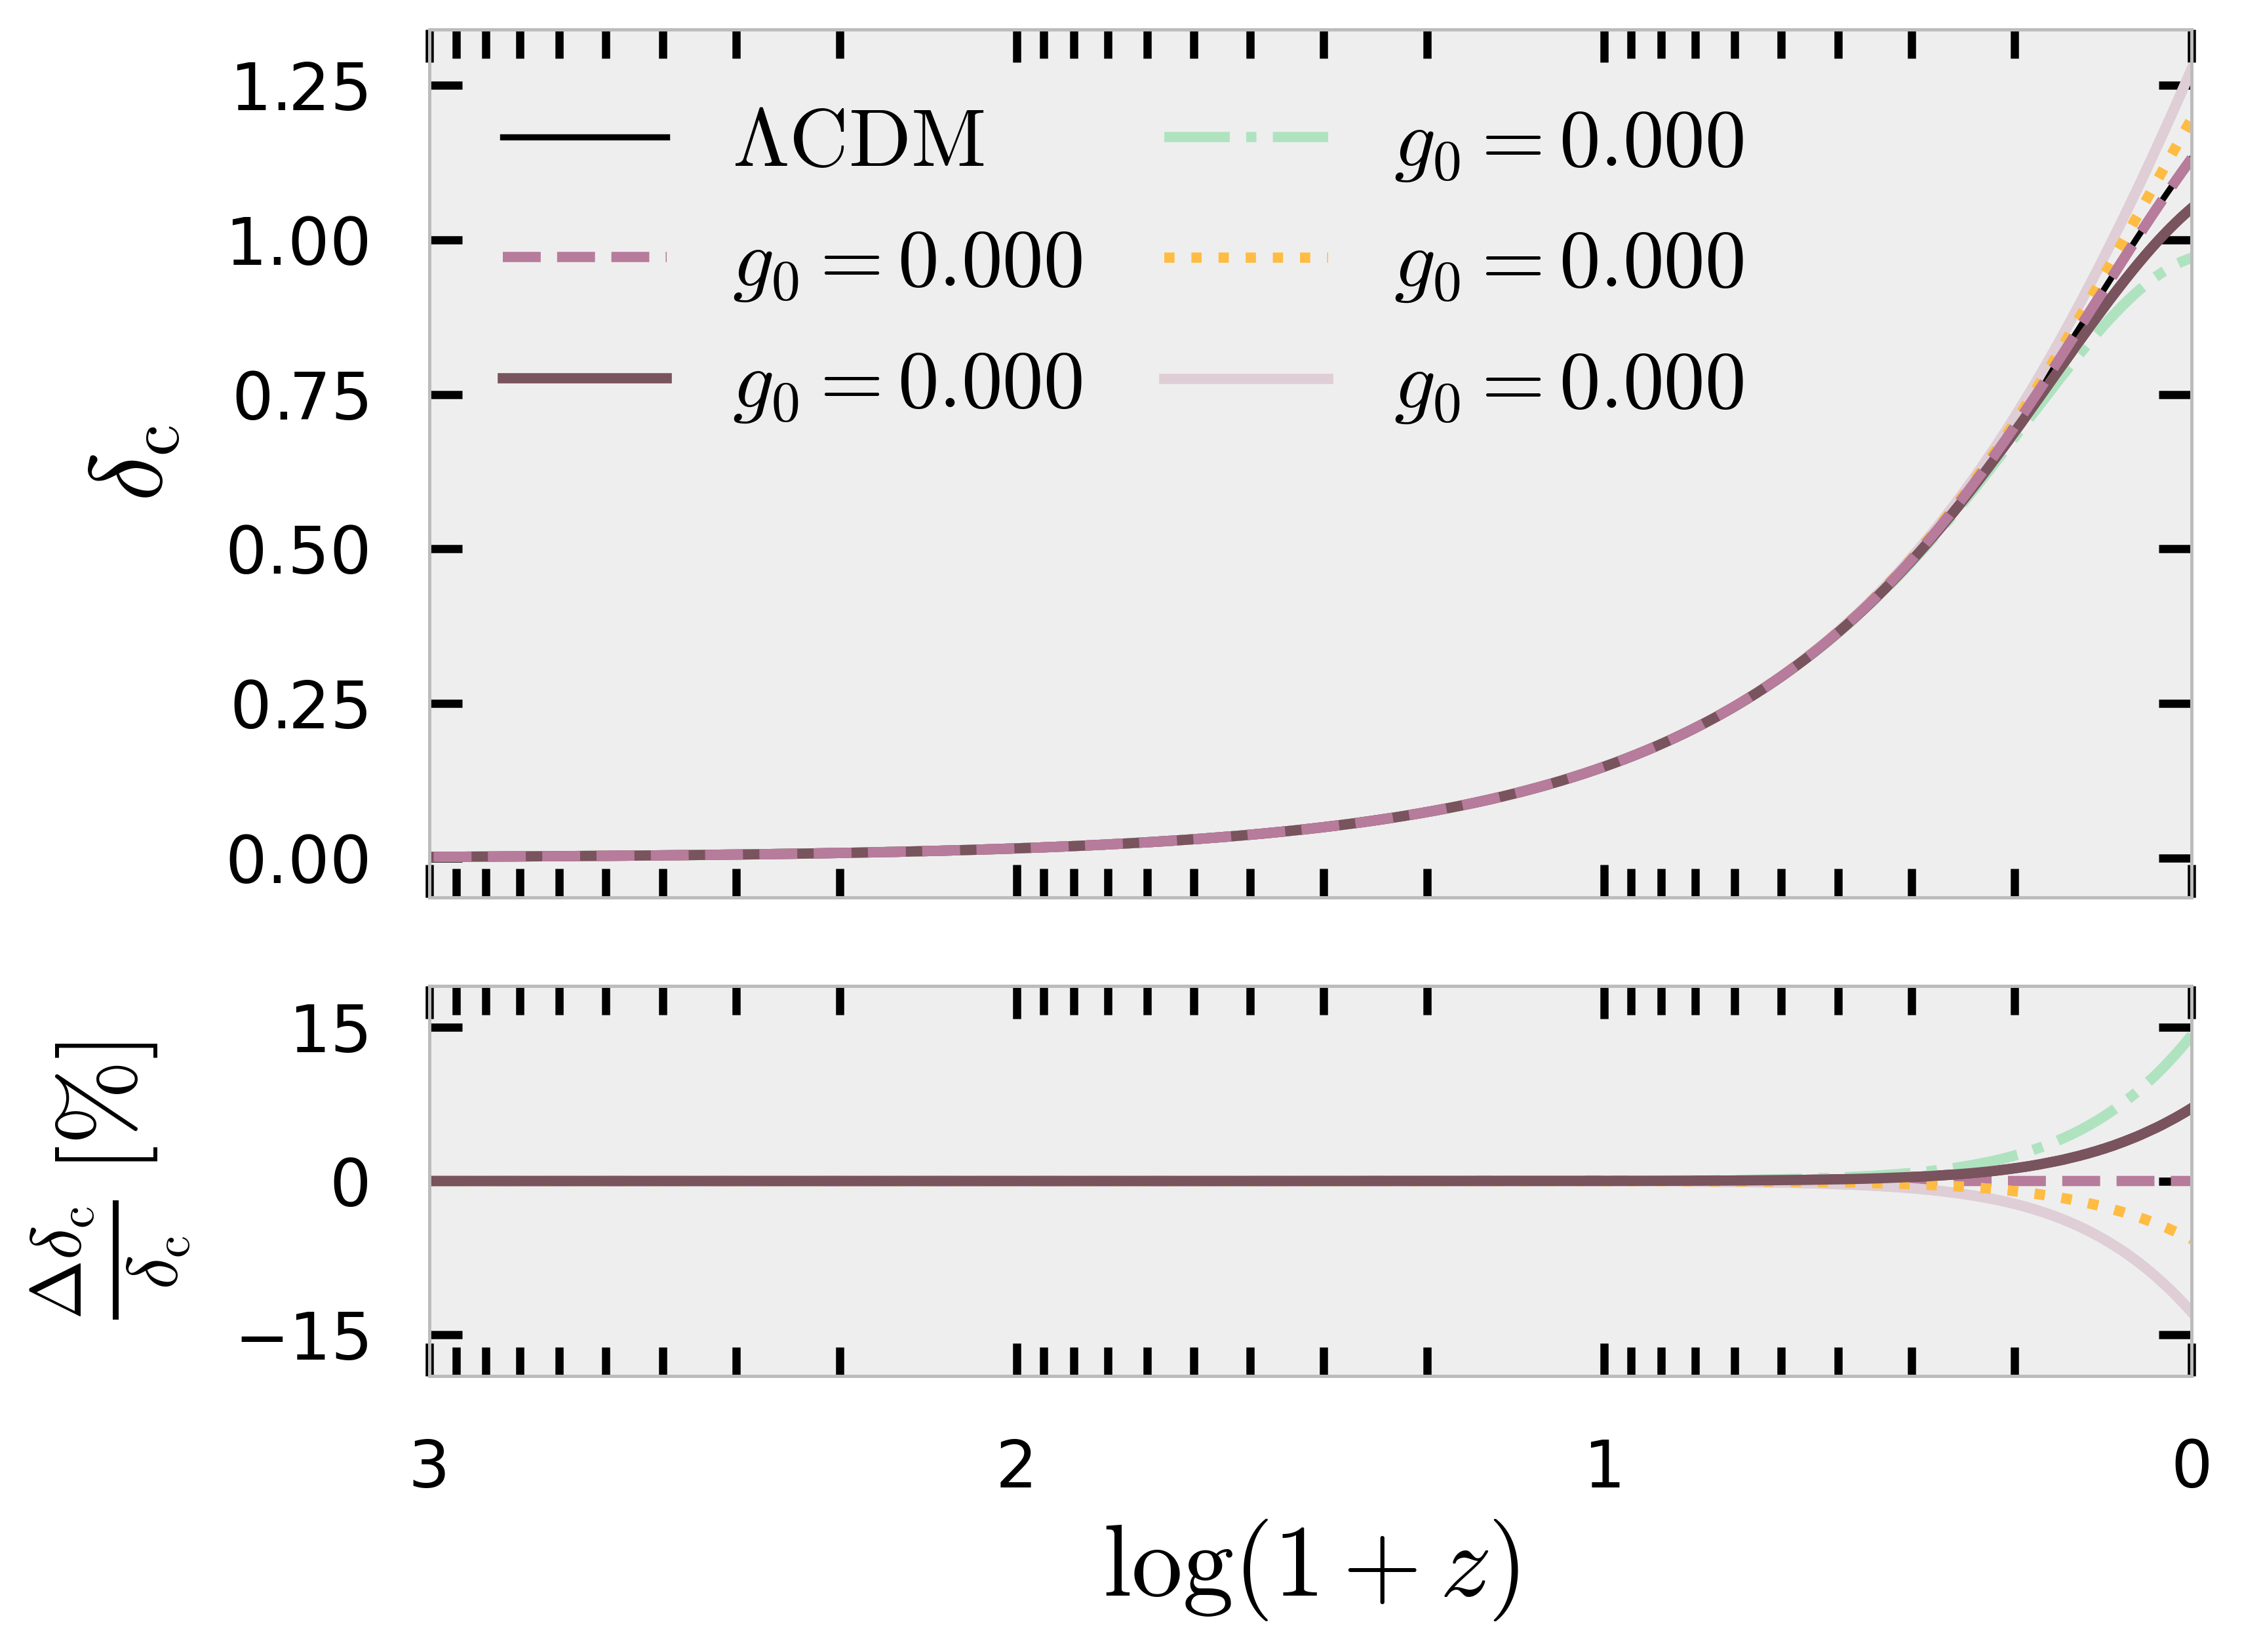

-1.2760553372350913


In [ ]:
#print(k_sorted)
index_k_list = [0]
label = [r'$|\delta_{\rm c}| \times10^{-4}$','','','','']

lw = 2.5
ls = ['--','-','-.', ':', '-']
plt.style.use('bmh')
plt.style.use(['ipynb', 'use_mathtext','colors5-light'])

fig = plt.figure(figsize=(8,6))
ax0 = plt.subplot2grid((3,1),(0,0), rowspan=2)
ax1 = plt.subplot2grid((3,1),(2,0), rowspan=1,sharex = ax0)

plt.subplots_adjust(hspace=0,wspace=0.)

from scipy.interpolate import interp1d
import numpy as np
import matplotlib.pyplot as plt

def build_interp1d_monotonic(x, y, kind='linear', clamp=True):
    """interp1d with sorting and duplicate-x handling."""
    x = np.asarray(x); y = np.asarray(y)
    order = np.argsort(x)
    x = x[order]; y = y[order]
    xu, inv, cnt = np.unique(x, return_inverse=True, return_counts=True)
    if np.any(cnt > 1):
        yu = np.zeros_like(xu, dtype=float)
        np.add.at(yu, inv, y)
        yu /= cnt
    else:
        yu = y
    fill = (yu[0], yu[-1]) if clamp else 'extrapolate'
    return interp1d(xu, yu, kind=kind, bounds_error=False, fill_value=fill, assume_sorted=True)

# --- your plotting code (only the relevant bits changed) ---

index_k = 2  # you set this explicitly
print(k_sorted[index_k])

standardPerturb = standard.get_perturbations()
a0 = standardPerturb['scalar'][index_k]['a']                 # standard grid
z0 = 1/a0 - 1
delta_c0 = standardPerturb['scalar'][index_k]['delta_cdm']

# interpolator: δ_c^Lc(a)
f_delta0_of_a = build_interp1d_monotonic(a0, delta_c0, kind='linear', clamp=True)

# plot the Lc baseline on its own grid (top panel)
ax0.plot(1+z0, -delta_c0*1e-4, c='k', ls='-', label=r'$\Lambda{\rm CDM}$', lw=1.5)

for index in [0,1,2,3,4]:  # your beta values
    cosmoPerturb = cosmo[index].get_perturbations()
    a = cosmoPerturb['scalar'][index_k]['a']                  # this run's grid
    z = 1/a - 1
    delta_c = cosmoPerturb['scalar'][index_k]['delta_edm']

    # interpolate standard onto THIS grid => shapes now match
    delta_c0_on_a = f_delta0_of_a(a)

    # top panel
    ax0.plot(1+z, -delta_c*1e-4,label=rf'$g_0 = {f0s[index]:.3f}$', lw=lw, ls=ls[index], c=color[index])

    # bottom panel: percent difference, guard against tiny denominators
    eps = 1e-300
    denom = np.where(np.abs(delta_c0_on_a) > eps, delta_c0_on_a, np.nan)
    rel = -100.0 * (delta_c - delta_c0_on_a) / denom

    ax1.plot(1+z, rel, lw=lw, ls=ls[index], c=color[index])

    #ax0.plot(1+z, np.abs(cosmoPerturb['scalar'][index_k]['delta_rho_scf'])*1e-4, c='k', ls='-', label = r'$\delta {\phi}$',lw=1.5)
    ax0.set_xticklabels([-1,0,1,2,3])

    ax0.set_ylabel(label[index], size=25)
    ax1.set_xlabel(r'$\log(1+z)$', size=25)
    #ax0.set_xlim(1e5,1)
    # ax0.set_ylim(1e-3,1)
    #ax0.set_title('k = '+str(k_sorted[index_k]), size=20)
    ax0.tick_params(axis='both', which='major', labelsize=16, width=1.1)
    for tick in ax0.xaxis.get_major_ticks():
        tick.set_pad(10)
    for tick in ax0.yaxis.get_major_ticks():
        tick.set_pad(10)    

#ax.ticklabel_format(axis='y', style='sci', scilimits=(0,0), useMathText=True) #---------------------------> Scientific format
#ax.yaxis.offsetText.set_fontsize(20) #---------------------------> size of the scientific format

#ax0.set_xscale('log');ax0.set_yscale('log')
ax1.set_xscale('log');ax1.set_yscale('linear')

ax1.set_ylabel(r'$ \frac{\Delta \delta_{\rm c}}{\delta_{\rm c}}\, [\%]$', size=25,labelpad=10)
ax0.set_ylabel(r'$ \delta_{\rm c}$', size=25,labelpad=10)

#ax0.set_xlim([1.e-3,0.1])
ax1.set_xlim(1e3,1)
#ax0.set_ylim([1e3,5.*1e4])
ax1.set_ylim(-19,19)
ax1.set_yticks([i for i in np.linspace(-15,15,3)])
    
ax0.tick_params(axis='both', which='both', labelsize=16)
ax0.tick_params(axis='both', which='both', labelsize=16)

#---------------------------------------------------------------------------------> change ticklabels distance
ax1.tick_params(axis='both', which='both', labelsize=16)
ax1.tick_params(axis='both', which='both', labelsize=16)

for tick in ax1.xaxis.get_major_ticks():
    tick.set_pad(15)
for tick in ax0.yaxis.get_major_ticks():
    tick.set_pad(15)
for tick in ax1.yaxis.get_major_ticks():
    tick.set_pad(15)
    
ax0.tick_params(axis='both', which='both', labelsize=16)

    
ax0.xaxis.set_tick_params(which='major', size=8, width=2, direction='in', top='on')
ax0.xaxis.set_tick_params(which='minor', size=7, width=2, direction='in', top='on')
ax0.yaxis.set_tick_params(which='major', size=8, width=2, direction='in', right='on')
ax0.yaxis.set_tick_params(which='minor', size=7, width=2, direction='in', right='on')

ax1.tick_params(axis='both', which='both', labelsize=16)

    
ax1.xaxis.set_tick_params(which='major', size=8, width=2, direction='in', top='on')
ax1.xaxis.set_tick_params(which='minor', size=7, width=2, direction='in', top='on')
ax1.yaxis.set_tick_params(which='major', size=8, width=2, direction='in', right='on')
ax1.yaxis.set_tick_params(which='minor', size=7, width=2, direction='in', right='on')

#ax0.set_xscale('log')
#ax0.set_yscale('log')
original_labels = ax0.get_xticks()
labels = []
for label in original_labels:
    labels.append(int(np.log10(label)))
ax0.set_xticklabels(labels)

ax1.ticklabel_format(axis='y', style='plain', useMathText=True)


for ax in (ax0, ax1):
    # copy the list so we don't iterate over lines we add
    lines = list(ax.get_lines())[1:]
    for ln in lines[::-1]:
        ax.plot(
            ln.get_xdata(), ln.get_ydata(),
            ls=ln.get_linestyle(),
            lw=ln.get_linewidth(),
            c=ln.get_color(),
            marker=ln.get_marker(),
            markersize=ln.get_markersize(),
            alpha=ln.get_alpha() if ln.get_alpha() is not None else 1.0,
            label="_nolegend_",  # labels starting with '_' are ignored by legend()
        )

ax0.legend(loc='upper left', frameon=boolean, prop={'size': 20},ncol=2,columnspacing=1)
plt.setp(ax0.get_xticklabels(), visible=False)
plt.rcParams['font.size'] = 20
plt.rcParams['axes.linewidth'] = 2
fig.tight_layout()
fig.tight_layout()
plt.savefig('deltac.pdf')
#, transparent=True)

plt.show()

print(cosmoPerturb['scalar'][index_k]['delta_edm'][-1]*1e-4)

[6.7556e-05 6.7556e-03 6.7556e-02 8.4445e-02 6.7556e-01]


'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


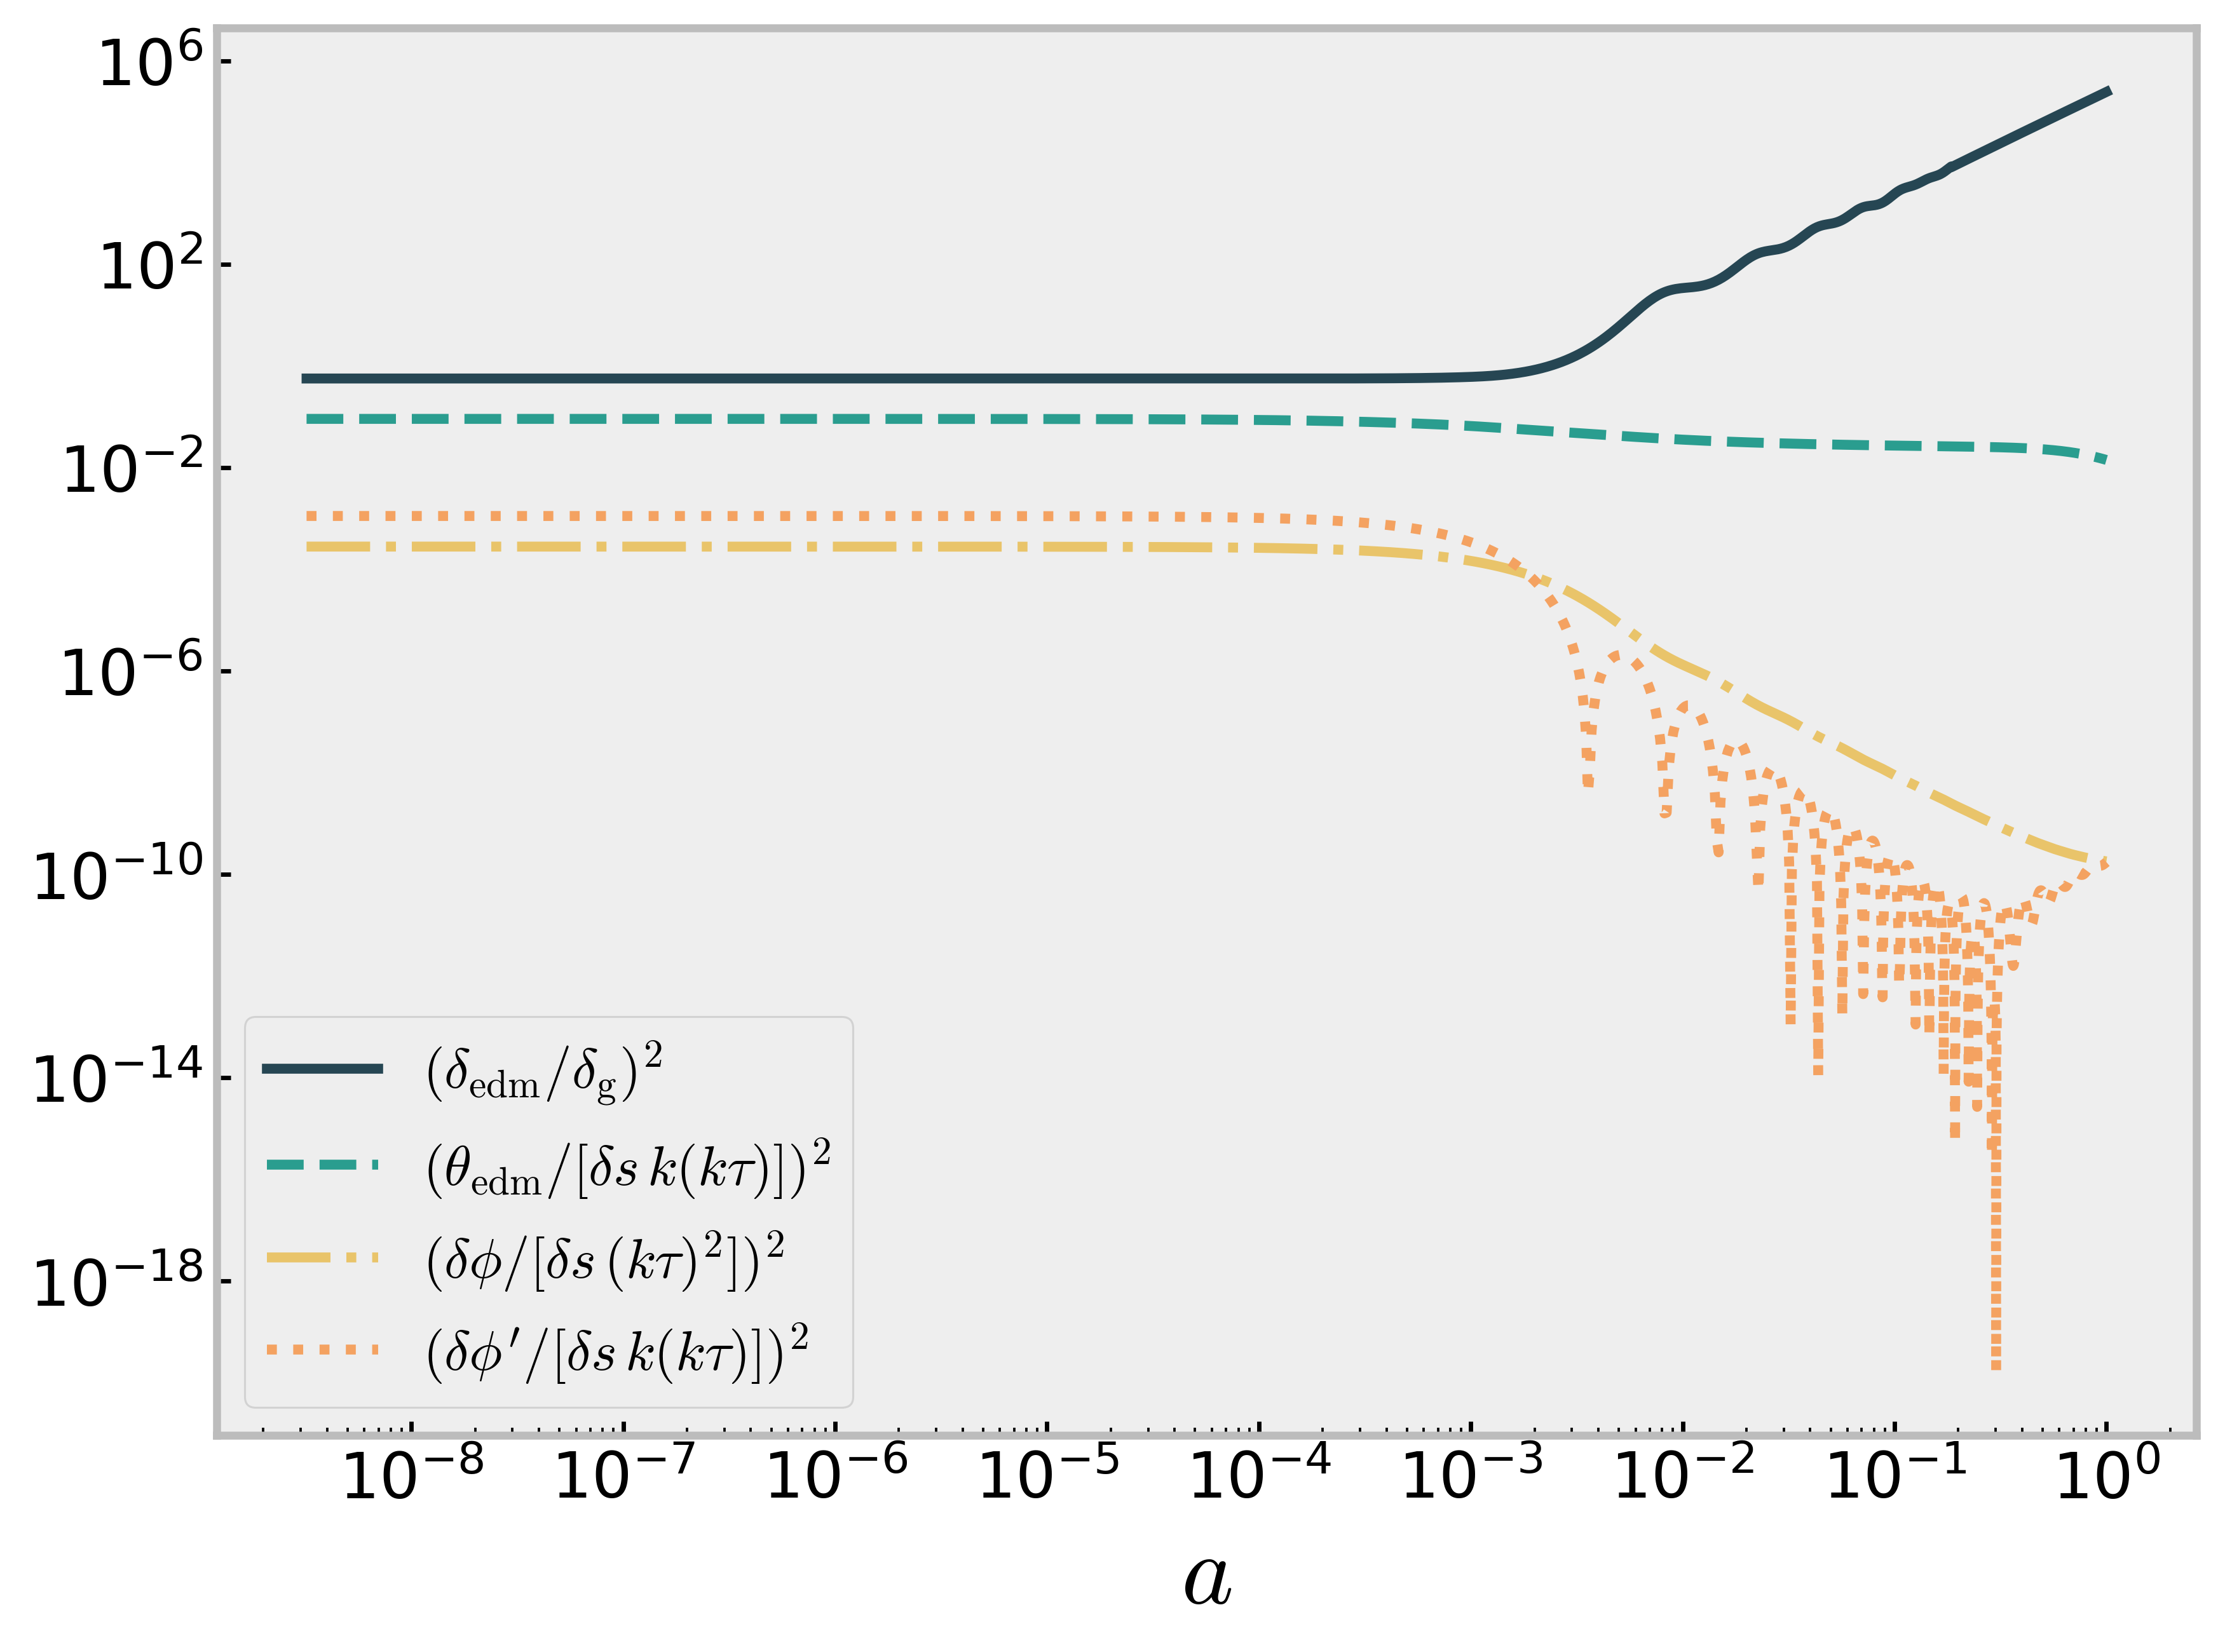

In [80]:
import numpy as np
import matplotlib.pyplot as plt

plt.style.use('bmh')
plt.style.use(['ipynb', 'use_mathtext','colors5-light'])

lw = 2.5
eps = 1e-300

index_k = 1
k = k_sorted[index_k]
print(k_sorted)


cosmoPerturb = cosmo[1].get_perturbations()
P = cosmoPerturb['scalar'][index_k]

a   = np.asarray(P['a'])
tau = np.asarray(P['tau [Mpc]'])

delta_edm  = np.asarray(P['delta_edm'])
delta_g  = np.asarray(P['delta_g'])
theta_edm  = np.asarray(P['theta_edm'])
delta_phi  = np.asarray(P['delta_phi_scf'])
delta_phi_p = np.asarray(P['delta_phi_prime_scf'])
delta_s    = np.asarray(P['delta_s_scf'])   # your conserved entropy mode output

kt = k * tau

# --- plateau diagnostics ---
den2ds = delta_s * (kt**2) + eps
den4ds = delta_s * (kt**4) + eps
den3ds = delta_s * (kt**3) + eps
den2 = (kt**2) + eps
den1ds = delta_s * (k * kt) + eps

Q_delta_edm = delta_edm / (delta_g)
#Q_delta_edm = delta_edm / den2ds
Q_delta_phi = delta_phi / den2ds
Q_theta_edm = theta_edm / den1ds
Q_delta_phi_p = delta_phi_p / den1ds

# --- Fig.2-like plot ---
fig = plt.figure(figsize=(8,6))
ax = plt.gca()

ax.plot(a, np.abs(Q_delta_edm)**2, lw=lw, ls='-',  label=r'$(\delta_{\rm edm}/\delta_{\rm g})^2$')
ax.plot(a, np.abs(Q_theta_edm)**2, lw=lw, ls='--', label=r'$(\theta_{\rm edm}/[\delta s\,k(k\tau)])^2$')
ax.plot(a, np.abs(Q_delta_phi)**2, lw=lw, ls='-.', label=r'$(\delta\phi/[\delta s\,(k\tau)^2])^2$')
ax.plot(a, np.abs(Q_delta_phi_p)**2, lw=lw, ls=':',  label=r"$(\delta\phi'/[\delta s\,k(k\tau)])^2$")
#ax.hlines(y=(3/4)**2, xmin=a[0], xmax=a[-1], lw=lw, ls=':',  label=r"$(3/4)^2$")

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel(r'$a$', size=25)
#ax.set_ylabel(r'IC diagnostic (squared)', size=25, labelpad=10)

ax.tick_params(axis='both', which='major', labelsize=16, width=1.1)
ax.legend(loc='best', frameon=True, prop={'size': 14})

fig.tight_layout()
plt.savefig('IC_attractor_entropy_mode.pdf')
plt.show()


In [27]:
print("len(ls)=", len(ls), "len(color)=", len(color), "len(n0s)=", len(n0s))


len(ls)= 5 len(color)= 5 len(n0s)= 6


0.0067556000000000005
k = 0.0067556000000000005


/var/folders/91/jymwbq1j1nng0wqyd6yvbm100000gn/T/ipykernel_82780/3358411517.py:76: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax0.set_xticklabels([-1,0,1,2,3])
/var/folders/91/jymwbq1j1nng0wqyd6yvbm100000gn/T/ipykernel_82780/3358411517.py:76: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax0.set_xticklabels([-1,0,1,2,3])
/var/folders/91/jymwbq1j1nng0wqyd6yvbm100000gn/T/ipykernel_82780/3358411517.py:76: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax0.set_xticklabels([-1,0,1,2,3])
/var/folders/91/jymwbq1j1nng0wqyd6yvbm100000gn/T/ipykernel_82780/3358411517.py:76: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax0.set_xticklabels([-1,0,1,2,3])
/var/folders

<Figure size 2025x1557 with 0 Axes>

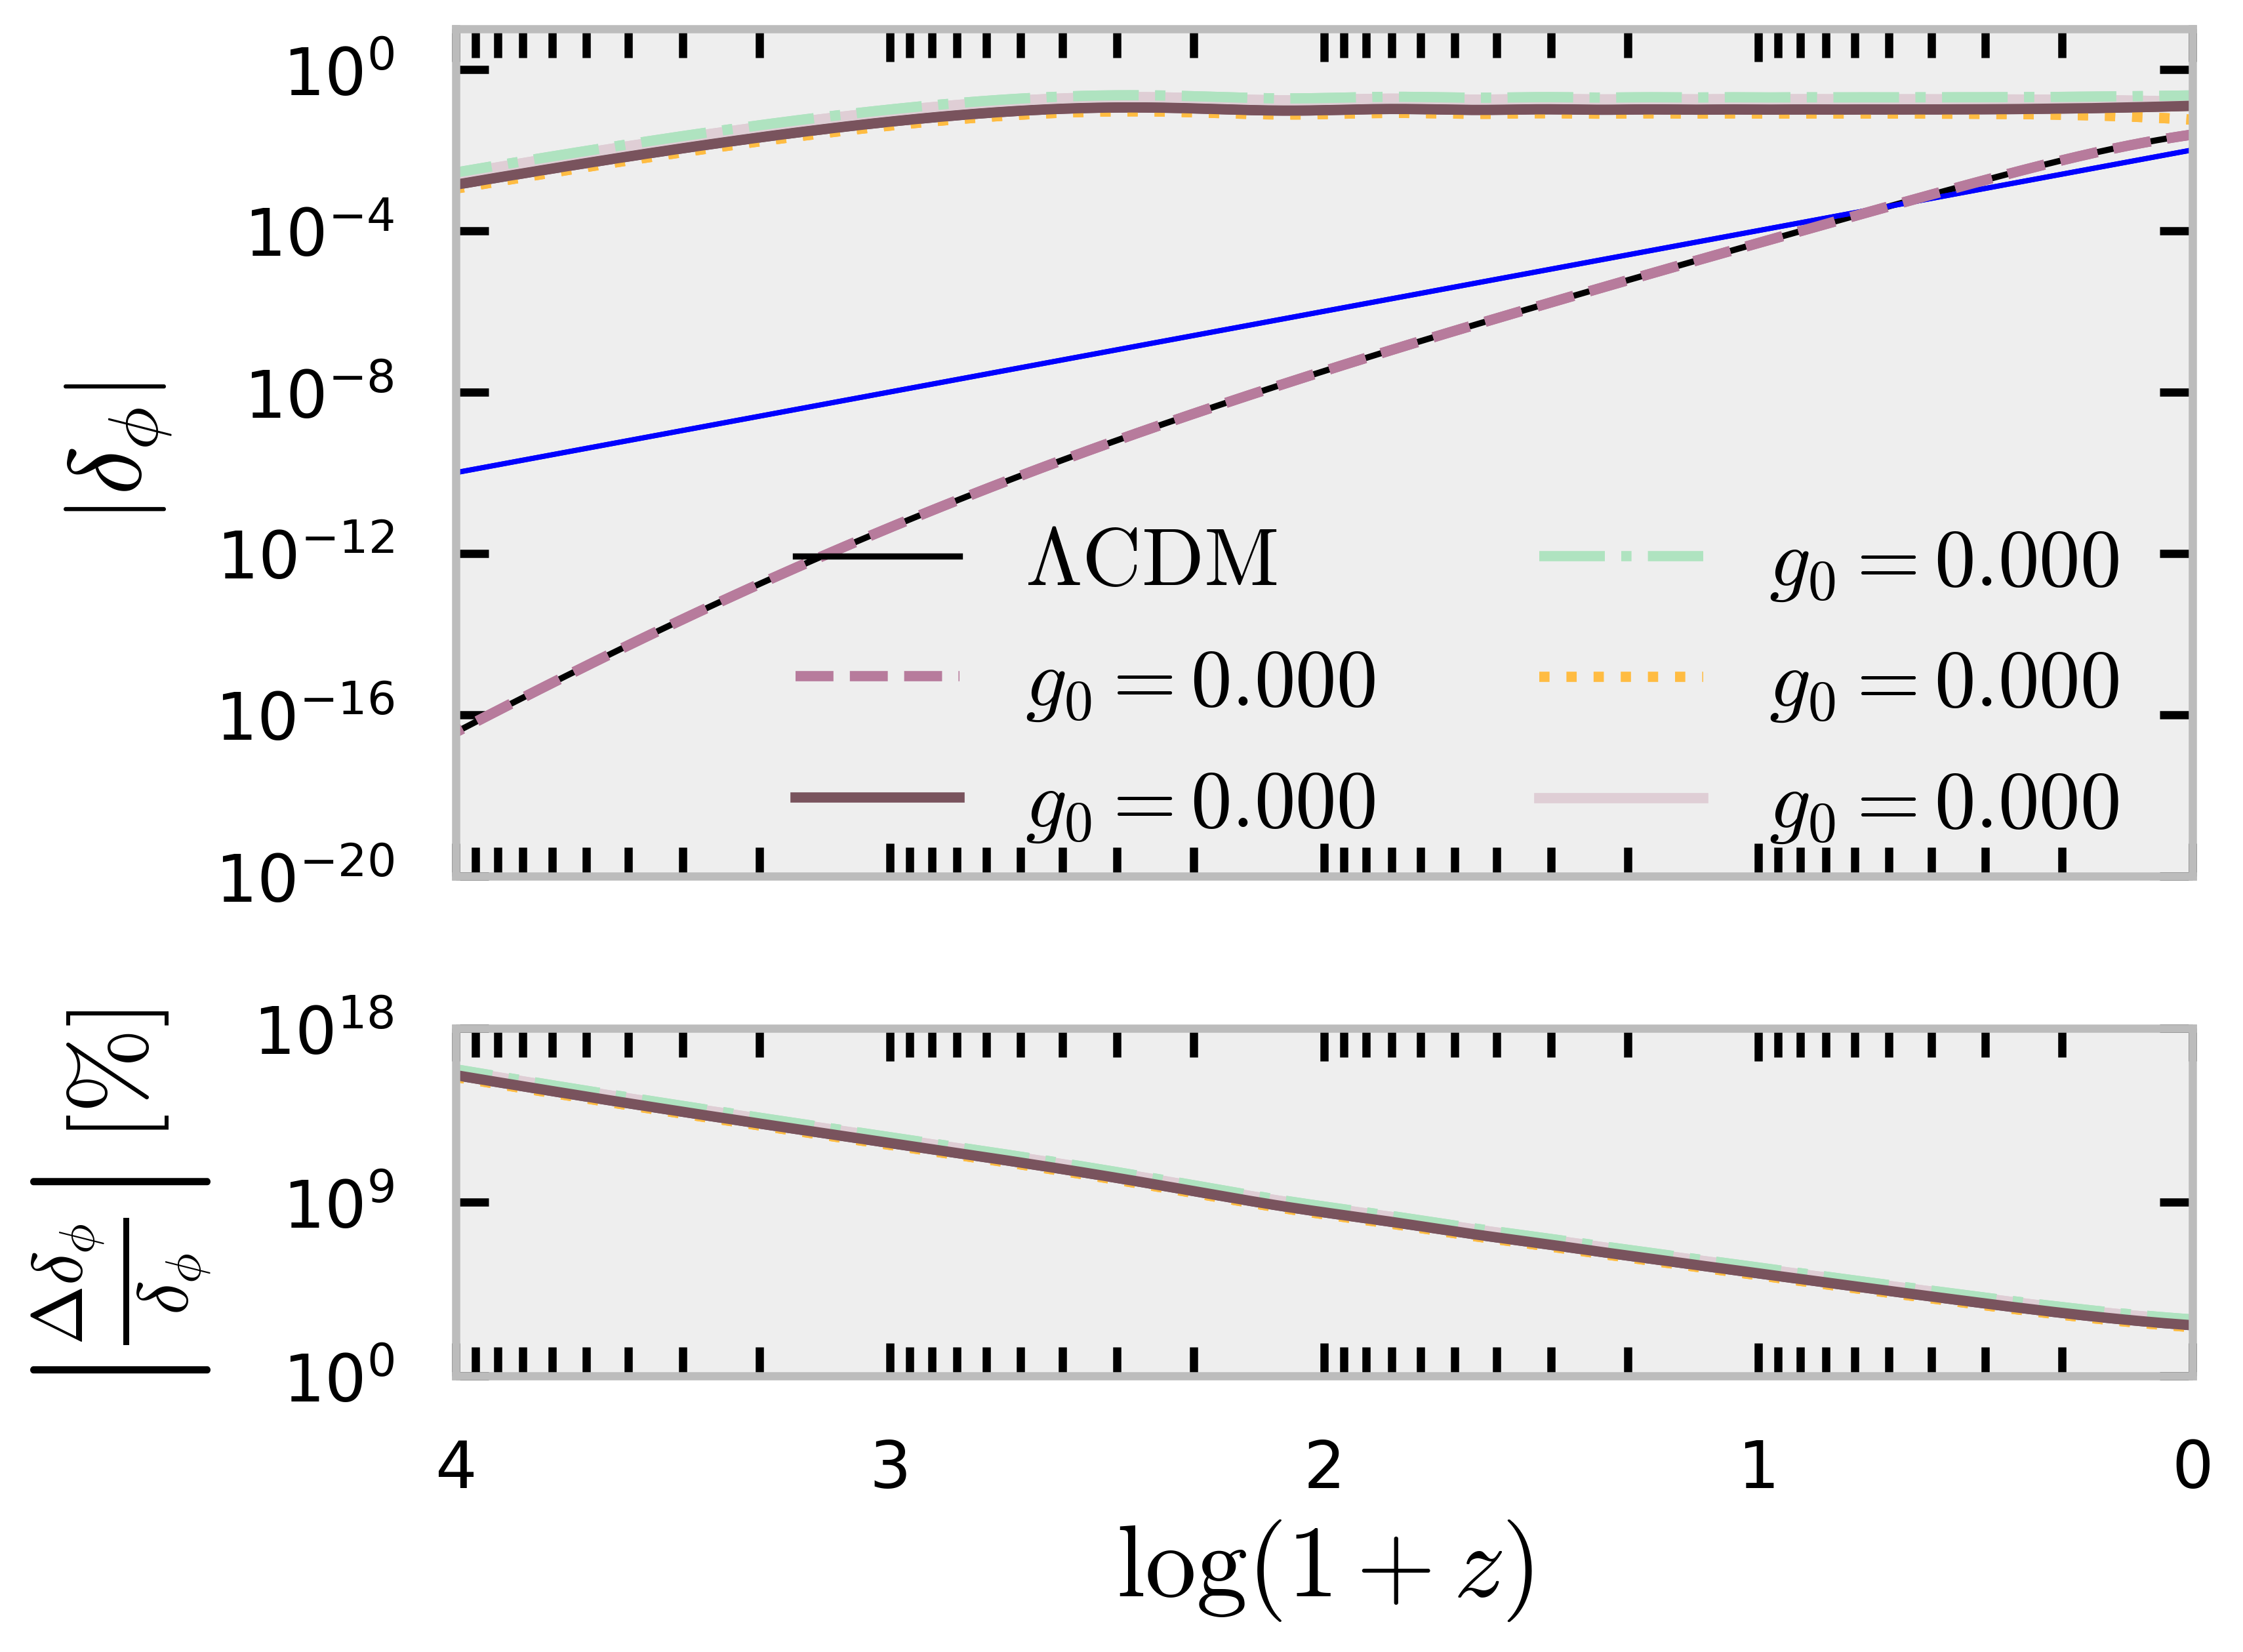

In [ ]:
#print(k_sorted)
index_k_list = [0]
label = [r'$|\delta {\phi}|$','','','','']

lw = 2.5
ls = ['--','-','-.', ':', '-']
plt.style.use('bmh')
plt.style.use(['ipynb', 'use_mathtext','colors5-light'])

plt.subplots_adjust(hspace=0,wspace=0.)

def build_interp1d_monotonic(a, y, kind='linear', clamp=True):
    a = np.asarray(a); y = np.asarray(y)
    order = np.argsort(a); a = a[order]; y = y[order]
    au, inv, cnt = np.unique(a, return_inverse=True, return_counts=True)
    if np.any(cnt > 1):
        yu = np.zeros_like(au, dtype=float)
        np.add.at(yu, inv, y)
        yu /= cnt
    else:
        yu = y
    fill = (yu[0], yu[-1]) if clamp else 'extrapolate'
    return interp1d(au, yu, kind=kind, bounds_error=False, fill_value=fill, assume_sorted=True)

# ---------------- figure setup (yours) ----------------
index_k_list = [0]
label = [r'$|\delta {\phi}|$','','','','']
lw = 2.5
ls = ['--','-','-.', ':', '-']
plt.style.use(['ipynb', 'use_mathtext','colors5-light'])

fig = plt.figure(figsize=(8,6))
ax0 = plt.subplot2grid((3,1),(0,0), rowspan=2)
ax1 = plt.subplot2grid((3,1),(2,0), rowspan=1, sharex=ax0)
plt.subplots_adjust(hspace=0, wspace=0.)

# ---------------- choose k and build reference interpolator ----------------
index_k = 1
print(k_sorted[index_k]); print('k =', k_sorted[index_k])

# reference (baseline) = cosmo[0]
p_ref = cosmo[0].get_perturbations()['scalar'][index_k]
a_ref = p_ref['a']
phi_ref = p_ref['delta_phi_scf']
f_phi_ref = build_interp1d_monotonic(a_ref, phi_ref, kind='linear', clamp=True)

# optional: plot baseline itself
z_ref = 1/a_ref - 1
ax0.plot(1+z_ref, -phi_ref, c='k', ls='-', label=r'$\Lambda{\rm CDM}$', lw=1.5)

# ---------------- loop over models ----------------
runs = [0,1,2,3,4]
for j, index in enumerate(runs):
    p = cosmo[index].get_perturbations()['scalar'][index_k]
    a = p['a']
    z = 1/a - 1
    phi = p['delta_phi_scf']

    # interpolate reference onto THIS grid -> shapes match
    phi_ref_on_a = f_phi_ref(a)

    # styles (cycle safely)
    ls_j = ls[j % len(ls)]
    color_j = color[j % len(color)]
    label_str = rf'$g_0 = {f0s[index]:.3f}$' if index < len(n0s) else rf'$i={index}$'

    # top panel
    ax0.plot(1+z, np.abs(phi), label=label_str, lw=lw, ls=ls_j, c=color_j)

    # bottom panel: percent difference
    eps = 1e-300
    denom = np.where(np.abs(phi_ref_on_a) > eps, phi_ref_on_a, np.nan)
    rel = -100.0 * (phi - phi_ref_on_a) / denom
    ax1.plot(1+z, np.abs(rel), lw=lw, ls=ls_j, c=color_j)
    #ax0.plot(1+z, np.abs(cosmoPerturb['scalar'][index_k]['delta_rho_scf'])*1e-4, c='k', ls='-', label = r'$\delta {\phi}$',lw=1.5)
    ax0.set_xticklabels([-1,0,1,2,3])

    ax0.set_ylabel(label[index], size=25)
    ax1.set_xlabel(r'$\log(1+z)$', size=25)
    #ax0.set_xlim(1e5,1)
    # ax0.set_ylim(1e-3,1)
    #ax0.set_title('k = '+str(k_sorted[index_k]), size=20)
    ax0.tick_params(axis='both', which='major', labelsize=16, width=1.1)
    for tick in ax0.xaxis.get_major_ticks():
        tick.set_pad(10)
    for tick in ax0.yaxis.get_major_ticks():
        tick.set_pad(10)    

ax0.plot(1+z, 1e-2*pow(1+z,-2),lw=lw/2, ls='-', c='blue')

#ax.ticklabel_format(axis='y', style='sci', scilimits=(0,0), useMathText=True) #---------------------------> Scientific format
#ax.yaxis.offsetText.set_fontsize(20) #---------------------------> size of the scientific format

ax0.set_xscale('log');ax0.set_yscale('log')
ax1.set_xscale('log');ax1.set_yscale('linear')

ax0.set_ylabel(r'$|\delta {\phi}|$', size=25,labelpad=10)
ax1.set_ylabel(r'$\left| \frac{\Delta \delta {\phi}}{\delta {\phi}}\right|\, [\%]$', size=25,labelpad=10)

#ax0.set_xlim([1.e-3,0.1])
ax1.set_xlim(1e4,1)
ax0.set_ylim(1e-20,10)
#ax0.set_ylim([1e3,5.*1e4])
ax1.set_ylim(1.,1e18)
#ax1.set_yticks([i for i in np.linspace(-25,25,3)])
    
ax0.tick_params(axis='both', which='both', labelsize=16)
ax0.tick_params(axis='both', which='both', labelsize=16)

#---------------------------------------------------------------------------------> change ticklabels distance
ax1.tick_params(axis='both', which='both', labelsize=16)
ax1.tick_params(axis='both', which='both', labelsize=16)

for tick in ax1.xaxis.get_major_ticks():
    tick.set_pad(15)
for tick in ax0.yaxis.get_major_ticks():
    tick.set_pad(15)
for tick in ax1.yaxis.get_major_ticks():
    tick.set_pad(15)
    
ax0.tick_params(axis='both', which='both', labelsize=16)

    
ax0.xaxis.set_tick_params(which='major', size=8, width=2, direction='in', top='on')
ax0.xaxis.set_tick_params(which='minor', size=7, width=2, direction='in', top='on')
ax0.yaxis.set_tick_params(which='major', size=8, width=2, direction='in', right='on')
ax0.yaxis.set_tick_params(which='minor', size=7, width=2, direction='in', right='on')

ax1.tick_params(axis='both', which='both', labelsize=16)

    
ax1.xaxis.set_tick_params(which='major', size=8, width=2, direction='in', top='on')
ax1.xaxis.set_tick_params(which='minor', size=7, width=2, direction='in', top='on')
ax1.yaxis.set_tick_params(which='major', size=8, width=2, direction='in', right='on')
ax1.yaxis.set_tick_params(which='minor', size=7, width=2, direction='in', right='on')

ax0.set_xscale('log')
ax0.set_yscale('log')
ax1.set_yscale('log')
original_labels = ax0.get_xticks()
labels = []
for label in original_labels:
    labels.append(int(np.log10(label)))
ax0.set_xticklabels(labels)

for ax in (ax0, ax1):
    # copy the list so we don't iterate over lines we add
    lines = list(ax.get_lines())[1:]
    for ln in lines[::-1]:
        ax.plot(
            ln.get_xdata(), ln.get_ydata(),
            ls=ln.get_linestyle(),
            lw=ln.get_linewidth(),
            c=ln.get_color(),
            marker=ln.get_marker(),
            markersize=ln.get_markersize(),
            alpha=ln.get_alpha() if ln.get_alpha() is not None else 1.0,
            label="_nolegend_",  # labels starting with '_' are ignored by legend()
        )

ax0.legend(loc='lower right', frameon=boolean, prop={'size': 20},ncol=2,bbox_to_anchor=(1.0, -0.05))
plt.setp(ax0.get_xticklabels(), visible=False)
plt.rcParams['font.size'] = 20
plt.rcParams['axes.linewidth'] = 2
fig.tight_layout()
fig.tight_layout()
plt.savefig('deltaphi.pdf')
#, transparent=True)

plt.show()

In [29]:
# # =================== FULL DROP-IN CELL ===================

# import numpy as np
# import matplotlib as mpl
# import matplotlib.pyplot as plt
# from matplotlib.ticker import LogLocator, FuncFormatter
# from scipy.interpolate import interp1d

# # ---------- helpers ----------
# def _contiguous_spans(mask):
#     spans=[]; on=False; s=0
#     for i,m in enumerate(mask):
#         if m and not on: on=True; s=i
#         if not m and on: on=False; spans.append((s, i-1))
#     if on: spans.append((s, len(mask)-1))
#     return spans

# def shade_horizon_and_compton(ax, bg, k_phys,
#                               xmode='one_plus_z',   # 'a', 'one_plus_z', or 'log1pz'
#                               color='0.3',
#                               alpha_h=0.08, alpha_c=0.14,
#                               draw_lines=True, annotate=True):
#     """
#     Shade super-horizon (k < 𝓗) and super-Compton (k < a m_eff) regions
#     on an axis using a (scale factor), 1+z, or log10(1+z) as the x-variable.
#     """
#     z  = np.asarray(bg['z'])
#     a  = 1.0/(1.0 + z)
#     Hc = np.asarray(bg['H [1/Mpc]'])            # conformal Hubble 𝓗(a)
#     me2 = np.asarray(bg["V''_scf"])             # m_eff^2(a)
#     ame = a * np.sqrt(np.clip(me2, 0.0, None))  # a m_eff (clamp tachyonic to 0)

#     o = np.argsort(a); a=a[o]; Hc=Hc[o]; ame=ame[o]
#     super_hor  = (k_phys < Hc)
#     super_comp = (k_phys < ame)

#     if xmode == 'a':
#         x = a
#     elif xmode == 'one_plus_z':
#         x = 1.0/a
#     elif xmode == 'log1pz':
#         x = np.log10(1.0/a)
#     else:
#         raise ValueError("xmode must be 'a', 'one_plus_z', or 'log1pz'.")

#     y0, y1 = ax.get_ylim()

#     def _span(ax, xL, xR, **kw):
#         L, R = (xL, xR) if xL <= xR else (xR, xL)
#         ax.axvspan(L, R, **kw)

#     for s,e in _contiguous_spans(super_hor):
#         _span(ax, x[s], x[e], color=color, alpha=alpha_h, ec=None, zorder=0)
#     for s,e in _contiguous_spans(super_comp):
#         _span(ax, x[s], x[e], color=color, alpha=alpha_c, ec=None, zorder=0)

#     if draw_lines:
#         iH  = np.nanargmin(np.abs(Hc - k_phys))
#         iC  = np.nanargmin(np.abs(ame - k_phys))
#         ax.axvline(x[iH], ls='--', lw=1.0, color=color, alpha=0.6)
#         ax.axvline(x[iC], ls='-.', lw=1.0, color=color, alpha=0.6)

#         if annotate:
#             # x in data, y in axes-fraction so text stays inside panel
#             tf = ax.get_xaxis_transform()
#             ax.text(x[iH], 0.06, r'$k=\mathcal{H}$',
#                     rotation=90, va='bottom', ha='left',
#                     fontsize=10, color=color, alpha=0.9,
#                     transform=tf, clip_on=False)
#             ax.text(x[iC], 0.06, r'$k=a\,m_{\rm eff}$',
#                     rotation=90, va='bottom', ha='left',
#                     fontsize=10, color=color, alpha=0.9,
#                     transform=tf, clip_on=False)

#     ax.set_ylim(y0, y1)

# def build_interp1d(x, y, kind='linear', clamp=True):
#     x = np.asarray(x); y = np.asarray(y)
#     order = np.argsort(x)
#     x = x[order]; y = y[order]
#     xu, inv, cnt = np.unique(x, return_inverse=True, return_counts=True)
#     if np.any(cnt > 1):
#         yu = np.zeros_like(xu, dtype=float)
#         np.add.at(yu, inv, y); yu /= cnt
#     else:
#         yu = y
#     fill = (yu[0], yu[-1]) if clamp else 'extrapolate'
#     return interp1d(xu, yu, kind=kind, bounds_error=False, fill_value=fill, assume_sorted=True)

# def interp_bg_to_pert(bg, key, a_target, kind='linear', clamp=True):
#     z_bg = np.asarray(bg['z']); a_bg = 1.0/(1.0 + z_bg)
#     y_bg = np.asarray(bg[key])
#     f = build_interp1d(a_bg, y_bg, kind=kind, clamp=clamp)
#     return f(a_target)

# def pick_first_key(d, candidates):
#     for k in candidates:
#         if k in d:
#             return k
#     raise KeyError(f"None of the keys found: {candidates}")

# # ---------- plotting ----------
# # Fallback styles if you don't already have these defined:
# try:
#     color
# except NameError:
#     color = ['#1f77b4','#d62728','#2ca02c','#9467bd','#8c564b']
# try:
#     lw
# except NameError:
#     lw = 2.0
# try:
#     boolean
# except NameError:
#     boolean = True

# fig, ax0 = plt.subplots(figsize=(8,6))
# ls = ['-','--','-.', ':', (0,(5,1))]

# plt.style.use('bmh')
# plt.style.use(['ipynb', 'use_mathtext','colors5-light'])

# # choose the same k-indices and model indices you used before
# k_indices   = [2, 3]        # edit if needed
# model_inds  = [3, 0]        # edit if needed

# for ik, index_k in enumerate(k_indices):
#     color_idx = ik
#     print(k_sorted[index_k])
#     for ib, index in enumerate(model_inds):
#         cosmoPerturb = cosmo[index].get_perturbations()
#         cosmoBack    = cosmo[index].get_background()

#         pblock    = cosmoPerturb['scalar'][index_k]
#         a         = pblock['a']
#         z         = 1.0/a - 1.0
#         delta_phi = pblock['delta_phi_scf']
#         psi       = pblock['psi']

#         # background on perturbation grid
#         Vphi_key  = pick_first_key(cosmoBack, ["V'_scf"])
#         Vpp_key   = pick_first_key(cosmoBack, ["V''_scf"])
#         H_key     = pick_first_key(cosmoBack, ['H [1/Mpc]'])

#         Vphi_on_pert    = interp_bg_to_pert(cosmoBack, Vphi_key, a)
#         Vphiphi_on_pert = interp_bg_to_pert(cosmoBack, Vpp_key,  a)
#         H_on_pert       = interp_bg_to_pert(cosmoBack, H_key,    a)

#         # label only once per k
#         k_h = k_sorted[index_k] / 0.67556   # label in h/Mpc
#         label_str = fr"$k = {k_h:.3g}\,h\,\mathrm{{Mpc}}^{{-1}}$" if ib == 0 else None

#         ax0.plot(1.0+z, np.abs(delta_phi),
#                  lw=lw, ls=ls[ib], c=color[color_idx], label=label_str)
#         print(np.sqrt(Vphiphi_on_pert[-1])/standard.h())

# # --- guides for the last k used above ---
# kk_phys = k_sorted[index_k]   # your k is already in 1/Mpc; do NOT multiply by h
# # Proper QS guide (uncoupled-like, metric-sourced term)
# print(Vphi_on_pert[-1])
# print(H_on_pert[-1])
# QS = np.abs(-2*Vphi_on_pert*(a**2)*psi / (kk_phys**2 + (a**2)*Vphiphi_on_pert))
# #ax0.plot(1.0+z, -Vphi_on_pert*psi*(a**2)/ (kk_phys**2 + (a**2)*Vphiphi_on_pert),
# #                 lw=lw, ls=ls[ib], c='black', label=label_str)
# ax0.plot(1.0+z, QS*1e2, lw=1.6, ls='-', c='red', alpha=0.85, label='QS guide')
# # a^3 guide (super-horizon matter-era behavior)
# ax0.plot(1.0+z, 0.1*(a**3), lw=1.2, ls='-', c='blue', alpha=0.75, label=r'$\propto a^3$')

# # shading (match x-variable: 1+z)
# shade_horizon_and_compton(ax0, cosmoBack, k_phys=kk_phys, xmode='one_plus_z', color='grey')

# # axes, ticks, legend
# ax0.set_xscale('log'); ax0.set_yscale('log')
# ax0.set_xlim(1e6, 1)
# ax0.set_ylim(1e-30, 1)
# ax0.set_xlabel(r'$1+z$', fontsize=20)
# ax0.set_ylabel(r'$|\delta\phi|$', fontsize=20)

# # format x-ticks to show log10(1+z): 10^6 -> "6"
# ax0.xaxis.set_major_locator(LogLocator(base=10))
# ax0.xaxis.set_major_formatter(FuncFormatter(lambda v, pos: f"{int(np.log10(v))}"))

# ax0.tick_params(axis='both', which='major', labelsize=14, width=1.1)

# ax0.legend(loc='lower right', bbox_to_anchor=(0.98, 0.06),
#            frameon=boolean, prop={'size': 13}, ncol=1)

# fig.tight_layout()
# plt.savefig('deltaphi_ks3.pdf')
# plt.show()
# # =================== END CELL ===================


0.0
4.563813136e-09
1.1458141972944948e-09
5.359450808591674e-08
0.099027532997969
0.0
4.563813136e-09
1.1458141972944948e-09
5.359450808591674e-08
0.46261988435461154
0.0
4.5638131360000005e-05
1.1458141972944948e-09
5.359450808591674e-08
0.3649006443949835
0.0
4.5638131360000005e-05
1.1458141972944948e-09
5.359450808591674e-08
0.3587470447478787
0.0
0.004563813136000001
1.1458141972944948e-09
5.359450808591674e-08
0.06326579715784064
0.0


/var/folders/91/jymwbq1j1nng0wqyd6yvbm100000gn/T/ipykernel_82780/1222049332.py:127: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax0.set_xticklabels(labels)
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


0.004563813136000001
1.1458141972944948e-09
5.359450808591674e-08
0.057075878545787544


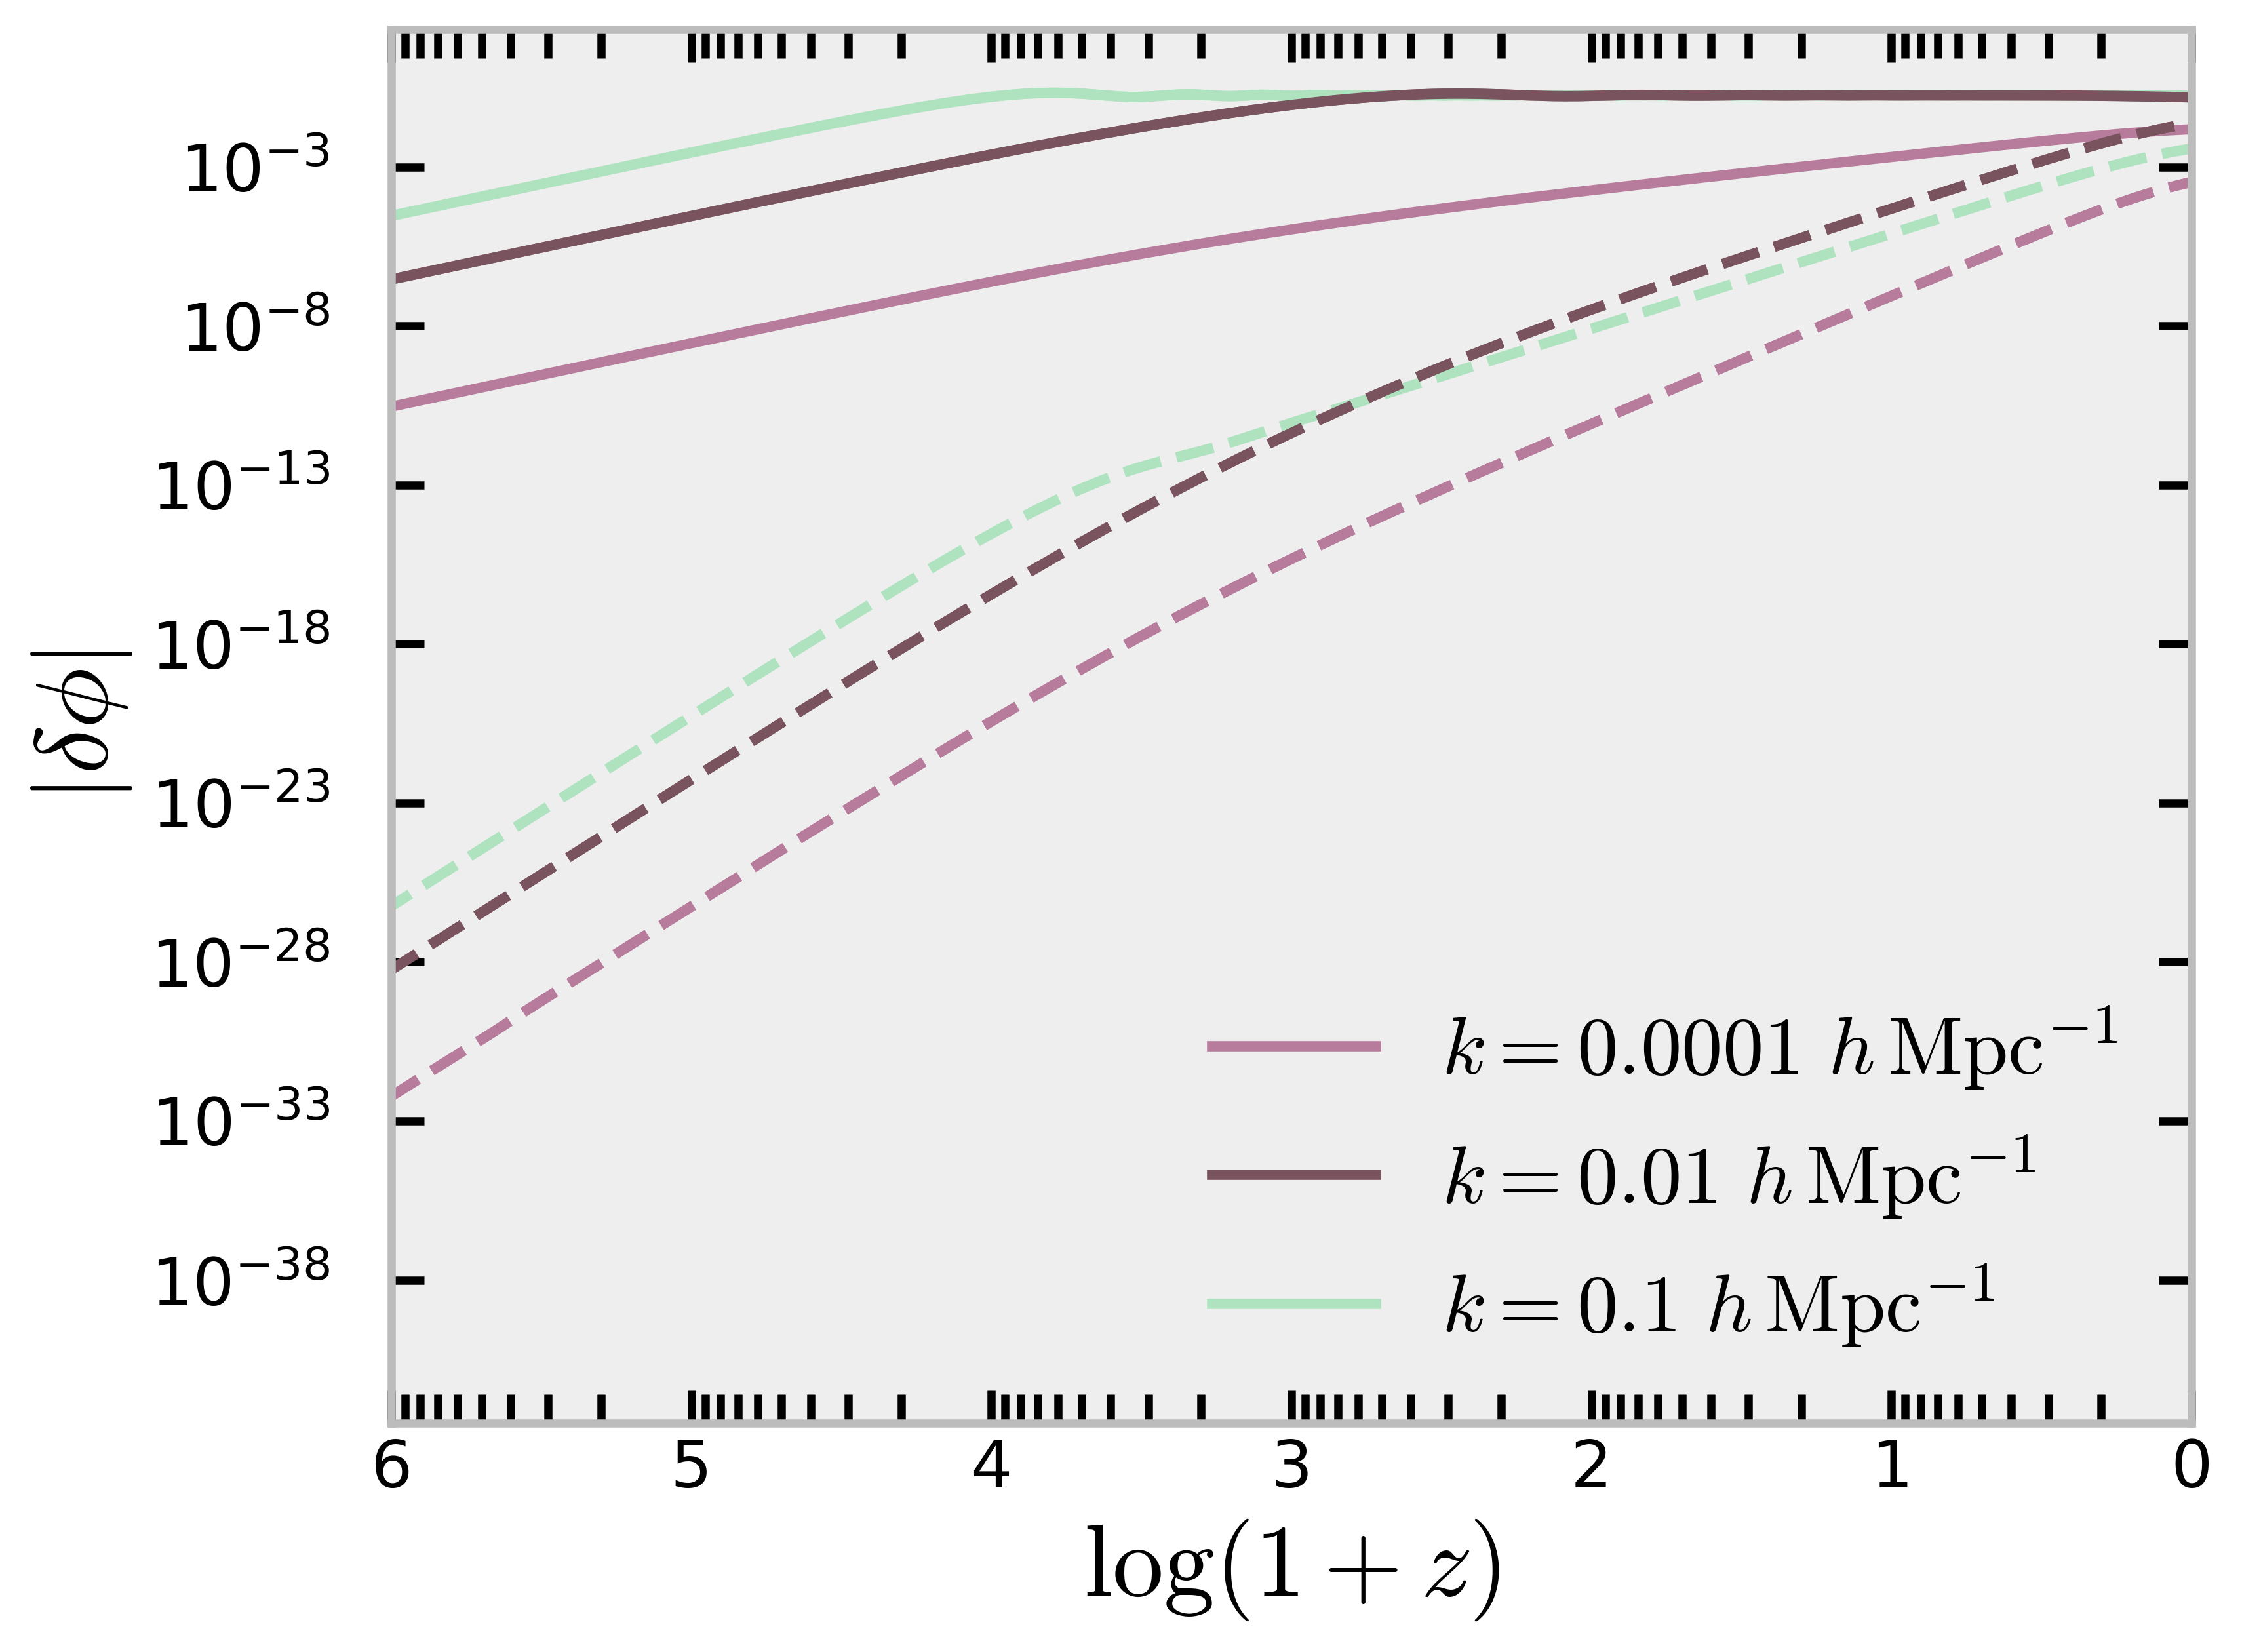

In [30]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

fig, ax0 = plt.subplots(figsize=(8, 6))  # one panel only
ls = ['-', '--', '-.', ':', (0, (5, 1))]


def build_interp1d(x, y, kind='linear', clamp=True):
    """Return an interp1d callable with sorted, duplicate-free x."""
    x = np.asarray(x)
    y = np.asarray(y)
    order = np.argsort(x)
    x = x[order]
    y = y[order]

    xu, inv, cnt = np.unique(x, return_inverse=True, return_counts=True)
    if np.any(cnt > 1):
        yu = np.zeros_like(xu, dtype=float)
        np.add.at(yu, inv, y)  # average duplicates
        yu /= cnt
    else:
        yu = y

    fill = (yu[0], yu[-1]) if clamp else 'extrapolate'
    return interp1d(
        xu, yu, kind=kind, bounds_error=False, fill_value=fill, assume_sorted=True
    )


def interp_bg_to_pert(bg, key, a_target, kind='linear', clamp=True):
    """Interpolate background quantity 'key' onto perturbation a-grid using interp1d."""
    z_bg = np.asarray(bg['z'])
    a_bg = 1.0 / (1.0 + z_bg)
    y_bg = np.asarray(bg[key])
    f = build_interp1d(a_bg, y_bg, kind=kind, clamp=clamp)
    return f(a_target)


def pick_first_key(d, candidates):
    for k in candidates:
        if k in d:
            return k
    raise KeyError(f"None of the keys found: {candidates}")


for ik, index_k in enumerate([0,1, 2]):  # loop over k values
    color_idx = ik

    for ib, index in enumerate([4, 0]):  # loop over beta values
        cosmoPerturb = cosmo[index].get_perturbations()
        cosmoBack = cosmo[index].get_background()

        pblock = cosmoPerturb['scalar'][index_k]
        a = pblock['a']  # perturbation a-grid
        z = 1 / a - 1

        delta_rho_scf = pblock['delta_rho_scf']
        delta_phi = pblock['delta_phi_scf']
        delta_phi_prime = pblock['delta_phi_prime_scf']
        psi = pblock['psi']

        h0 = h0s[index]
        f0 = f0s[index]
        print(f0)

        delta_s = A0s[index] * pow(k_sorted[index_k], n0s[index])

        # --- interpolate background pieces onto pert grid
        Vphi_key = pick_first_key(cosmoBack, ["V'_scf", "V_prime_scf", "Vphi_prime_scf"])
        Vphi_on_pert = interp_bg_to_pert(cosmoBack, Vphi_key, a, kind='linear', clamp=True)

        Vphiphi_key = pick_first_key(
            cosmoBack, ["V''_scf", "V_primeprime_scf", "Vphi_primeprime_scf"]
        )
        Vphiphi_on_pert = interp_bg_to_pert(cosmoBack, Vphiphi_key, a, kind='linear', clamp=True)

        phi_key = pick_first_key(cosmoBack, ["phi_scf", "phi_scf"])
        phi_on_pert = interp_bg_to_pert(cosmoBack, phi_key, a, kind='linear', clamp=True)

        phi_prime_key = pick_first_key(cosmoBack, ["phi'_scf", "phi_prime_scf"])
        phi_prime_on_pert = interp_bg_to_pert(cosmoBack, phi_prime_key, a, kind='linear', clamp=True)

        H_key = pick_first_key(cosmoBack, ['H [1/Mpc]', 'H[1/Mpc]', 'H'])
        H_on_pert = interp_bg_to_pert(cosmoBack, H_key, a, kind='linear', clamp=True)

        # label only once per k
        label_str = (
            fr'$k = {(k_sorted[index_k]/0.67556):.3g}\ h\,\mathrm{{Mpc}}^{{-1}}$'
            if ib == 0 else None
        )
        ax0.plot(1 + z, np.abs(delta_phi), label=label_str, lw=lw, ls=ls[ib], c=color[color_idx])

        # Optional horizon/k lines:
        # if ib == 0:
        #     ax0.plot(a, horizon, lw=lw, ls=':', c=color[color_idx+2])
        #     ax0.hlines(y=k_sorted[index_k], xmin=a[0], xmax=a[-1],
        #                lw=lw, ls='-.', colors=color[color_idx+3])

        kk = k_sorted[index_k]
        print(kk * kk)
        print(Vphiphi_on_pert[-1])
        print(a[-1] * H_on_pert[-1] * a[-1] * H_on_pert[-1])
        print(psi[-1])

        # ax0.plot(
        #     1 + z,
        #     -1e0 * Vphi_on_pert * pow(a, 2) * psi / (0.04 * (kk * kk + pow(a, 2) * Vphiphi_on_pert)),
        #     lw=lw / 2,
        #     ls='-',
        #     c='red'
        # )
        # ax0.plot(1 + z, 1e-1 * pow(a, 3), lw=lw / 2, ls='-', c='blue')

# Set axis labels and scales
ax0.set_xscale('log')
ax0.set_yscale('log')
ax0.set_xlabel(r'$\log(1+z)$', size=25)
ax0.set_ylabel(r'$|\delta\phi|$', size=25)
ax0.set_xlim(1e6, 1)
# ax0.set_ylim(0.01, 1)

original_labels = ax0.get_xticks()
labels = []
for label in original_labels:
    labels.append(int(np.log10(label)))
ax0.set_xticklabels(labels)

# Styling
ax0.tick_params(axis='both', which='major', labelsize=16, width=1.1)
ax0.legend(loc='lower right', frameon=boolean, prop={'size': 20}, ncol=1)
ax0.tick_params(axis='both', which='both', labelsize=16)
ax0.tick_params(axis='both', which='both', labelsize=16)

#---------------------------------------------------------------------------------> change ticklabels distance
ax1.tick_params(axis='both', which='both', labelsize=16)
ax1.tick_params(axis='both', which='both', labelsize=16)
for tick in ax1.xaxis.get_major_ticks():
    tick.set_pad(15)
for tick in ax0.yaxis.get_major_ticks():
    tick.set_pad(15)
for tick in ax1.yaxis.get_major_ticks():
    tick.set_pad(15)

ax0.tick_params(axis='both', which='both', labelsize=16)
ax0.xaxis.set_tick_params(which='major', size=8, width=2, direction='in', top='on')
ax0.xaxis.set_tick_params(which='minor', size=7, width=2, direction='in', top='on')
ax0.yaxis.set_tick_params(which='major', size=8, width=2, direction='in', right='on')
ax0.yaxis.set_tick_params(which='minor', size=7, width=2, direction='in', right='on')

ax1.tick_params(axis='both', which='both', labelsize=16)
ax1.xaxis.set_tick_params(which='major', size=8, width=2, direction='in', top='on')
ax1.xaxis.set_tick_params(which='minor', size=7, width=2, direction='in', top='on')
ax1.yaxis.set_tick_params(which='major', size=8, width=2, direction='in', right='on')
ax1.yaxis.set_tick_params(which='minor', size=7, width=2, direction='in', right='on')

for ax in (ax0, ax1):  # copy the list so we don't iterate over lines we add
    lines = list(ax.get_lines())[1:]
    for ln in lines[::-1]:
        ax.plot(
            ln.get_xdata(),
            ln.get_ydata(),
            ls=ln.get_linestyle(),
            lw=ln.get_linewidth(),
            c=ln.get_color(),
            marker=ln.get_marker(),
            markersize=ln.get_markersize(),
            alpha=ln.get_alpha() if ln.get_alpha() is not None else 1.0,
            label="_nolegend_",  # labels starting with '_' are ignored by legend()
        )

fig.tight_layout()
plt.savefig('deltaphi_ks3.pdf')
plt.show()


-0.47069249408712066
-1.702745772348129
-695.5986265559592
-711.6717048073291
-11474.136092251954
-13985.90195307959


/var/folders/91/jymwbq1j1nng0wqyd6yvbm100000gn/T/ipykernel_82780/4293231626.py:43: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax0.set_xticklabels(labels)
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


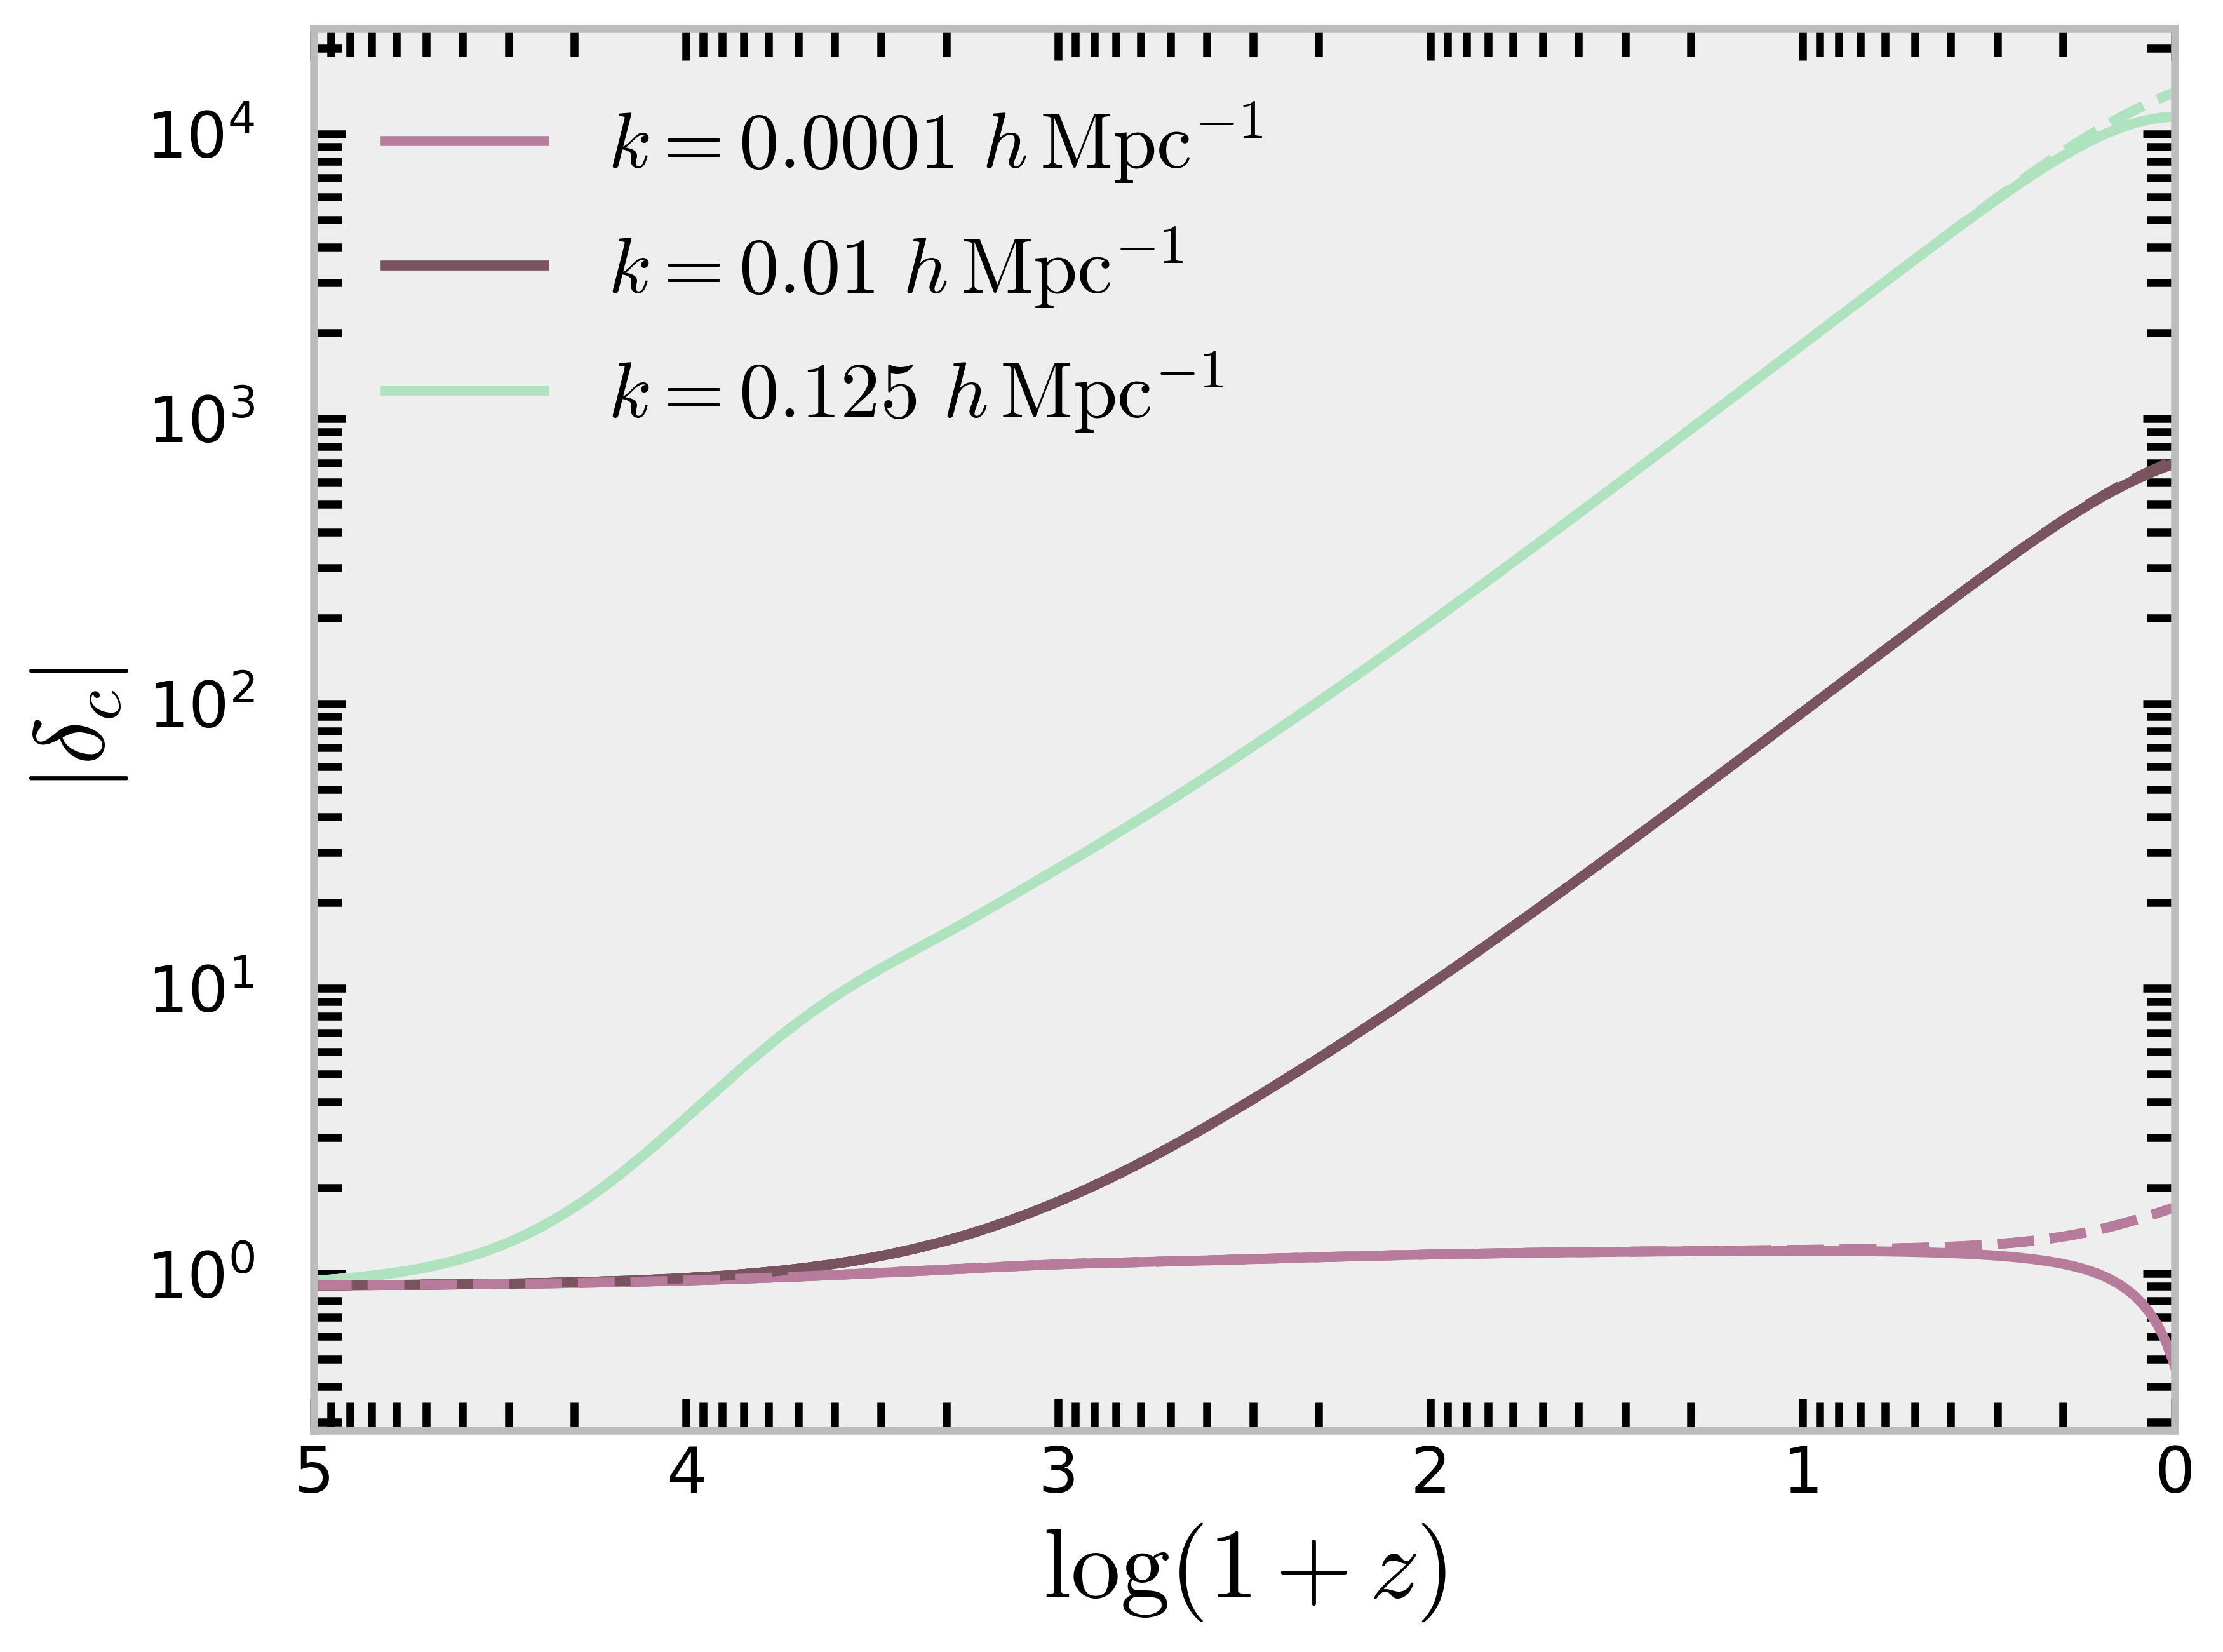

In [31]:
fig, ax0 = plt.subplots(figsize=(8,6))  # one panel only

ls = ['-','--','-.', ':', (0,(5,1))]

plt.style.use('bmh')
plt.style.use(['ipynb', 'use_mathtext','colors5-light'])


for ik, index_k in enumerate([0,1,3]):  # loop over k values
    color_idx = ik  # color depends on k
    
    for ib, index in enumerate([2,0]):  # loop over beta values
        cosmoPerturb = cosmo[index].get_perturbations()
        cosmoPerturb0 = cosmo[0].get_perturbations()
        cosmoBack = cosmo[index].get_background()

        a = cosmoPerturb['scalar'][index_k]['a']
        z = 1/a - 1
        delta_phi = cosmoPerturb['scalar'][index_k]['delta_phi_scf']
        delta_phi0 = cosmoPerturb0['scalar'][index_k]['delta_phi_scf']
        delta_c = cosmoPerturb['scalar'][index_k]['delta_edm']
        delta_c0 = cosmoPerturb0['scalar'][index_k]['delta_edm']

        # label only once per k (when ib == 0)
        label_str = fr'$k = {(k_sorted[index_k]/0.67556):.3g}\ h\,\mathrm{{Mpc}}^{{-1}}$' if ib == 0 else None

        ax0.plot(1+z, -delta_c,
                 label=label_str,
                 lw=lw, ls=ls[ib], c=color[color_idx])
        print(delta_c[-1])
        

# Set axis labels and scales
ax0.set_xscale('log')
ax0.set_yscale('log')
ax0.set_xlabel(r'$\log(1+z)$', size=25)
ax0.set_ylabel(r'$|\delta_c|$', size=25)
ax0.set_xlim(1e5, 1)
original_labels = ax0.get_xticks()
labels = []
for label in original_labels:
    labels.append(int(np.log10(label)))
ax0.set_xticklabels(labels)

# Styling
ax0.tick_params(axis='both', which='major', labelsize=16, width=1.1)
ax0.legend(loc='upper left', frameon=boolean, prop={'size': 20}, ncol=1)

ax0.tick_params(axis='both', which='both', labelsize=16)
ax0.tick_params(axis='both', which='both', labelsize=16)

#---------------------------------------------------------------------------------> change ticklabels distance
ax1.tick_params(axis='both', which='both', labelsize=16)
ax1.tick_params(axis='both', which='both', labelsize=16)

for tick in ax1.xaxis.get_major_ticks():
    tick.set_pad(15)
for tick in ax0.yaxis.get_major_ticks():
    tick.set_pad(15)
for tick in ax1.yaxis.get_major_ticks():
    tick.set_pad(15)
    
ax0.tick_params(axis='both', which='both', labelsize=16)

    
ax0.xaxis.set_tick_params(which='major', size=8, width=2, direction='in', top='on')
ax0.xaxis.set_tick_params(which='minor', size=7, width=2, direction='in', top='on')
ax0.yaxis.set_tick_params(which='major', size=8, width=2, direction='in', right='on')
ax0.yaxis.set_tick_params(which='minor', size=7, width=2, direction='in', right='on')

ax1.tick_params(axis='both', which='both', labelsize=16)

    
ax1.xaxis.set_tick_params(which='major', size=8, width=2, direction='in', top='on')
ax1.xaxis.set_tick_params(which='minor', size=7, width=2, direction='in', top='on')
ax1.yaxis.set_tick_params(which='major', size=8, width=2, direction='in', right='on')
ax1.yaxis.set_tick_params(which='minor', size=7, width=2, direction='in', right='on')

for ax in (ax0, ax1):
    # copy the list so we don't iterate over lines we add
    lines = list(ax.get_lines())[1:]
    for ln in lines[::-1]:
        ax.plot(
            ln.get_xdata(), ln.get_ydata(),
            ls=ln.get_linestyle(),
            lw=ln.get_linewidth(),
            c=ln.get_color(),
            marker=ln.get_marker(),
            markersize=ln.get_markersize(),
            alpha=ln.get_alpha() if ln.get_alpha() is not None else 1.0,
            label="_nolegend_",  # labels starting with '_' are ignored by legend()
        )

fig.tight_layout()
plt.savefig('deltac_ks3.pdf')
plt.show()


1.7868853926848922e-05
4
1.058795316853949e-05
0
0.08262592191107931
4


/var/folders/91/jymwbq1j1nng0wqyd6yvbm100000gn/T/ipykernel_82780/2260019665.py:39: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax0.set_xticklabels(labels)
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


0.08219017384346186
0


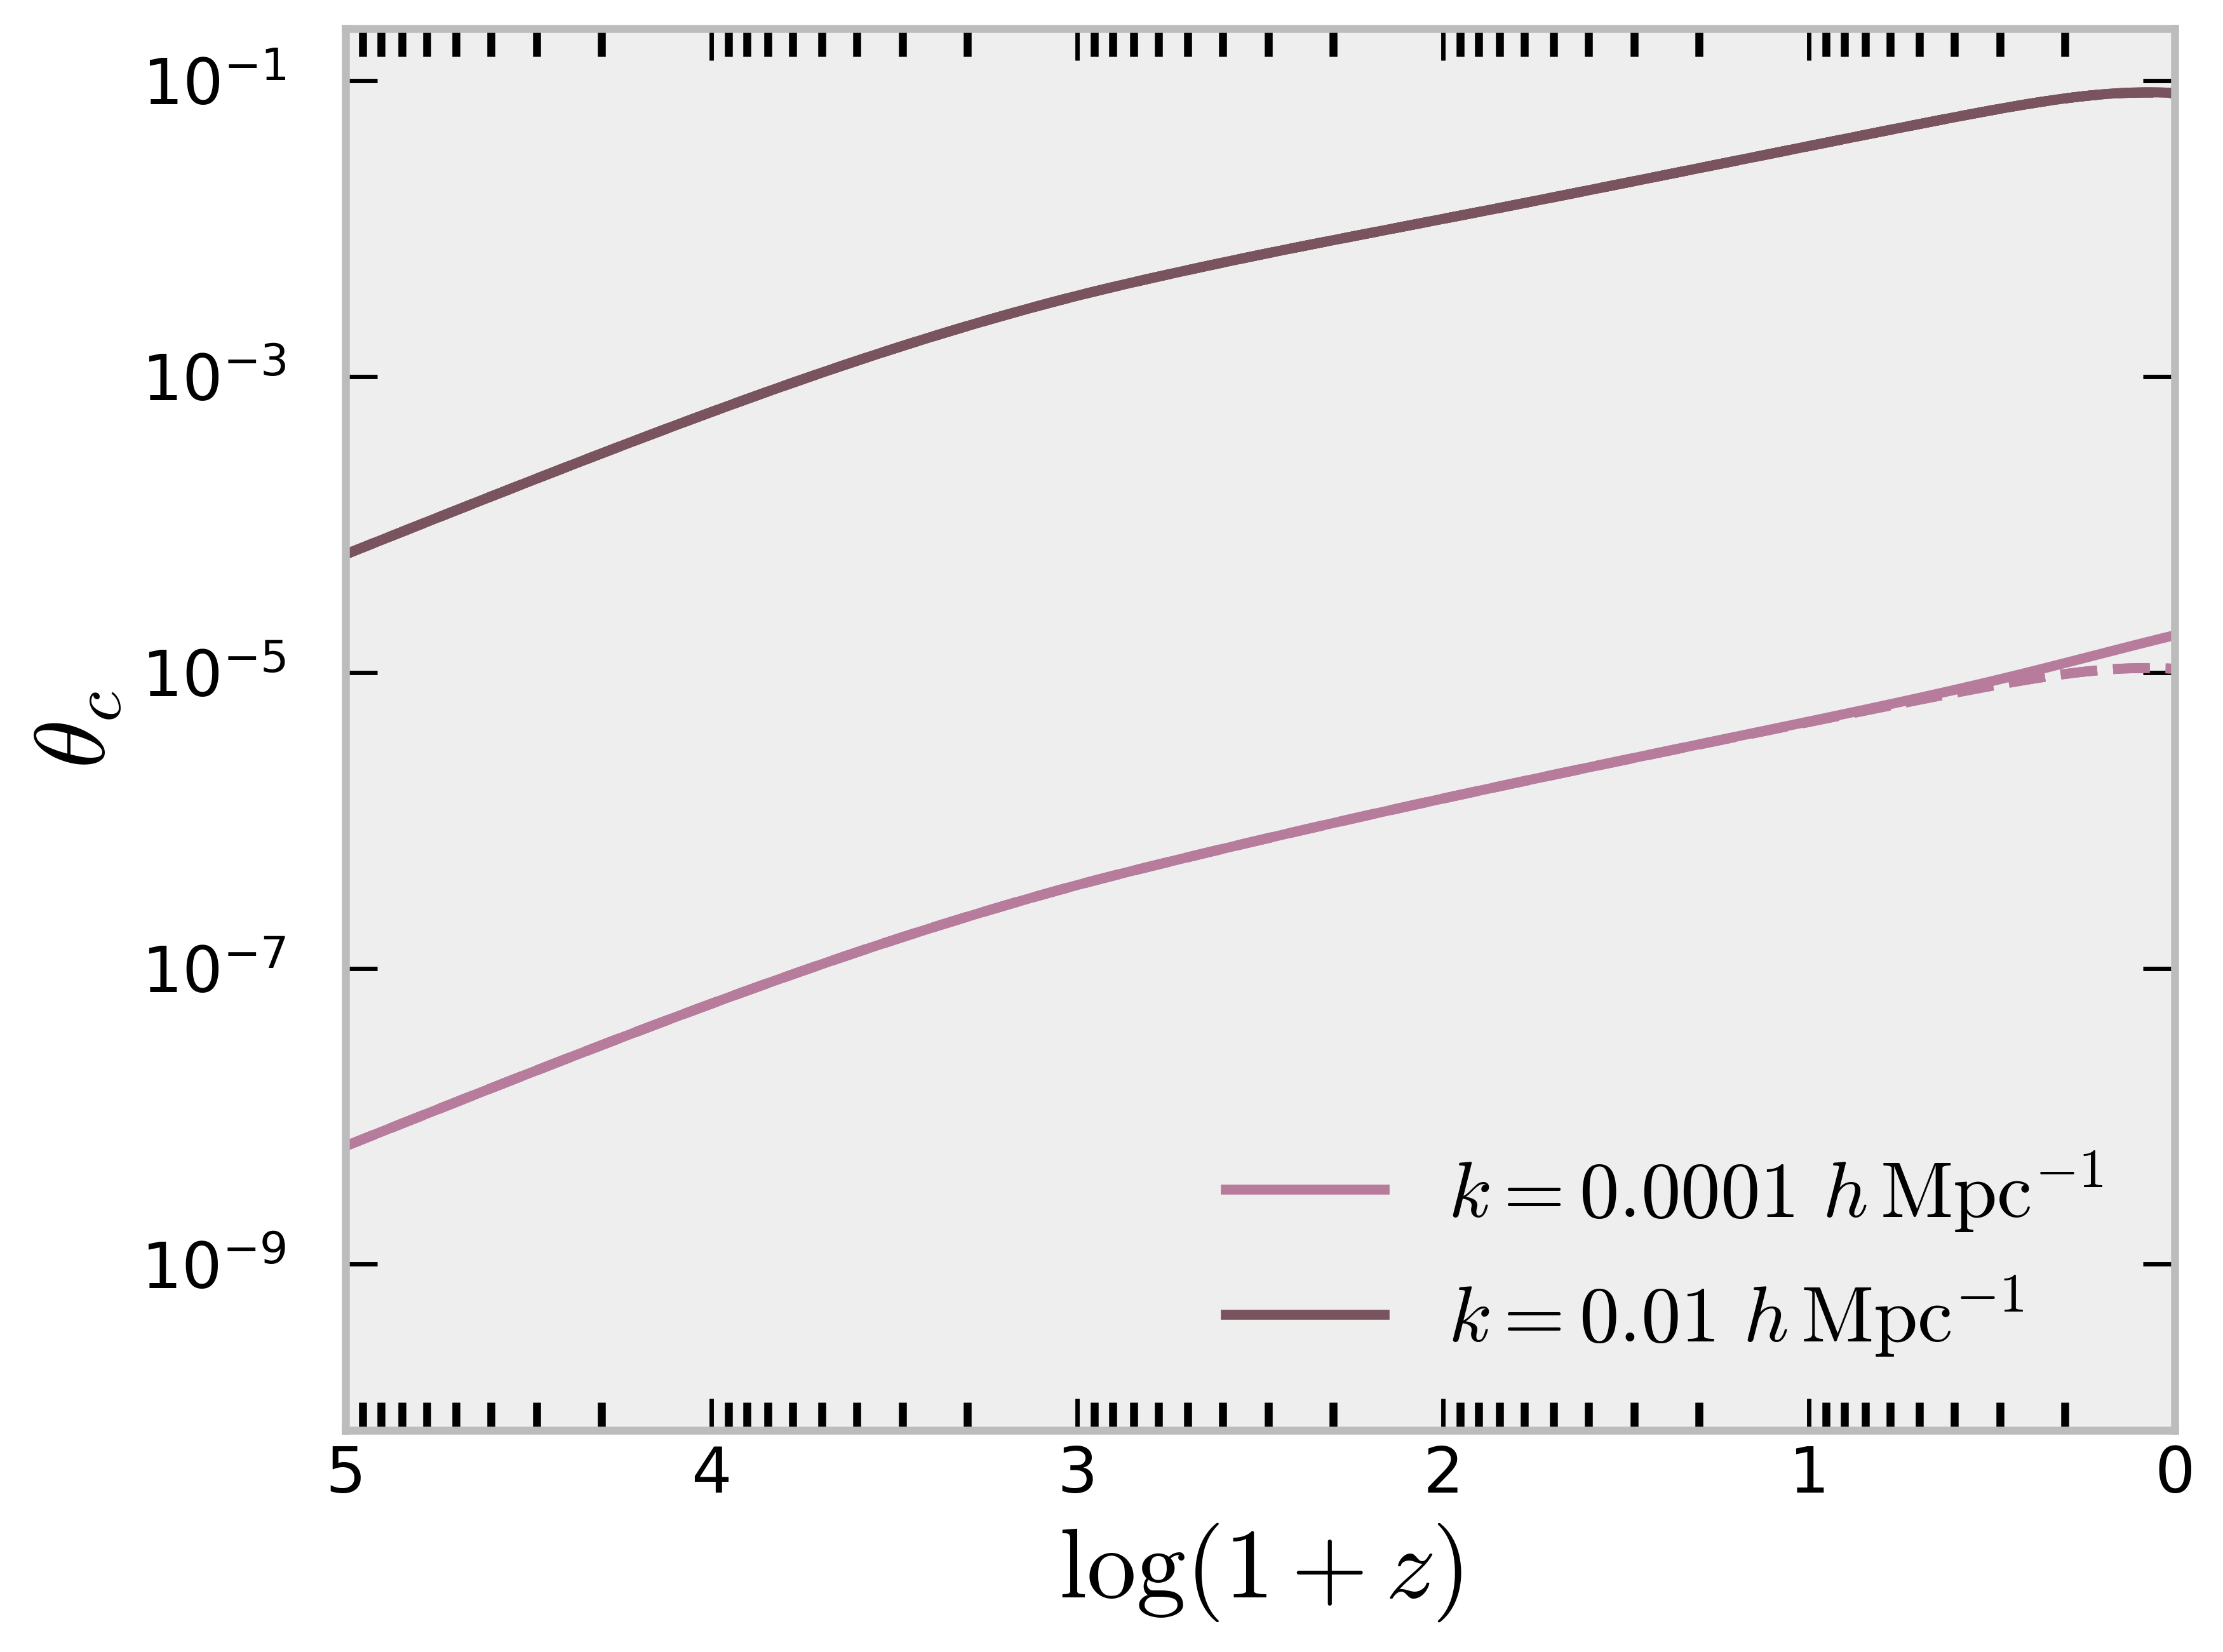

In [32]:
fig, ax0 = plt.subplots(figsize=(8,6))  # one panel only

ls = ['-','--','-.', ':', (0,(5,1))]

for ik, index_k in enumerate([0, 1]):  # loop over k values
    color_idx = ik  # color depends on k
    
    for ib, index in enumerate([4,0]):  # loop over beta values
        cosmoPerturb = cosmo[index].get_perturbations()
        cosmoPerturb0 = cosmo[0].get_perturbations()
        cosmoBack = cosmo[index].get_background()

        a = cosmoPerturb['scalar'][index_k]['a']
        z = 1/a - 1
        delta_phi = cosmoPerturb['scalar'][index_k]['delta_phi_scf']
        delta_phi0 = cosmoPerturb0['scalar'][index_k]['delta_phi_scf']
        theta_c = cosmoPerturb['scalar'][index_k]['theta_cdm']
        theta_c0 = cosmoPerturb0['scalar'][index_k]['theta_cdm']
        print(theta_c[-1])
        print(index)

        # label only once per k (when ib == 0)
        label_str = fr'$k = {(k_sorted[index_k]/0.67556):.3g}\ h\,\mathrm{{Mpc}}^{{-1}}$' if ib == 0 else None

        ax0.plot(1+z, theta_c,
                 label=label_str,
                 lw=lw, ls=ls[ib], c=color[color_idx])

# Set axis labels and scales
ax0.set_xscale('log')
ax0.set_yscale('log')
ax0.set_xlabel(r'$\log(1+z)$', size=25)
ax0.set_ylabel(r'$\theta_c$', size=25)
ax0.set_xlim(1e5, 1)
original_labels = ax0.get_xticks()
labels = []
for label in original_labels:
    labels.append(int(np.log10(label)))
ax0.set_xticklabels(labels)

ax0.tick_params(axis='both', which='both', labelsize=16)
ax0.tick_params(axis='both', which='both', labelsize=16)

#---------------------------------------------------------------------------------> change ticklabels distance
ax1.tick_params(axis='both', which='both', labelsize=16)
ax1.tick_params(axis='both', which='both', labelsize=16)

for tick in ax1.xaxis.get_major_ticks():
    tick.set_pad(15)
for tick in ax0.yaxis.get_major_ticks():
    tick.set_pad(15)
for tick in ax1.yaxis.get_major_ticks():
    tick.set_pad(15)
    
ax0.tick_params(axis='both', which='both', labelsize=16)

    
ax0.xaxis.set_tick_params(which='major', size=8, width=2, direction='in', top='on')
ax0.xaxis.set_tick_params(which='minor', size=7, width=2, direction='in', top='on')
ax0.yaxis.set_tick_params(which='major', size=8, width=2, direction='in', right='on')
ax0.yaxis.set_tick_params(which='minor', size=7, width=2, direction='in', right='on')

ax1.tick_params(axis='both', which='both', labelsize=16)

    
ax1.xaxis.set_tick_params(which='major', size=8, width=2, direction='in', top='on')
ax1.xaxis.set_tick_params(which='minor', size=7, width=2, direction='in', top='on')
ax1.yaxis.set_tick_params(which='major', size=8, width=2, direction='in', right='on')
ax1.yaxis.set_tick_params(which='minor', size=7, width=2, direction='in', right='on')

for ax in (ax0, ax1):
    # copy the list so we don't iterate over lines we add
    lines = list(ax.get_lines())[1:]
    for ln in lines[::-1]:
        ax.plot(
            ln.get_xdata(), ln.get_ydata(),
            ls=ln.get_linestyle(),
            lw=ln.get_linewidth(),
            c=ln.get_color(),
            marker=ln.get_marker(),
            markersize=ln.get_markersize(),
            alpha=ln.get_alpha() if ln.get_alpha() is not None else 1.0,
            label="_nolegend_",  # labels starting with '_' are ignored by legend()
        )

# Styling
ax0.tick_params(axis='both', which='major', labelsize=16, width=1.1)
ax0.legend(loc='lower right', frameon=boolean, prop={'size': 20}, ncol=1)

fig.tight_layout()
plt.savefig('thetac_ks3.pdf')
plt.show()


/var/folders/91/jymwbq1j1nng0wqyd6yvbm100000gn/T/ipykernel_82780/689910111.py:69: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax0.set_xticklabels(labels)
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


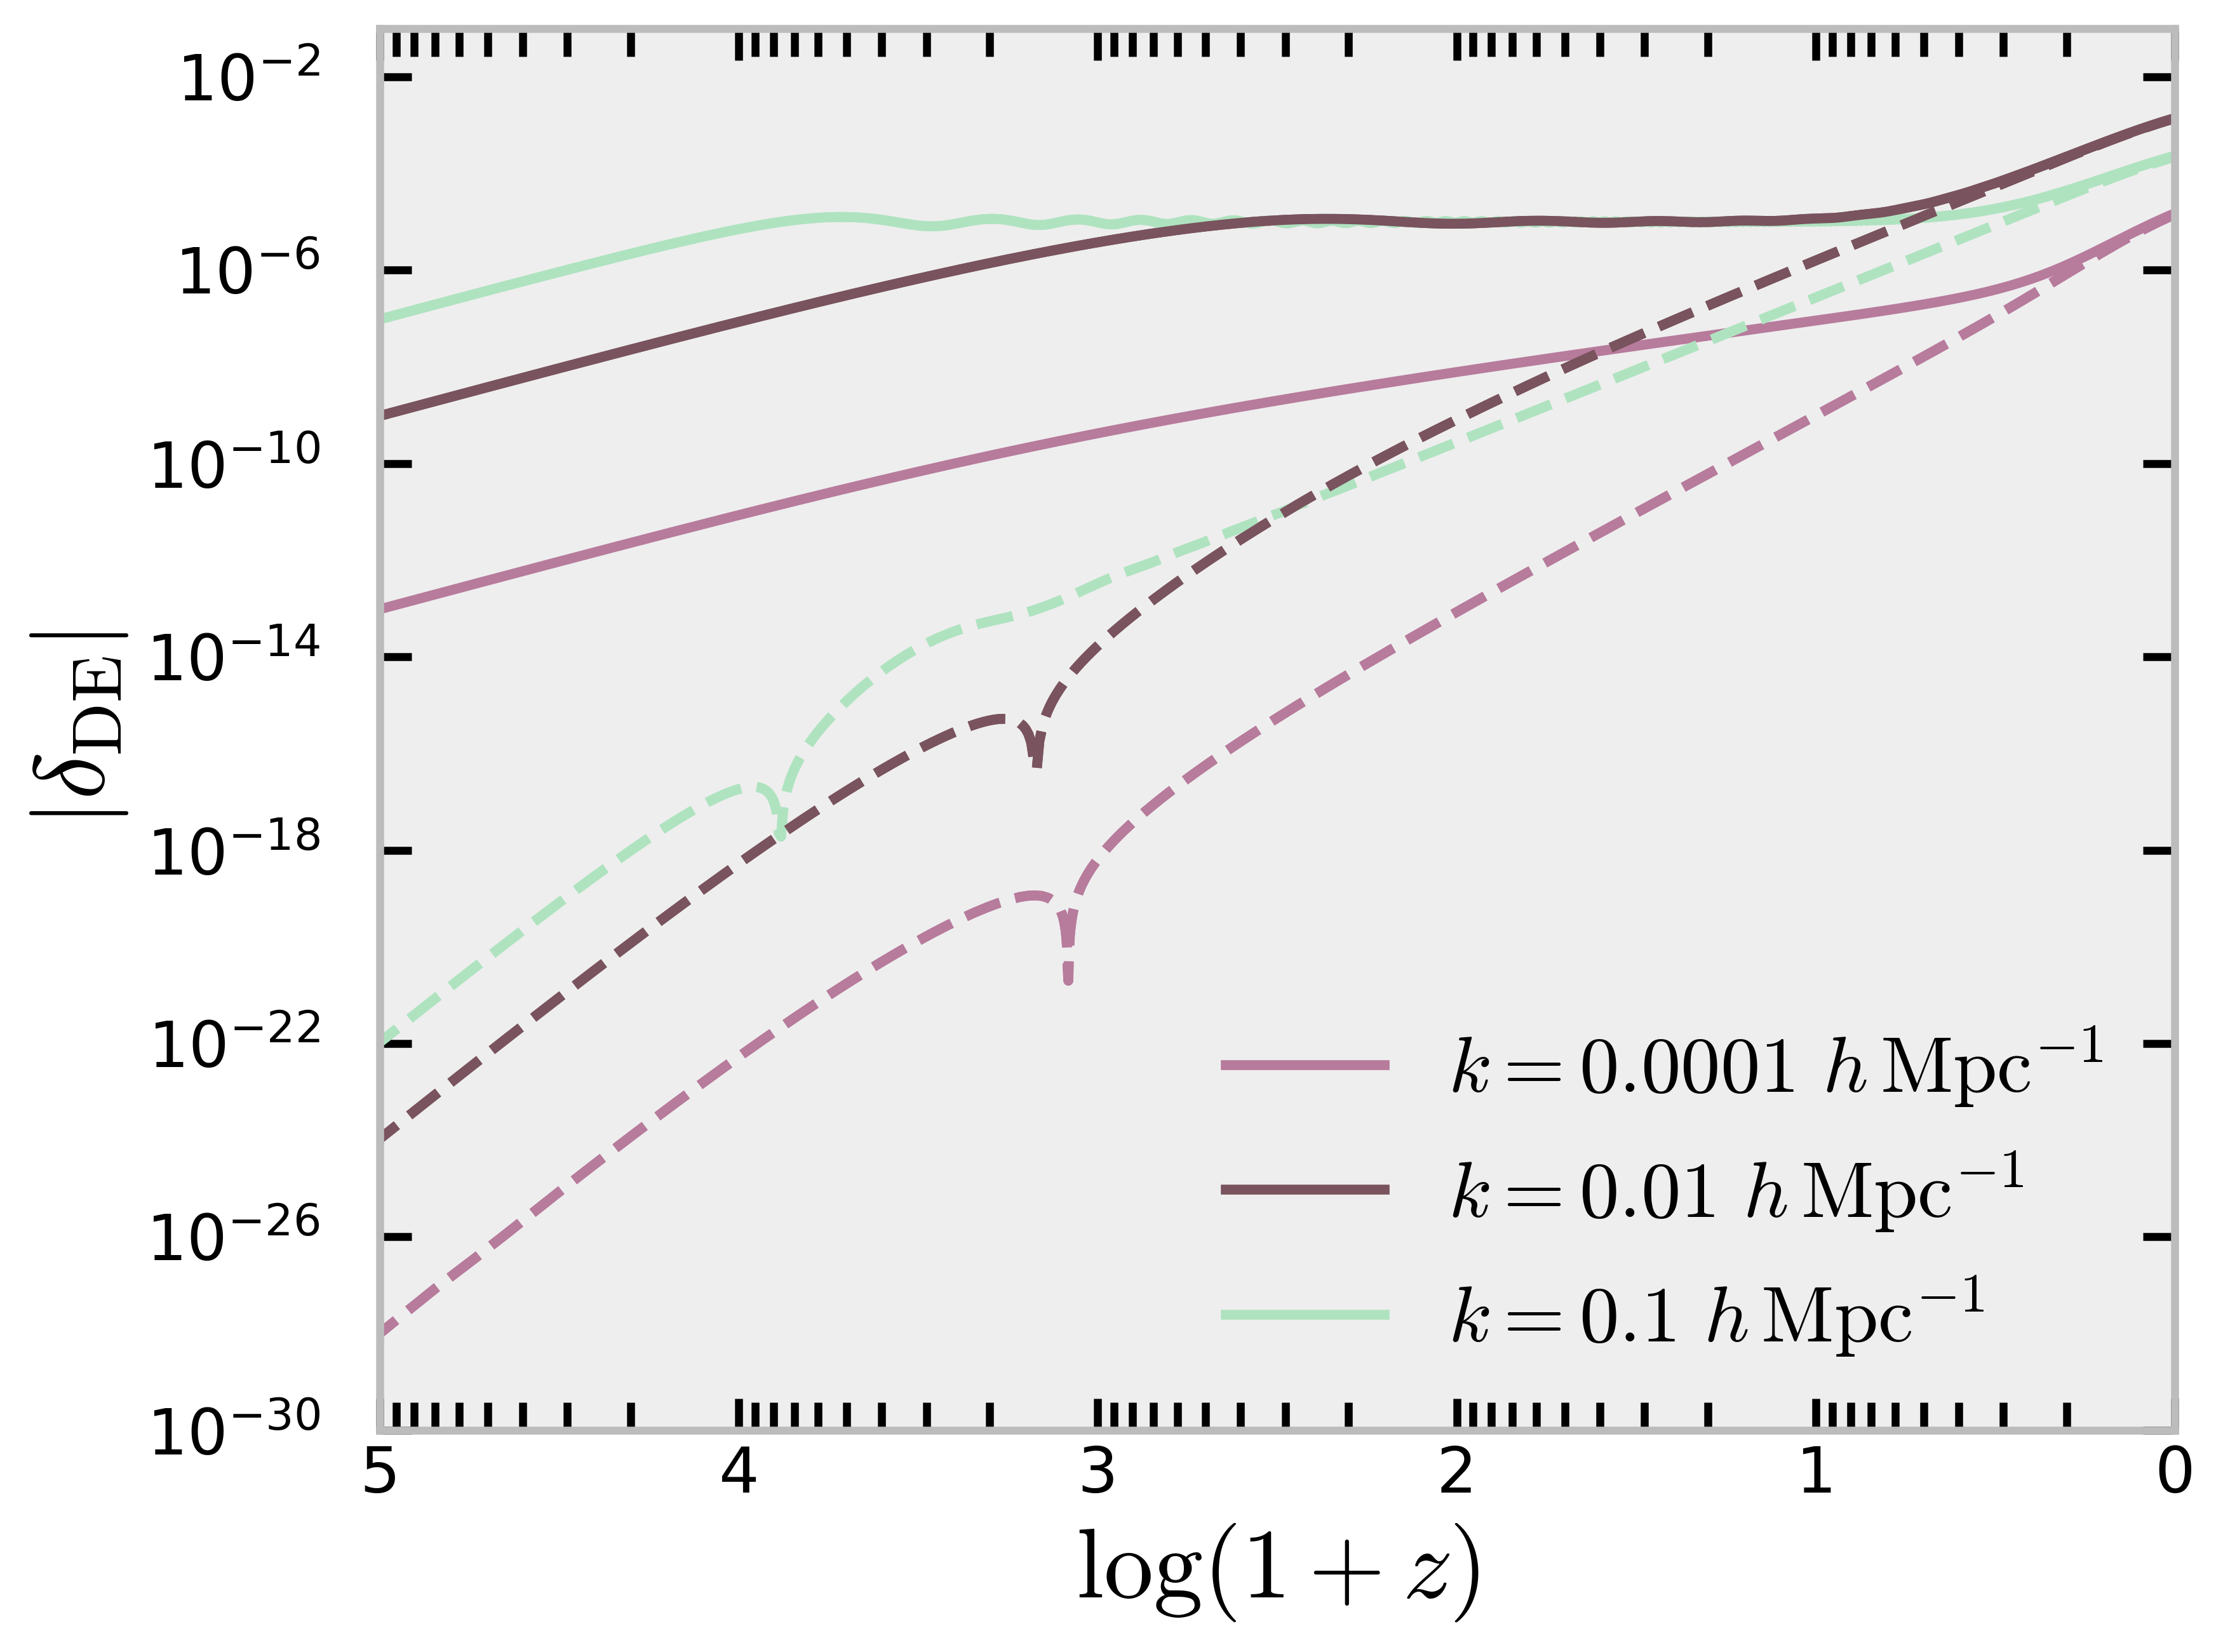

In [33]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

fig, ax0 = plt.subplots(figsize=(8,6))  # one panel only
ls = ['-','--','-.', ':', (0,(5,1))]

def build_interp1d(x, y, kind='cubic', clamp=False):
    x = np.asarray(x); y = np.asarray(y)
    order = np.argsort(x)
    x = x[order]; y = y[order]
    xu, inv, cnt = np.unique(x, return_inverse=True, return_counts=True)
    if np.any(cnt > 1):
        yu = np.zeros_like(xu, dtype=float)
        np.add.at(yu, inv, y)   # sum y per unique x
        yu /= cnt               # average duplicates
    else:
        yu = y
    fill = (yu[0], yu[-1]) if clamp else 'extrapolate'
    return interp1d(xu, yu, kind=kind, bounds_error=False, fill_value=fill, assume_sorted=True)

def interp_bg_to_pert(bg, key, a_target, kind='cubic', clamp=False):
    z_bg = np.asarray(bg['z'])
    a_bg = 1.0/(1.0 + z_bg)
    y_bg = np.asarray(bg[key])
    f = build_interp1d(a_bg, y_bg, kind=kind, clamp=clamp)
    return f(a_target)

for ik, index_k in enumerate([0, 1,2]):  # loop over k values
    color_idx = ik  # color depends on k

    for ib, index in enumerate([5, 0]):   # loop over beta values
        cosmoPerturb = cosmo[index].get_perturbations()
        cosmoPerturb0 = cosmo[0].get_perturbations()
        cosmoBack = cosmo[index].get_background()

        pblock = cosmoPerturb['scalar'][index_k]
        a = pblock['a']                          # perturbation a-grid
        z = 1/a - 1
        delta_rho_scf = pblock['delta_rho_scf']

        # choose the DE background energy density field with fallback
        bg_de_key = '(.)rho_scf' if '(.)rho_scf' in cosmoBack else '(.)rho_lambda'
        rho_de_on_pert = interp_bg_to_pert(cosmoBack, bg_de_key, a, kind='linear', clamp=True)

        delta_DE = delta_rho_scf / rho_de_on_pert

        # label only once per k (when ib == 0)
        label_str = fr'$k = {(k_sorted[index_k]/0.67556):.3g}\ h\,\mathrm{{Mpc}}^{{-1}}$' if ib == 0 else None

        # If using log y-scale, ensure positivity
        ax0.plot(1+z, np.abs(delta_DE),
                 label=label_str, lw=lw, ls=ls[ib], c=color[color_idx])
        

# Axes & styling
ax0.set_xscale('log')
ax0.set_yscale('log')
ax0.set_xlabel(r'$\log(1+z)$', size=25)
ax0.set_ylabel(r'$|\delta_{\rm DE}|$', size=25)
ax0.set_xlim(1e5, 1)
ax0.set_ylim(1e-30, 1e-1)
ax0.tick_params(axis='both', which='major', labelsize=16, width=1.1)
ax0.legend(loc='lower right', frameon=boolean, prop={'size': 20}, ncol=1)
original_labels = ax0.get_xticks()
labels = []
for label in original_labels:
    labels.append(int(np.log10(label)))
ax0.set_xticklabels(labels)

ax0.tick_params(axis='both', which='both', labelsize=16)
ax0.tick_params(axis='both', which='both', labelsize=16)

#---------------------------------------------------------------------------------> change ticklabels distance
ax1.tick_params(axis='both', which='both', labelsize=16)
ax1.tick_params(axis='both', which='both', labelsize=16)

for tick in ax1.xaxis.get_major_ticks():
    tick.set_pad(15)
for tick in ax0.yaxis.get_major_ticks():
    tick.set_pad(15)
for tick in ax1.yaxis.get_major_ticks():
    tick.set_pad(15)
    
ax0.tick_params(axis='both', which='both', labelsize=16)

    
ax0.xaxis.set_tick_params(which='major', size=8, width=2, direction='in', top='on')
ax0.xaxis.set_tick_params(which='minor', size=7, width=2, direction='in', top='on')
ax0.yaxis.set_tick_params(which='major', size=8, width=2, direction='in', right='on')
ax0.yaxis.set_tick_params(which='minor', size=7, width=2, direction='in', right='on')

ax1.tick_params(axis='both', which='both', labelsize=16)

    
ax1.xaxis.set_tick_params(which='major', size=8, width=2, direction='in', top='on')
ax1.xaxis.set_tick_params(which='minor', size=7, width=2, direction='in', top='on')
ax1.yaxis.set_tick_params(which='major', size=8, width=2, direction='in', right='on')
ax1.yaxis.set_tick_params(which='minor', size=7, width=2, direction='in', right='on')

for ax in (ax0, ax1):
    # copy the list so we don't iterate over lines we add
    lines = list(ax.get_lines())[1:]
    for ln in lines[::-1]:
        ax.plot(
            ln.get_xdata(), ln.get_ydata(),
            ls=ln.get_linestyle(),
            lw=ln.get_linewidth(),
            c=ln.get_color(),
            marker=ln.get_marker(),
            markersize=ln.get_markersize(),
            alpha=ln.get_alpha() if ln.get_alpha() is not None else 1.0,
            label="_nolegend_",  # labels starting with '_' are ignored by legend()
        )

fig.tight_layout()
plt.savefig('deltade2_ks3.pdf')
plt.show()


0.0001
0.0
0.0001
0.0
0.0001
0.0


/var/folders/91/jymwbq1j1nng0wqyd6yvbm100000gn/T/ipykernel_82780/2237166093.py:97: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax0.set_xticklabels(labels)
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


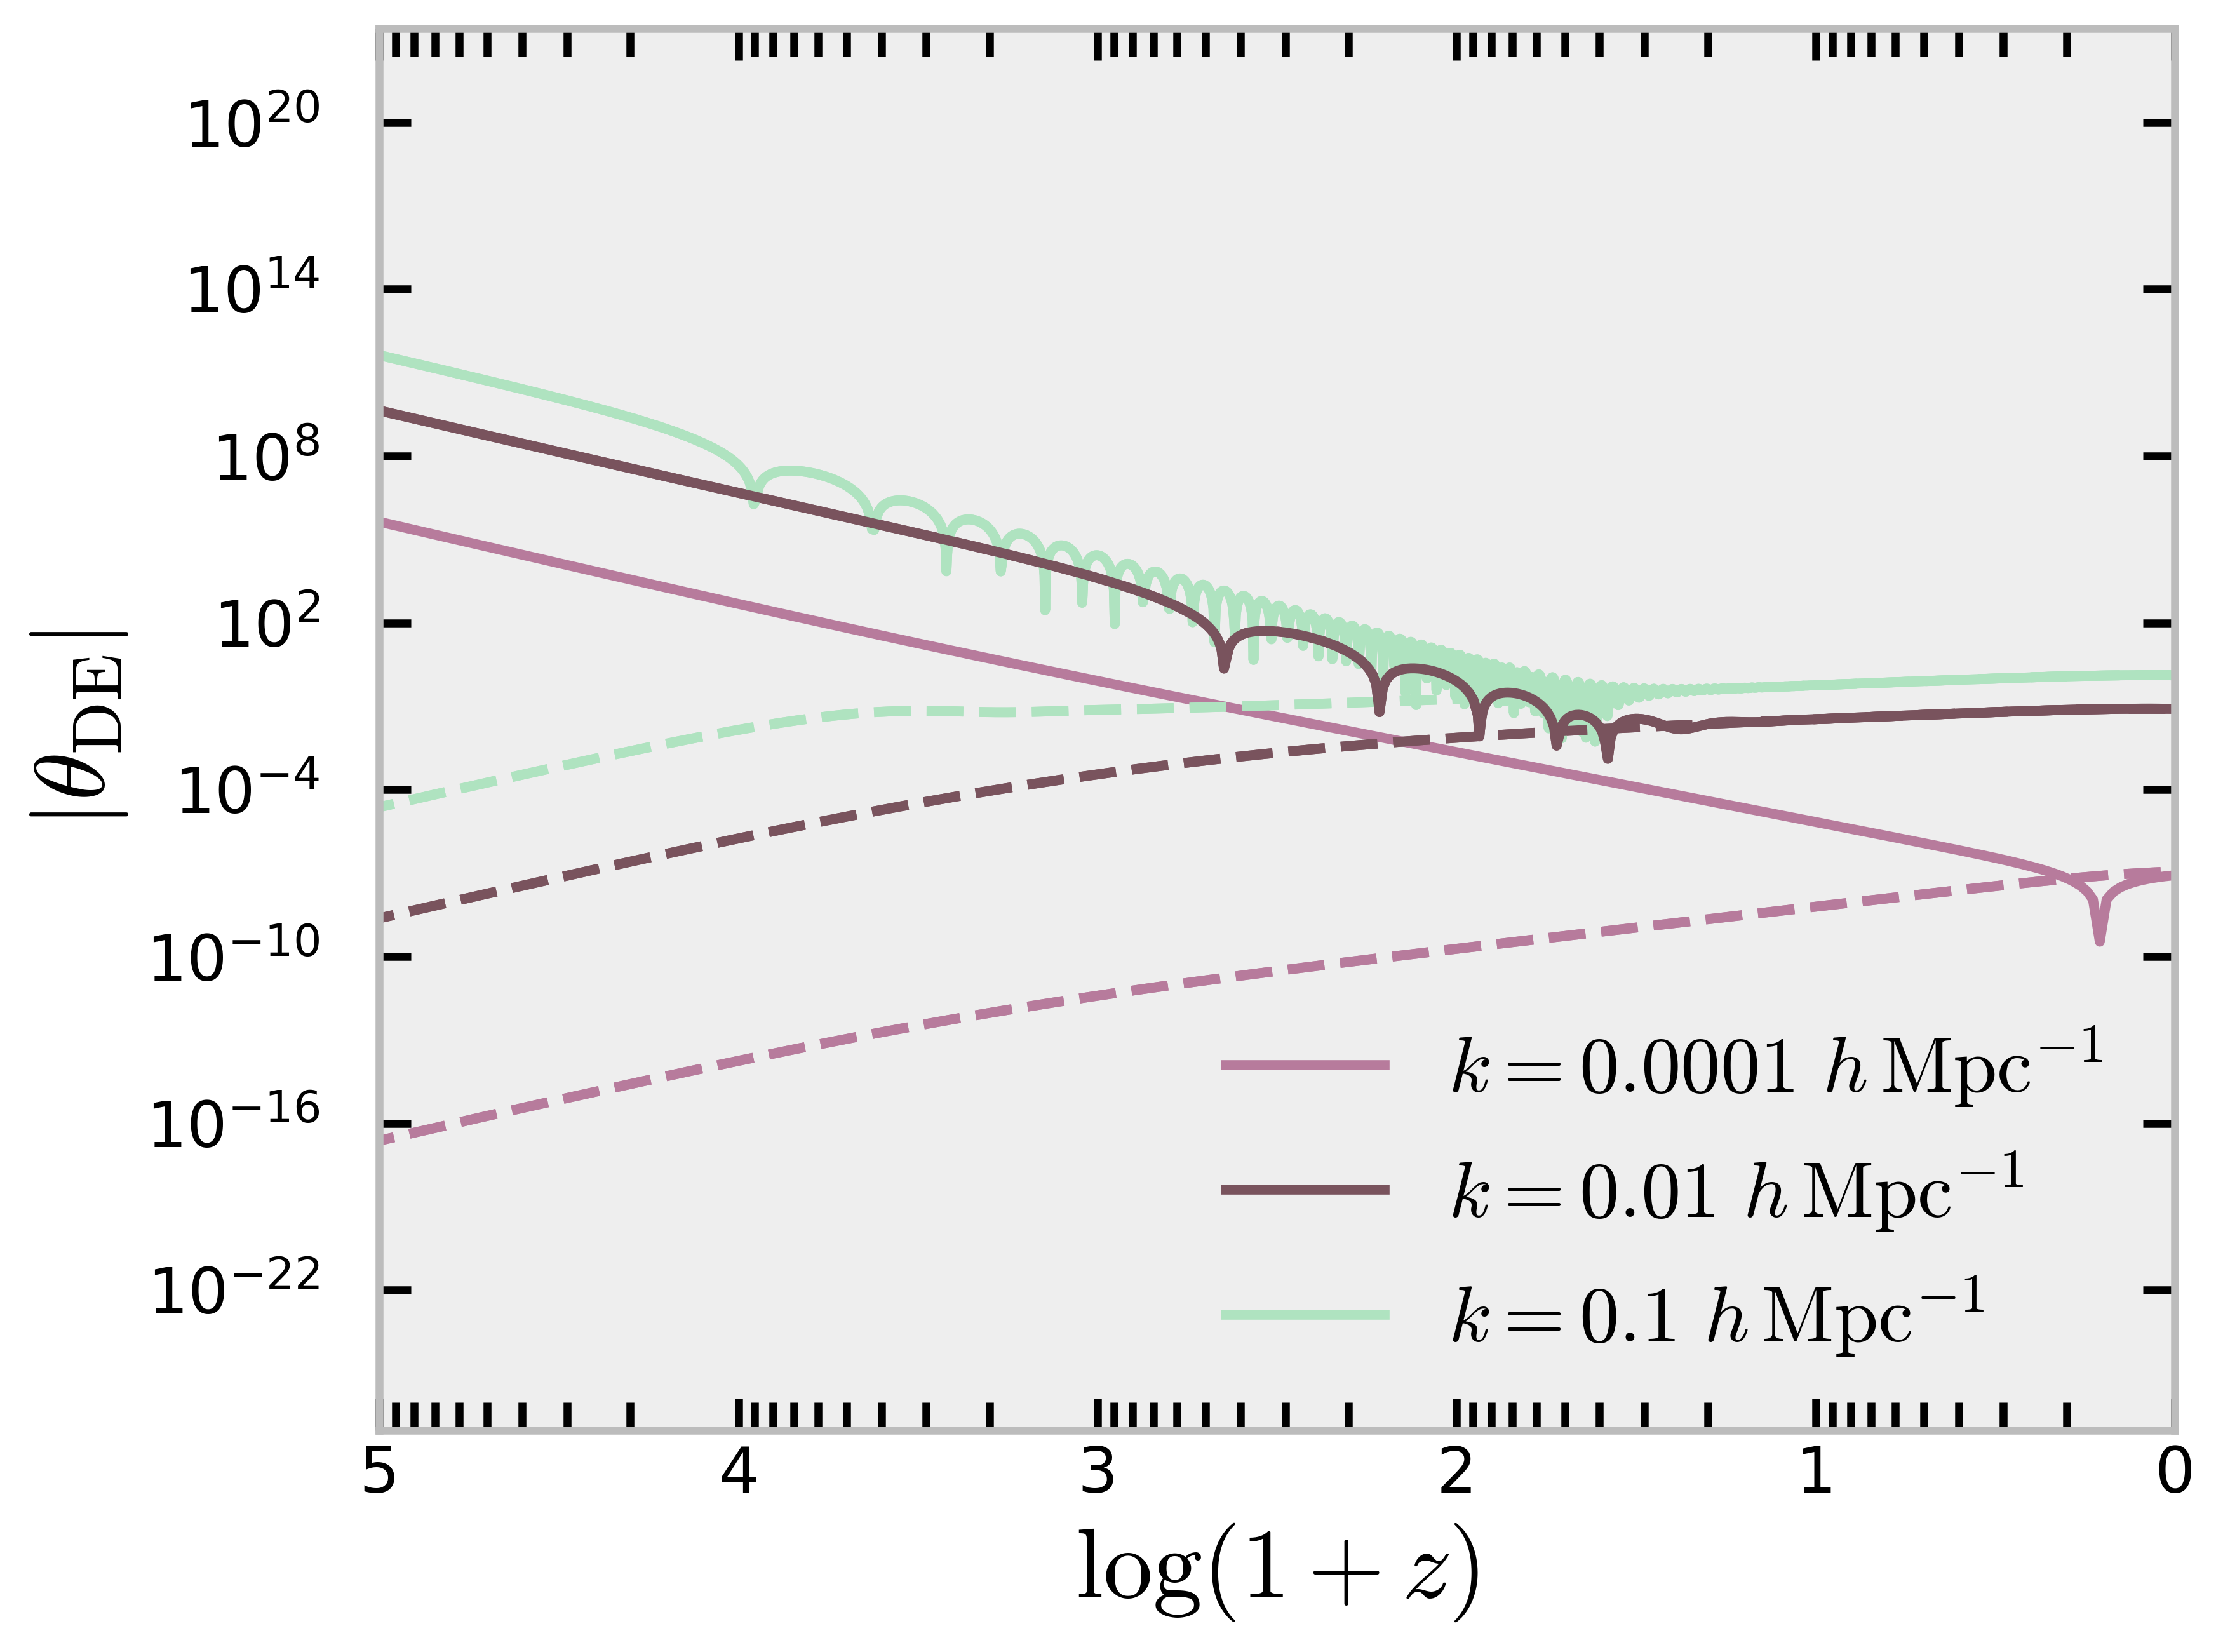

In [34]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

fig, ax0 = plt.subplots(figsize=(8,6))  # one panel only
ls = ['-','--','-.', ':', (0,(5,1))]

def build_interp1d(x, y, kind='cubic', clamp=False):
    """Return an interp1d callable with sorted, duplicate-free x."""
    x = np.asarray(x); y = np.asarray(y)
    order = np.argsort(x)
    x = x[order]; y = y[order]
    xu, inv, cnt = np.unique(x, return_inverse=True, return_counts=True)
    if np.any(cnt > 1):
        yu = np.zeros_like(xu, dtype=float)
        np.add.at(yu, inv, y)   # average duplicates
        yu /= cnt
    else:
        yu = y
    fill = (yu[0], yu[-1]) if clamp else 'extrapolate'
    return interp1d(xu, yu, kind=kind, bounds_error=False, fill_value=fill, assume_sorted=True)

def interp_bg_to_pert(bg, key, a_target, kind='cubic', clamp=True):
    """Interpolate background quantity 'key' onto the perturbation a-grid using interp1d."""
    z_bg = np.asarray(bg['z'])
    a_bg = 1.0/(1.0 + z_bg)
    y_bg = np.asarray(bg[key])
    f = build_interp1d(a_bg, y_bg, kind=kind, clamp=clamp)
    return f(a_target)

def pick_first_key(d, candidates):
    for k in candidates:
        if k in d:
            return k
    raise KeyError(f"None of the keys found: {candidates}")

for ik, index_k in enumerate([0, 1,2]):  # loop over k values
    color_idx = ik  # color depends on k
    
    for ib, index in enumerate([5, 0]):   # loop over beta values
        cosmoPerturb = cosmo[index].get_perturbations()
        cosmoPerturb0 = cosmo[0].get_perturbations()
        cosmoBack = cosmo[index].get_background()

        pblock = cosmoPerturb['scalar'][index_k]
        a = pblock['a']                                    # perturbation a-grid
        z = 1/a - 1
        delta_phi = pblock['delta_phi_scf']
        delta_phi0 = cosmoPerturb0['scalar'][index_k]['delta_phi_scf']
        delta_rho_scf = pblock['delta_rho_scf']

        # ---- interpolate background DE density onto pert grid
        bg_de_key = '(.)rho_scf' if '(.)rho_scf' in cosmoBack else '(.)rho_lambda'
        rho_de_on_pert = interp_bg_to_pert(cosmoBack, bg_de_key, a, kind='linear', clamp=True)

        delta_DE = delta_rho_scf / rho_de_on_pert

        # ---- interpolate background phi' onto pert grid (try several possible keys)
        phi_prime_key = pick_first_key(
            cosmoBack,
            ["phi'_scf", 'phi_prime_scf', 'phiPrime_scf', 'phi_prime']  # adjust if needed
        )
        phi_prime_on_pert = interp_bg_to_pert(cosmoBack, phi_prime_key, a, kind='linear', clamp=True)

        # ---- build theta_DE = k^2 * (h0*delta_s + delta_phi) / phi_prime
        k_1Mpc = k_sorted[index_k]            # your k_sorted is in 1/Mpc (label converts to h/Mpc)
        h0 = h0s[index]
        print(h0)
        delta_s = A0s[index]*pow(k_sorted[index_k], n0s[index])

        # avoid division by ~0
        eps = 1e-300
        theta_DE = (k_1Mpc**2) * (h0*delta_s + delta_phi) / np.where(np.abs(phi_prime_on_pert) > eps,
                                                                     phi_prime_on_pert, np.nan)

        # optional debug
        # print(theta_DE[-1], h0*delta_s, delta_phi[-1])

        # label only once per k (when ib == 0)
        label_str = fr'$k = {(k_sorted[index_k]/0.67556):.3g}\ h\,\mathrm{{Mpc}}^{{-1}}$' if ib == 0 else None

        ax0.plot(1+z, np.abs(theta_DE),
                 label=label_str, lw=lw, ls=ls[ib], c=color[color_idx])

# Axes & styling
ax0.set_xscale('log')
ax0.set_yscale('log')
ax0.set_xlabel(r'$\log(1+z)$', size=25)
ax0.set_ylabel(r'$|\theta_{\rm DE}|$', size=25)
ax0.set_xlim(1e5, 1)
ax0.tick_params(axis='both', which='major', labelsize=16, width=1.1)
ax0.legend(loc='lower right', frameon=boolean, prop={'size': 20}, ncol=1)
original_labels = ax0.get_xticks()
labels = []
for label in original_labels:
    labels.append(int(np.log10(label)))
ax0.set_xticklabels(labels)

ax0.tick_params(axis='both', which='both', labelsize=16)
ax0.tick_params(axis='both', which='both', labelsize=16)

#---------------------------------------------------------------------------------> change ticklabels distance
ax1.tick_params(axis='both', which='both', labelsize=16)
ax1.tick_params(axis='both', which='both', labelsize=16)

for tick in ax1.xaxis.get_major_ticks():
    tick.set_pad(15)
for tick in ax0.yaxis.get_major_ticks():
    tick.set_pad(15)
for tick in ax1.yaxis.get_major_ticks():
    tick.set_pad(15)
    
ax0.tick_params(axis='both', which='both', labelsize=16)

    
ax0.xaxis.set_tick_params(which='major', size=8, width=2, direction='in', top='on')
ax0.xaxis.set_tick_params(which='minor', size=7, width=2, direction='in', top='on')
ax0.yaxis.set_tick_params(which='major', size=8, width=2, direction='in', right='on')
ax0.yaxis.set_tick_params(which='minor', size=7, width=2, direction='in', right='on')

ax1.tick_params(axis='both', which='both', labelsize=16)

    
ax1.xaxis.set_tick_params(which='major', size=8, width=2, direction='in', top='on')
ax1.xaxis.set_tick_params(which='minor', size=7, width=2, direction='in', top='on')
ax1.yaxis.set_tick_params(which='major', size=8, width=2, direction='in', right='on')
ax1.yaxis.set_tick_params(which='minor', size=7, width=2, direction='in', right='on')

for ax in (ax0, ax1):
    # copy the list so we don't iterate over lines we add
    lines = list(ax.get_lines())[1:]
    for ln in lines[::-1]:
        ax.plot(
            ln.get_xdata(), ln.get_ydata(),
            ls=ln.get_linestyle(),
            lw=ln.get_linewidth(),
            c=ln.get_color(),
            marker=ln.get_marker(),
            markersize=ln.get_markersize(),
            alpha=ln.get_alpha() if ln.get_alpha() is not None else 1.0,
            label="_nolegend_",  # labels starting with '_' are ignored by legend()
        )

fig.tight_layout()
plt.savefig('thetade2_ks3.pdf')
plt.show()


/var/folders/91/jymwbq1j1nng0wqyd6yvbm100000gn/T/ipykernel_82780/1872390396.py:99: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax0.set_xticklabels(labels)
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


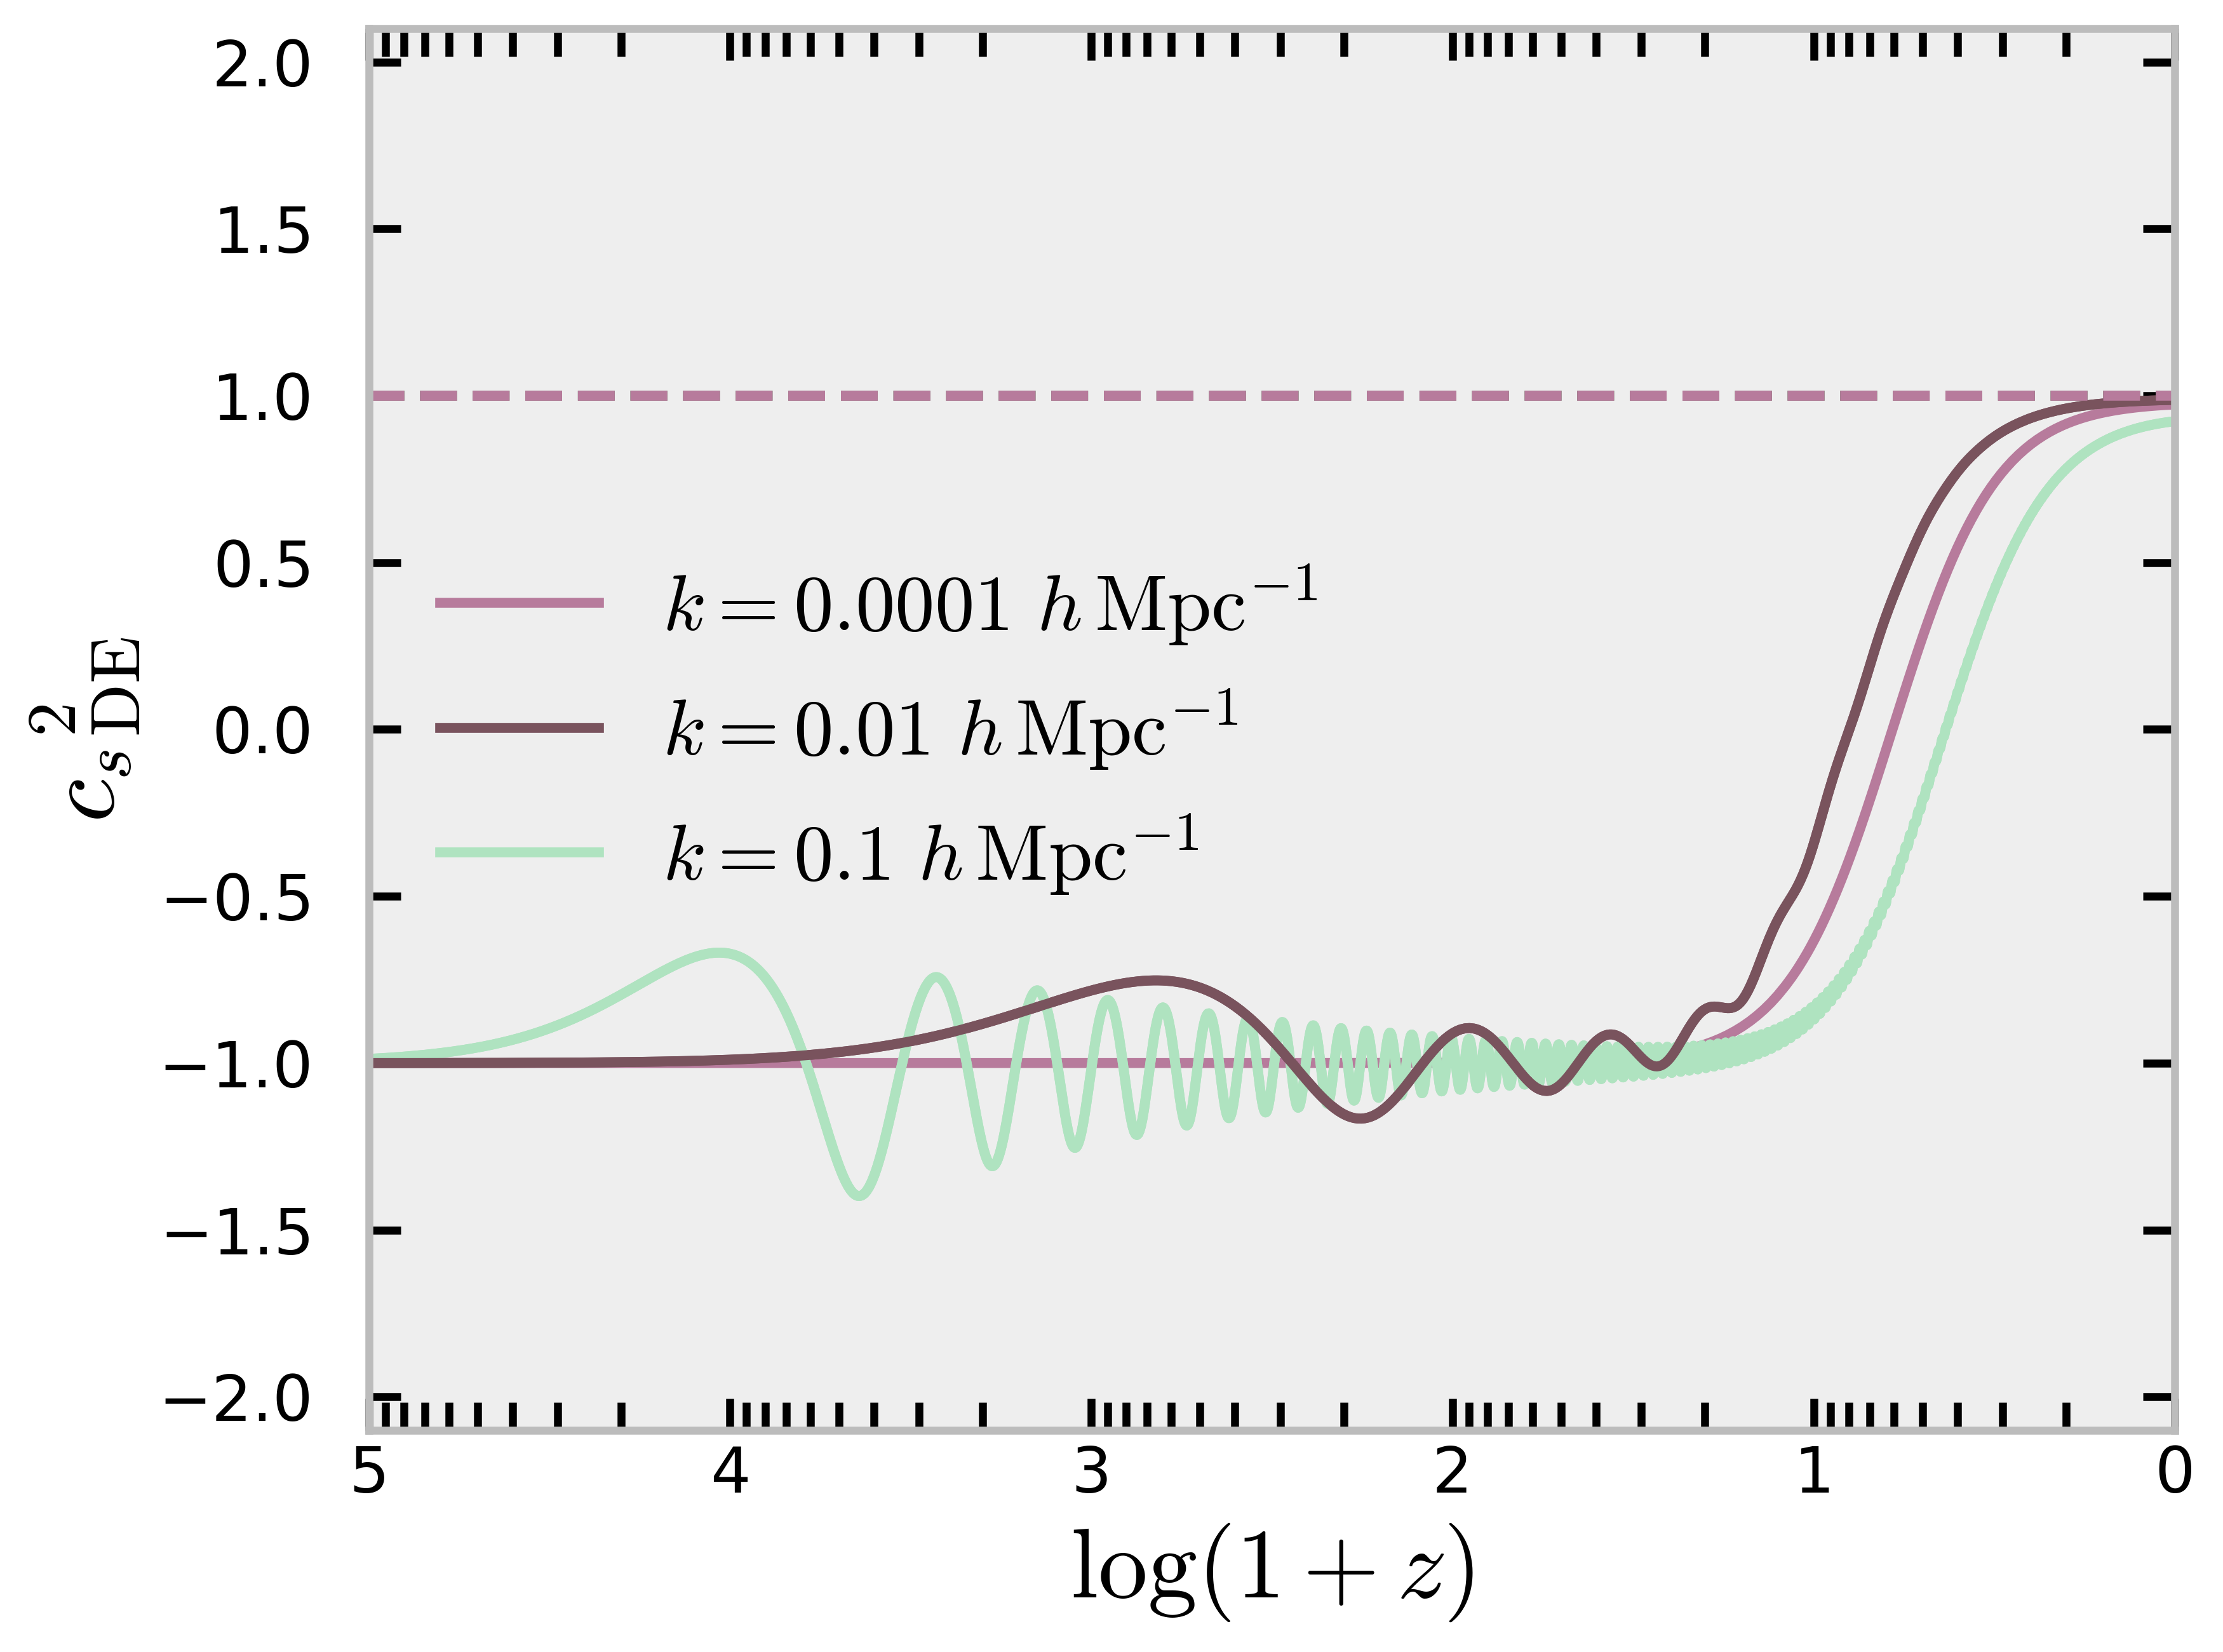

In [35]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

fig, ax0 = plt.subplots(figsize=(8,6))  # one panel only
ls = ['-','--','-.', ':', (0,(5,1))]

def build_interp1d(x, y, kind='linear', clamp=True):
    """Return an interp1d callable with sorted, duplicate-free x."""
    x = np.asarray(x); y = np.asarray(y)
    order = np.argsort(x)
    x = x[order]; y = y[order]
    xu, inv, cnt = np.unique(x, return_inverse=True, return_counts=True)
    if np.any(cnt > 1):
        yu = np.zeros_like(xu, dtype=float)
        np.add.at(yu, inv, y)   # average duplicates
        yu /= cnt
    else:
        yu = y
    fill = (yu[0], yu[-1]) if clamp else 'extrapolate'
    return interp1d(xu, yu, kind=kind, bounds_error=False, fill_value=fill, assume_sorted=True)

def interp_bg_to_pert(bg, key, a_target, kind='linear', clamp=True):
    """Interpolate background quantity 'key' onto perturbation a-grid using interp1d."""
    z_bg = np.asarray(bg['z'])
    a_bg = 1.0/(1.0 + z_bg)
    y_bg = np.asarray(bg[key])
    f = build_interp1d(a_bg, y_bg, kind=kind, clamp=clamp)
    return f(a_target)

def pick_first_key(d, candidates):
    for k in candidates:
        if k in d:
            return k
    raise KeyError(f"None of the keys found: {candidates}")

for ik, index_k in enumerate([0, 1,2]):  # loop over k values
    color_idx = ik

    for ib, index in enumerate([5, 0]):   # loop over beta values
        cosmoPerturb = cosmo[index].get_perturbations()
        cosmoBack = cosmo[index].get_background()

        pblock   = cosmoPerturb['scalar'][index_k]
        a        = pblock['a']                          # perturbation a-grid
        z = 1/a - 1
        delta_rho_scf    = pblock['delta_rho_scf']
        delta_phi        = pblock['delta_phi_scf']
        delta_phi_prime  = pblock['delta_phi_prime_scf']
        psi              = pblock['psi']

        h0 = h0s[index]
        f0 = f0s[index]
        delta_s = A0s[index]*pow(k_sorted[index_k], n0s[index])

        # --- interpolate background pieces onto pert grid
        Vphi_key = pick_first_key(cosmoBack, ["V'_scf", "V_prime_scf", "Vphi_prime_scf"])
        Vphi_on_pert = interp_bg_to_pert(cosmoBack, Vphi_key, a, kind='linear', clamp=True)

        phi_key = pick_first_key(cosmoBack, ["phi_scf", "phi_scf"])
        phi_on_pert = interp_bg_to_pert(cosmoBack, phi_key, a, kind='linear', clamp=True)
        
        phi_prime_key = pick_first_key(cosmoBack, ["phi'_scf", "phi_prime_scf"])
        phi_prime_on_pert = interp_bg_to_pert(cosmoBack, phi_prime_key, a, kind='linear', clamp=True)

        H_key = pick_first_key(cosmoBack, ['H [1/Mpc]', 'H[1/Mpc]', 'H'])
        H_on_pert = interp_bg_to_pert(cosmoBack, H_key, a, kind='linear', clamp=True)
        horizon = H_on_pert  # if you decide to plot it

        # --- your expression for c_s^2_DE
        term1 = (a*a) * delta_s * (h0*Vphi_on_pert - f0*phi_on_pert)
        term2 = phi_prime_on_pert * (delta_phi_prime - phi_prime_on_pert*psi)
        denom = term1 + term2
        eps = 1e-300
        cs2_DE = 1.0 - 2.0*term1 / np.where(np.abs(denom) > eps, denom, np.nan)

        # label only once per k
        label_str = fr'$k = {(k_sorted[index_k]/0.67556):.3g}\ h\,\mathrm{{Mpc}}^{{-1}}$' if ib == 0 else None

        ax0.plot(1+z, cs2_DE, label=label_str, lw=lw, ls=ls[ib], c=color[color_idx])

        # Optional horizon/k lines:
        # if ib == 0:
        #     ax0.plot(a, horizon, lw=lw, ls=':', c=color[color_idx+2])
        #     ax0.hlines(y=k_sorted[index_k], xmin=a[0], xmax=a[-1], lw=lw, ls='-.', colors=color[color_idx+3])

# Axes & styling
ax0.set_xscale('log')
ax0.set_xlabel(r'$\log(1+z)$', size=25)
ax0.set_ylabel(r'${c_s}^2_{\rm DE}$', size=25)
ax0.set_xlim(1e5, 1)
ax0.set_ylim(-2.1, 2.1)
ax0.tick_params(axis='both', which='major', labelsize=16, width=1.1)
ax0.legend(loc='center left', frameon=boolean, prop={'size': 20}, ncol=1)
original_labels = ax0.get_xticks()
labels = []
for label in original_labels:
    labels.append(int(np.log10(label)))
ax0.set_xticklabels(labels)

ax0.tick_params(axis='both', which='both', labelsize=16)
ax0.tick_params(axis='both', which='both', labelsize=16)

#---------------------------------------------------------------------------------> change ticklabels distance
ax1.tick_params(axis='both', which='both', labelsize=16)
ax1.tick_params(axis='both', which='both', labelsize=16)

for tick in ax1.xaxis.get_major_ticks():
    tick.set_pad(15)
for tick in ax0.yaxis.get_major_ticks():
    tick.set_pad(15)
for tick in ax1.yaxis.get_major_ticks():
    tick.set_pad(15)
    
ax0.tick_params(axis='both', which='both', labelsize=16)

    
ax0.xaxis.set_tick_params(which='major', size=8, width=2, direction='in', top='on')
ax0.xaxis.set_tick_params(which='minor', size=7, width=2, direction='in', top='on')
ax0.yaxis.set_tick_params(which='major', size=8, width=2, direction='in', right='on')
ax0.yaxis.set_tick_params(which='minor', size=7, width=2, direction='in', right='on')

ax1.tick_params(axis='both', which='both', labelsize=16)

    
ax1.xaxis.set_tick_params(which='major', size=8, width=2, direction='in', top='on')
ax1.xaxis.set_tick_params(which='minor', size=7, width=2, direction='in', top='on')
ax1.yaxis.set_tick_params(which='major', size=8, width=2, direction='in', right='on')
ax1.yaxis.set_tick_params(which='minor', size=7, width=2, direction='in', right='on')

for ax in (ax0, ax1):
    # copy the list so we don't iterate over lines we add
    lines = list(ax.get_lines())[1:]
    for ln in lines[::-1]:
        ax.plot(
            ln.get_xdata(), ln.get_ydata(),
            ls=ln.get_linestyle(),
            lw=ln.get_linewidth(),
            c=ln.get_color(),
            marker=ln.get_marker(),
            markersize=ln.get_markersize(),
            alpha=ln.get_alpha() if ln.get_alpha() is not None else 1.0,
            label="_nolegend_",  # labels starting with '_' are ignored by legend()
        )

fig.tight_layout()
plt.savefig('cs2de2_ks3.pdf')
plt.show()


0.067556


/var/folders/91/jymwbq1j1nng0wqyd6yvbm100000gn/T/ipykernel_82780/723468379.py:66: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax0.set_xticklabels([-1,0,1,2,3])
/var/folders/91/jymwbq1j1nng0wqyd6yvbm100000gn/T/ipykernel_82780/723468379.py:66: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax0.set_xticklabels([-1,0,1,2,3])
/var/folders/91/jymwbq1j1nng0wqyd6yvbm100000gn/T/ipykernel_82780/723468379.py:66: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax0.set_xticklabels([-1,0,1,2,3])
/var/folders/91/jymwbq1j1nng0wqyd6yvbm100000gn/T/ipykernel_82780/723468379.py:66: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax0.set_xticklabels([-1,0,1,2,3])
/var/folders/91/

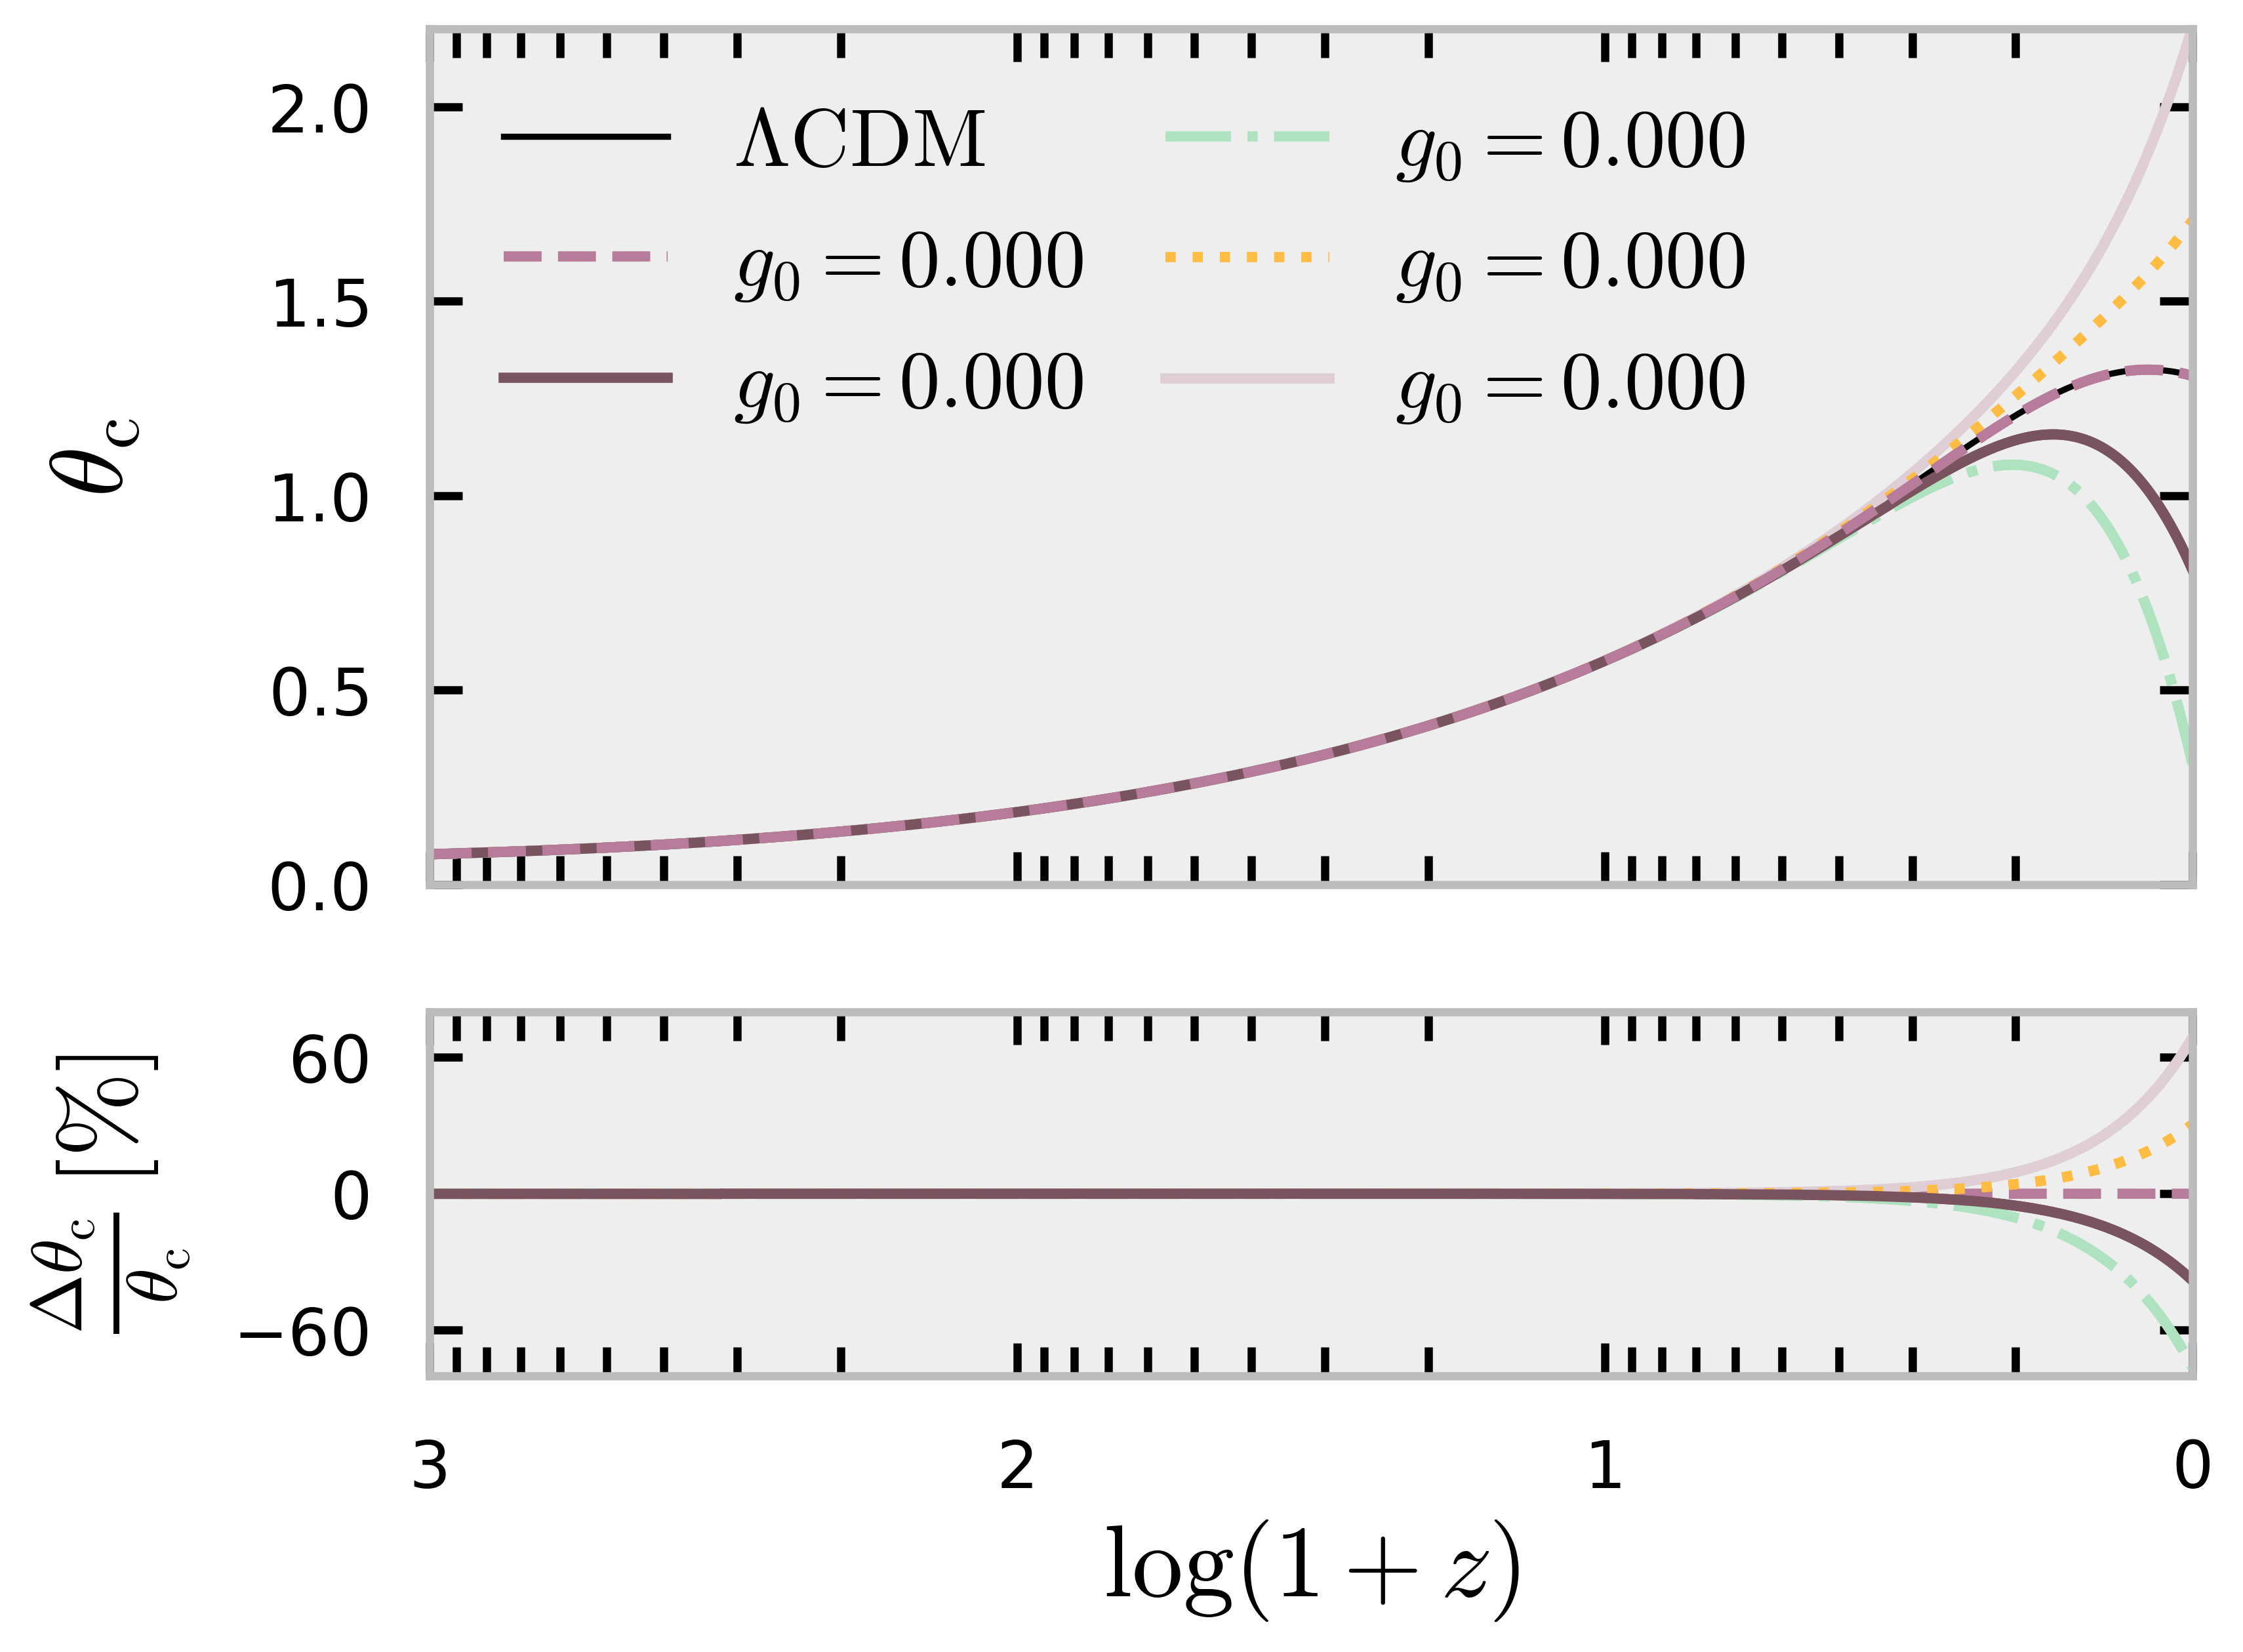

In [ ]:
#print(k_sorted)
index_k_list = [0]
label = [r'$\theta_c$','','','','']

lw = 2.5
ls = ['--','-','-.', ':', '-']
plt.style.use(['ipynb', 'use_mathtext','colors5-light'])

fig = plt.figure(figsize=(8,6))
ax0 = plt.subplot2grid((3,1),(0,0), rowspan=2)
ax1 = plt.subplot2grid((3,1),(2,0), rowspan=1,sharex = ax0)

plt.subplots_adjust(hspace=0,wspace=0.)

def interp_monotonic(x, y, kind='linear', clamp=True):
    x = np.asarray(x); y = np.asarray(y)
    o = np.argsort(x); x=x[o]; y=y[o]
    xu, inv, cnt = np.unique(x, return_inverse=True, return_counts=True)
    if np.any(cnt>1):
        yu = np.zeros_like(xu, dtype=float)
        np.add.at(yu, inv, y); yu /= cnt
    else:
        yu = y
    fill = (yu[0], yu[-1]) if clamp else 'extrapolate'
    return interp1d(xu, yu, kind=kind, bounds_error=False, fill_value=fill, assume_sorted=True)

# --- choose mode and build reference interpolator once ---
index_k = 2
print(k_sorted[index_k])
std = standard.get_perturbations()['scalar'][index_k]
a0 = std['a']
z0 = 1/a0 - 1
theta0 = std['theta_cdm']

# plot the reference on its own grid
ax0.plot(1+z0, theta0, c='k', ls='-', label=r'$\Lambda{\rm CDM}$', lw=1.5)

# interpolator θ_c^ref(a)
f_theta0 = interp_monotonic(a0, theta0, kind='linear', clamp=True)

# --- loop over models and compare to reference on the SAME grid ---
runs = [0,1,2,3,4]
for j, index in enumerate(runs):
    blk = cosmo[index].get_perturbations()['scalar'][index_k]
    a   = blk['a']
    z   = 1/a - 1
    th  = blk['theta_edm']

    # reference evaluated on THIS grid -> shapes match
    theta0_on_a = f_theta0(a)

    # styles/colors (robust cycling)
    ls_j    = ls[j % len(ls)]
    color_j = color[j % len(color)]
    label_j = rf'$g_0 = {f0s[index]:.3f}$' if index < len(n0s) else rf'$i={index}$'

    # top panel
    ax0.plot(1+z, th, label=label_j, lw=lw, ls=ls_j, c=color_j)

    # bottom panel: percent difference with divide-by-zero guard
    eps   = 1e-300
    denom = np.where(np.abs(theta0_on_a) > eps, theta0_on_a, np.nan)
    rel   = 100.0 * (th - theta0_on_a) / denom
    ax1.plot(1+z, rel, lw=lw, ls=ls_j, c=color_j)
    #ax0.plot(1+z, np.abs(cosmoPerturb['scalar'][index_k]['delta_rho_scf'])*1e-4, c='k', ls='-', label = r'$\delta {\phi}$',lw=1.5)
    ax0.set_xticklabels([-1,0,1,2,3])

    ax0.set_ylabel(label[index], size=25)
    ax1.set_xlabel(r'$\log(1+z)$', size=25)
    #ax0.set_xlim(1e5,1)
    # ax0.set_ylim(1e-3,1)
    #ax0.set_title('k = '+str(k_sorted[index_k]), size=20)
    ax0.tick_params(axis='both', which='major', labelsize=16, width=1.1)
    for tick in ax0.xaxis.get_major_ticks():
        tick.set_pad(10)
    for tick in ax0.yaxis.get_major_ticks():
        tick.set_pad(10)    


ax0.set_xscale('log');ax0.set_yscale('linear')
ax1.set_xscale('log');ax1.set_yscale('linear')

ax0.set_ylabel(r'$\theta_{\rm c}$', size=25,labelpad=30)
ax1.set_ylabel(r'$ \frac{\Delta \theta_{\rm c}}{\theta_{\rm c}}\, [\%]$', size=25,labelpad=10)


ax0.set_ylim(0., 2.2)
ax1.set_xlim(1e3,1)
#ax0.set_ylim([1e3,5.*1e4])
ax1.set_ylim(-80,80)
ax1.set_yticks([i for i in np.linspace(-60,60,3)])

    
ax0.tick_params(axis='both', which='both', labelsize=16)
ax0.tick_params(axis='both', which='both', labelsize=16)

#---------------------------------------------------------------------------------> change ticklabels distance
ax1.tick_params(axis='both', which='both', labelsize=16)
ax1.tick_params(axis='both', which='both', labelsize=16)

for tick in ax1.xaxis.get_major_ticks():
    tick.set_pad(15)
for tick in ax0.yaxis.get_major_ticks():
    tick.set_pad(15)
for tick in ax1.yaxis.get_major_ticks():
    tick.set_pad(15)
    
ax0.tick_params(axis='both', which='both', labelsize=16)

    
ax0.xaxis.set_tick_params(which='major', size=8, width=2, direction='in', top='on')
ax0.xaxis.set_tick_params(which='minor', size=7, width=2, direction='in', top='on')
ax0.yaxis.set_tick_params(which='major', size=8, width=2, direction='in', right='on')
ax0.yaxis.set_tick_params(which='minor', size=7, width=2, direction='in', right='on')

ax1.tick_params(axis='both', which='both', labelsize=16)

    
ax1.xaxis.set_tick_params(which='major', size=8, width=2, direction='in', top='on')
ax1.xaxis.set_tick_params(which='minor', size=7, width=2, direction='in', top='on')
ax1.yaxis.set_tick_params(which='major', size=8, width=2, direction='in', right='on')
ax1.yaxis.set_tick_params(which='minor', size=7, width=2, direction='in', right='on')

ax0.set_xscale('log')
#ax0.set_yscale('log')
original_labels = ax0.get_xticks()
labels = []
for label in original_labels:
    labels.append(int(np.log10(label)))
ax0.set_xticklabels(labels)

for ax in (ax0, ax1):
    # copy the list so we don't iterate over lines we add
    lines = list(ax.get_lines())[1:]
    for ln in lines[::-1]:
        ax.plot(
            ln.get_xdata(), ln.get_ydata(),
            ls=ln.get_linestyle(),
            lw=ln.get_linewidth(),
            c=ln.get_color(),
            marker=ln.get_marker(),
            markersize=ln.get_markersize(),
            alpha=ln.get_alpha() if ln.get_alpha() is not None else 1.0,
            label="_nolegend_",  # labels starting with '_' are ignored by legend()
        )
ax0.ticklabel_format(axis='y', style='sci', scilimits=(0,0), useMathText=True) #---------------------------> Scientific format
#ax.yaxis.offsetText.set_fontsize(20) #---------------------------> size of the scientific format
ax1.ticklabel_format(axis='y', style='plain', useMathText=True)

ax0.legend(loc='upper left', frameon=boolean, prop={'size': 20},ncol=2,columnspacing=1)
plt.setp(ax0.get_xticklabels(), visible=False)
plt.rcParams['font.size'] = 20
plt.rcParams['axes.linewidth'] = 2
fig.tight_layout()
plt.savefig('thetac.pdf')
#, transparent=True)
plt.show()


3
k = 0.12501110288675057
0.8124032458657772
0.7110309848808751
0.6740051346506386
0.9261855443995968
1.0945014644305588
0.8126677892806718


'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


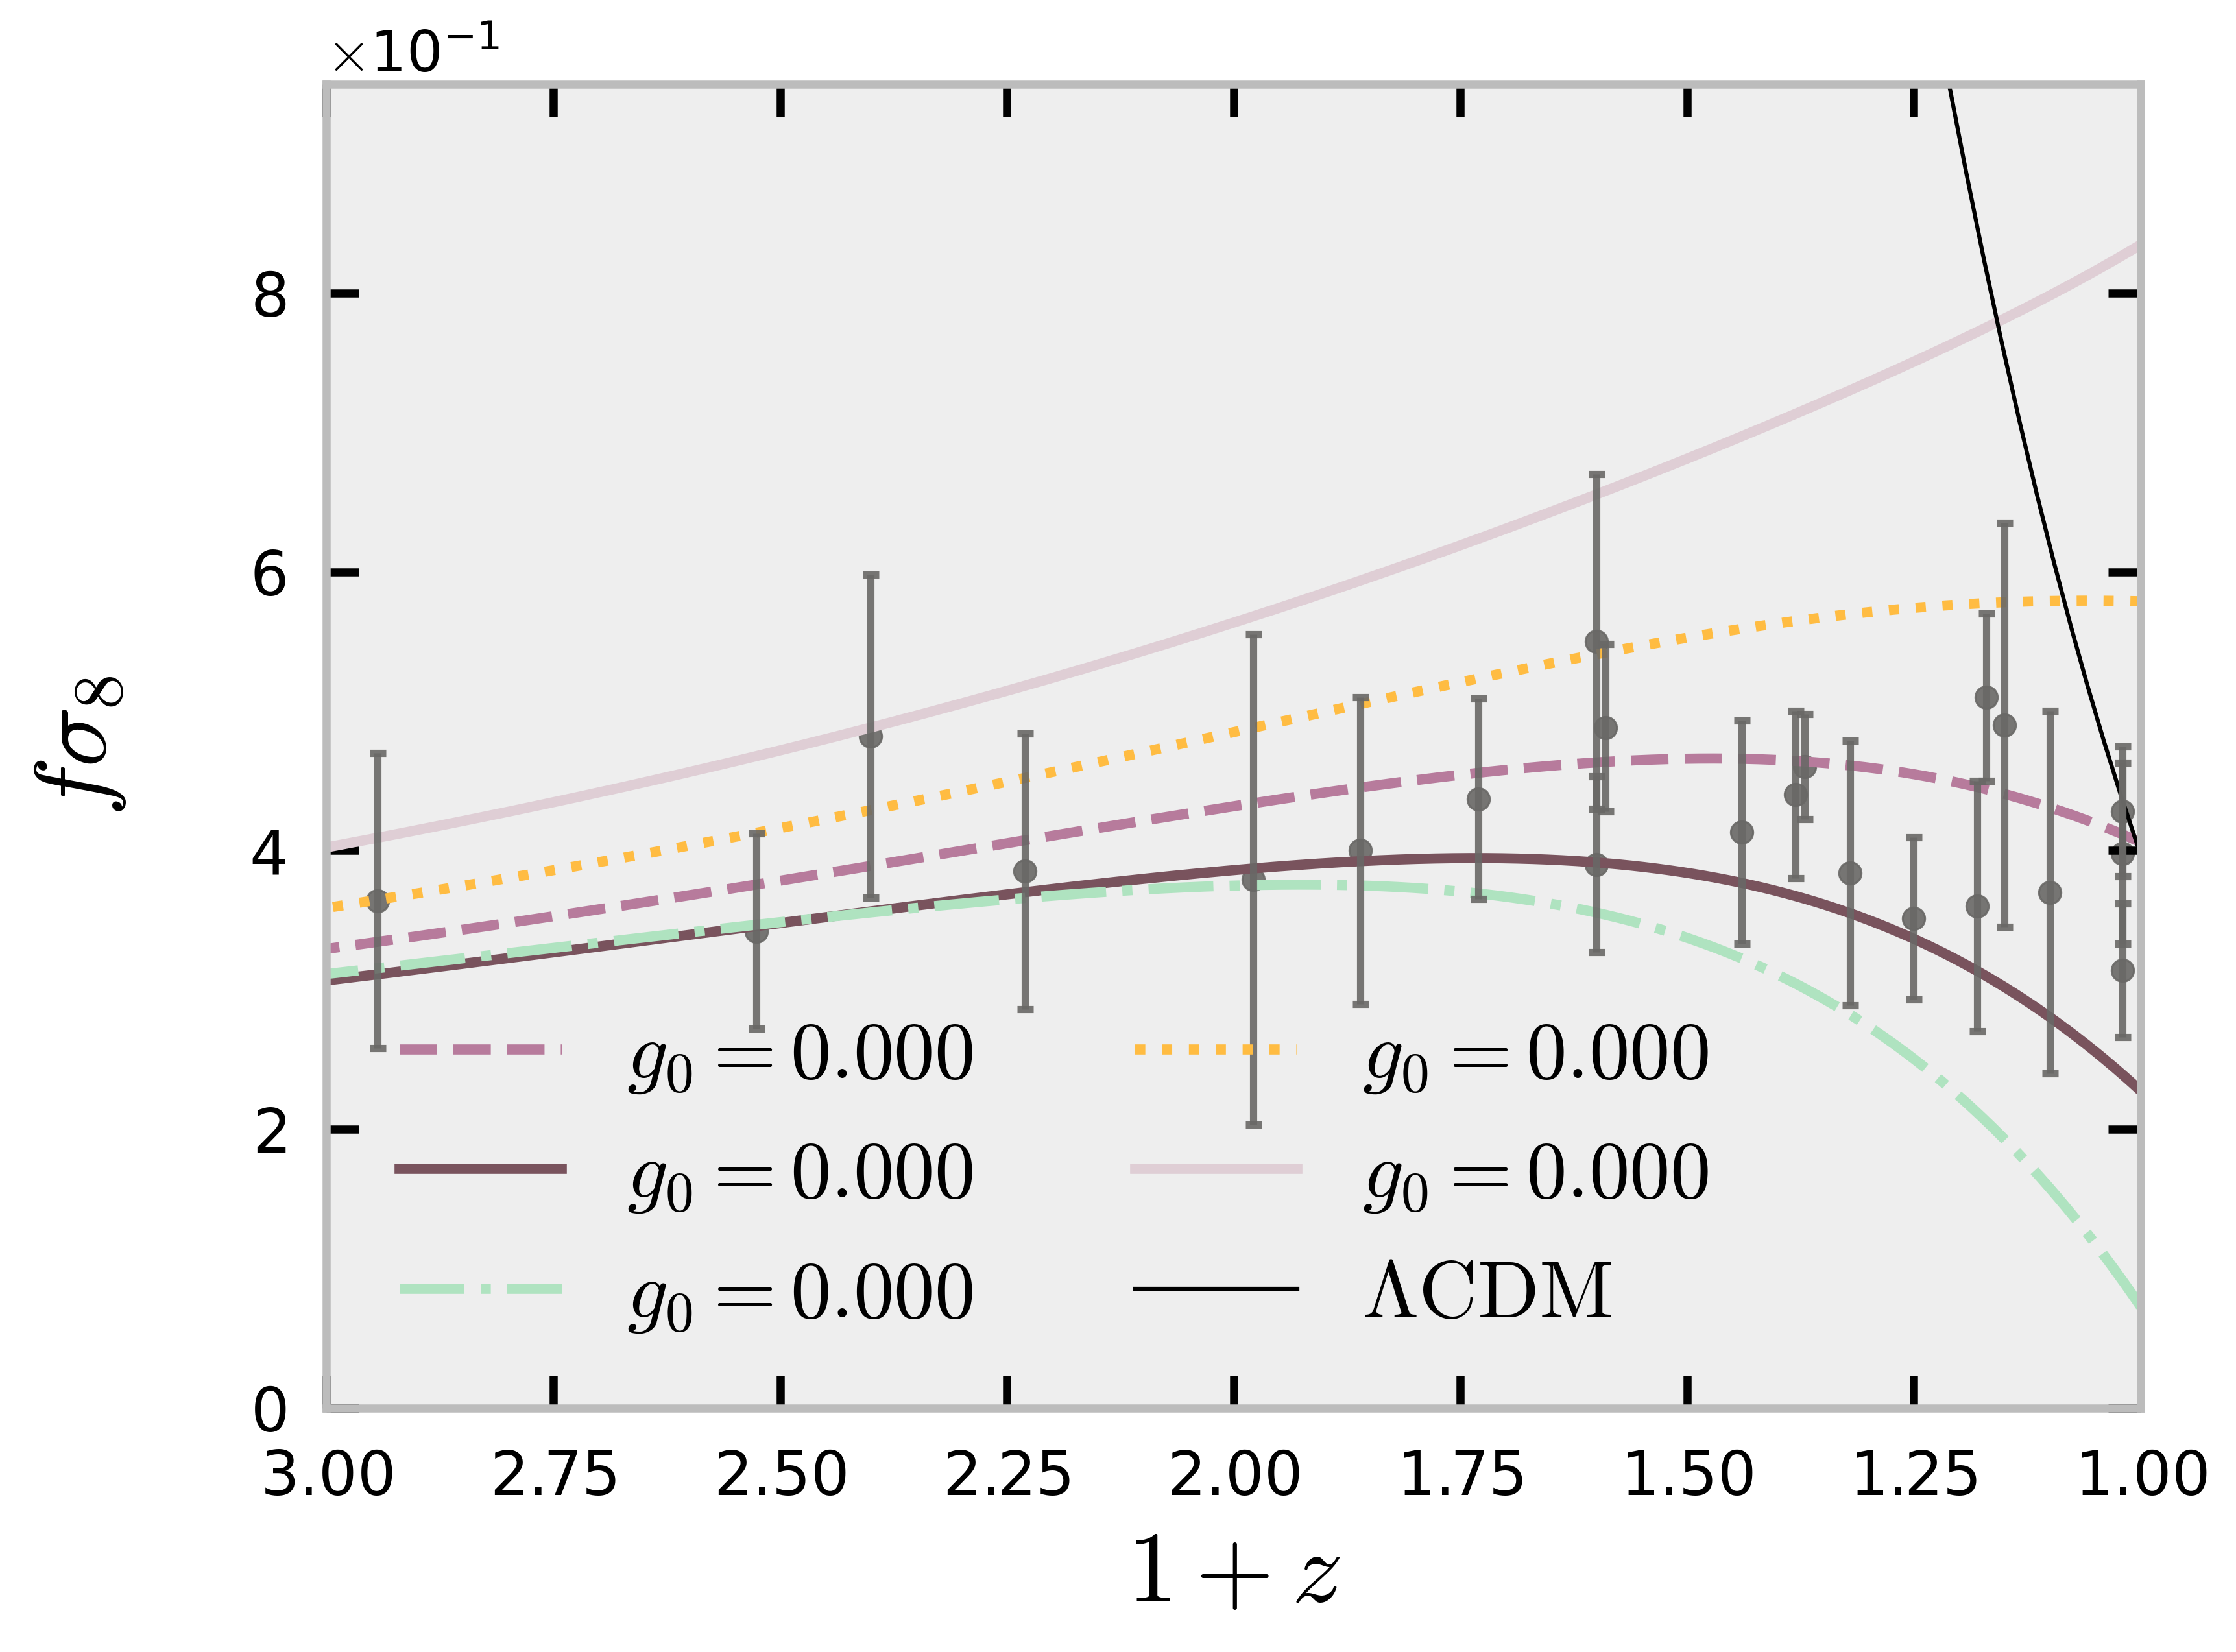

In [37]:

#print(k_sorted)

lw = 2.5
ls = ['--','-','-.', ':', '-']
plt.style.use(['ipynb', 'use_mathtext','colors5-light'])

fig, ax = plt.subplots(1, 1, figsize=(8,6))

for i in [3]: #--------------------------------------------> values of k-scales
    index_k = i
    print(index_k)
    print('k =', k_sorted[index_k]/0.6755)
    style=0
    for index in [0,1,2,3,4]: #--------------------------------------------> values of beta
        background_zm = cosmo_background[index]['z']+1.
        background_zm2 = background_zm[::-1]
        background_H = cosmo_background[index]['H [1/Mpc]']
        background_H2 = background_H[::-1]
        pert_zm = 1./cosmo_perturbations[index]['scalar'][index_k]['a']
        pert_zm2 = pert_zm[::-1]
        pert_a = cosmo_perturbations[index]['scalar'][index_k]['a']
        pert_a2 = pert_a[::-1]
        pert_delta_mtot = cosmo_perturbations[index]['scalar'][index_k]['delta_mtot']
        pert_delta_mtot2 = pert_delta_mtot[::-1]
        pert_delta_mtot_prime = cosmo_perturbations[index]['scalar'][index_k]['delta_mtot_prime']
        pert_delta_mtot_prime2 = pert_delta_mtot_prime[::-1]

        a_int = interp1d(pert_zm2,pert_a2,kind='linear',fill_value="extrapolate")
        H_int = interp1d(background_zm2,background_H2,kind='cubic')
        delta_mtot_int = interp1d(pert_zm2,pert_delta_mtot2,kind='linear')
        delta_mtot_prime_int = interp1d(pert_zm2,pert_delta_mtot_prime2,kind='linear')

        delta_mtot0 = cosmo_perturbations[index]['scalar'][index_k]['delta_mtot'][-1]

        dz = 0.01
        #Make a mock array; this will contain the redshifts z\in[0,5,0.01] we need for the interpolation
        zedm = np.arange(1.0, 5.0,dz)
        zedmm = np.arange(1., 1.e5,1/len(zedm))
        #Make a mock array; this will contain f(k,z) at z\in[0,5]
        scale_growthf=np.arange(1.0, 5.0,dz)
        #Make a mock array; this will contain P(k,z) at z\in[0,2]
        growths8=[0] * len(pert_zm2)
        s8 = cosmo[index].sigma8()
        print(s8)

        for zz in range(len(pert_zm2)-1):
        # One point numerical derivative (forward difference)
            growths8[zz]=(s8/delta_mtot0)*(delta_mtot_prime_int(pert_zm2[zz])/(H_int(pert_zm2[zz])*a_int(pert_zm2[zz])))
            growths8int=interp1d(pert_zm2,growths8,kind='linear')
        #print(growths8int(pert_zm2))
    
        ax.plot(pert_zm2, growths8int(pert_zm2), label = \
                 r'$g_0 = %.3f$'%(f0s[index]),lw=lw, ls=ls[style],c=color[style])

        style+=1

    standard_perturbations = standard.get_perturbations()
    background_zm = standard_background['z'] + 1.
    background_zm2 = background_zm[::-1]
    background_H = standard_background['H [1/Mpc]']
    background_H2 = background_H[::-1]
    pert_zm = 1./standard_perturbations['scalar'][index_k]['a']
    pert_zm2 = pert_zm[::-1]
    pert_a = standard_perturbations['scalar'][index_k]['a']
    pert_a2 = pert_a[::-1]
    pert_delta_mtot = standard_perturbations['scalar'][index_k]['delta_mtot']
    pert_delta_mtot2 = pert_delta_mtot[::-1]
    pert_delta_mtot_prime = standard_perturbations['scalar'][index_k]['delta_mtot_prime']
    pert_delta_mtot_prime2 = pert_delta_mtot_prime[::-1]

    a_int = interp1d(pert_zm2,pert_a2,kind='linear',fill_value="extrapolate")
    H_int = interp1d(background_zm2,background_H2,kind='cubic')
    delta_mtot_int = interp1d(pert_zm2,pert_delta_mtot2,kind='linear')
    delta_mtot_prime_int = interp1d(pert_zm2,pert_delta_mtot_prime2,kind='linear')

    delta_mtot0 = standard_perturbations['scalar'][index_k]['delta_mtot'][-1]

    dz = 0.01
    #Make a mock array; this will contain the redshifts z\in[0,5,0.01] we need for the interpolation
    zedm = np.arange(1.0, 5.0,dz)
    zedmm = np.arange(1., 1.e5,1/len(zedm))
    #Make a mock array; this will contain P(k,z) at z\in[0,2]
    growths8=[0] * len(pert_zm2)
    s8 = standard.sigma8()
    print(s8)

    for zz in range(len(pert_zm2)-1):
    # One point numerical derivative (forward difference)
        growths8[zz]=(s8/delta_mtot0)*(delta_mtot_prime_int(pert_zm2[zz])/(H_int(pert_zm2[zz])*a_int(pert_zm2[zz])))
        growths8int=interp1d(pert_zm2,growths8,kind='linear')
    #print(growths8int(pert_zm2))

    ax.plot(pert_zm2, growths8int(pert_zm2), c='k', ls='-', label = r'$\Lambda{\rm CDM}$',lw=1)

    #ax.set_xticklabels([-1,0,1,2,3])
    
    x0 = [1.02,1.02,1.02,1.10,1.15,1.17,1.18,1.38,1.25,1.37,1.32,1.59,1.44,1.6,1.73,1.6,1.86,2.4,1.978,2.23,2.526,2.944]
    #xz = [x+1 for x in x0]
    y = [0.428,0.398,0.314,0.370,0.49,0.51,0.36,0.44,0.3512,0.4602,0.384,0.488,0.413,0.39,0.437,0.55,0.4,0.482,0.379,0.385,0.342,0.364]
    #lower_error = [0.064,0.055,0.045,0.065,0.048,0.09,0.06,0.080,0.063,0.072,0.022,0.039,0.05,0.08,0.038,0.16,0.045,0.038,0.041,0.095,0.045,0.180,0.08,0.12,0.10,0.12,0.11,0.078,0.11,0.120,0.05]
    #upper_error = [0.067,0.055,0.048,0.065,0.048,0.09,0.06,0.080,0.063,0.072,0.022,0.039,0.05,0.08,0.038,0.16,0.045,0.038,0.041,0.095,0.045,0.180,0.08,0.12,0.10,0.12,0.12,0.075,0.11,0.126,0.05]
    err = [0.0465,0.065,0.048,0.13,0.145,0.06,0.09,0.06,0.0583,0.0378,0.095,0.06,0.08,0.063,0.072,0.12,0.11,0.116,0.176,0.099,0.07,0.106]
    yerr = [err,err]
    
    plt.errorbar(x0, y, yerr=yerr,fmt='o',color='#696866',linewidth=lw/1.4,capsize=2, markersize=0., capthick=lw/1.4,alpha=0.9)
    plt.scatter(x0, y,marker='o', color='#696866',s=30.,alpha=0.9)

    ax.set_ylabel(r'$f \sigma_8$', size=25,labelpad=30)
    ax.set_xlabel(r'$1+z$', size=25)
    ax.set_xlim(3.,1.)
    ax.set_ylim(0.,0.95)
    #ax.set_ylim(-0.05)
    #ax.set_title('k = '+str(k_sorted[index_k]), size=20)
    ax.tick_params(axis='both', which='major', labelsize=15, width=1.1)
    for tick in ax.xaxis.get_major_ticks():
        tick.set_pad(10)
    for tick in ax.yaxis.get_major_ticks():
        tick.set_pad(10)    

#ax.ticklabel_format(axis='y', style='sci', scilimits=(0,0), useMathText=True) #---------------------------> Scientific format
#ax.yaxis.offsetText.set_fontsize(20) #---------------------------> size of the scientific format


    
ax.tick_params(axis='both', which='both', labelsize=15)

for tick in ax.xaxis.get_major_ticks():
    tick.set_pad(10)
for tick in ax.yaxis.get_major_ticks():
    tick.set_pad(10)
    
ax.xaxis.set_tick_params(which='major', size=8, width=2, direction='in', top='on')
ax.xaxis.set_tick_params(which='minor', size=7, width=2, direction='in', top='on')
ax.yaxis.set_tick_params(which='major', size=8, width=2, direction='in', right='on')
ax.yaxis.set_tick_params(which='minor', size=7, width=2, direction='in', right='on')

#ax.set_xscale('log')
#original_labels = ax.get_xticks()
#labels = []
#for label in original_labels:
 #   labels.append(int(np.log10(label)))
#ax.set_xticklabels(labels)

plt.legend(loc='best', frameon=boolean, prop={'size': 20},ncol=2)
#ax.legend(loc='best', frameon=boolean, prop={'size': 25})
#mpl.rcParams['font.family'] = 'Avenir'
plt.rcParams['font.size'] = 18
plt.rcParams['axes.linewidth'] = 2
fig.tight_layout()
plt.savefig('fs8.pdf', transparent=True)
plt.show()


k = 0.084445
[-9.03362694e-01 -9.05529352e-01 -9.09528372e-01 ... -2.31915152e-04
 -2.18167192e-04 -2.14766659e-04]
0.8126677892806718
-0.0002147666591935538


'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


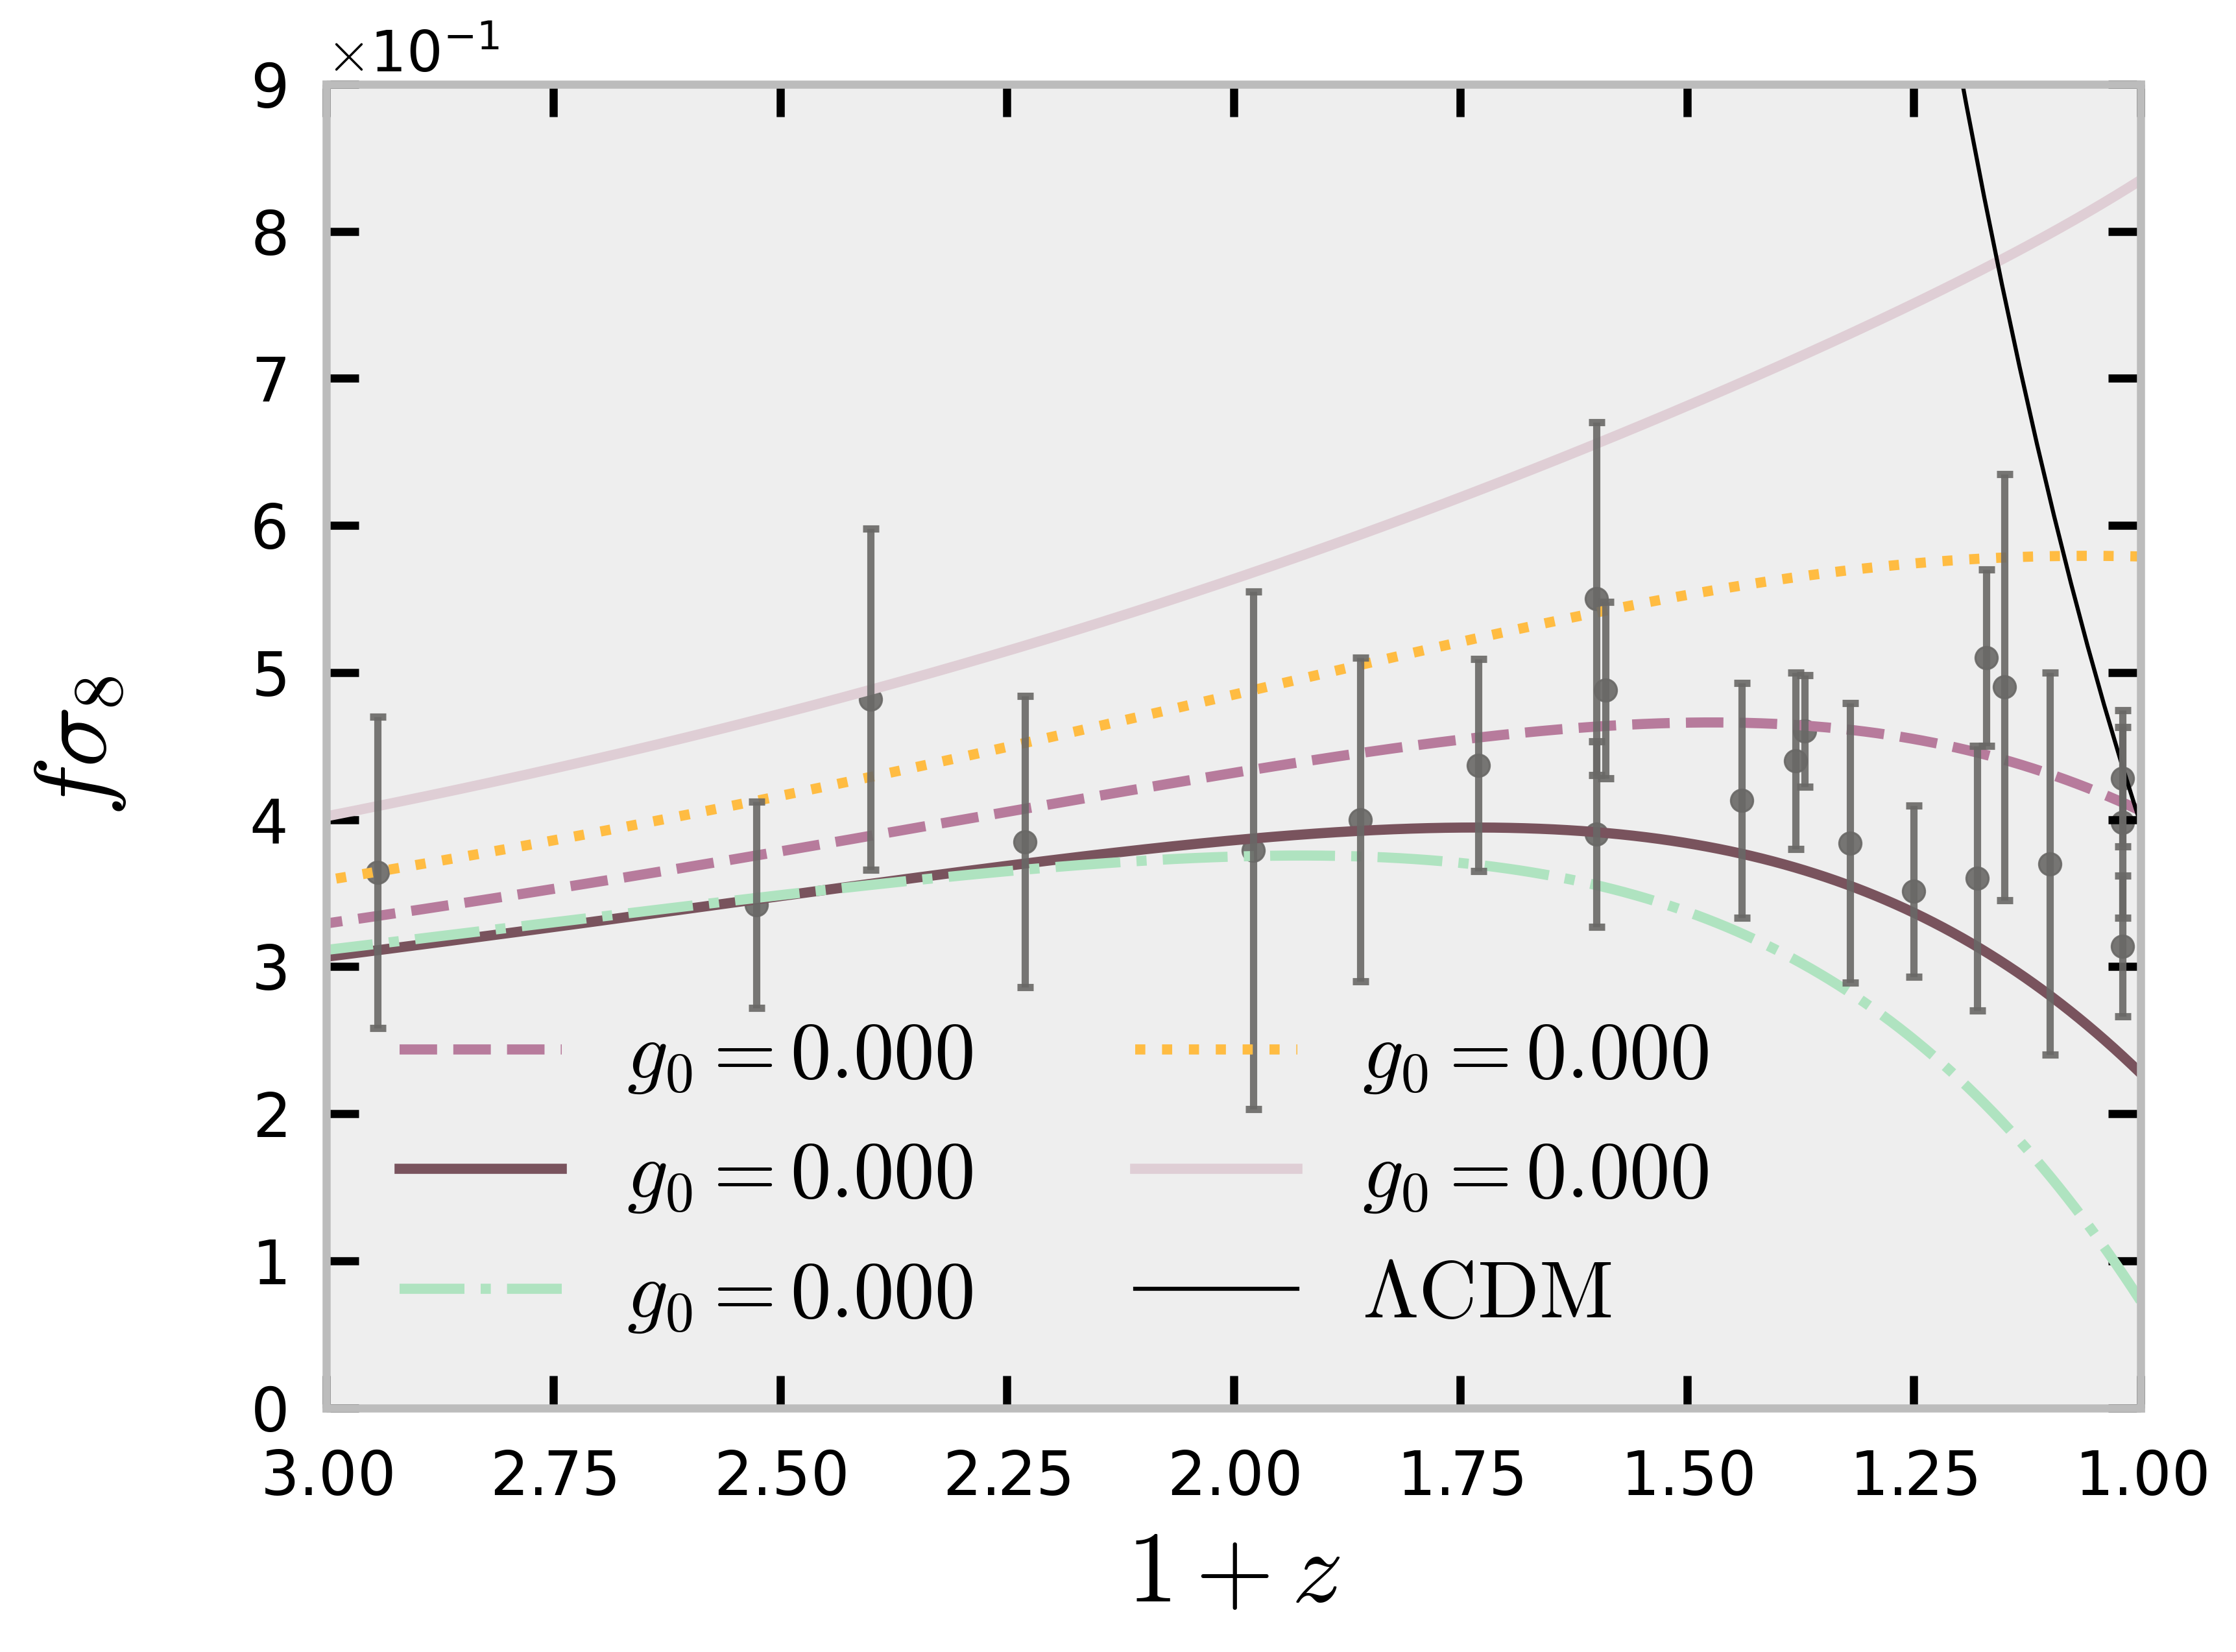

In [38]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

# --- keep your style ---
try:
    plt.style.use(['ipynb', 'use_mathtext','colors5-light'])
except Exception:
    plt.style.use('default')

lw = 2.5
ls = ['--','-','-.', ':', '-']
boolean = globals().get('boolean', False)
if 'color' not in globals():
    color = plt.rcParams['axes.prop_cycle'].by_key().get('color', ['C0','C1','C2','C3','C4'])

fig, ax = plt.subplots(1, 1, figsize=(8,6))

for i in [3]:  # --------------------------------------------> values of k-scales
    index_k = i
    print('k =', k_sorted[index_k])
    style = 0

    # ---------------- Coupled models ----------------
    for index in [0,1,2,3,4]:  # --------------------------------------------> values of beta
        # Background arrays (use increasing 1+z for interpolation)
        background_zm = cosmo_background[index]['z'] + 1.0
        background_H  = cosmo_background[index]['H [1/Mpc]']
        background_zm2 = background_zm[::-1]  # increasing
        background_H2  = background_H[::-1]

        # Perturbation arrays (use increasing 1+z for interpolation)
        pert_a   = np.array(cosmo_perturbations[index]['scalar'][index_k]['a'])
        pert_zm  = 1.0/pert_a
        pert_delta_mtot        = np.array(cosmo_perturbations[index]['scalar'][index_k]['delta_mtot'])
        pert_delta_mtot_prime  = np.array(cosmo_perturbations[index]['scalar'][index_k]['delta_mtot_prime'])

        # reverse to increasing 1+z for interp x-grid
        pert_zm2               = pert_zm[::-1]
        pert_a2                = pert_a[::-1]
        pert_delta_mtot2       = pert_delta_mtot[::-1]
        pert_delta_mtot_prime2 = pert_delta_mtot_prime[::-1]

        # Interpolators (safe at bounds; no repeated rebuild inside loop)
        a_int   = interp1d(pert_zm2, pert_a2, kind='linear', bounds_error=False, fill_value="extrapolate")
        H_int   = interp1d(background_zm2, background_H2, kind='cubic',   bounds_error=False, fill_value="extrapolate")
        dprime_int = interp1d(pert_zm2, pert_delta_mtot_prime2, kind='linear', bounds_error=False, fill_value="extrapolate")

        # Normalizations
        delta_mtot0 = float(pert_delta_mtot[-1])  # at z=0 (a ~ 1)
        s8 = float(cosmo[index].sigma8())
        #print(s8)

        # Compute on the native pert grid (all points, including last)
        z_grid = pert_zm2  # 1+z
        # fσ8 = (σ8/δ0) * δ' / (a H) ; where δ' is dδ/dτ, H is physical H[1/Mpc]
        fs8_vals = (s8 / delta_mtot0) * (dprime_int(z_grid) / (H_int(z_grid) * a_int(z_grid)))

        ax.plot(z_grid, fs8_vals,
                label=rf'$g_0 = {f0s[index]:.3f}$' if index < len(n0s) else rf'$i={index}$',
                lw=lw, ls=ls[style % len(ls)], c=color[style % len(color)])
        style += 1

    # ---------------- ΛCDM reference ----------------
    standard_perturbations = standard.get_perturbations()
    background_zm = standard_background['z'] + 1.0
    background_H  = standard_background['H [1/Mpc]']
    background_zm2 = background_zm[::-1]
    background_H2  = background_H[::-1]

    pert_a   = np.array(standard_perturbations['scalar'][index_k]['a'])
    pert_zm  = 1.0/pert_a
    pert_delta_mtot        = np.array(standard_perturbations['scalar'][index_k]['delta_mtot'])
    print(pert_delta_mtot)
    pert_delta_mtot_prime  = np.array(standard_perturbations['scalar'][index_k]['delta_mtot_prime'])

    pert_zm2               = pert_zm[::-1]
    pert_a2                = pert_a[::-1]
    pert_delta_mtot2       = pert_delta_mtot[::-1]
    pert_delta_mtot_prime2 = pert_delta_mtot_prime[::-1]

    a_int   = interp1d(pert_zm2, pert_a2, kind='linear', bounds_error=False, fill_value="extrapolate")
    H_int   = interp1d(background_zm2, background_H2, kind='cubic',   bounds_error=False, fill_value="extrapolate")
    dprime_int = interp1d(pert_zm2, pert_delta_mtot_prime2, kind='linear', bounds_error=False, fill_value="extrapolate")

    delta_mtot0 = float(pert_delta_mtot[-1])
    s8_std = float(standard.sigma8())
    print(s8_std)

    z_grid = pert_zm2
    print(delta_mtot0)
    fs8_vals = (s8_std / delta_mtot0) * (dprime_int(z_grid) / (H_int(z_grid) * a_int(z_grid)))

    ax.plot(z_grid, fs8_vals, c='k', ls='-', label=r'$\Lambda{\rm CDM}$', lw=1)

    # ---------------- Data points (unchanged) ----------------
    x0 = [1.02,1.02,1.02,1.10,1.15,1.17,1.18,1.38,1.25,1.37,1.32,1.59,1.44,1.6,1.73,1.6,1.86,2.4,1.978,2.23,2.526,2.944]
    y  = [0.428,0.398,0.314,0.370,0.49,0.51,0.36,0.44,0.3512,0.4602,0.384,0.488,0.413,0.39,0.437,0.55,0.4,0.482,0.379,0.385,0.342,0.364]
    err = [0.0465,0.065,0.048,0.13,0.145,0.06,0.09,0.06,0.0583,0.0378,0.095,0.06,0.08,0.063,0.072,0.12,0.11,0.116,0.176,0.099,0.07,0.106]
    yerr = [err, err]
    plt.errorbar(x0, y, yerr=yerr, fmt='o', color='#696866', linewidth=lw/1.4,
                 capsize=2, markersize=0., capthick=lw/1.4, alpha=0.9)
    plt.scatter(x0, y, marker='o', color='#696866', s=30., alpha=0.9)

# --------------- Axes, ticks, legend, save ---------------
ax.set_ylabel(r'$f \sigma_8$', size=25, labelpad=30)
ax.set_xlabel(r'$1+z$', size=25)
ax.set_xlim(3., 1.)   # high z (left) -> low z (right)
ax.set_ylim(0., 0.9)
ax.tick_params(axis='both', which='major', labelsize=15, width=1.1)
for tick in ax.xaxis.get_major_ticks(): tick.set_pad(10)
for tick in ax.yaxis.get_major_ticks(): tick.set_pad(10)

ax.xaxis.set_tick_params(which='major', size=8, width=2, direction='in', top=True)
ax.xaxis.set_tick_params(which='minor', size=7, width=2, direction='in', top=True)
ax.yaxis.set_tick_params(which='major', size=8, width=2, direction='in', right=True)
ax.yaxis.set_tick_params(which='minor', size=7, width=2, direction='in', right=True)

plt.legend(loc='best', frameon=boolean, prop={'size': 20}, ncol=2)
plt.rcParams['font.size'] = 18
plt.rcParams['axes.linewidth'] = 2
fig.tight_layout()
plt.savefig('fs8.pdf', transparent=True)
plt.show()


3.384987736011011e-05
3.384987736011011e-05


/var/folders/91/jymwbq1j1nng0wqyd6yvbm100000gn/T/ipykernel_82780/2496776274.py:109: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax0.set_xticklabels(labels)
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


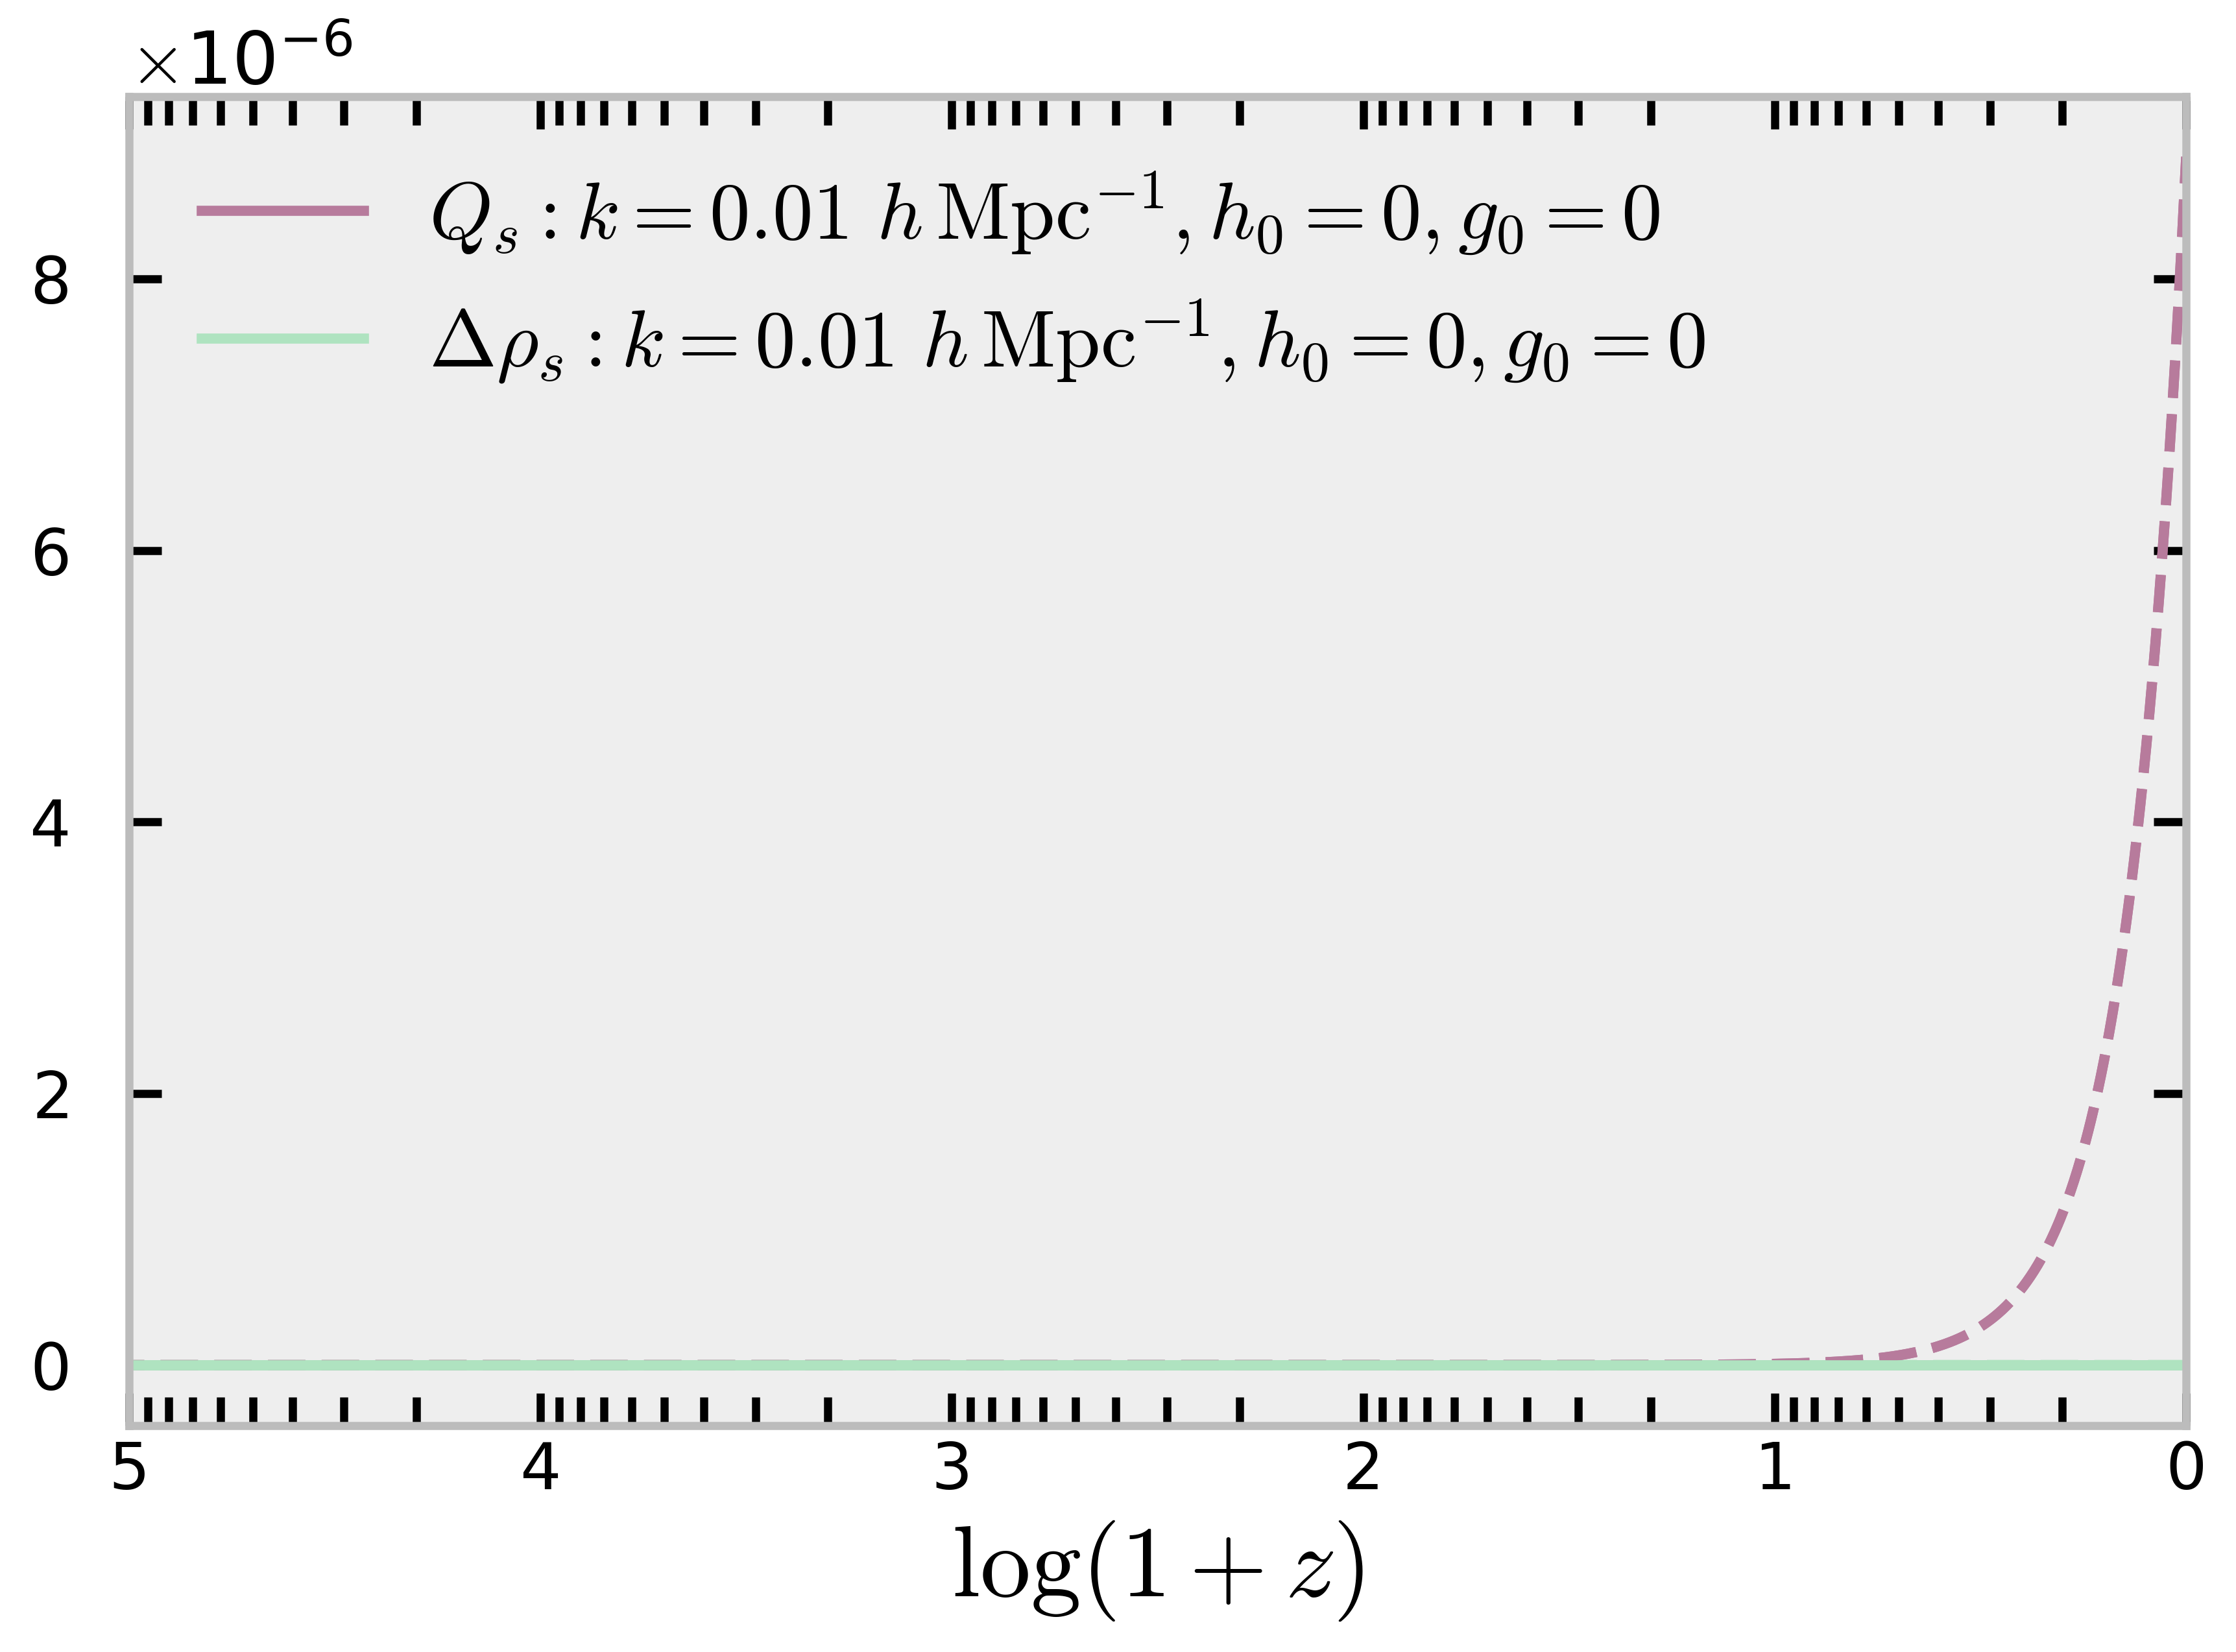

In [39]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

fig, ax0 = plt.subplots(figsize=(8,6))  # one panel only
ls = ['-','--','-.', ':', (0,(5,1))]

def build_interp1d(x, y, kind='linear', clamp=True):
    """Return an interp1d callable with sorted, duplicate-free x."""
    x = np.asarray(x); y = np.asarray(y)
    order = np.argsort(x)
    x = x[order]; y = y[order]
    xu, inv, cnt = np.unique(x, return_inverse=True, return_counts=True)
    if np.any(cnt > 1):
        yu = np.zeros_like(xu, dtype=float)
        np.add.at(yu, inv, y)   # average duplicates
        yu /= cnt
    else:
        yu = y
    fill = (yu[0], yu[-1]) if clamp else 'extrapolate'
    return interp1d(xu, yu, kind=kind, bounds_error=False, fill_value=fill, assume_sorted=True)

def interp_bg_to_pert(bg, key, a_target, kind='linear', clamp=True):
    """Interpolate background quantity 'key' onto perturbation a-grid using interp1d."""
    z_bg = np.asarray(bg['z'])
    a_bg = 1.0/(1.0 + z_bg)
    y_bg = np.asarray(bg[key])
    f = build_interp1d(a_bg, y_bg, kind=kind, clamp=clamp)
    return f(a_target)

def pick_first_key(d, candidates):
    for k in candidates:
        if k in d:
            return k
    raise KeyError(f"None of the keys found: {candidates}")

for ik, index_k in enumerate([1]):  # loop over k values
    color_idx = ik

    for ib, index in enumerate([0,1]):   # loop over beta values
        cosmoPerturb = cosmo[index].get_perturbations()
        cosmoBack = cosmo[index].get_background()

        pblock   = cosmoPerturb['scalar'][index_k]
        a        = pblock['a']                          # perturbation a-grid
        z = 1/a - 1
        delta_rho_scf    = pblock['delta_rho_scf']
        delta_phi        = pblock['delta_phi_scf']
        delta_phi_prime  = pblock['delta_phi_prime_scf']
        psi              = pblock['psi']

        h0 = h0s[index]
        f0 = f0s[index]
        delta_s = A0s[index]*pow(k_sorted[index_k], n0s[index])

        # --- interpolate background pieces onto pert grid
        Vphi_key = pick_first_key(cosmoBack, ["V'_scf", "V_prime_scf", "Vphi_prime_scf"])
        Vphi_on_pert = interp_bg_to_pert(cosmoBack, Vphi_key, a, kind='linear', clamp=True)

        Vphiphi_key = pick_first_key(cosmoBack, ["V''_scf", "V_primeprime_scf", "Vphi_primeprime_scf"])
        Vphiphi_on_pert = interp_bg_to_pert(cosmoBack, Vphiphi_key, a, kind='linear', clamp=True)

        phi_key = pick_first_key(cosmoBack, ["phi_scf", "phi_scf"])
        phi_on_pert = interp_bg_to_pert(cosmoBack, phi_key, a, kind='linear', clamp=True)
        
        phi_prime_key = pick_first_key(cosmoBack, ["phi'_scf", "phi_prime_scf"])
        phi_prime_on_pert = interp_bg_to_pert(cosmoBack, phi_prime_key, a, kind='linear', clamp=True)

        rho_c_key = pick_first_key(cosmoBack, ["(.)rho_edm"])
        rho_c_on_pert = interp_bg_to_pert(cosmoBack, rho_c_key, a, kind='linear', clamp=True)
        
        rho_tot_key = pick_first_key(cosmoBack, ["(.)rho_tot"])
        rho_tot_on_pert = interp_bg_to_pert(cosmoBack, rho_tot_key, a, kind='linear', clamp=True)

        H_key = pick_first_key(cosmoBack, ['H [1/Mpc]', 'H[1/Mpc]', 'H'])
        H_on_pert = interp_bg_to_pert(cosmoBack, H_key, a, kind='linear', clamp=True)
        horizon = H_on_pert  # if you decide to plot it
        print(a[-1]*pow(Vphiphi_on_pert[-1],1/2))

        kphys = k_sorted[index_k]/0.67556

        Qs = kphys*kphys * (f0*phi_on_pert - h0*Vphi_on_pert)/rho_c_on_pert
        rhos = (4*np.pi*6.67430e-11*a*a)*(f0*phi_on_pert - Vphi_on_pert*(a*a*f0 + kphys*kphys*h0)/(kphys*kphys + a*a*Vphiphi_on_pert*Vphiphi_on_pert))

        # label only once per k
        label_str1 = fr'$Q_s: k = {(kphys):.3g}\ h\,\mathrm{{Mpc}}^{{-1}}, h_0 = {(h0):.3g}, g_0= {(f0):.3g}$' if ib == 0 else None
        label_str2 = fr'$\Delta \rho_s: k = {(kphys):.3g}\ h\,\mathrm{{Mpc}}^{{-1}}, h_0 = {(h0):.3g}, g_0= {(f0):.3g}$' if ib == 0 else None

        ax0.plot(1+z, Qs, label=label_str1, lw=lw, ls=ls[ib], c=color[color_idx])
        ax0.plot(1+z, rhos, label=label_str2, lw=lw, ls=ls[ib], c=color[color_idx+2])

        # Optional horizon/k lines:
        # if ib == 0:
        #     ax0.plot(a, horizon, lw=lw, ls=':', c=color[color_idx+2])
        #     ax0.hlines(y=k_sorted[index_k], xmin=a[0], xmax=a[-1], lw=lw, ls='-.', colors=color[color_idx+3])

# Axes & styling
ax0.set_xscale('log')
ax0.set_xlabel(r'$\log(1+z)$', size=25)
#x0.set_ylabel(r'${c_s}^2_{\rm DE}$', size=25)
ax0.set_xlim(1e5, 1)
#ax0.set_ylim(-2.1, 2.1)
ax0.tick_params(axis='both', which='major', labelsize=16, width=1.1)
ax0.legend(loc='upper left', frameon=boolean, prop={'size': 20}, ncol=1)
original_labels = ax0.get_xticks()
labels = []
for label in original_labels:
    labels.append(int(np.log10(label)))
ax0.set_xticklabels(labels)

ax0.tick_params(axis='both', which='both', labelsize=16)
ax0.tick_params(axis='both', which='both', labelsize=16)

#---------------------------------------------------------------------------------> change ticklabels distance
ax1.tick_params(axis='both', which='both', labelsize=16)
ax1.tick_params(axis='both', which='both', labelsize=16)

for tick in ax1.xaxis.get_major_ticks():
    tick.set_pad(15)
for tick in ax0.yaxis.get_major_ticks():
    tick.set_pad(15)
for tick in ax1.yaxis.get_major_ticks():
    tick.set_pad(15)
    
ax0.tick_params(axis='both', which='both', labelsize=16)

    
ax0.xaxis.set_tick_params(which='major', size=8, width=2, direction='in', top='on')
ax0.xaxis.set_tick_params(which='minor', size=7, width=2, direction='in', top='on')
ax0.yaxis.set_tick_params(which='major', size=8, width=2, direction='in', right='on')
ax0.yaxis.set_tick_params(which='minor', size=7, width=2, direction='in', right='on')

ax1.tick_params(axis='both', which='both', labelsize=16)

    
ax1.xaxis.set_tick_params(which='major', size=8, width=2, direction='in', top='on')
ax1.xaxis.set_tick_params(which='minor', size=7, width=2, direction='in', top='on')
ax1.yaxis.set_tick_params(which='major', size=8, width=2, direction='in', right='on')
ax1.yaxis.set_tick_params(which='minor', size=7, width=2, direction='in', right='on')

for ax in (ax0, ax1):
    # copy the list so we don't iterate over lines we add
    lines = list(ax.get_lines())[1:]
    for ln in lines[::-1]:
        ax.plot(
            ln.get_xdata(), ln.get_ydata(),
            ls=ln.get_linestyle(),
            lw=ln.get_linewidth(),
            c=ln.get_color(),
            marker=ln.get_marker(),
            markersize=ln.get_markersize(),
            alpha=ln.get_alpha() if ln.get_alpha() is not None else 1.0,
            label="_nolegend_",  # labels starting with '_' are ignored by legend()
        )

fig.tight_layout()
plt.savefig('comp.pdf')
plt.show()


/var/folders/91/jymwbq1j1nng0wqyd6yvbm100000gn/T/ipykernel_82780/3715757810.py:31: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k" (-> color=(0.0, 0.0, 0.0, 1)). The keyword argument will take precedence.
  ax0.plot(kk,Pk_standard,'k', label = r'$\Lambda{\rm CDM}$', c = 'k', ls='-',  lw=1.5)


0.000629316321080721
-0.00038054142966350934
-0.12034076245559842
-0.0017652629412513985
-0.2335207315407575
-0.0031490232541521754
0.10301568947959065
0.0007279249913989791
0.23800944262272095
0.002114372339954729


'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


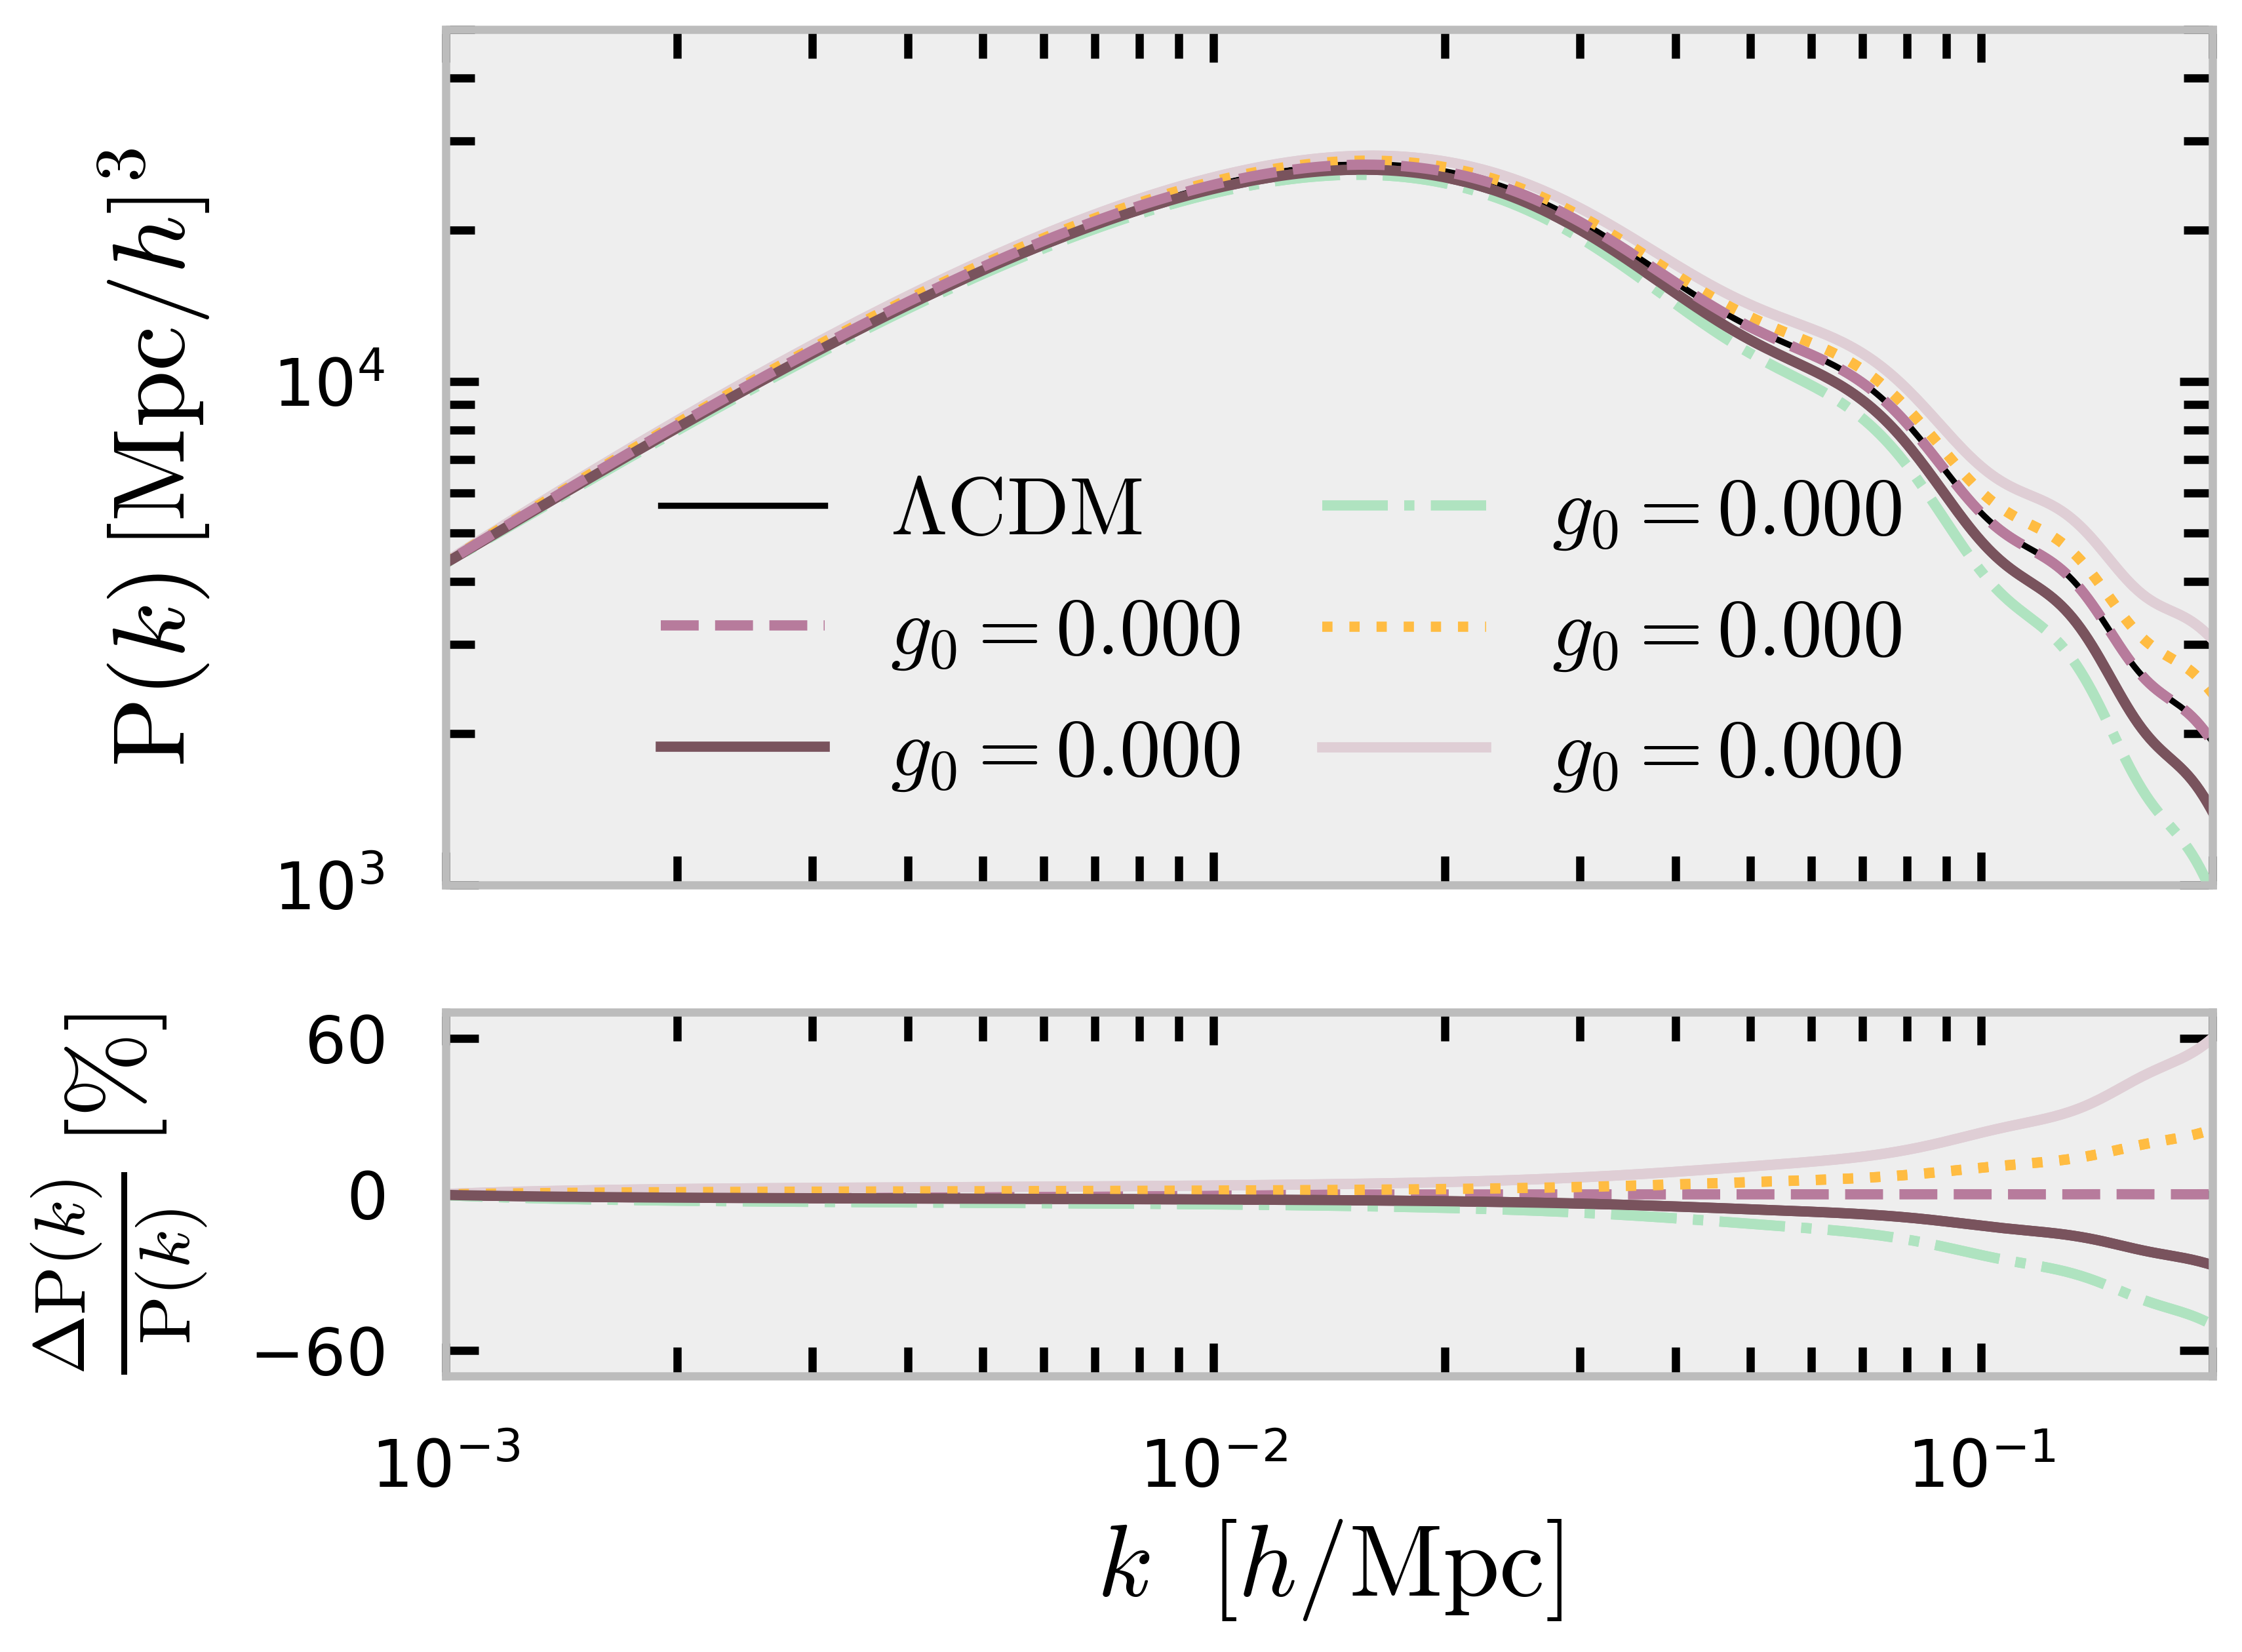

In [40]:
#plt.style.use('classic')
#vapeplot.set_palette('seapunk')
plt.style.use(['ipynb', 'use_mathtext','colors10-ls'])

lw = 2.5
ls = ['--','-','-.', ':', '-']


fig = plt.figure(figsize=(8,6))
ax0 = plt.subplot2grid((3,1),(0,0), rowspan=2)
ax1 = plt.subplot2grid((3,1),(2,0), rowspan=1,sharex = ax0)

plt.subplots_adjust(hspace=0,wspace=0.)

kk = np.logspace(-5,np.log10(1),1000) # k in h/Mpc

Pk_standard = [] # P(k) in (Mpc/h)**3
h_standard = standard.h() # get reduced Hubble for conversions to 1/Mpc

#Pk_weird = [] # P(k) in (Mpc/h)**3
#h_weird = weird.h() # get reduced Hubble for conversions to 1/Mpc
#DELTAweird = []

for k in kk:
    Pk_standard.append(standard.pk(k*h_standard,0.)*h_standard**3) # function .pk(k,z)
    #Pk_weird.append(standard.pk(k*h_weird,0.)*h_weird**3) # function .pk(k,z)
    #DELTAweird.append(100*(weird.pk(k*h_weird,0.)*h_weird**3 - standard.pk(k*h_standard,0.)*h_standard**3)\
     #   /(standard.pk(k*h_standard,0.)*h_standard**3))
    
i=0
ax0.plot(kk,Pk_standard,'k', label = r'$\Lambda{\rm CDM}$', c = 'k', ls='-',  lw=1.5)
#ax0.plot(kk,Pk_weird,'k', label = r'$\Lambda{\rm CDM}$', c = 'r', ls='--',  lw=1.5)

for index in [0,1,2,3,4]:
    Pk = [] # P(k) in (Mpc/h)**3
    h = cosmo[index].h() # get reduced Hubble for conversions to 1/Mpc
    DELTA = []
    for k in kk:
        Pk.append(cosmo[index].pk(k*h,0.)*h**3) # function .pk(k,z)
        DELTA.append(100*(cosmo[index].pk(k*h,0.)*h**3 - standard.pk(k*h_standard,0.)*h_standard**3)\
        /(standard.pk(k*h_standard,0.)*h_standard**3))
    # plot P(k)
    ax0.plot(kk,Pk, label = \
                 r'$g_0 = %.3f$'%(f0s[index]), lw=lw, ls=ls[i], c=color[i])
    ax1.plot(kk,DELTA, label = \
                 r'$g_0 = %.3f$'%(f0s[index]), lw=lw, ls=ls[i], c=color[i])
    #ax1.plot(kk,DELTAweird, lw=lw, ls='--', c='r')
    print((cosmo[index].pk(0.1*h,0.)-standard.pk(0.1*h_standard,0.))/standard.pk(0.1*h_standard,0.))
    print((cosmo[index].pk(0.001*h,0.)-standard.pk(0.001*h_standard,0.))/standard.pk(0.001*h_standard,0.))
    i+=1


    

ax0.set_xscale('log');ax0.set_yscale('linear');ax0.set_xlim(kk[0],kk[-1]);ax0.set_ylim(5,1e5)
ax1.set_xscale('log');ax1.set_yscale('linear');ax1.set_xlim(kk[0],kk[-1])

ax1.set_xlabel(r'$k \,\,\,\, [h/{\rm Mpc}]$', size=25)
ax0.set_ylabel(r'${\rm P} (k) \,[{\rm Mpc}/h]^3$', size=25,labelpad=15)
ax1.set_ylabel(r'$\frac{\Delta {\rm P}(k)}{{\rm P}(k)}\, [\%]$', size=25,labelpad=10)

ax0.set_xlim([1.e-3,0.2])
ax1.set_xlim([1.e-3,0.2])
ax0.set_ylim([1e3,5.*1e4])
ax1.set_ylim(-70,70)
ax1.set_yticks([i for i in np.linspace(-60,60,3)])

ax0.ticklabel_format(axis='y', style='sci', scilimits=(0,0), useMathText=True)
ax1.ticklabel_format(axis='y', style='plain', useMathText=True)

ax0.tick_params(axis='both', which='both', labelsize=16)
ax0.tick_params(axis='both', which='both', labelsize=16)

#---------------------------------------------------------------------------------> change ticklabels distance
ax1.tick_params(axis='both', which='both', labelsize=16)
ax1.tick_params(axis='both', which='both', labelsize=16)

for tick in ax1.xaxis.get_major_ticks():
    tick.set_pad(15)
for tick in ax0.yaxis.get_major_ticks():
    tick.set_pad(15)
for tick in ax1.yaxis.get_major_ticks():
    tick.set_pad(15)

    
#ax0.set_xscale('log')
ax1.set_xscale('log')
ax0.set_yscale('log')


ax0.tick_params(axis='both', which='both', labelsize=16)

    
ax0.xaxis.set_tick_params(which='major', size=8, width=2, direction='in', top='on')
ax0.xaxis.set_tick_params(which='minor', size=7, width=2, direction='in', top='on')
ax0.yaxis.set_tick_params(which='major', size=8, width=2, direction='in', right='on')
ax0.yaxis.set_tick_params(which='minor', size=7, width=2, direction='in', right='on')

ax1.tick_params(axis='both', which='both', labelsize=16)

    
ax1.xaxis.set_tick_params(which='major', size=8, width=2, direction='in', top='on')
ax1.xaxis.set_tick_params(which='minor', size=7, width=2, direction='in', top='on')
ax1.yaxis.set_tick_params(which='major', size=8, width=2, direction='in', right='on')
ax1.yaxis.set_tick_params(which='minor', size=7, width=2, direction='in', right='on')

for ax in (ax0, ax1):
    # copy the list so we don't iterate over lines we add
    lines = list(ax.get_lines())[1:]
    for ln in lines[::-1]:
        ax.plot(
            ln.get_xdata(), ln.get_ydata(),
            ls=ln.get_linestyle(),
            lw=ln.get_linewidth(),
            c=ln.get_color(),
            marker=ln.get_marker(),
            markersize=ln.get_markersize(),
            alpha=ln.get_alpha() if ln.get_alpha() is not None else 1.0,
            label="_nolegend_",  # labels starting with '_' are ignored by legend()
        )


ax0.legend(loc='lower left', frameon=boolean, prop={'size': 20}, bbox_to_anchor=(0.08, 0.02),ncol=2,columnspacing=1)
plt.setp(ax0.get_xticklabels(), visible=False)
plt.rcParams['font.size'] = 20
plt.rcParams['axes.linewidth'] = 2
fig.tight_layout()
plt.savefig('mpk.pdf'), 
#transparent=True)
plt.show()

/var/folders/91/jymwbq1j1nng0wqyd6yvbm100000gn/T/ipykernel_82780/3731469594.py:31: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k" (-> color=(0.0, 0.0, 0.0, 1)). The keyword argument will take precedence.
  ax0.plot(kk,Pk_standard,'k', label = r'$\Lambda{\rm CDM}$', c = 'k', ls='-',  lw=1.5)


0.0006809131663239207
-0.0004262021206995543
0.0005400904691582837
-0.0003697133656855222
0.0003981550420999796
-0.0003132228549950263
0.0007951113489218488
-0.00047139226265119545
0.0009364860875251117
-0.0005278783039620054


'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


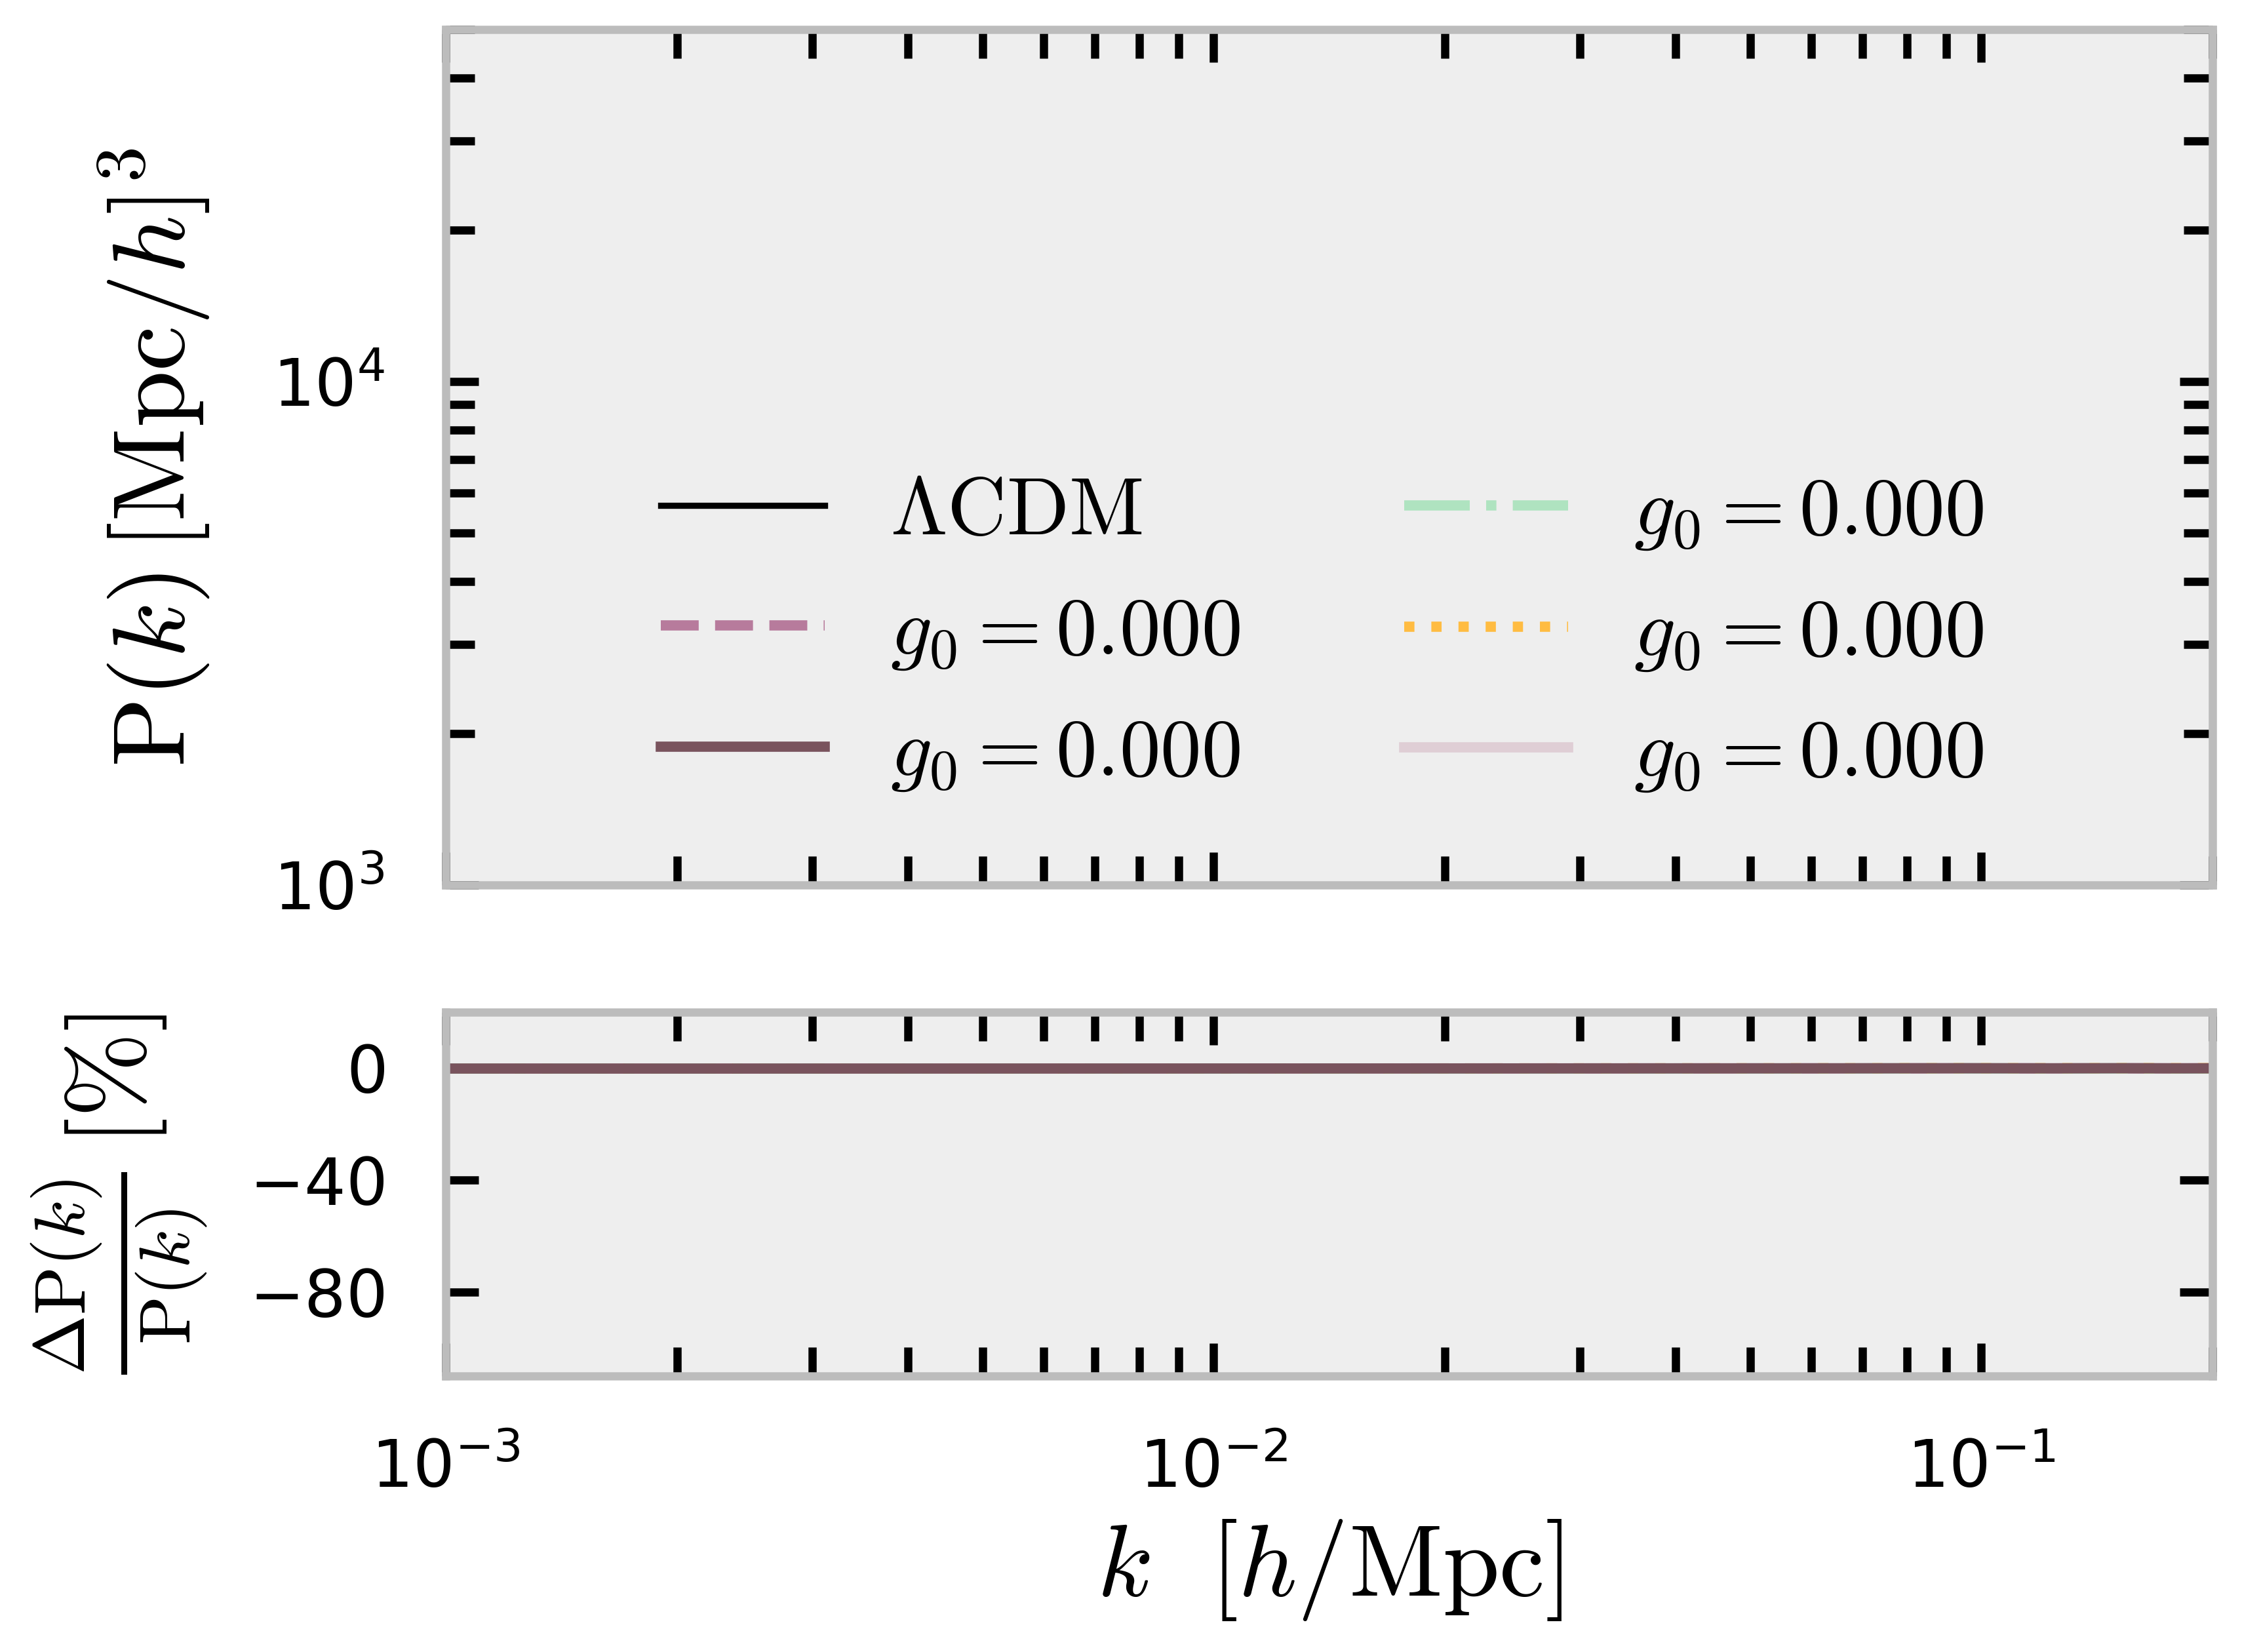

In [41]:
#plt.style.use('classic')
#vapeplot.set_palette('seapunk')
plt.style.use(['ipynb', 'use_mathtext','colors10-ls'])

lw = 2.5
ls = ['--','-','-.', ':', '-']


fig = plt.figure(figsize=(8,6))
ax0 = plt.subplot2grid((3,1),(0,0), rowspan=2)
ax1 = plt.subplot2grid((3,1),(2,0), rowspan=1,sharex = ax0)

plt.subplots_adjust(hspace=0,wspace=0.)

kk = np.logspace(-5,np.log10(1),1000) # k in h/Mpc

Pk_standard = [] # P(k) in (Mpc/h)**3
h_standard = standard.h() # get reduced Hubble for conversions to 1/Mpc

#Pk_weird = [] # P(k) in (Mpc/h)**3
#h_weird = weird.h() # get reduced Hubble for conversions to 1/Mpc
#DELTAweird = []
z0=10
for k in kk:
    Pk_standard.append(standard.pk(k*h_standard,z0)*h_standard**3) # function .pk(k,z)
    #Pk_weird.append(standard.pk(k*h_weird,0.)*h_weird**3) # function .pk(k,z)
    #DELTAweird.append(100*(weird.pk(k*h_weird,0.)*h_weird**3 - standard.pk(k*h_standard,0.)*h_standard**3)\
     #   /(standard.pk(k*h_standard,0.)*h_standard**3))
    
i=0
ax0.plot(kk,Pk_standard,'k', label = r'$\Lambda{\rm CDM}$', c = 'k', ls='-',  lw=1.5)
#ax0.plot(kk,Pk_weird,'k', label = r'$\Lambda{\rm CDM}$', c = 'r', ls='--',  lw=1.5)

for index in [0,1,2,3,4]:
    Pk = [] # P(k) in (Mpc/h)**3
    h = cosmo[index].h() # get reduced Hubble for conversions to 1/Mpc
    DELTA = []
    for k in kk:
        Pk.append(cosmo[index].pk(k*h,z0)*h**3) # function .pk(k,z)
        DELTA.append(100*(cosmo[index].pk(k*h,z0)*h**3 - standard.pk(k*h_standard,z0)*h_standard**3)\
        /(standard.pk(k*h_standard,z0)*h_standard**3))
    # plot P(k)
    ax0.plot(kk,Pk, label = \
                r'$g_0 = %.3f$'%(f0s[index]), lw=lw, ls=ls[i], c=color[i])
    ax1.plot(kk,DELTA, label = \
                r'$g_0 = %.3f$'%(f0s[index]), lw=lw, ls=ls[i], c=color[i])
    #ax1.plot(kk,DELTAweird, lw=lw, ls='--', c='r')
    print((cosmo[index].pk(0.1*h,z0)-standard.pk(0.1*h_standard,z0))/standard.pk(0.1*h_standard,z0))
    print((cosmo[index].pk(0.001*h,z0)-standard.pk(0.001*h_standard,z0))/standard.pk(0.001*h_standard,z0))
    i+=1


    

ax0.set_xscale('log');ax0.set_yscale('linear');ax0.set_xlim(kk[0],kk[-1]);ax0.set_ylim(5,1e5)
ax1.set_xscale('log');ax1.set_yscale('linear');ax1.set_xlim(kk[0],kk[-1])

ax1.set_xlabel(r'$k \,\,\,\, [h/{\rm Mpc}]$', size=25)
ax0.set_ylabel(r'${\rm P} (k) \,[{\rm Mpc}/h]^3$', size=25,labelpad=15)
ax1.set_ylabel(r'$\frac{\Delta {\rm P}(k)}{{\rm P}(k)}\, [\%]$', size=25,labelpad=10)

ax0.set_xlim([1.e-3,0.2])
ax1.set_xlim([1.e-3,0.2])
ax0.set_ylim([1e3,5.*1e4])
ax1.set_ylim(-110,20)
ax1.set_yticks([i for i in np.linspace(-80,0,3)])

ax0.ticklabel_format(axis='y', style='sci', scilimits=(0,0), useMathText=True)
ax1.ticklabel_format(axis='y', style='plain', useMathText=True)

ax0.tick_params(axis='both', which='both', labelsize=16)
ax0.tick_params(axis='both', which='both', labelsize=16)

#---------------------------------------------------------------------------------> change ticklabels distance
ax1.tick_params(axis='both', which='both', labelsize=16)
ax1.tick_params(axis='both', which='both', labelsize=16)

for tick in ax1.xaxis.get_major_ticks():
    tick.set_pad(15)
for tick in ax0.yaxis.get_major_ticks():
    tick.set_pad(15)
for tick in ax1.yaxis.get_major_ticks():
    tick.set_pad(15)

    
#ax0.set_xscale('log')
ax1.set_xscale('log')
ax0.set_yscale('log')


ax0.tick_params(axis='both', which='both', labelsize=16)

    
ax0.xaxis.set_tick_params(which='major', size=8, width=2, direction='in', top='on')
ax0.xaxis.set_tick_params(which='minor', size=7, width=2, direction='in', top='on')
ax0.yaxis.set_tick_params(which='major', size=8, width=2, direction='in', right='on')
ax0.yaxis.set_tick_params(which='minor', size=7, width=2, direction='in', right='on')

ax1.tick_params(axis='both', which='both', labelsize=16)

    
ax1.xaxis.set_tick_params(which='major', size=8, width=2, direction='in', top='on')
ax1.xaxis.set_tick_params(which='minor', size=7, width=2, direction='in', top='on')
ax1.yaxis.set_tick_params(which='major', size=8, width=2, direction='in', right='on')
ax1.yaxis.set_tick_params(which='minor', size=7, width=2, direction='in', right='on')

for ax in (ax0, ax1):
    # copy the list so we don't iterate over lines we add
    lines = list(ax.get_lines())[1:]
    for ln in lines[::-1]:
        ax.plot(
            ln.get_xdata(), ln.get_ydata(),
            ls=ln.get_linestyle(),
            lw=ln.get_linewidth(),
            c=ln.get_color(),
            marker=ln.get_marker(),
            markersize=ln.get_markersize(),
            alpha=ln.get_alpha() if ln.get_alpha() is not None else 1.0,
            label="_nolegend_",  # labels starting with '_' are ignored by legend()
        )


ax0.legend(loc='lower left', frameon=boolean, prop={'size': 20}, bbox_to_anchor=(0.08, 0.02),ncol=2)
plt.setp(ax0.get_xticklabels(), visible=False)
plt.rcParams['font.size'] = 20
plt.rcParams['axes.linewidth'] = 2
fig.tight_layout()
plt.savefig('mpk-100.pdf'), 
#transparent=True)
plt.show()

'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


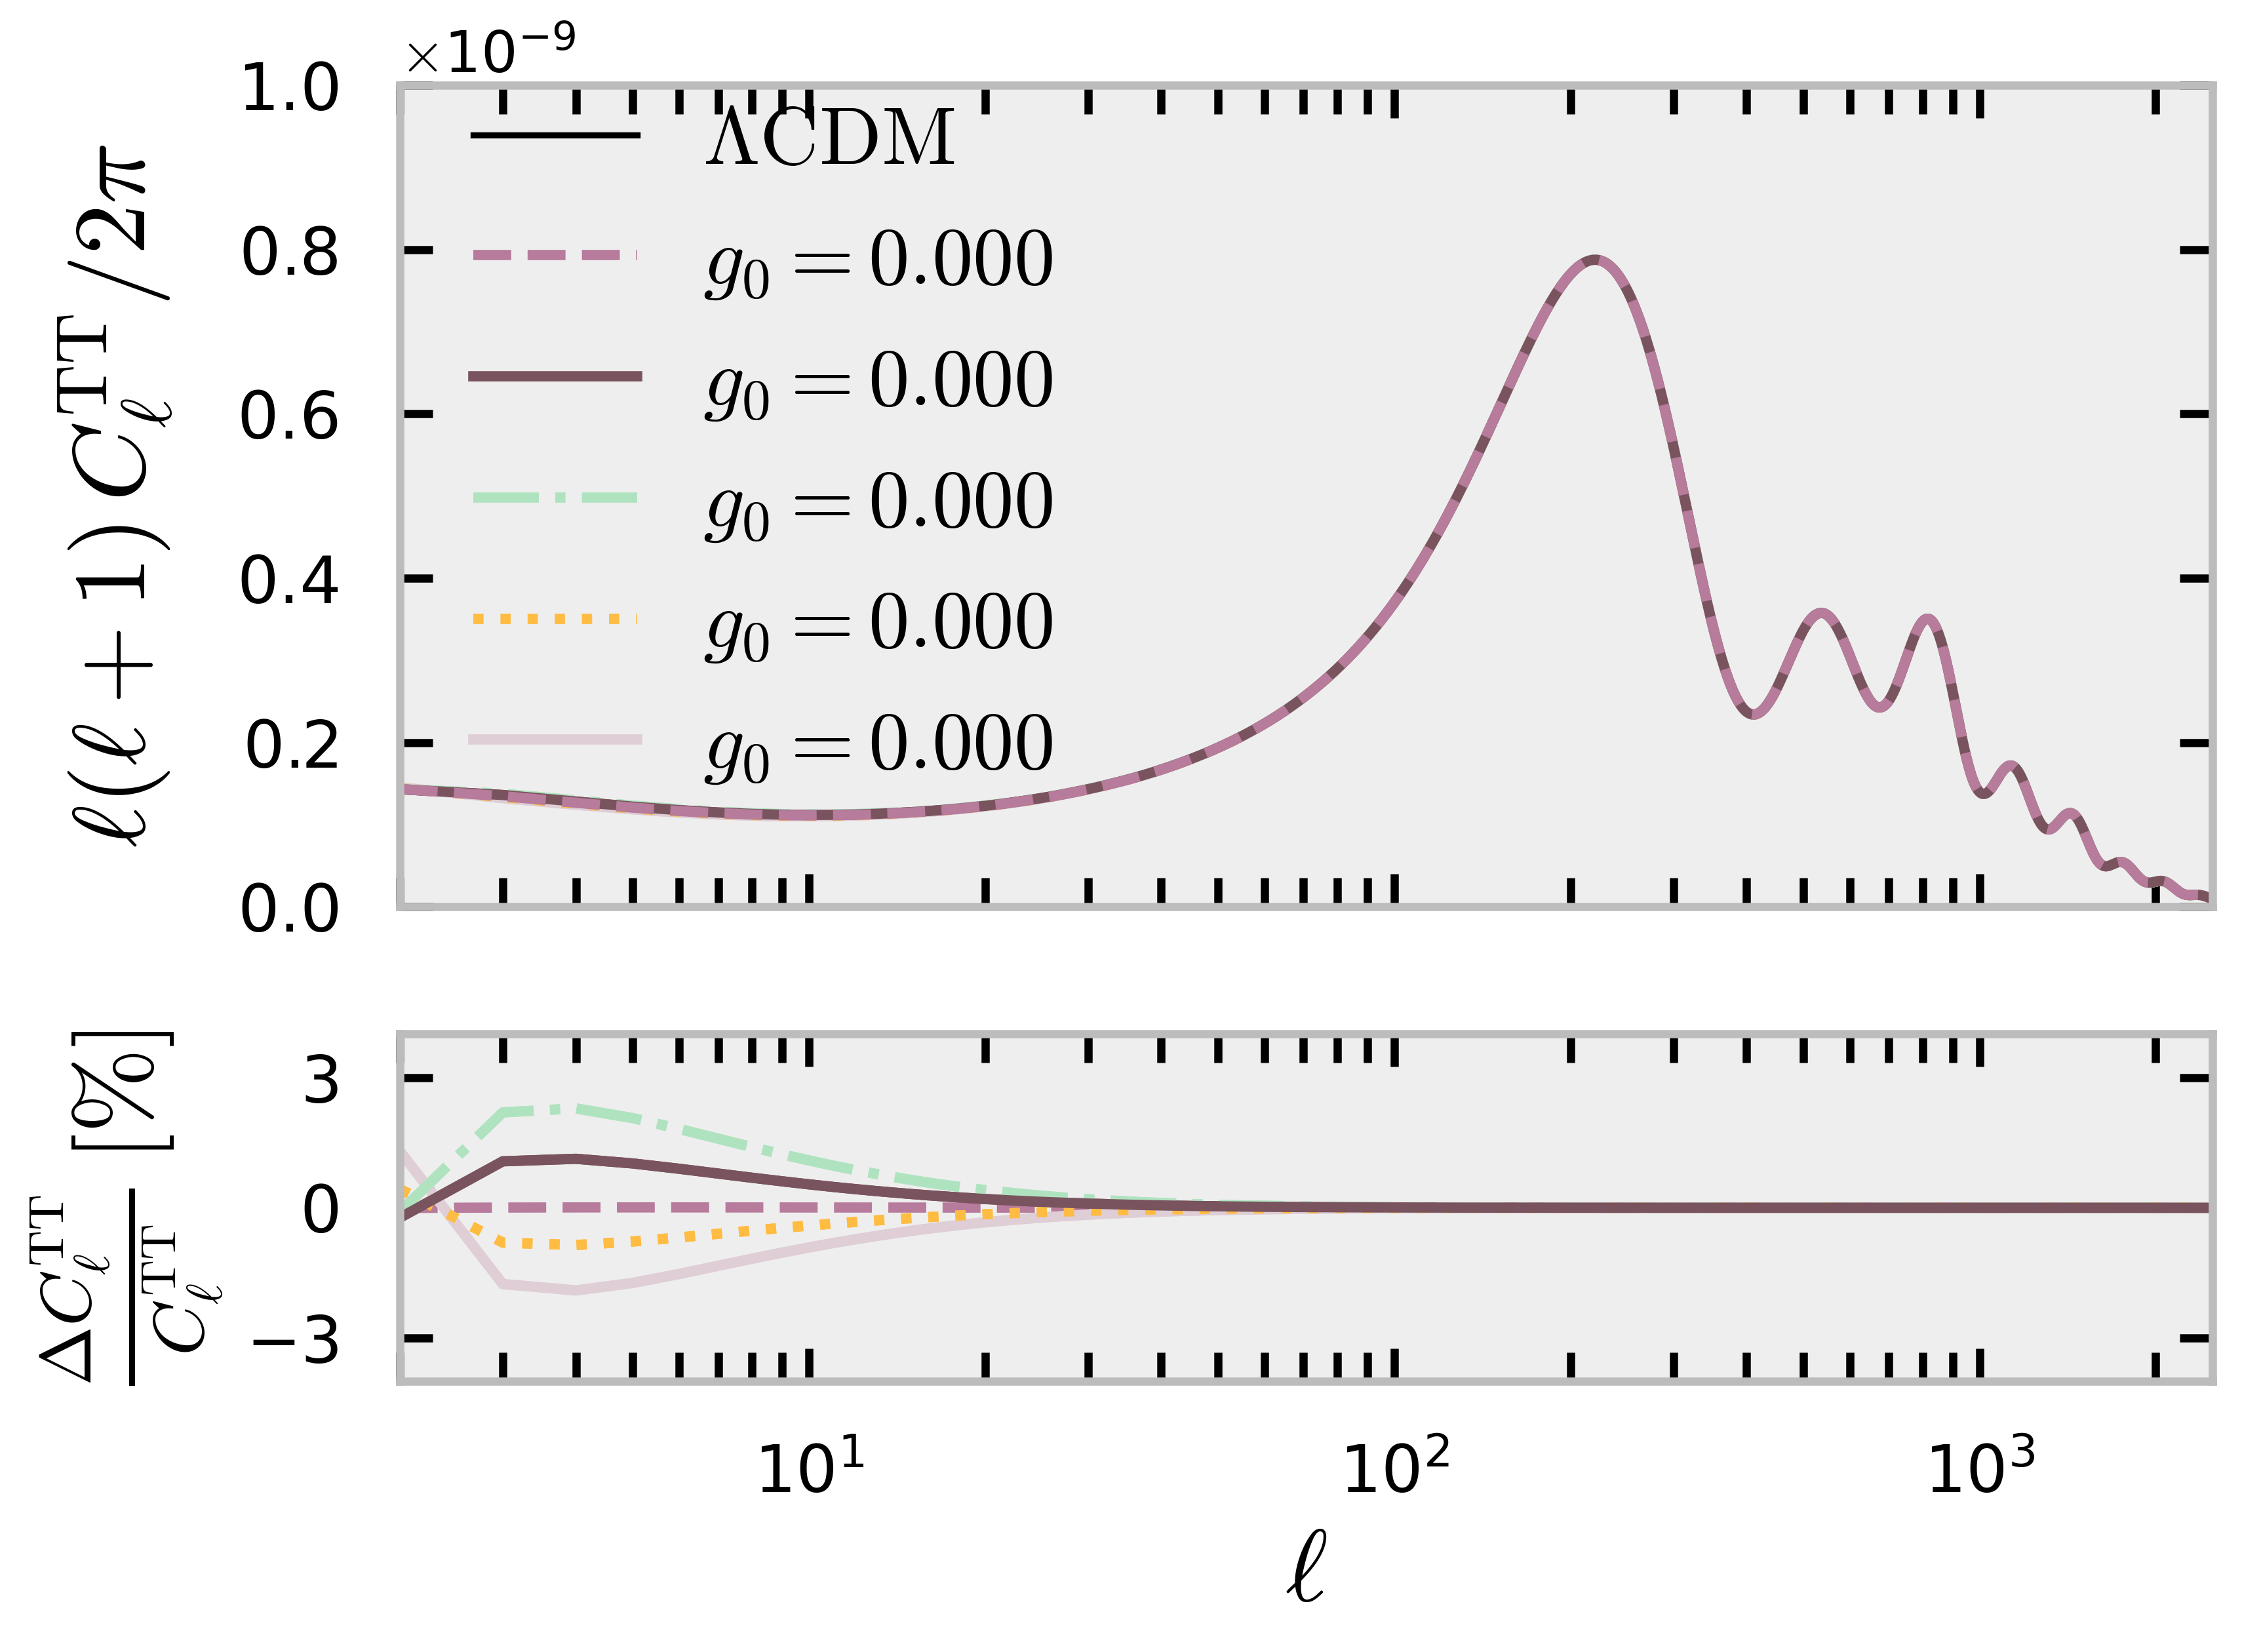

In [42]:
plt.style.use(['ipynb', 'use_mathtext','colors5-light'])

lw = 2.5
ls = ['--','-','-.', ':', '-']
#

fig = plt.figure(figsize=(8,6))
ax0 = plt.subplot2grid((3,1),(0,0), rowspan=2)
ax1 = plt.subplot2grid((3,1),(2,0), rowspan=1,sharex = ax0)

plt.subplots_adjust(hspace=0,wspace=0.)

# get lambdac
cls_standard = standard.raw_cl(2500)
ll = cls_standard['ell'][2:]
clTT_standard = cls_standard['tt'][2:]

#cls_weird = weird.raw_cl(2500)
#ll = cls_weird['ell'][2:]
#clTT_weird = cls_weird['tt'][2:]


i=0
# plot Lc
ax0.plot(ll,clTT_standard*ll*(ll+1)/2./np.pi, label = r'$\Lambda{\rm CDM}$', c = 'k', ls='-', lw=1.5)
#ax0.plot(ll,clTT_weird*ll*(ll+1)/2./np.pi, label = r'$\Lambda{\rm CDM}$', c = 'r', ls='--', lw=1.5)

for index in [0,1,2,3,4]: #--------------------------------> BETA
# get all C_l output
    cls = cosmo[index].raw_cl(2500)
    ll = cls['ell'][2:]
    clTT = cls['tt'][2:]
# plot C_l^TT
    ax0.plot(ll,clTT*ll*(ll+1)/2./np.pi, label = \
             r'$g_0 = %.3f$'%(f0s[index]),lw=lw, ls=ls[i], c=color[i])
    DELTA = (clTT  - clTT_standard) / clTT_standard
    ax1.plot(ll,DELTA*100, lw=lw, ls=ls[i], c=color[i])
    i+=1

    
    
#DELTAweird = (clTT_weird  - clTT_standard) / clTT_standard#
#ax1.plot(ll,DELTAweird*100, lw=lw, ls='--', c='r')
#ax1.plot(ll,DELTAweird*0, lw=lw, ls='-', c='k')

ax0.set_xscale('log');ax0.set_yscale('linear');ax0.set_xlim(2,2500);
ax0.set_ylim(0.e-10,10e-10)
ax1.set_xscale('log');ax1.set_yscale('linear');ax1.set_xlim(2,2500)
ax1.set_ylim(-4,4)
ax1.set_yticks([i for i in np.linspace(-3,3,3)])
ax1.set_xlabel(r'$\ell$', size=25)
ax0.set_ylabel(r'$\ell(\ell+1)\, C_\ell^\mathrm{TT}/2\pi$', size=25,labelpad=15)
ax1.set_ylabel(r'$\frac{\Delta C_\ell^\mathrm{TT}}{C_\ell^\mathrm{TT}}\, [\%]$', size=25,labelpad=5)

ax0.ticklabel_format(axis='y', style='sci', scilimits=(0,0), useMathText=True)
ax1.ticklabel_format(axis='y', style='plain', useMathText=True)

ax0.tick_params(axis='both', which='both', labelsize=16)
ax0.tick_params(axis='both', which='both', labelsize=16)

#---------------------------------------------------------------------------------> change ticklabels distance

for tick in ax1.xaxis.get_major_ticks():
    tick.set_pad(15)
for tick in ax0.yaxis.get_major_ticks():
    tick.set_pad(15)
for tick in ax1.yaxis.get_major_ticks():
    tick.set_pad(15)
    

ax0.tick_params(axis='both', which='both', labelsize=16)

    
ax0.xaxis.set_tick_params(which='major', size=8, width=2, direction='in', top='on')
ax0.xaxis.set_tick_params(which='minor', size=7, width=2, direction='in', top='on')
ax0.yaxis.set_tick_params(which='major', size=8, width=2, direction='in', right='on')
ax0.yaxis.set_tick_params(which='minor', size=7, width=2, direction='in', right='on')

ax1.tick_params(axis='both', which='both', labelsize=16)

    
ax1.xaxis.set_tick_params(which='major', size=8, width=2, direction='in', top='on')
ax1.xaxis.set_tick_params(which='minor', size=7, width=2, direction='in', top='on')
ax1.yaxis.set_tick_params(which='major', size=8, width=2, direction='in', right='on')
ax1.yaxis.set_tick_params(which='minor', size=7, width=2, direction='in', right='on')

plt.tight_layout()
#plt.savefig('cq_cmb_tt.pdf', transparent=True)

for ax in (ax0, ax1):
    # copy the list so we don't iterate over lines we add
    lines = list(ax.get_lines())[1:]
    for ln in lines[::-1]:
        ax.plot(
            ln.get_xdata(), ln.get_ydata(),
            ls=ln.get_linestyle(),
            lw=ln.get_linewidth(),
            c=ln.get_color(),
            marker=ln.get_marker(),
            markersize=ln.get_markersize(),
            alpha=ln.get_alpha() if ln.get_alpha() is not None else 1.0,
            label="_nolegend_",  # labels starting with '_' are ignored by legend()
        )

ax0.legend(loc='upper left', frameon=boolean, prop={'size': 20},ncol=1, bbox_to_anchor=(0.0, 1.07))
plt.setp(ax0.get_xticklabels(), visible=False)
plt.rcParams['font.size'] = 20
plt.rcParams['axes.linewidth'] = 2
fig.tight_layout()
plt.savefig('cls.pdf')
#, transparent=True)
plt.show()

'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


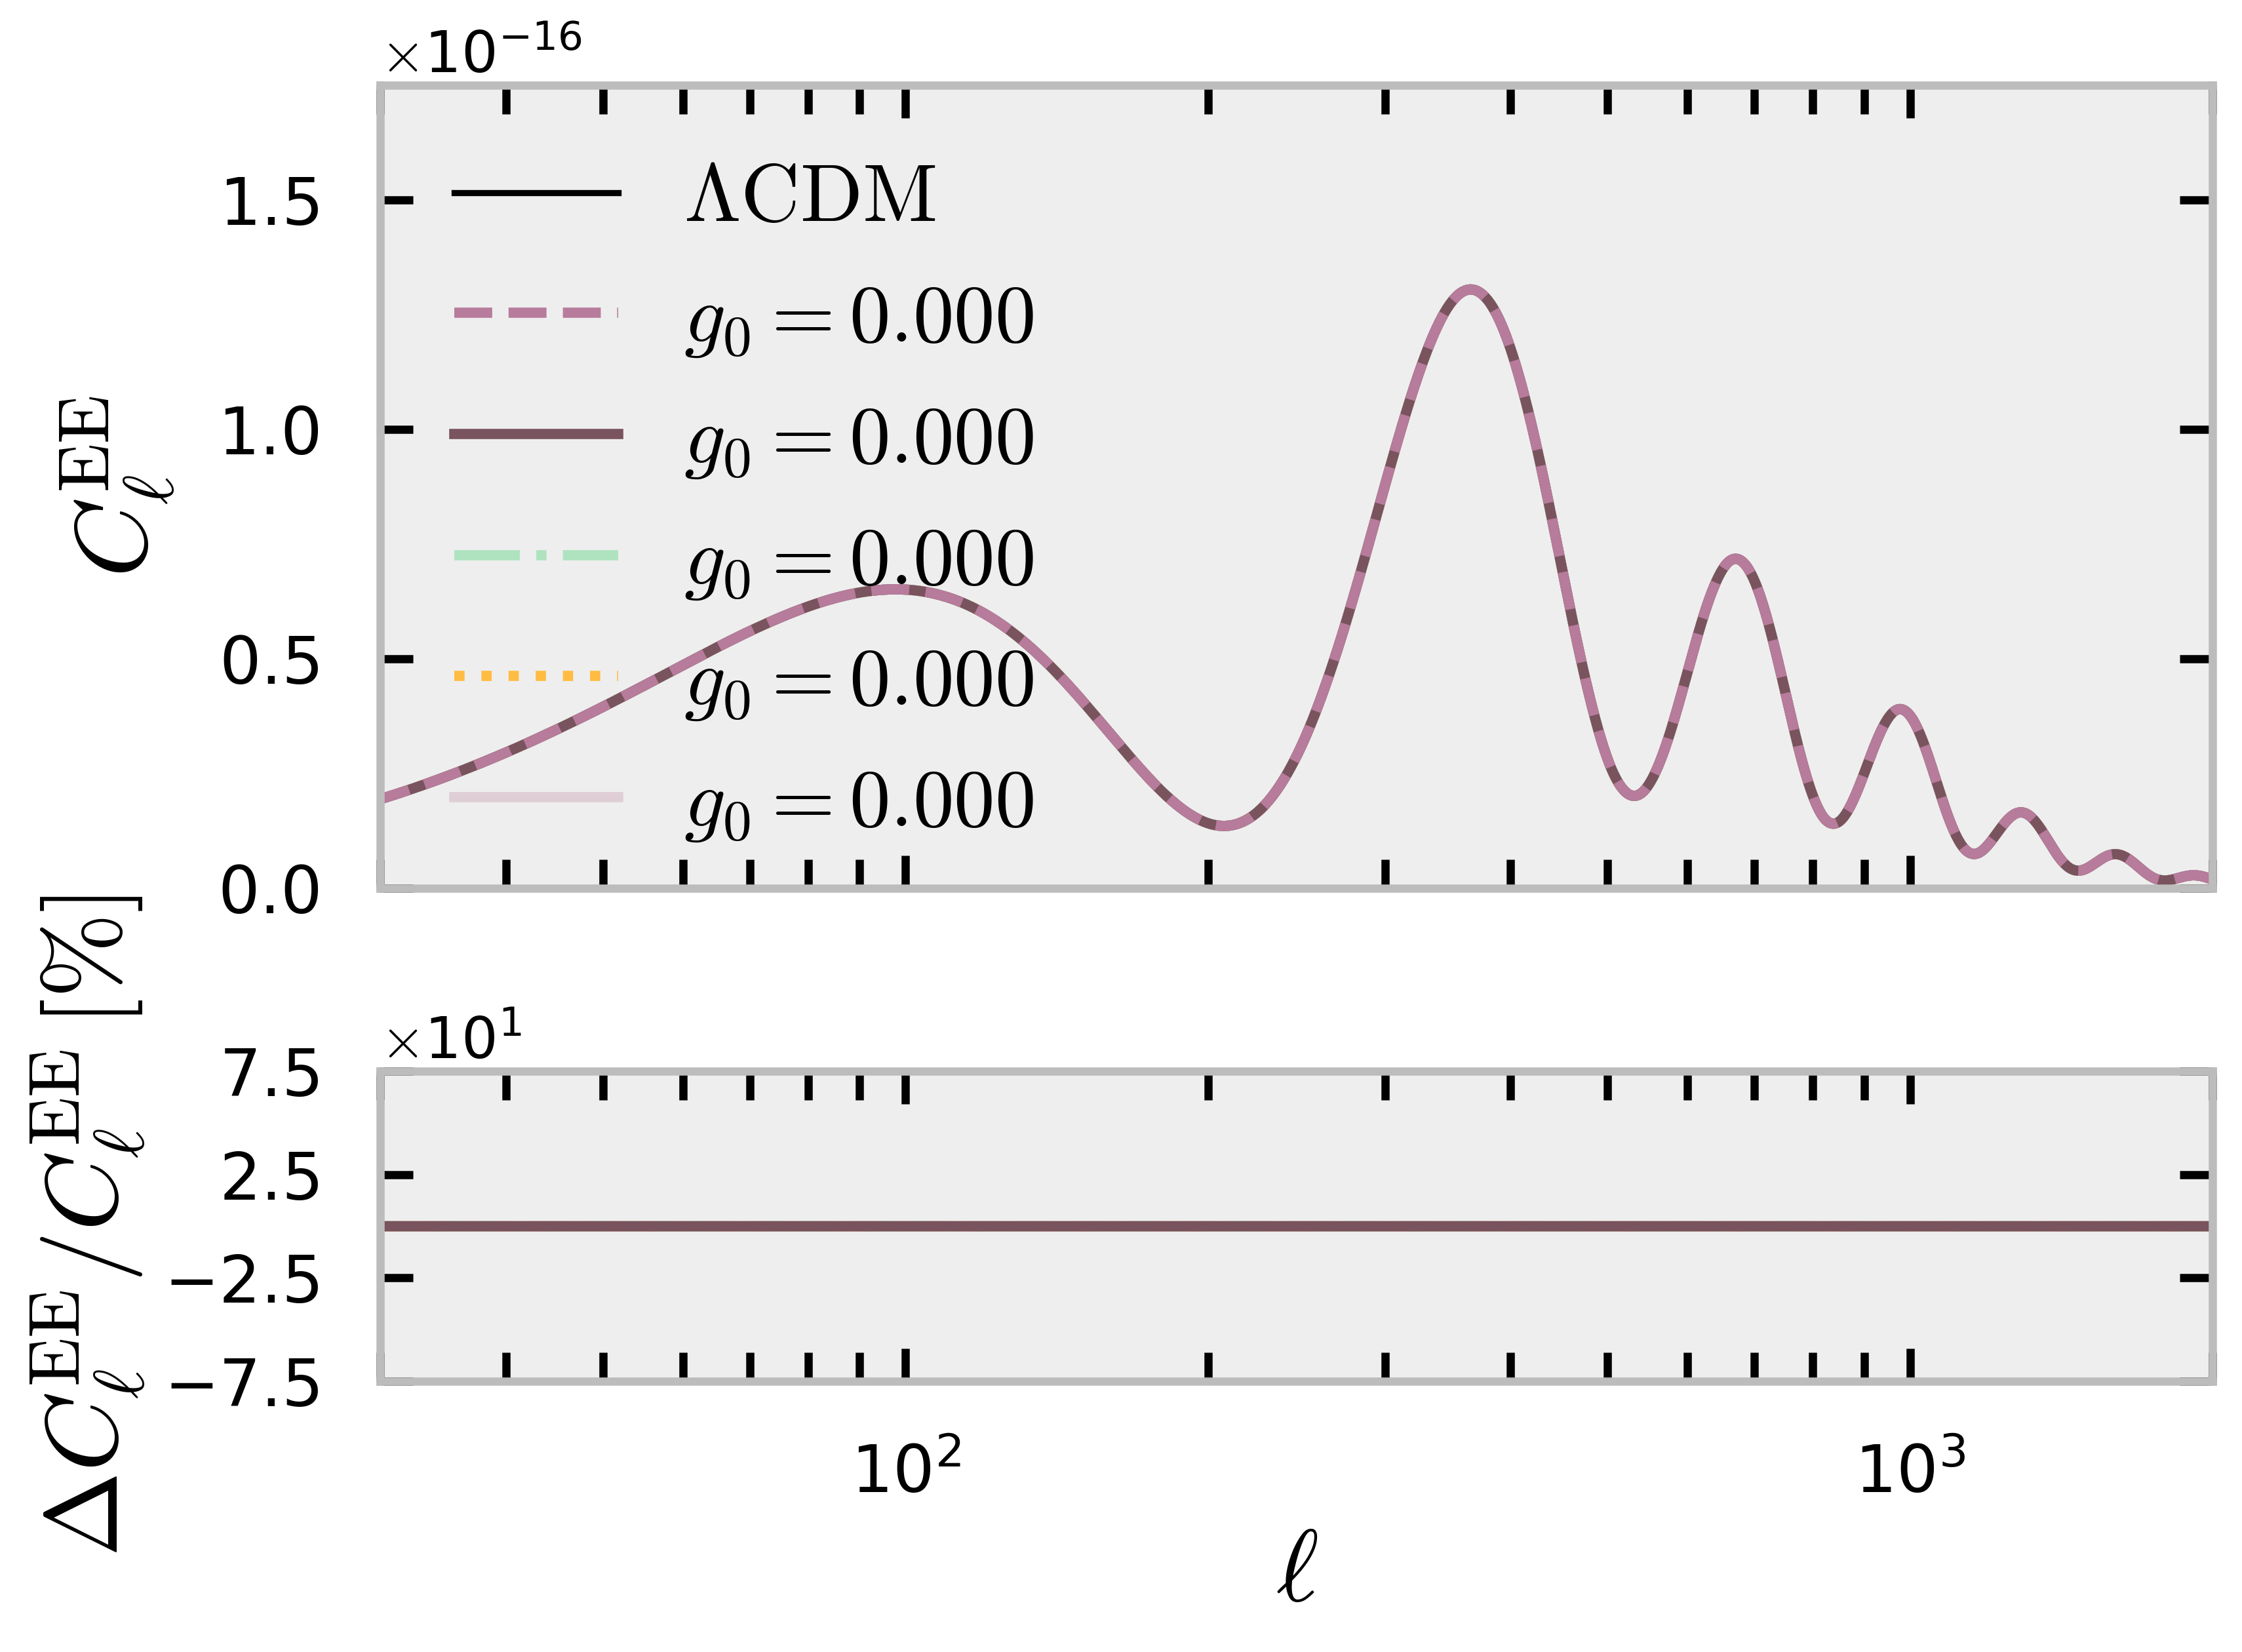

In [43]:
plt.style.use(['ipynb', 'use_mathtext','colors5-light'])

lw = 2.5
ls = ['--','-','-.', ':', '-']


fig = plt.figure(figsize=(8,6))
ax0 = plt.subplot2grid((3,1),(0,0), rowspan=2)
ax1 = plt.subplot2grid((3,1),(2,0), rowspan=1,sharex = ax0)

plt.subplots_adjust(hspace=0,wspace=0.)

# get lambdac
cls_standard = standard.raw_cl(2000)
ll = cls_standard['ell'][2:]
clEE_standard = cls_standard['ee'][2:]

i=0
# plot Lc
ax0.plot(ll,clEE_standard, label = r'$\Lambda{\rm CDM}$', c = 'k', ls='-', lw=1.5)
for index in [0,1,2,3,4]: #--------------------------------> BETA
# get all C_l output
    cls = cosmo[index].raw_cl(2000)
    ll = cls['ell'][2:]
    clEE = cls['ee'][2:]
# plot C_l^EE
    ax0.plot(ll,clEE, label = \
            r'$g_0 = %.3f$'%(f0s[index]),lw=lw, ls=ls[i], c=color[i])
    DELTA = (clEE  - clEE_standard) / clEE_standard
    ax1.plot(ll,DELTA*100, lw=lw, ls=ls[i], c=color[i])
    i+=1


ax0.set_xscale('log')
ax0.set_yscale('linear')
ax0.set_xlim(30,2000)
ax0.set_ylim(0,1.75e-16)

ax1.set_xscale('log')
ax1.set_yscale('linear')
ax1.set_xlim(30,2000)
ax1.set_ylim(-75.,75.)
ax1.set_yticks([i for i in np.linspace(-75,75,4)])

ax1.set_xlabel(r'$\ell$', size=25)
ax0.set_ylabel(r'$C_\ell^\mathrm{EE}$', size=25,labelpad=10)
ax1.set_ylabel(r'$\Delta C_\ell^\mathrm{EE}/C_\ell^\mathrm{EE}\, [\%]$', size=25)


ax0.ticklabel_format(axis='y', style='sci', scilimits=(0,0), useMathText=True)

ax0.tick_params(axis='both', which='both', labelsize=16)
ax0.tick_params(axis='both', which='both', labelsize=16)

#---------------------------------------------------------------------------------> change ticklabels distance

for tick in ax1.xaxis.get_major_ticks():
    tick.set_pad(15)
for tick in ax0.yaxis.get_major_ticks():
    tick.set_pad(15)
for tick in ax1.yaxis.get_major_ticks():
    tick.set_pad(15)
    

ax0.tick_params(axis='both', which='both', labelsize=16)

    
ax0.xaxis.set_tick_params(which='major', size=8, width=2, direction='in', top='on')
ax0.xaxis.set_tick_params(which='minor', size=7, width=2, direction='in', top='on')
ax0.yaxis.set_tick_params(which='major', size=8, width=2, direction='in', right='on')
ax0.yaxis.set_tick_params(which='minor', size=7, width=2, direction='in', right='on')

ax1.tick_params(axis='both', which='both', labelsize=16)

    
ax1.xaxis.set_tick_params(which='major', size=8, width=2, direction='in', top='on')
ax1.xaxis.set_tick_params(which='minor', size=7, width=2, direction='in', top='on')
ax1.yaxis.set_tick_params(which='major', size=8, width=2, direction='in', right='on')
ax1.yaxis.set_tick_params(which='minor', size=7, width=2, direction='in', right='on')

plt.tight_layout()
#plt.savefig('cq_cmb_tt.pdf', transparent=True)

for ax in (ax0, ax1):
    # copy the list so we don't iterate over lines we add
    lines = list(ax.get_lines())[1:]
    for ln in lines[::-1]:
        ax.plot(
            ln.get_xdata(), ln.get_ydata(),
            ls=ln.get_linestyle(),
            lw=ln.get_linewidth(),
            c=ln.get_color(),
            marker=ln.get_marker(),
            markersize=ln.get_markersize(),
            alpha=ln.get_alpha() if ln.get_alpha() is not None else 1.0,
            label="_nolegend_",  # labels starting with '_' are ignored by legend()
        )

ax0.legend(loc='upper left', frameon=boolean, prop={'size': 20})
plt.setp(ax0.get_xticklabels(), visible=False)
plt.rcParams['font.size'] = 20
plt.rcParams['axes.linewidth'] = 2
fig.tight_layout()
plt.savefig('clsee.pdf', transparent=True)
plt.show()

[8.48038821e-09 2.59416318e-09 1.07871662e-09 ... 5.40795808e-22
 5.39154627e-22 5.37519201e-22]


'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


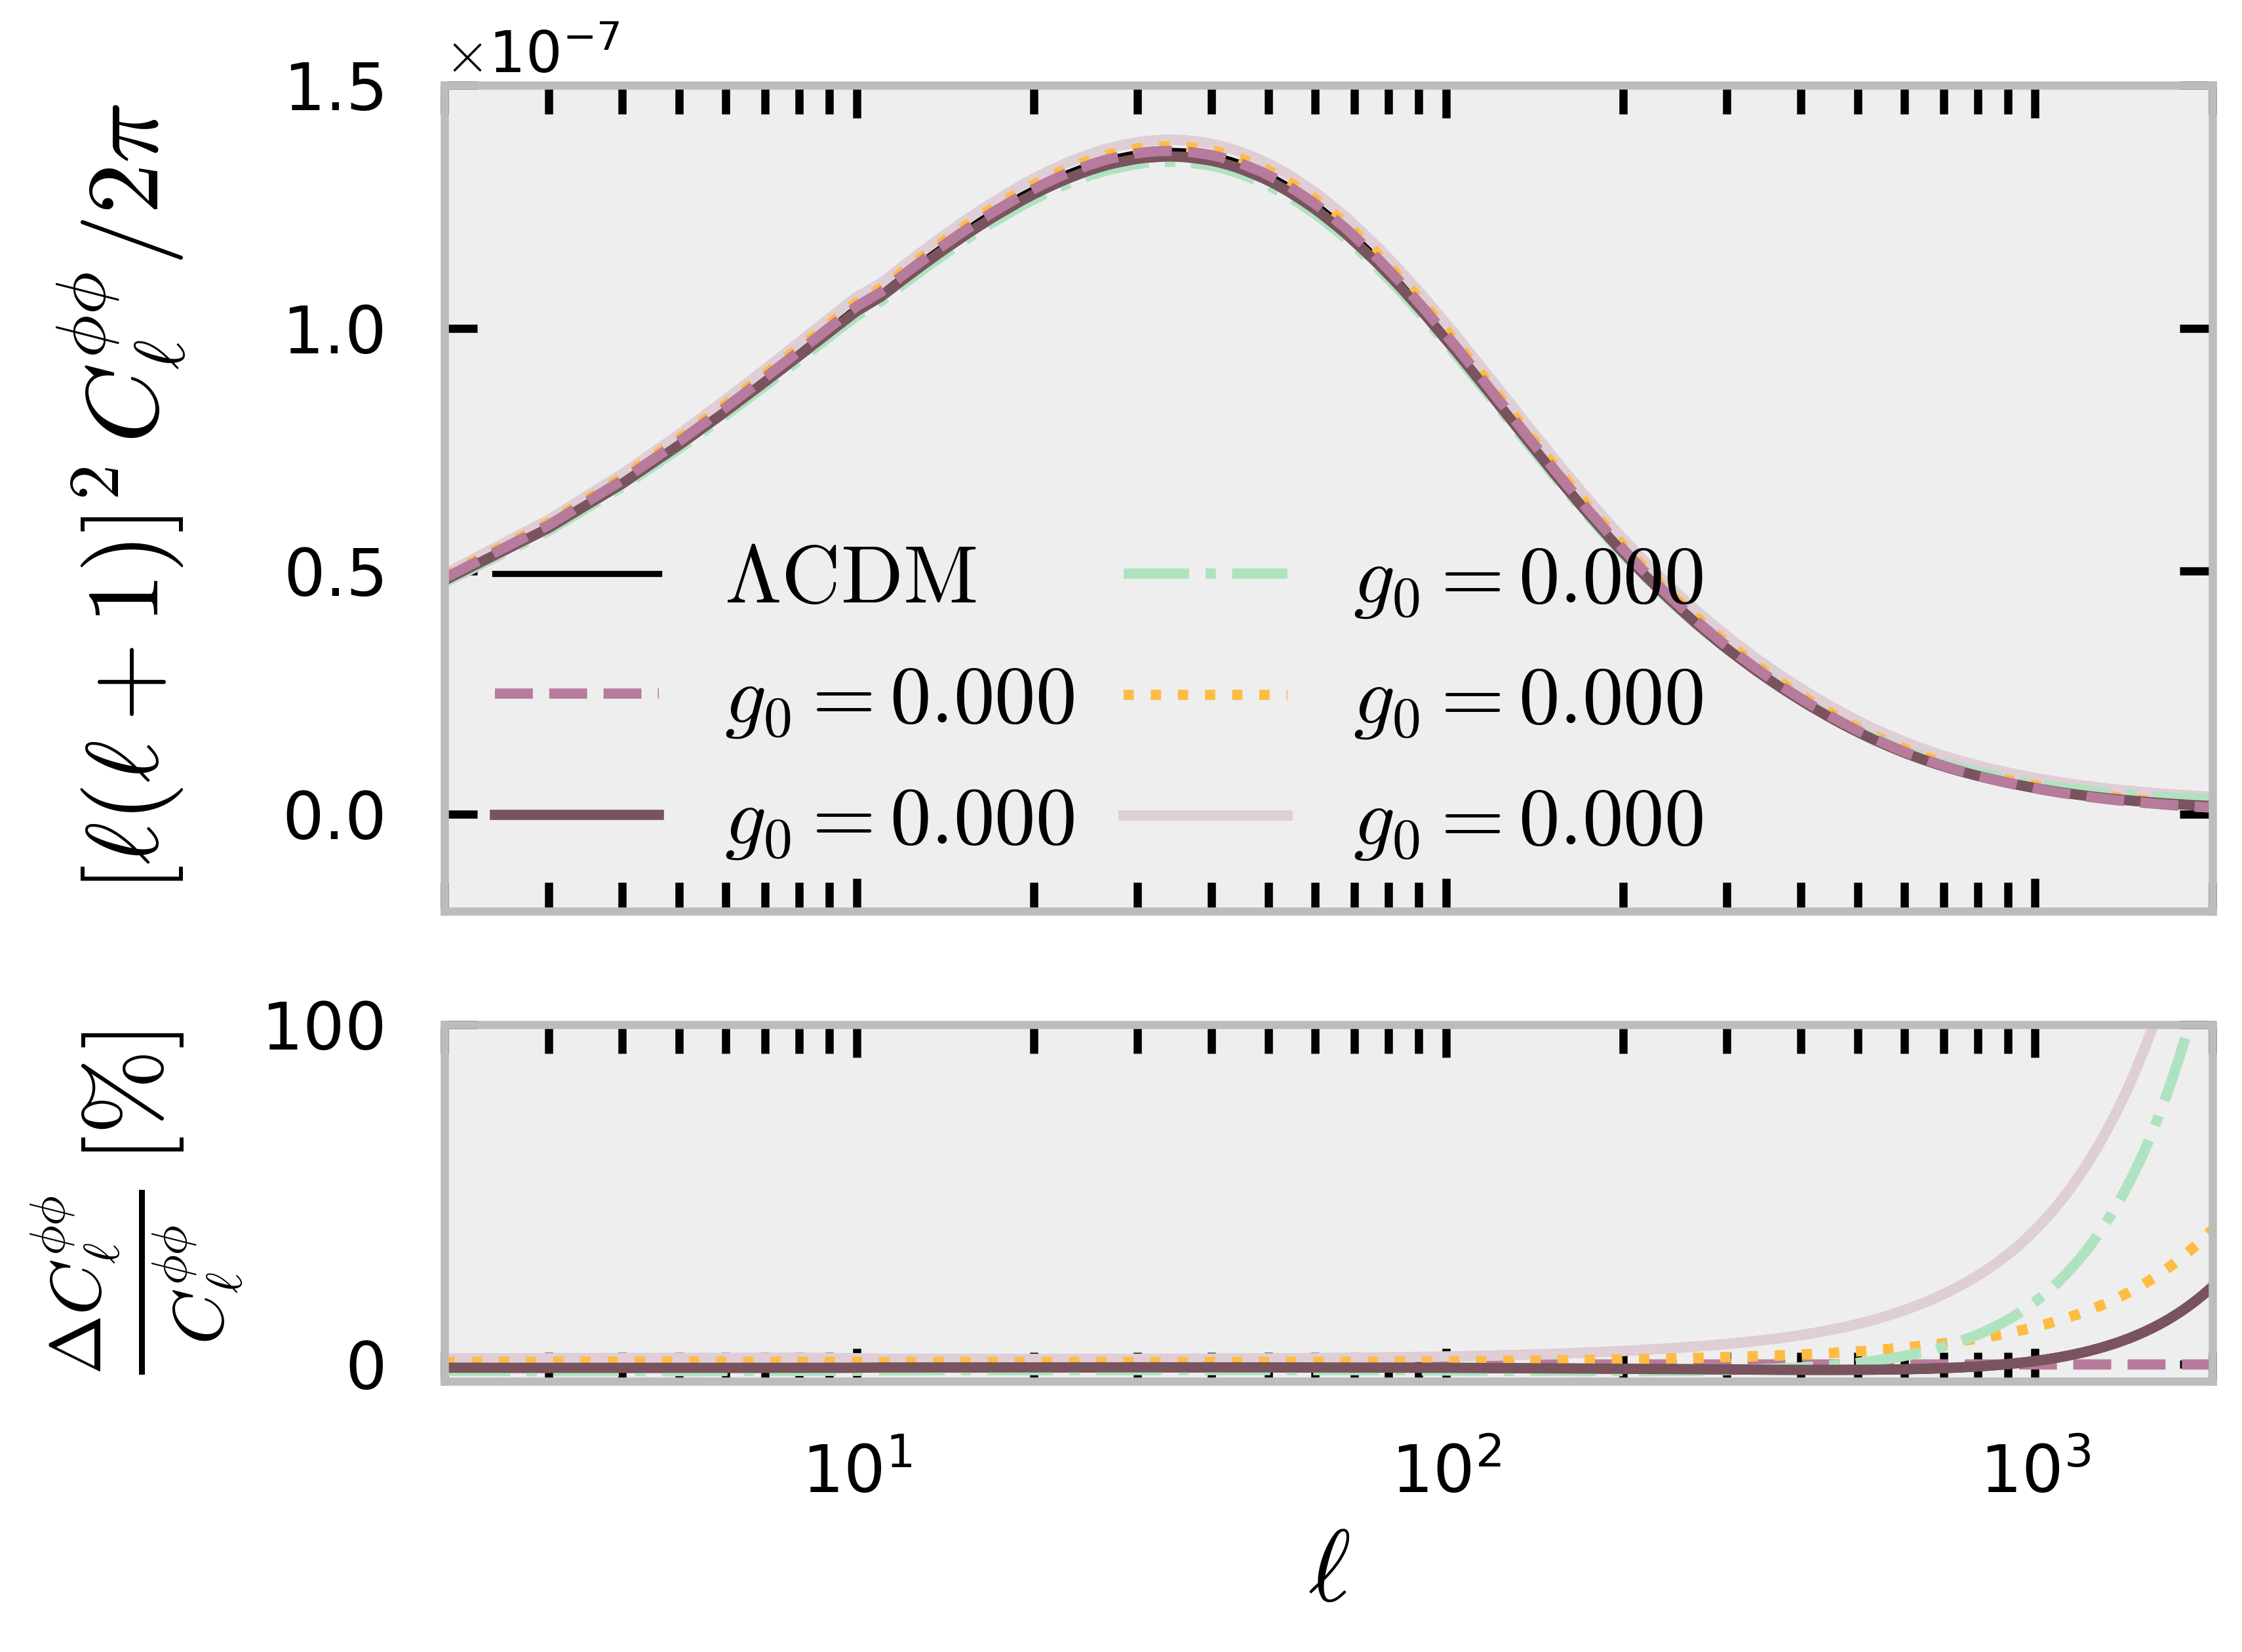

In [83]:
plt.style.use(['ipynb', 'use_mathtext','colors5-light'])

lw = 2.5
ls = ['--','-','-.', ':', '-']


fig = plt.figure(figsize=(8,6))
ax0 = plt.subplot2grid((3,1),(0,0), rowspan=2)
ax1 = plt.subplot2grid((3,1),(2,0), rowspan=1,sharex = ax0)

plt.subplots_adjust(hspace=0,wspace=0.)

# get lambdac
cls_standard = standard.raw_cl(2000)
ll = cls_standard['ell'][2:]
clPP_standard = cls_standard['pp'][2:]
print(clPP_standard)
# plot Lc
ax0.plot(ll,clPP_standard*(ll*(ll+1))**2./2./np.pi, label = r'$\Lambda{\rm CDM}$', c = 'k', ls='-', lw=1.5)

i=0
for index in [0,1,2,3,4]: #--------------------------------> BETA
# get all C_l output
    cls = cosmo[index].raw_cl(2000)
    ll = cls['ell'][2:]
    clPP = cls['pp'][2:]
# plot C_l^EE
    ax0.plot(ll,clPP*(ll*(ll+1))**2./2./np.pi, label = \
            r'$g_0 = %.3f$'%(f0s[index]),lw=lw, ls=ls[i], c=color[i])
    DELTA = clPP / clPP_standard - 1
    ax1.plot(ll,DELTA*100, lw=lw, ls=ls[i], c=color[i])
    i+=1


ax0.set_yscale('linear')
ax0.set_xscale('log')
ax0.set_xlim(2,2000)
ax0.set_ylim(-2.e-8,1.5e-7)
ax1.set_yticks([i for i in np.linspace(0,2.e-7,5)])

ax1.set_yscale('linear')
ax1.set_xscale('log')
ax1.set_xlim(2,2000)
ax1.set_ylim(-5.,100.)
#ax1.set_yticks([i for i in np.linspace(-10,10,3)])

ax1.set_xlabel(r'$\ell$', size=25)
ax0.set_ylabel(r'$[\ell(\ell+1)]^2\, C_\ell^{\phi\phi}/2 \pi$', size=25,labelpad=23)
ax1.set_ylabel(r'$\frac{\Delta C_\ell^{\phi\phi}}{C_\ell^{\phi\phi}}\, [\%]$', size=25)

ax0.ticklabel_format(axis='y', style='sci', scilimits=(0,0), useMathText=True)

ax0.tick_params(axis='both', which='both', labelsize=16)
ax0.tick_params(axis='both', which='both', labelsize=16)

#---------------------------------------------------------------------------------> change ticklabels distance

for tick in ax1.xaxis.get_major_ticks():
    tick.set_pad(15)
for tick in ax0.yaxis.get_major_ticks():
    tick.set_pad(15)
for tick in ax1.yaxis.get_major_ticks():
    tick.set_pad(15)
    

ax0.tick_params(axis='both', which='both', labelsize=16)

    
ax0.xaxis.set_tick_params(which='major', size=8, width=2, direction='in', top='on')
ax0.xaxis.set_tick_params(which='minor', size=7, width=2, direction='in', top='on')
ax0.yaxis.set_tick_params(which='major', size=8, width=2, direction='in', right='on')
ax0.yaxis.set_tick_params(which='minor', size=7, width=2, direction='in', right='on')

ax1.tick_params(axis='both', which='both', labelsize=16)

    
ax1.xaxis.set_tick_params(which='major', size=8, width=2, direction='in', top='on')
ax1.xaxis.set_tick_params(which='minor', size=7, width=2, direction='in', top='on')
ax1.yaxis.set_tick_params(which='major', size=8, width=2, direction='in', right='on')
ax1.yaxis.set_tick_params(which='minor', size=7, width=2, direction='in', right='on')

plt.tight_layout()
#plt.savefig('cq_cmb_tt.pdf', transparent=True)

for ax in (ax0, ax1):
    # copy the list so we don't iterate over lines we add
    lines = list(ax.get_lines())[1:]
    for ln in lines[::-1]:
        ax.plot(
            ln.get_xdata(), ln.get_ydata(),
            ls=ln.get_linestyle(),
            lw=ln.get_linewidth(),
            c=ln.get_color(),
            marker=ln.get_marker(),
            markersize=ln.get_markersize(),
            alpha=ln.get_alpha() if ln.get_alpha() is not None else 1.0,
            label="_nolegend_",  # labels starting with '_' are ignored by legend()
        )
ax1.ticklabel_format(axis='y', style='plain', useMathText=True)

ax0.legend(loc=(0.01, 0.02), frameon=boolean, prop={'size': 20},ncol=2,columnspacing=0.6)
plt.setp(ax0.get_xticklabels(), visible=False)
plt.rcParams['font.size'] = 20
plt.rcParams['axes.linewidth'] = 2
fig.tight_layout()
plt.savefig('clsff.pdf', transparent=True)
plt.show()

/var/folders/91/jymwbq1j1nng0wqyd6yvbm100000gn/T/ipykernel_82780/828147736.py:41: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([-1,0,1,2,3])
/var/folders/91/jymwbq1j1nng0wqyd6yvbm100000gn/T/ipykernel_82780/828147736.py:76: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels)
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


k = 0.067556


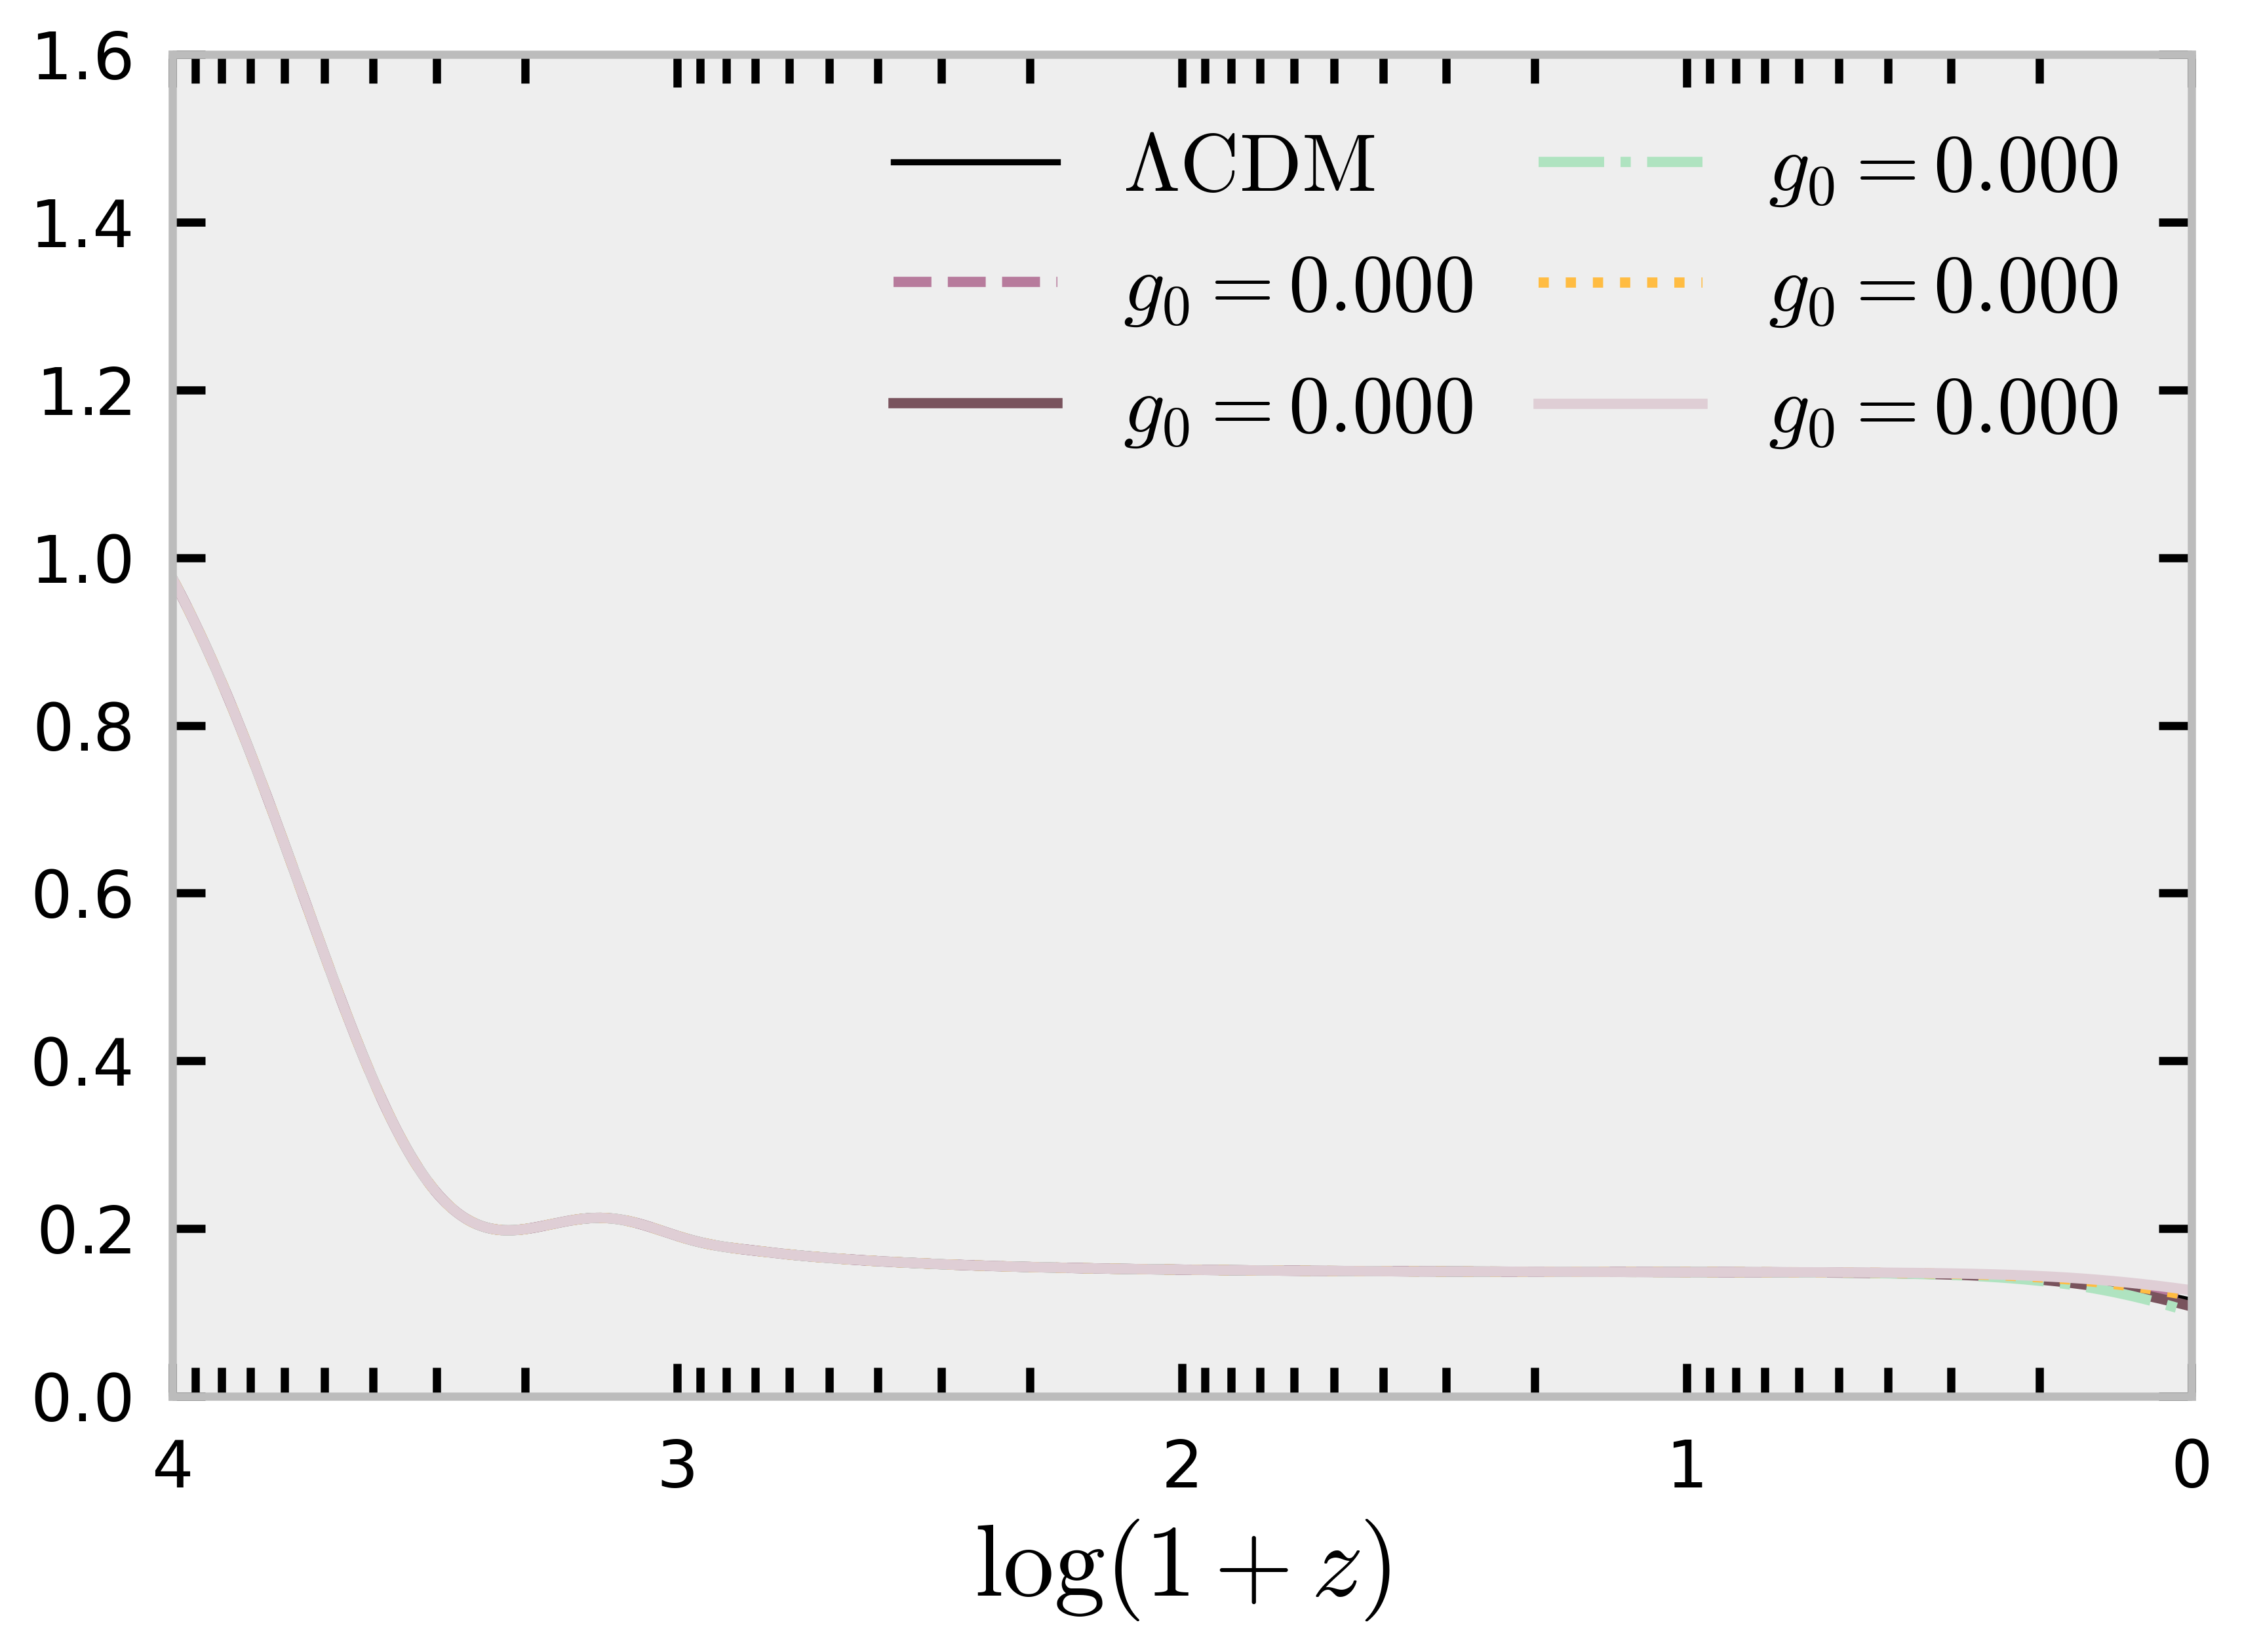

In [45]:
index_k_list = [1]
label = [r'$\Phi+\Psi$','','','']

lw = 2.5
ls = ['--','-','-.', ':', '-']


plt.style.use(['ipynb', 'use_mathtext','colors5-light'])

fig, ax = plt.subplots(1, 1, figsize=(8,6))

for i in [2]: #--------------------------------------------> values of k-scales
    index_k = i
    print('k =', k_sorted[index_k])
    style=0
    standardPerturb=standard.get_perturbations()
    a = standardPerturb['scalar'][index_k]['a']
    z=1/a-1
    Phipl = standardPerturb['scalar'][index_k]['phi']
        #/standardPerturb['scalar'][index_k]['phi'][0]
    Psipl = standardPerturb['scalar'][index_k]['psi']
        #/standardPerturb['scalar'][index_k]['psi'][0]

    ax.plot(1+z, Phipl+Psipl, c='k', ls='-', label = r'$\Lambda{\rm CDM}$', lw=1.5)
    for index in [0,1,2,3,4]: #--------------------------------------------> values of beta
        
        cosmoPerturb=cosmo[index].get_perturbations()
        a = cosmoPerturb['scalar'][index_k]['a']
        z=1/a-1
        Phip = cosmoPerturb['scalar'][index_k]['phi']
               #/cosmoPerturb['scalar'][index_k]['phi'][0]
        Psip = cosmoPerturb['scalar'][index_k]['psi']
               #/cosmoPerturb['scalar'][index_k]['psi'][0]
    
        ax.plot(1+z, Phip+Psip,
             label = r'$g_0 = %.3f$'%(f0s[index]),lw=lw, ls=ls[style],c=color[style])
        style+=1



    ax.set_xticklabels([-1,0,1,2,3])

    ax.set_ylabel(label[i], size=25)
    ax.set_xlabel(r'$\log(1+z)$', size=25)
    ax.set_xlim(1e4,1)
    ax.set_ylim(0.,1.6)
    #ax.set_title('k = '+str(k_sorted[index_k]), size=20)
    ax.tick_params(axis='both', which='major', labelsize=16, width=1.1)
    for tick in ax.xaxis.get_major_ticks():
        tick.set_pad(10)
    for tick in ax.yaxis.get_major_ticks():
        tick.set_pad(10)    

#ax.ticklabel_format(axis='y', style='sci', scilimits=(0,0), useMathText=True) #---------------------------> Scientific format
#ax.yaxis.offsetText.set_fontsize(20) #---------------------------> size of the scientific format


    
ax.tick_params(axis='both', which='both', labelsize=16)

for tick in ax.xaxis.get_major_ticks():
    tick.set_pad(10)
for tick in ax.yaxis.get_major_ticks():
    tick.set_pad(10)
    
ax.xaxis.set_tick_params(which='major', size=8, width=2, direction='in', top='on')
ax.xaxis.set_tick_params(which='minor', size=7, width=2, direction='in', top='on')
ax.yaxis.set_tick_params(which='major', size=8, width=2, direction='in', right='on')
ax.yaxis.set_tick_params(which='minor', size=7, width=2, direction='in', right='on')

ax.set_xscale('log')
original_labels = ax.get_xticks()
labels = []
for label in original_labels:
    labels.append(int(np.log10(label)))
ax.set_xticklabels(labels)


plt.legend(loc='best', frameon=boolean, prop={'size': 20},ncol=2,columnspacing=0.8)
#ax.legend(loc='best', frameon=boolean, prop={'size': 25})
#mpl.rcParams['font.family'] = 'Avenir'
plt.rcParams['font.size'] = 20
plt.rcParams['axes.linewidth'] = 2
fig.tight_layout()
plt.savefig('ppp.pdf', transparent=True)
plt.show()

ValueError: Expect x to not have duplicates

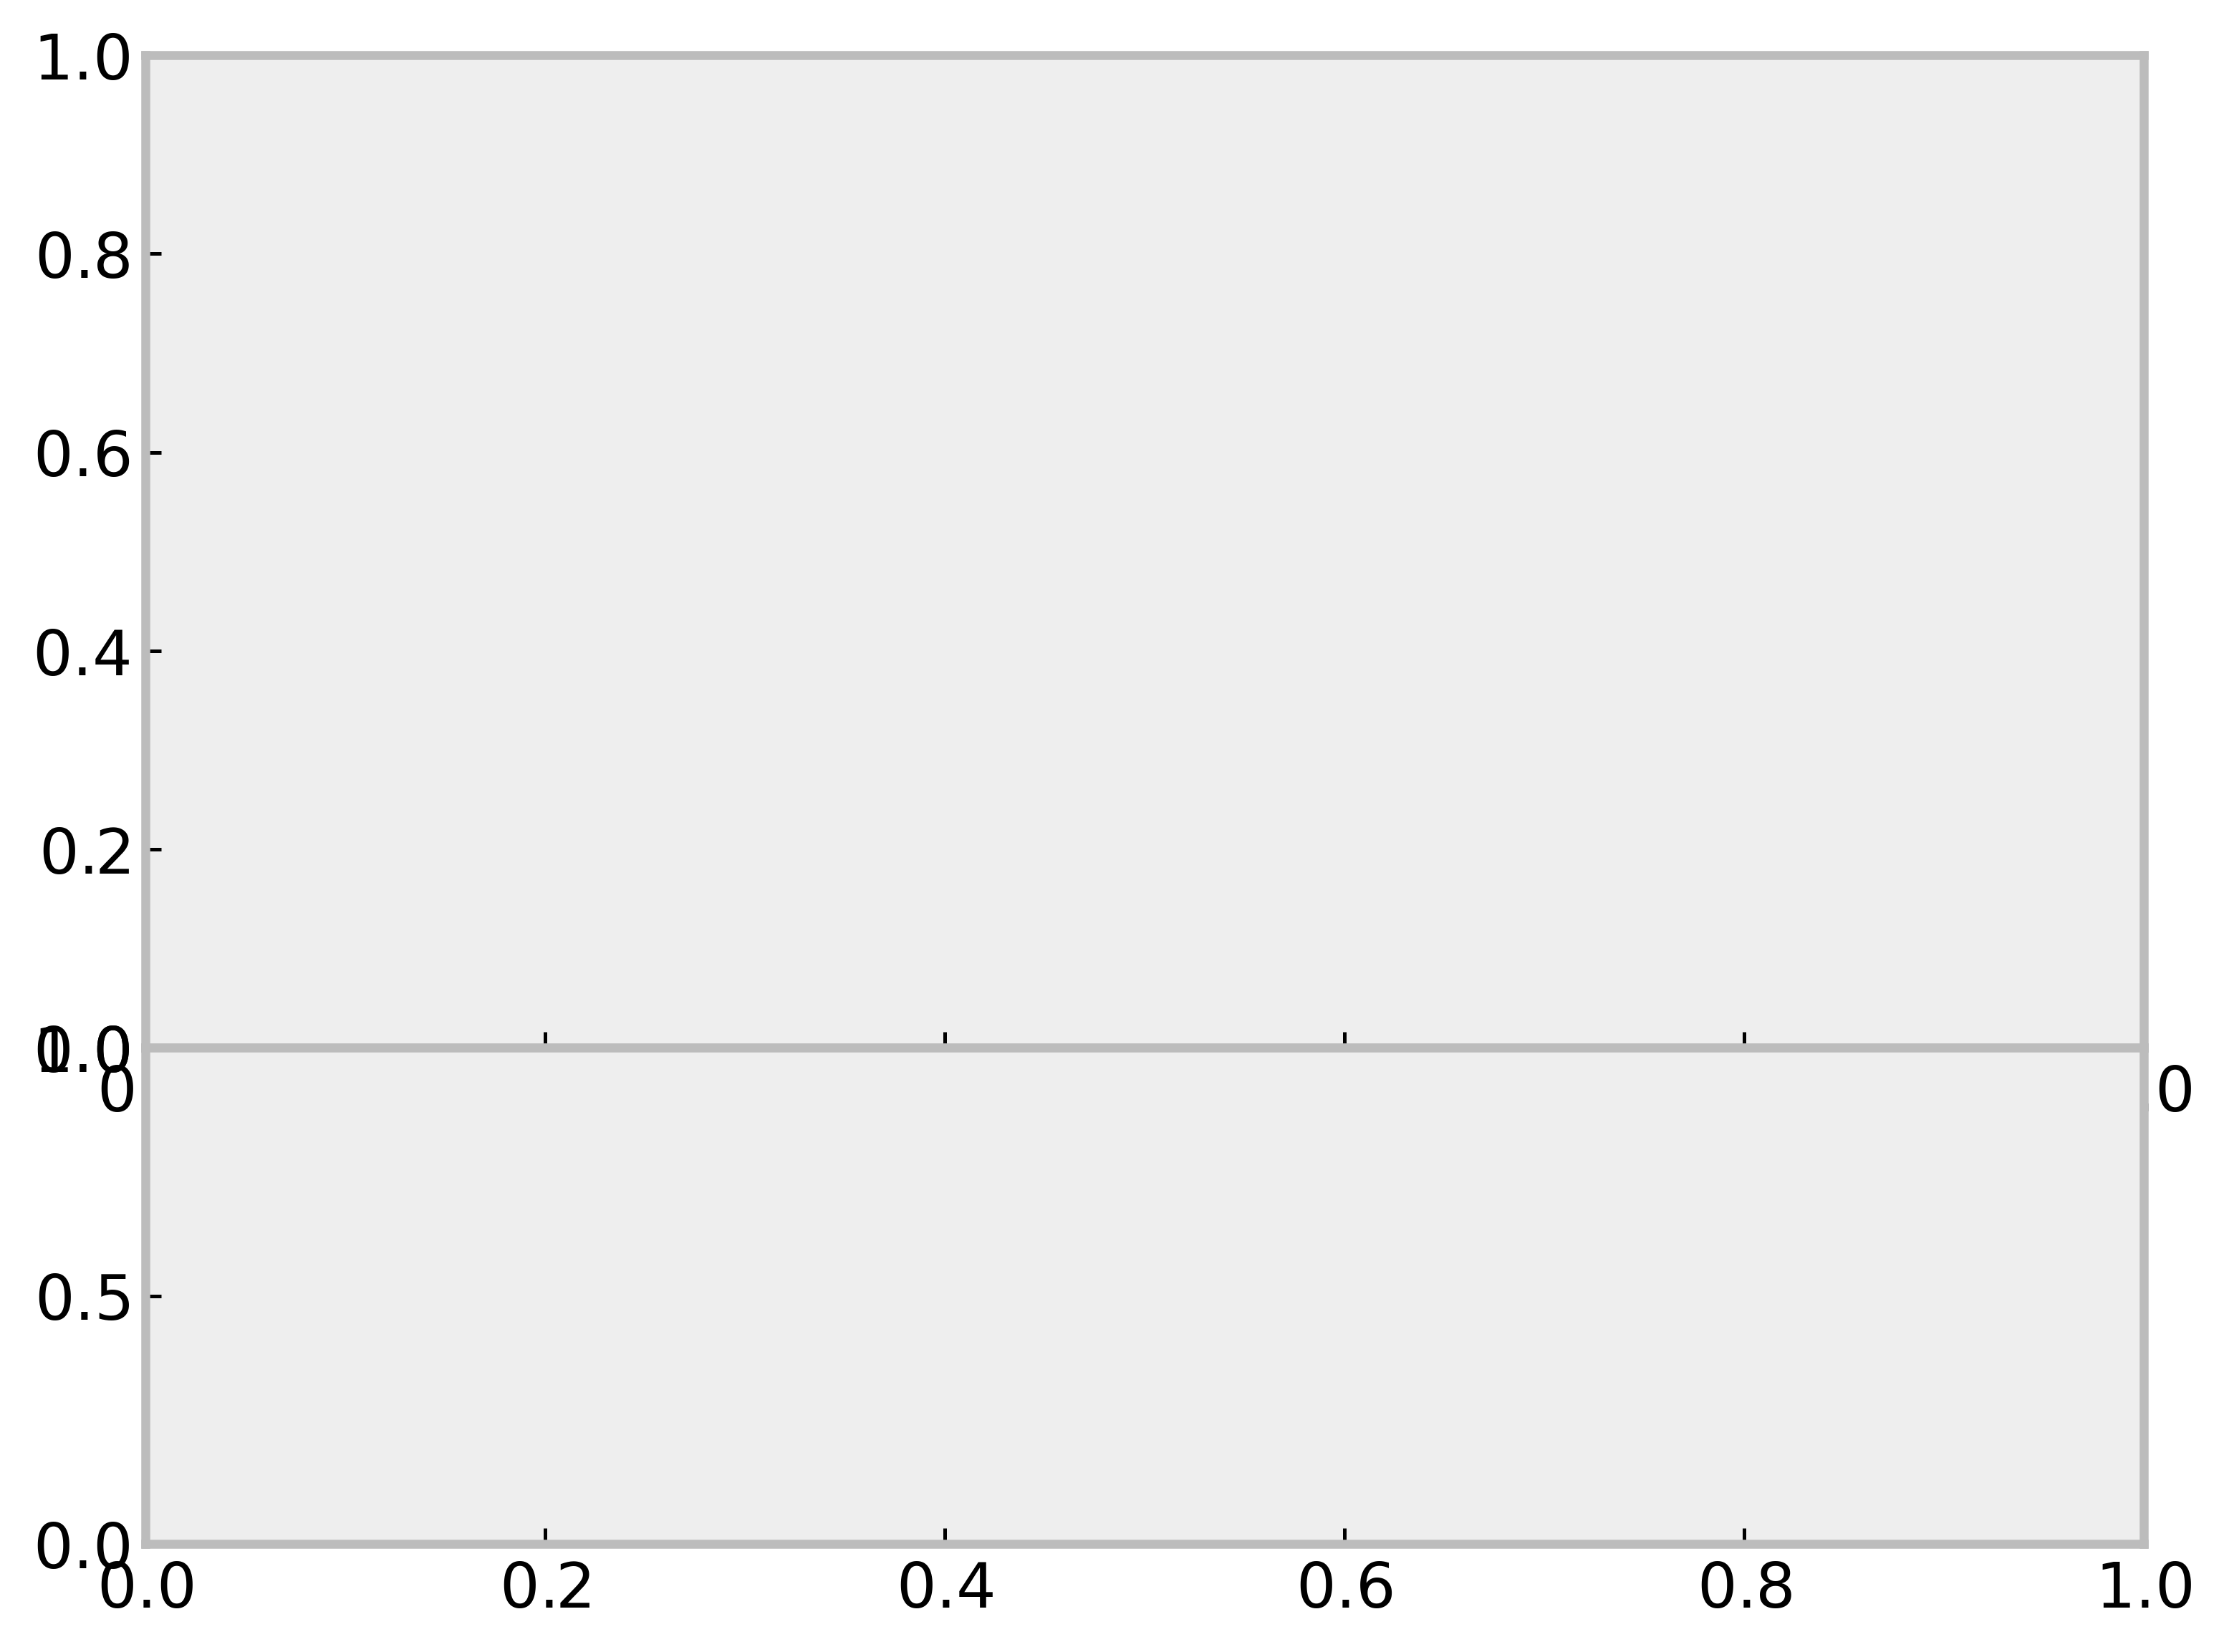

In [46]:
plt.style.use(['ipynb', 'use_mathtext','colors5-light'])

lw = 2.5
ls = ['--','-','-.', ':', '-']

temp = 10.0**(-8.0)

fig = plt.figure(figsize=(8,6))
ax0 = plt.subplot2grid((3,1),(0,0), rowspan=2)
ax1 = plt.subplot2grid((3,1),(2,0), rowspan=1,sharex = ax0)

plt.subplots_adjust(hspace=0,wspace=0.)

zz = np.linspace(10**5,1.,100000) # k in h/Mpc
zzi=zz[::-1]
taut = np.linspace(10**(-2),10**5,100000)
#print(zzi)
index_k = 2
# get lambdac
standardPerturb=standard.get_perturbations()
a = standardPerturb['scalar'][index_k]['a']
z=1/a
tau = standardPerturb['scalar'][index_k]['tau [Mpc]']
zi=z[::-1]
#print(zi)
Phipl = standardPerturb['scalar'][index_k]['phi']
Phipli = Phipl[::-1]
Psipl = standardPerturb['scalar'][index_k]['psi']
Psipli = Psipl[::-1]
phipsil_int = interp1d(zi,(Phipli+Psipli),kind="quadratic",fill_value='extrapolate')
tphipsil_int = interp1d(tau,(Phipl+Psipl))
phipsil_intt =  UnivariateSpline(zzi,phipsil_int(zzi))
tphipsil_intt =  UnivariateSpline(tau,tphipsil_int(tau))
#print(phipsil_intt(zzi))
phipsil_intt.set_smoothing_factor(temp)
phipsil_inttd = phipsil_intt.derivative(1)
tphipsil_intt.set_smoothing_factor(temp)
tphipsil_inttd = tphipsil_intt.derivative(1)
#print(phipsil_inttd(zzi))
#phipsild_int = np.gradient(phipsil_int(zz),zz)
#print(phipsil_int(zzi))
#phipsil_int_d1 = interpolate.spline(z,Phipl+Phipl,order=1)
# plot Lc
#print(phipsild_int)
ax0.plot(zzi, -phipsil_inttd(zzi), label = r'$\Lambda{\rm CDM}$', c = 'k', ls='-', lw=1.5)
i=0
index_k = index_k_list[i]
print('k =', k_sorted[index_k])
style=0
for index in [0,1,2,3,4]: #--------------------------------------------> values of beta
    cosmoPerturb=cosmo[index].get_perturbations()
    a = cosmoPerturb['scalar'][index_k]['a']
    z=1/a
    zi=z[::-1]
    Phip = cosmoPerturb['scalar'][index_k]['phi']
    Phipi = Phip[::-1]
    Psip = cosmoPerturb['scalar'][index_k]['psi']
    Psipi = Psip[::-1]
    phipsi_int = interp1d(zi,(Phipi+Psipi)*10**3)
    phipsi_intt =  UnivariateSpline(zzi,phipsi_int(zzi))
    phipsi_intt.set_smoothing_factor(temp)
    phipsi_inttd = phipsi_intt.derivative(1)
    DELTA = phipsi_inttd(zzi)/ phipsil_inttd(zzi) -1.
    #DELTA.set_smoothing_factor(temp)

    ax0.plot(zzi, -phipsil_inttd(zzi),
         label = r'$g_0 = %.3f$'%(f0s[index]),lw=lw, ls=ls[style],c=color[style])
    ax1.plot(zzi,DELTA*100, lw=lw, ls=ls[style],c=color[style])
    style+=1

ax0.set_yscale('linear')
ax0.set_xscale('log')
#ax0.set_xlim(1e4,1)
#ax0.set_ylim(-10,10.)
original_labels = ax0.get_xticks()
labels = []
for label in original_labels:
    labels.append(int(np.log10(label)))
ax0.set_xticklabels(labels)

ax1.set_yscale('linear')
ax1.set_xscale('log')
ax0.set_xlim(1e4,1)
ax1.set_ylim(-20.,60.)
ax1.set_yticks([i for i in np.linspace(-20,60,5)])
original_labels = ax1.get_xticks()
labels = []
for label in original_labels:
    labels.append(int(np.log10(label)))
ax1.set_xticklabels(labels)

ax1.set_xlabel(r'$\log(1+z)$', size=25)
ax0.set_ylabel(r'$\Phi\prime + \Psi\prime $', size=25,labelpad=12)
ax1.set_ylabel(r'$\Delta (\Phi\prime  + \Psi\prime )/(\Phi\prime  + \Psi\prime )\, [\%]$', size=25)

ax0.ticklabel_format(axis='y', style='sci', scilimits=(0,0), useMathText=True)

ax0.tick_params(axis='both', which='both', labelsize=16)
ax0.tick_params(axis='both', which='both', labelsize=16)

#---------------------------------------------------------------------------------> change ticklabels distance

for tick in ax1.xaxis.get_major_ticks():
    tick.set_pad(15)
for tick in ax0.yaxis.get_major_ticks():
    tick.set_pad(15)
for tick in ax1.yaxis.get_major_ticks():
    tick.set_pad(15)
    

ax0.tick_params(axis='both', which='both', labelsize=16)

    
ax0.xaxis.set_tick_params(which='major', size=8, width=2, direction='in', top='on')
ax0.xaxis.set_tick_params(which='minor', size=7, width=2, direction='in', top='on')
ax0.yaxis.set_tick_params(which='major', size=8, width=2, direction='in', right='on')
ax0.yaxis.set_tick_params(which='minor', size=7, width=2, direction='in', right='on')

ax1.tick_params(axis='both', which='both', labelsize=16)

    
ax1.xaxis.set_tick_params(which='major', size=8, width=2, direction='in', top='on')
ax1.xaxis.set_tick_params(which='minor', size=7, width=2, direction='in', top='on')
ax1.yaxis.set_tick_params(which='major', size=8, width=2, direction='in', right='on')
ax1.yaxis.set_tick_params(which='minor', size=7, width=2, direction='in', right='on')

plt.tight_layout()
#plt.savefig('cq_cmb_tt.pdf', transparent=True)

ax0.legend(loc='upper left', frameon=boolean, prop={'size': 20},ncol=1)
plt.setp(ax0.get_xticklabels(), visible=False)
plt.rcParams['font.size'] = 20
plt.rcParams['axes.linewidth'] = 2
fig.tight_layout()
plt.savefig('ppppp.pdf', transparent=True)
plt.show()

[1.03808930e+00 1.55617799e+00 2.33212268e+00 ... 1.41672117e+04
 1.42433271e+04 1.42627366e+04]
k = 0.067556


/var/folders/91/jymwbq1j1nng0wqyd6yvbm100000gn/T/ipykernel_16362/1464605376.py:61: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax0.set_xticklabels(labels)
/var/folders/91/jymwbq1j1nng0wqyd6yvbm100000gn/T/ipykernel_16362/1464605376.py:72: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(labels)
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


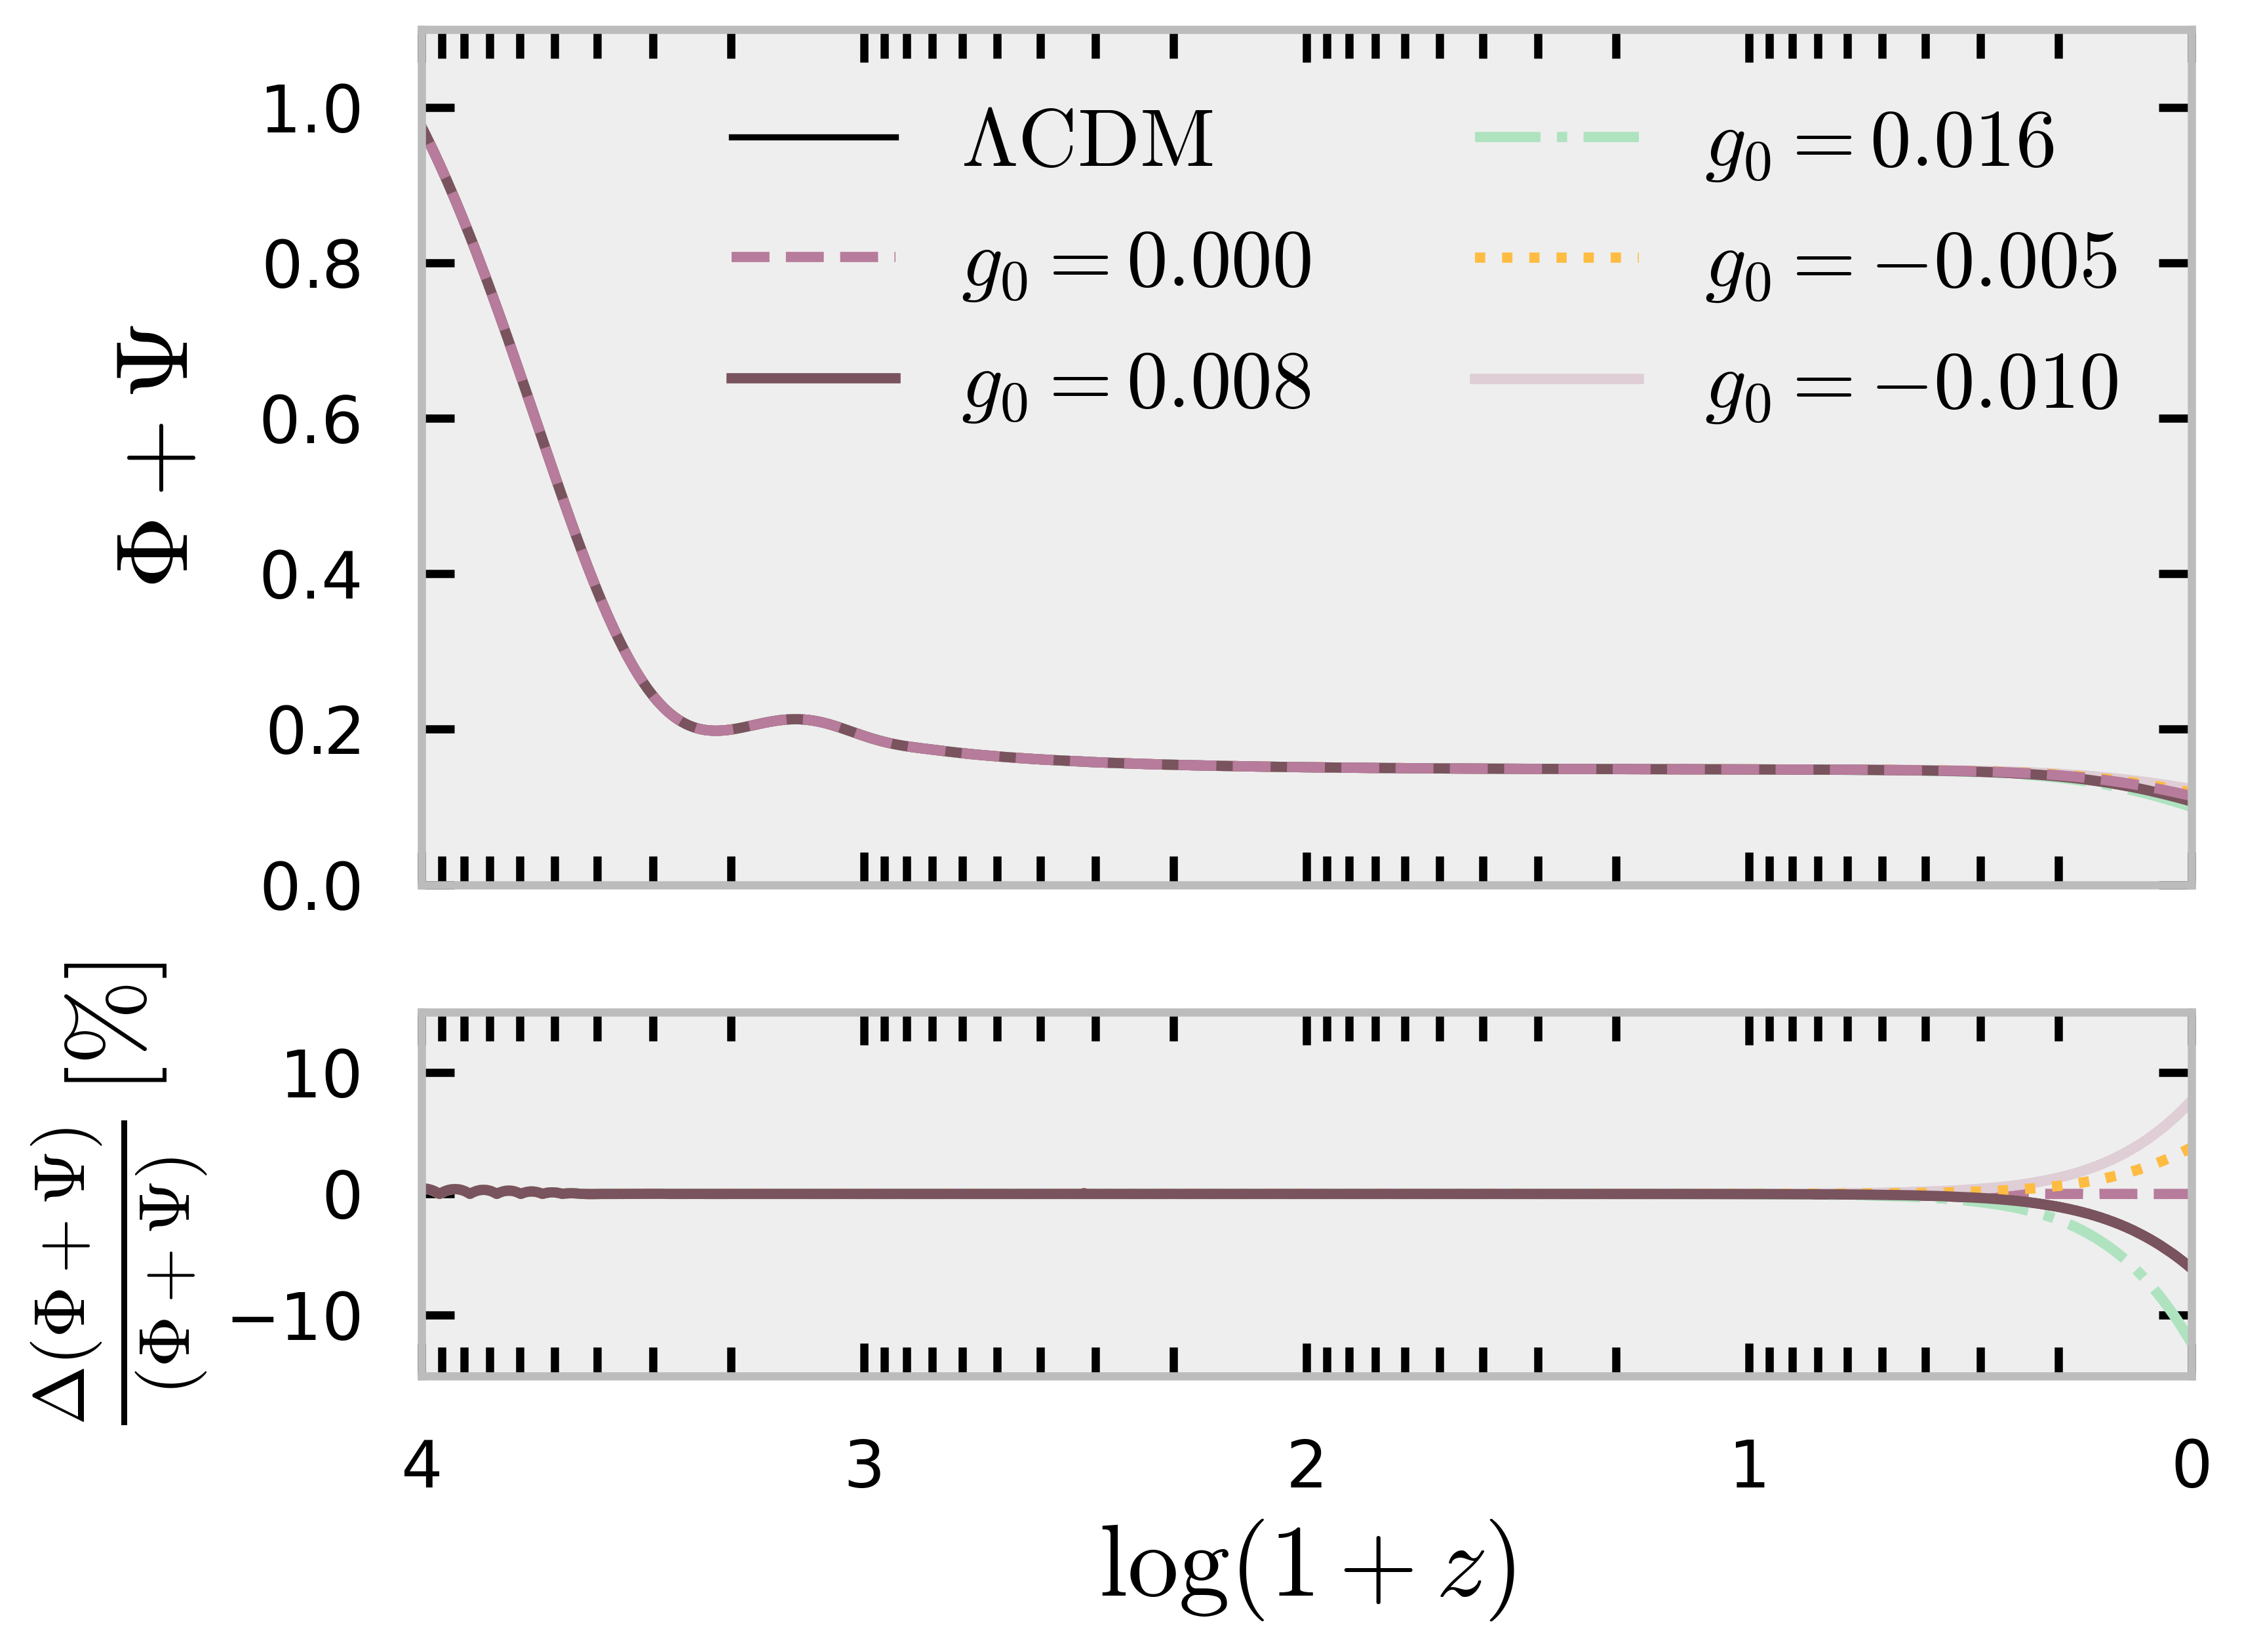

In [ ]:
plt.style.use(['ipynb', 'use_mathtext','colors5-light'])

lw = 2.5
ls = ['--','-','-.', ':', '-']


fig = plt.figure(figsize=(8,6))
ax0 = plt.subplot2grid((3,1),(0,0), rowspan=2)
ax1 = plt.subplot2grid((3,1),(2,0), rowspan=1,sharex = ax0)

plt.subplots_adjust(hspace=0,wspace=0.)

zz = np.logspace(5,0,10000) # k in h/Mpc
#tt = np.linspace(10**(-9),5.)
zzi = zz[::-1]
#print(zz)
#print(zzi)
index_k = 2
# get lambdac
standardPerturb=standard.get_perturbations()
a = standardPerturb['scalar'][index_k]['a']
tau = standardPerturb['scalar'][index_k]['tau [Mpc]']
print(tau)
z=1/a
zi = z[::-1]
Phipl = standardPerturb['scalar'][index_k]['phi']
Phipli = Phipl[::-1]
Psipl = standardPerturb['scalar'][index_k]['psi']
Psipli = Psipl[::-1]
phipsil_int = interp1d(zi,Phipli+Psipli)
# plot Lc
ax0.plot(zzi, phipsil_int(zzi), label = r'$\Lambda{\rm CDM}$', c = 'k', ls='-', lw=1.5)

print('k =', k_sorted[index_k])
style=0
for index in [0,1,2,3,4]: #--------------------------------------------> values of beta
    cosmoPerturb=cosmo[index].get_perturbations()
    a = cosmoPerturb['scalar'][index_k]['a']
    z=1/a
    zi = z[::-1]
    Phip = cosmoPerturb['scalar'][index_k]['phi']
    Phipi = Phip[::-1]
    Psip = cosmoPerturb['scalar'][index_k]['psi']
    Psipi = Psip[::-1]
    phipsi_int = interp1d(zi,Phipi+Psipi)

    ax0.plot(zzi, phipsi_int(zzi),
         label = r'$g_0 = %.3f$'%(f0s[index]),lw=lw, ls=ls[style],c=color[style])
    DELTA = (phipsi_int(zzi)  - phipsil_int(zzi)) / phipsil_int(zzi)
    ax1.plot(zzi,DELTA*100, lw=lw, ls=ls[style],c=color[style])
    style+=1

ax0.set_yscale('linear')
ax0.set_xscale('log')
ax0.set_xlim(1e4,1)
ax0.set_ylim(0,1.1)
original_labels = ax0.get_xticks()
labels = []
for label in original_labels:
    labels.append(int(np.log10(label)))
ax0.set_xticklabels(labels)

ax1.set_yscale('linear')
ax1.set_xscale('log')
ax0.set_xlim(1e4,1)
ax1.set_ylim(-15.,15.)
ax1.set_yticks([i for i in np.linspace(-10,10,3)])
original_labels = ax1.get_xticks()
labels = []
for label in original_labels:
    labels.append(int(np.log10(label)))
ax1.set_xticklabels(labels)

ax1.set_xlabel(r'$\log(1+z)$', size=25)
ax0.set_ylabel(r'$\Phi + \Psi$', size=25,labelpad=12)
ax1.set_ylabel(r'$\frac{\Delta (\Phi + \Psi)}{(\Phi + \Psi)}\, [\%]$', size=25)

ax0.ticklabel_format(axis='y', style='sci', scilimits=(0,0), useMathText=True)

ax0.tick_params(axis='both', which='both', labelsize=16)
ax0.tick_params(axis='both', which='both', labelsize=16)

#---------------------------------------------------------------------------------> change ticklabels distance

for tick in ax1.xaxis.get_major_ticks():
    tick.set_pad(15)
for tick in ax0.yaxis.get_major_ticks():
    tick.set_pad(15)
for tick in ax1.yaxis.get_major_ticks():
    tick.set_pad(15)


ax0.tick_params(axis='both', which='both', labelsize=16)


ax0.xaxis.set_tick_params(which='major', size=8, width=2, direction='in', top='on')
ax0.xaxis.set_tick_params(which='minor', size=7, width=2, direction='in', top='on')
ax0.yaxis.set_tick_params(which='major', size=8, width=2, direction='in', right='on')
ax0.yaxis.set_tick_params(which='minor', size=7, width=2, direction='in', right='on')

ax1.tick_params(axis='both', which='both', labelsize=16)


ax1.xaxis.set_tick_params(which='major', size=8, width=2, direction='in', top='on')
ax1.xaxis.set_tick_params(which='minor', size=7, width=2, direction='in', top='on')
ax1.yaxis.set_tick_params(which='major', size=8, width=2, direction='in', right='on')
ax1.yaxis.set_tick_params(which='minor', size=7, width=2, direction='in', right='on')

plt.tight_layout()
#plt.savefig('cq_cmb_tt.pdf', transparent=True)

for ax in (ax0, ax1):
    # copy the list so we don't iterate over lines we add
    lines = list(ax.get_lines())[1:]
    for ln in lines[::-1]:
        ax.plot(
            ln.get_xdata(), ln.get_ydata(),
            ls=ln.get_linestyle(),
            lw=ln.get_linewidth(),
            c=ln.get_color(),
            marker=ln.get_marker(),
            markersize=ln.get_markersize(),
            alpha=ln.get_alpha() if ln.get_alpha() is not None else 1.0,
            label="_nolegend_",  # labels starting with '_' are ignored by legend()
        )

ax1.ticklabel_format(axis='y', style='plain', useMathText=True)
ax0.legend(loc='upper right', frameon=boolean, prop={'size': 20},ncol=2)
plt.setp(ax0.get_xticklabels(), visible=False)
plt.rcParams['font.size'] = 20
plt.rcParams['axes.linewidth'] = 2
fig.tight_layout()
plt.savefig('pppp.pdf', transparent=True)
plt.show()

[1.03808930e+00 1.55617799e+00 2.33212268e+00 ... 1.41672117e+04
 1.42433271e+04 1.42627366e+04]
[-9.79702232e-04 -8.42886441e-04 -9.76045559e-04 ... -6.42996509e-06
 -6.57755518e-06 -6.61548017e-06]
k = 0.067556


/var/folders/91/jymwbq1j1nng0wqyd6yvbm100000gn/T/ipykernel_16362/905568135.py:62: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax0.set_xticklabels(labels)
/var/folders/91/jymwbq1j1nng0wqyd6yvbm100000gn/T/ipykernel_16362/905568135.py:73: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(labels)
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


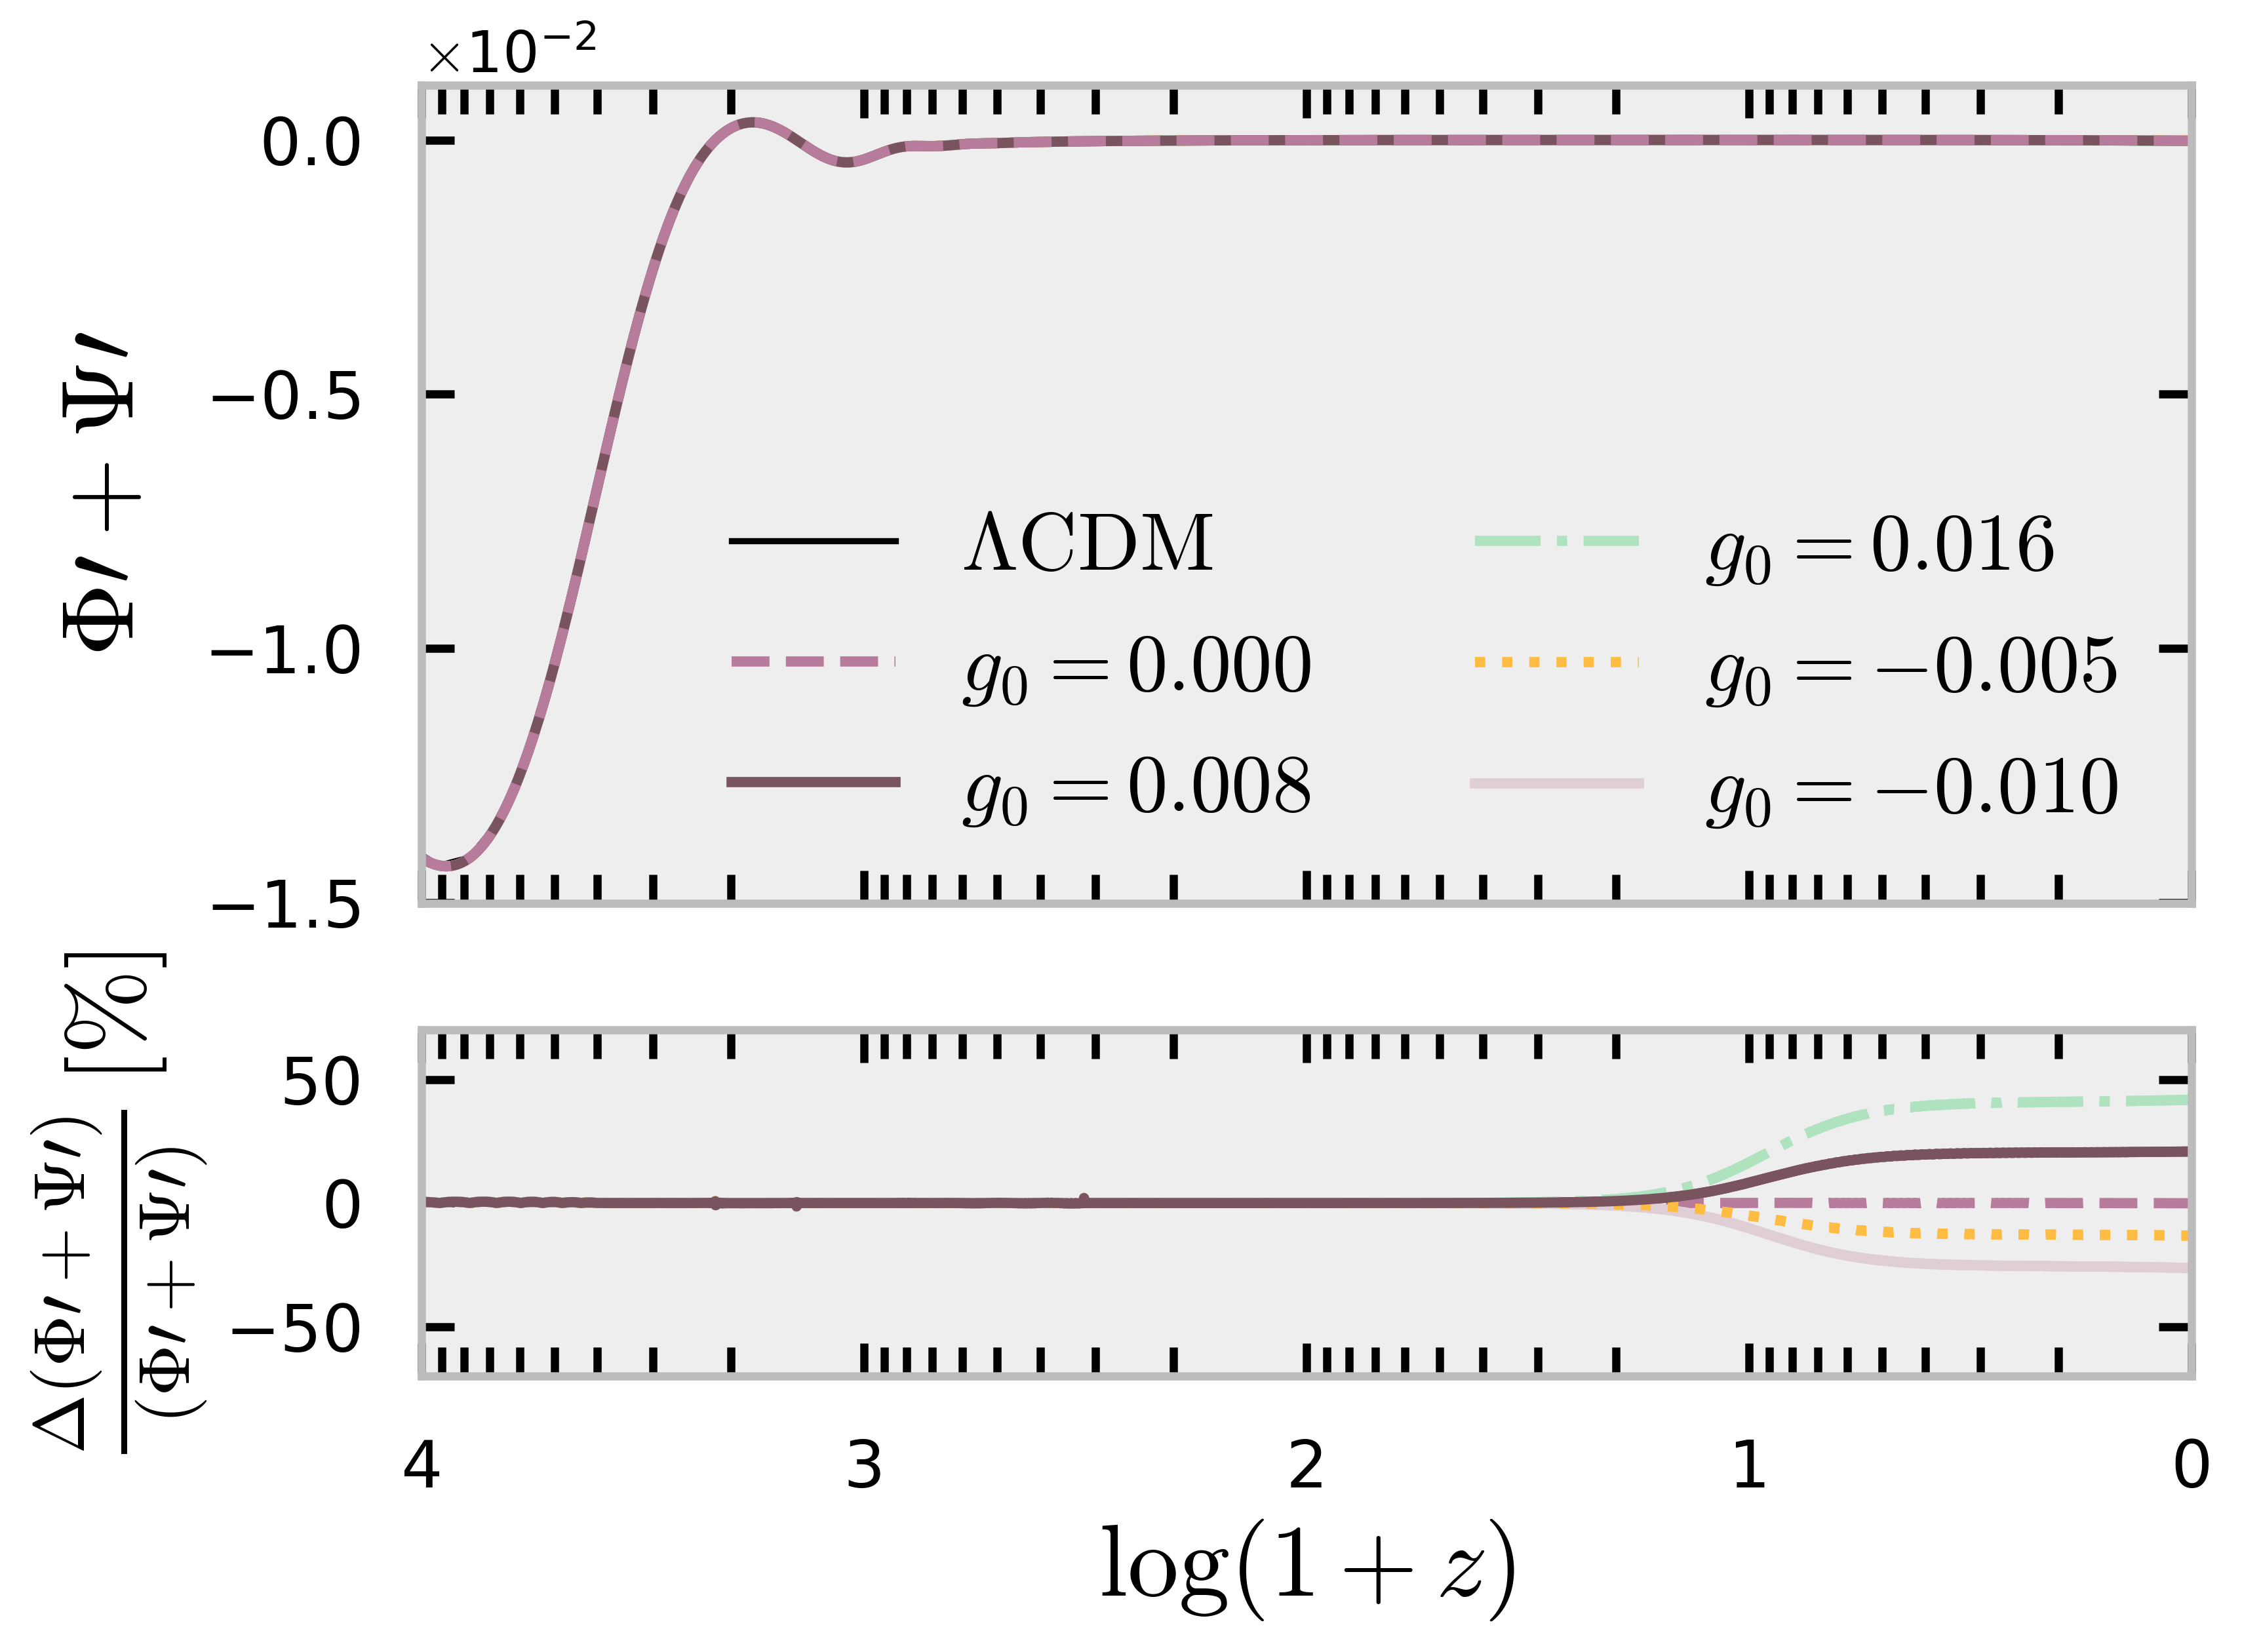

In [ ]:
plt.style.use(['ipynb', 'use_mathtext','colors5-light'])

lw = 2.5
ls = ['--','-','-.', ':', '-']


fig = plt.figure(figsize=(8,6))
ax0 = plt.subplot2grid((3,1),(0,0), rowspan=2)
ax1 = plt.subplot2grid((3,1),(2,0), rowspan=1,sharex = ax0)

plt.subplots_adjust(hspace=0,wspace=0.)

zz = np.logspace(5,0,10000) # k in h/Mpc
#tt = np.linspace(10**(-9),5.)
zzi = zz[::-1]
#print(zz)
#print(zzi)
index_k = 2
# get lambdac
standardPerturb=standard.get_perturbations()
a = standardPerturb['scalar'][index_k]['a']
tau = standardPerturb['scalar'][index_k]['tau [Mpc]']
print(tau)
z=1/a
zi = z[::-1]
Phipl = standardPerturb['scalar'][index_k]['phi_prime']
print(Phipl)
Phipli = Phipl[::-1]
Psipl = standardPerturb['scalar'][index_k]['phi_prime']
Psipli = Psipl[::-1]
phipsil_int = interp1d(zi,Phipli+Psipli)
# plot Lc
ax0.plot(zzi, phipsil_int(zzi), label = r'$\Lambda{\rm CDM}$', c = 'k', ls='-', lw=1.5)

print('k =', k_sorted[index_k])
style=0
for index in [0,1,2,3,4]: #--------------------------------------------> values of beta
    cosmoPerturb=cosmo[index].get_perturbations()
    a = cosmoPerturb['scalar'][index_k]['a']
    z=1/a
    zi = z[::-1]
    Phip = cosmoPerturb['scalar'][index_k]['phi_prime']
    Phipi = Phip[::-1]
    Psip = cosmoPerturb['scalar'][index_k]['phi_prime']
    Psipi = Psip[::-1]
    phipsi_int = interp1d(zi,Phipi+Psipi)

    ax0.plot(zzi, phipsi_int(zzi),
         label = r'$g_0 = %.3f$'%(f0s[index]),lw=lw, ls=ls[style],c=color[style])
    DELTA = (phipsi_int(zzi)  - phipsil_int(zzi)) / phipsil_int(zzi)
    ax1.plot(zzi,DELTA*100, lw=lw, ls=ls[style],c=color[style])
    style+=1

ax0.set_yscale('linear')
ax0.set_xscale('log')
ax0.set_xlim(1e4,1)
#ax0.set_ylim(0,1.1)
original_labels = ax0.get_xticks()
labels = []
for label in original_labels:
    labels.append(int(np.log10(label)))
ax0.set_xticklabels(labels)

ax1.set_yscale('linear')
ax1.set_xscale('log')
ax0.set_xlim(1e4,1)
ax1.set_ylim(-70.,70.)
ax1.set_yticks([i for i in np.linspace(-50,50,3)])
original_labels = ax1.get_xticks()
labels = []
for label in original_labels:
    labels.append(int(np.log10(label)))
ax1.set_xticklabels(labels)

ax1.set_xlabel(r'$\log(1+z)$', size=25)
ax0.set_ylabel(r'$\Phi\prime + \Psi\prime$', size=25,labelpad=12)
ax1.set_ylabel(r'$\frac{\Delta (\Phi\prime + \Psi\prime)}{(\Phi\prime + \Psi\prime)}\, [\%]$', size=25)

ax0.ticklabel_format(axis='y', style='sci', scilimits=(0,0), useMathText=True)

ax0.tick_params(axis='both', which='both', labelsize=16)
ax0.tick_params(axis='both', which='both', labelsize=16)

#---------------------------------------------------------------------------------> change ticklabels distance

for tick in ax1.xaxis.get_major_ticks():
    tick.set_pad(15)
for tick in ax0.yaxis.get_major_ticks():
    tick.set_pad(15)
for tick in ax1.yaxis.get_major_ticks():
    tick.set_pad(15)


ax0.tick_params(axis='both', which='both', labelsize=16)


ax0.xaxis.set_tick_params(which='major', size=8, width=2, direction='in', top='on')
ax0.xaxis.set_tick_params(which='minor', size=7, width=2, direction='in', top='on')
ax0.yaxis.set_tick_params(which='major', size=8, width=2, direction='in', right='on')
ax0.yaxis.set_tick_params(which='minor', size=7, width=2, direction='in', right='on')

ax1.tick_params(axis='both', which='both', labelsize=16)


ax1.xaxis.set_tick_params(which='major', size=8, width=2, direction='in', top='on')
ax1.xaxis.set_tick_params(which='minor', size=7, width=2, direction='in', top='on')
ax1.yaxis.set_tick_params(which='major', size=8, width=2, direction='in', right='on')
ax1.yaxis.set_tick_params(which='minor', size=7, width=2, direction='in', right='on')

plt.tight_layout()
#plt.savefig('cq_cmb_tt.pdf', transparent=True)

for ax in (ax0, ax1):
    # copy the list so we don't iterate over lines we add
    lines = list(ax.get_lines())[1:]
    for ln in lines[::-1]:
        ax.plot(
            ln.get_xdata(), ln.get_ydata(),
            ls=ln.get_linestyle(),
            lw=ln.get_linewidth(),
            c=ln.get_color(),
            marker=ln.get_marker(),
            markersize=ln.get_markersize(),
            alpha=ln.get_alpha() if ln.get_alpha() is not None else 1.0,
            label="_nolegend_",  # labels starting with '_' are ignored by legend()
        )

ax1.ticklabel_format(axis='y', style='plain', useMathText=True)
ax0.legend(loc='lower right', frameon=boolean, prop={'size': 20},ncol=2)
plt.setp(ax0.get_xticklabels(), visible=False)
plt.rcParams['font.size'] = 20
plt.rcParams['axes.linewidth'] = 2
fig.tight_layout()
plt.savefig('pppp2.pdf', transparent=True)
plt.show()

In [ ]:
#np.set_printoptions(suppress=True)
index_k = 2
standardPerturb=standard.get_perturbations()
at = standardPerturb['scalar'][index_k]['a']
taut = standardPerturb['scalar'][index_k]['tau [Mpc]']
Phipt = standardPerturb['scalar'][index_k]['phi']
Psipt = standardPerturb['scalar'][index_k]['psi']
print(len(at))
print(len(taut))
print(len(Phipt))
print(len(Psipt))
seena = set()
seentau = set()
seenpsi = set()
seenphi = set()
alp = []
taulp = []
Phiplp = []
Psiplp = []

al = []
taul = []
Phipl = []
Psipl = []

for i in range(0, len(at)):
        if (at[i] not in seena) and (taut[i] not in seentau) and (Phipt[i] not in seenphi) and (Psipt[i] not in seenpsi):
            alp.append(at[i])
            seena.add(at[i])
            taulp.append(taut[i])
            seentau.add(taut[i])
            Phiplp.append(Phipt[i])
            seenphi.add(Phipt[i])
            Psiplp.append(Psipt[i])
            seenpsi.add(Psipt[i])
al = np.array(alp)
taul = np.array(taulp)
Phipl = np.array(Phiplp)
Psipl = np.array(Psiplp)
print(len(al))
print(len(taul))
print(len(Phipl))
print(len(Psipl))


a=[]
tau=[]
Phip=[]
Psip=[]

aap=[]
taua=[]
Phipa=[]
Psipa=[]

for index in [0,1,2,3,4]: #--------------------------------------------> values of delta_s
    cosmoPerturb=cosmo[index].get_perturbations()
    aap.append(cosmoPerturb['scalar'][index_k]['a'])
    taua.append(cosmoPerturb['scalar'][index_k]['tau [Mpc]'])
    Phipa.append(cosmoPerturb['scalar'][index_k]['phi'])
    Psipa.append(cosmoPerturb['scalar'][index_k]['psi'])
    
#print(Phipa[0])
print("a")
for index in [0,1,2,3,4]: #--------------------------------------------> values of delta_s
    #print(len(aa[index]))
    #print(len(taua[index]))
    #print(len(Phipa[index]))
    #print(len(Psipa[index]))
    seena = set()
    seentau = set()
    seenpsi = set()
    seenphi = set()
    b1 = []
    b2 = []
    b3 = []
    b4 = []
    for i in range(0, len(aap[index])):
        if (aap[index][i] not in seena) and (taua[index][i] not in seentau) and (Phipa[index][i] not in seenphi) and (Psipa[index][i] not in seenpsi):
            b1.append(aap[index][i])
            seena.add(aap[index][i])
            b2.append(taua[index][i])
            seentau.add(taua[index][i])
            b3.append(Phipa[index][i])
            seenphi.add(Phipa[index][i])
            b4.append(Psipa[index][i])
            seenpsi.add(Psipa[index][i])
    b11 = np.array(b1)
    Psip.append(np.array(b4))
    Phip.append(np.array(b3))
    tau.append(np.array(b2))
    a.append(b11)
    #print(len(a[index]))
    #print(len(tau[index]))
    #print(len(Phip[index]))
    #print(len(Psip[index]))
print(index_k)

1279
1279
1279
1279
1276
1276
1276
1276
a
2


In [ ]:

smooth_factor = 1e-8
order=5
index_k = 2
print('k =', k_sorted[index_k])
print('k_index =', index_k)
# get lambdac
standardPerturb=standard.get_perturbations()
#print(al)
zl=(1./al)
zil = z[::-1]
Phipli = Phipl[::-1]
Psipli = Psipl[::-1]
Potl = Phipl+Psipl
Potl_intz = interp1d(zl,Potl,kind="cubic",fill_value="extrapolate")
Potl_intt = interp1d(taul,Potl,kind="cubic",fill_value="extrapolate")

z=[]
zi=[]
Phipi=[]
Psipi=[]
Pot=[]
Pot_intz=[]
Pot_intt=[]
SPot=[]
dPot=[]
test=[]
ui=[]
deltap=[]

for index in [0,1,2,3,4]: #--------------------------------------------> values of delta_s
    cosmoPerturb=cosmo[index].get_perturbations()
    #print(a[index])
    z.append(1/a[index])
    zi.append(z[index][::-1])
    Phipi.append(Phip[index][::-1])
    Psipi.append(Psip[index][::-1])
    Pot.append(Phip[index]+Psip[index])
    Pot_intz.append(interp1d(z[index],Pot[index],kind="cubic",fill_value="extrapolate"))
    Pot_intt.append(interp1d(tau[index],Pot[index],kind="cubic",fill_value="extrapolate"))

inf = np.amax([tau[0][0],tau[1][0],tau[2][0]])
sup = np.amin([tau[0][-1],tau[1][-1],tau[2][-1]])

tau_array = np.linspace(inf,sup,100000)

z_inf = np.amax([z[0][-1],z[1][-1],z[2][-1]])
z_sup = np.amin([z[0][0],z[1][0],z[2][0]])

z_break = 10
z_array = np.linspace(z_inf,z_break,1000000)
z_array2 = np.linspace(z_break,z_sup,1000000)

z_array3 = np.linspace(z_inf,z_sup,1000000)

SPotl = UnivariateSpline(taul, Potl_intt(taul),k=4,s=5e5)
SPotl.set_smoothing_factor(smooth_factor)
dPotl = SPotl.derivative(1)
testl = interp1d(zl,taul,kind="cubic",fill_value="extrapolate")
uil = interp1d(z_array3,dPotl(testl(z_array3)),kind="quadratic",fill_value='extrapolate')

for index in [0,1,2,3,4]: #--------------------------------------------> values of delta_s
    SPot.append(UnivariateSpline(tau[index], Pot_intt[index](tau[index]),k=4,s=5e5))
    SPot[index].set_smoothing_factor(smooth_factor)
    dPot.append(SPot[index].derivative(1))
    test.append(interp1d(z[index],tau[index],kind="cubic",fill_value="extrapolate"))
    ui.append(interp1d(z_array3,dPot[index](test[index](z_array3)),kind="quadratic",fill_value='extrapolate'))
    deltap.append(interp1d(z_array3,dPot[index](test[index](z_array3))/dPotl(testl(z_array3)) - 1.,kind="quadratic",fill_value='extrapolate'))
    #print(ui[index](z_array3).tolist())
    #print(deltap[index](z_array3).tolist())
#print(a[1][-1])

k = 0.067556
k_index = 2


/var/folders/91/jymwbq1j1nng0wqyd6yvbm100000gn/T/ipykernel_16362/3916308461.py:38: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax0.set_xticklabels(labels)
/var/folders/91/jymwbq1j1nng0wqyd6yvbm100000gn/T/ipykernel_16362/3916308461.py:49: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(labels)
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


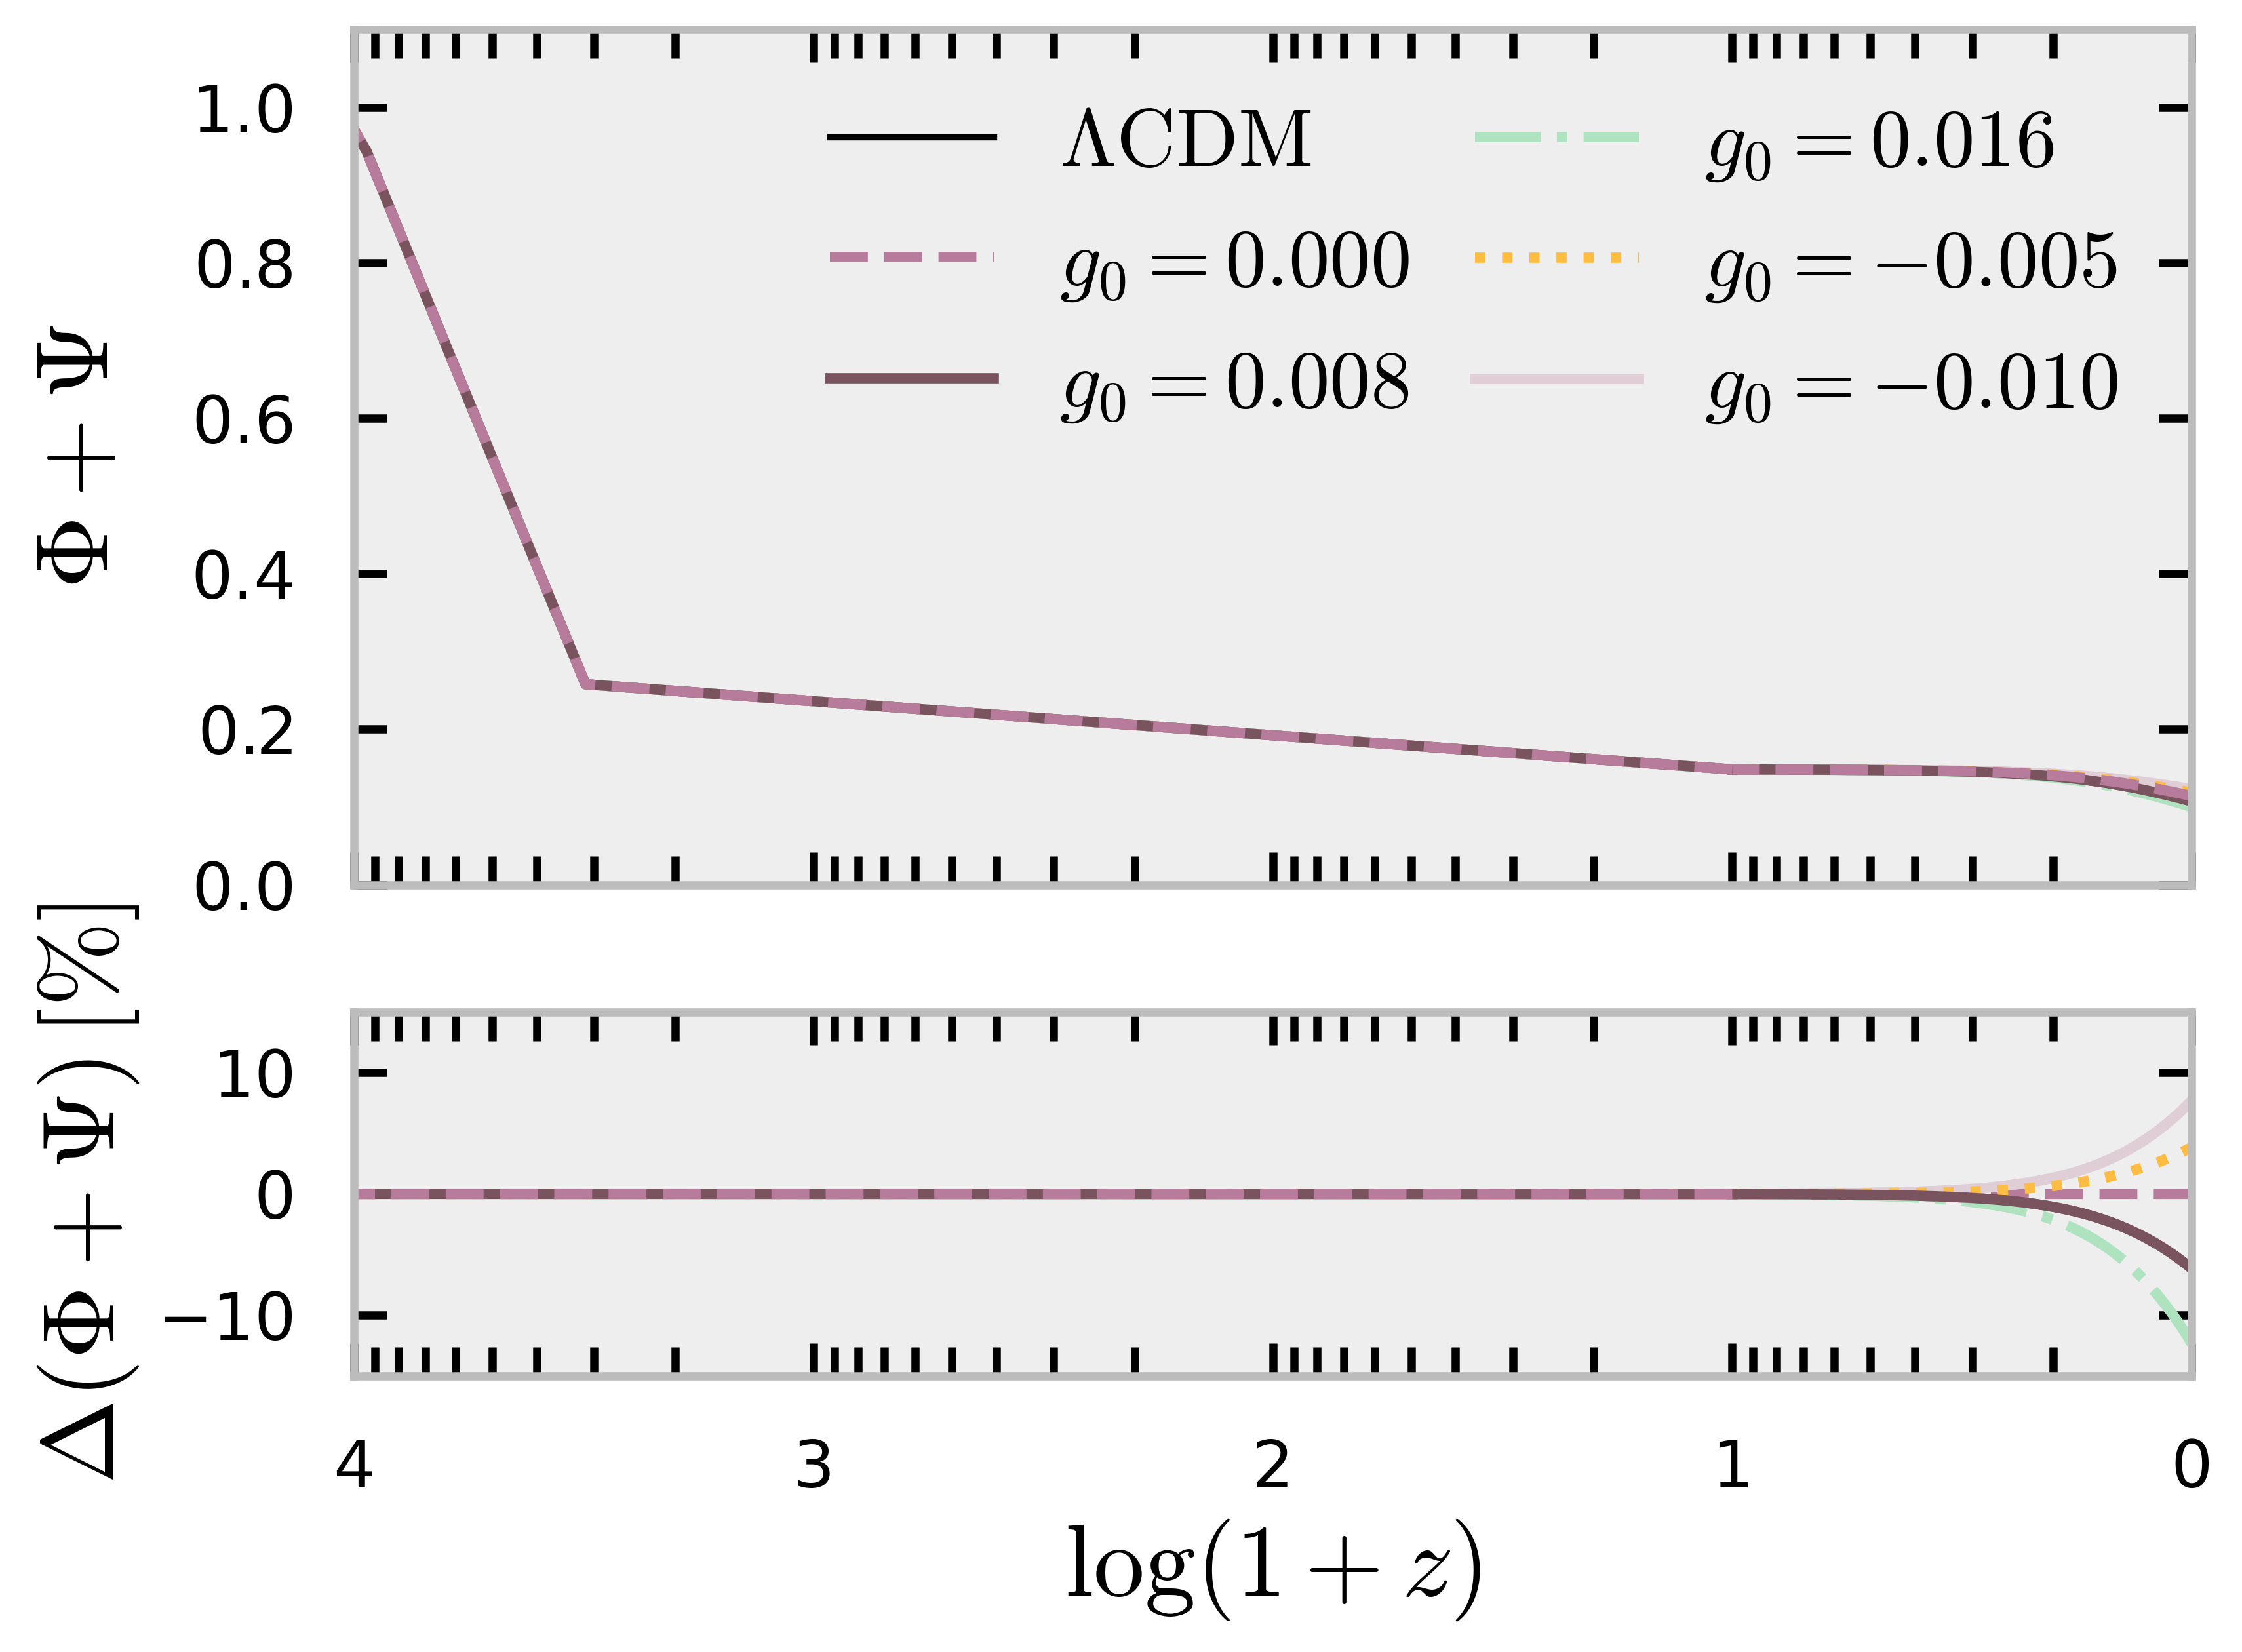

In [ ]:
plt.style.use(['ipynb', 'use_mathtext','colors5-light'])

coiso = 0.18
lw = 2.5
ls = ['--','-','-.', ':', '-']


fig = plt.figure(figsize=(8,6))
ax0 = plt.subplot2grid((3,1),(0,0), rowspan=2)
ax1 = plt.subplot2grid((3,1),(2,0), rowspan=1,sharex = ax0)

plt.subplots_adjust(hspace=0,wspace=0.)

ax0.plot(z_array,Potl_intz(z_array), label = r'$\Lambda{\rm CDM}$', c = 'k', ls='-', lw=1.5,zorder=0)
ax0.plot(z_array2,Potl_intz(z_array2), c = 'k', ls='-', lw=1.5,zorder=0)
index_k = 2
style=0
for index in [0,1,2,3,4]: #--------------------------------------------> values of beta
    ax0.plot(z_array,Pot_intz[index](z_array),
         label = r'$g_0 = %.3f$'%(f0s[index]),lw=lw, ls=ls[style],c=color[style])
    ax0.plot(z_array2,Pot_intz[index](z_array2),
         lw=lw, ls=ls[style],c=color[style])
    DELTA1 = (Pot_intz[index](z_array)  - Potl_intz(z_array)) / Potl_intz(z_array)
    ax1.plot(z_array,DELTA1*100, lw=lw, ls=ls[style],c=color[style])
    DELTA2 = (Pot_intz[index](z_array2)  - Potl_intz(z_array2)) / Potl_intz(z_array2)
    ax1.plot(z_array2,DELTA2*100, lw=lw, ls=ls[style],c=color[style])
    style+=1

ax0.set_yscale('linear')
ax0.set_xscale('log')
ax0.set_xlim(1e4,1)
#ax0.set_xlim([coiso*z_array2[-1],z_array[0]])
ax0.set_ylim(0.,1.1)
original_labels = ax0.get_xticks()
labels = []
for label in original_labels:
    labels.append(int(np.log10(label)))
ax0.set_xticklabels(labels)

ax1.set_yscale('linear')
ax1.set_xscale('log')
#ax1.set_xlim([coiso*z_array2[-1],z_array[0]])
ax1.set_ylim(-15.,15)
#ax1.set_yticks([i for i in np.linspace(-45,45,3)])
original_labels = ax1.get_xticks()
labels = []
for label in original_labels:
    labels.append(int(np.log10(label)))
ax1.set_xticklabels(labels)

ax1.set_xlabel(r'$\log(1+z)$', size=25)
ax0.set_ylabel(r'$\Phi + \Psi$', size=25,labelpad=15)
ax1.set_ylabel(r'$\Delta (\Phi + \Psi)\, [\%]$', size=25)

ax0.ticklabel_format(axis='y', style='sci', scilimits=(0,0), useMathText=True)

ax0.tick_params(axis='both', which='both', labelsize=16)
ax0.tick_params(axis='both', which='both', labelsize=16)

#---------------------------------------------------------------------------------> change ticklabels distance

for tick in ax1.xaxis.get_major_ticks():
    tick.set_pad(15)
for tick in ax0.yaxis.get_major_ticks():
    tick.set_pad(15)
for tick in ax1.yaxis.get_major_ticks():
    tick.set_pad(15)
    

ax0.tick_params(axis='both', which='both', labelsize=16)

    
ax0.xaxis.set_tick_params(which='major', size=8, width=2, direction='in', top='on')
ax0.xaxis.set_tick_params(which='minor', size=7, width=2, direction='in', top='on')
ax0.yaxis.set_tick_params(which='major', size=8, width=2, direction='in', right='on')
ax0.yaxis.set_tick_params(which='minor', size=7, width=2, direction='in', right='on')

ax1.tick_params(axis='both', which='both', labelsize=16)

    
ax1.xaxis.set_tick_params(which='major', size=8, width=2, direction='in', top='on')
ax1.xaxis.set_tick_params(which='minor', size=7, width=2, direction='in', top='on')
ax1.yaxis.set_tick_params(which='major', size=8, width=2, direction='in', right='on')
ax1.yaxis.set_tick_params(which='minor', size=7, width=2, direction='in', right='on')

plt.tight_layout()
#plt.savefig('cq_cmb_tt.pdf', transparent=True)

    # copy the list so we don't iterate over lines we add
lines = list(ax1.get_lines())[1:]
for ln in lines[::-1]:
    ax1.plot(
        ln.get_xdata(), ln.get_ydata(),
        ls=ln.get_linestyle(),
        lw=ln.get_linewidth(),
        c=ln.get_color(),
        marker=ln.get_marker(),
        markersize=ln.get_markersize(),
        alpha=ln.get_alpha() if ln.get_alpha() is not None else 1.0,
        label="_nolegend_",  # labels starting with '_' are ignored by legend()
    )


# copy the list so we don't iterate over lines we add
lines = list(ax0.get_lines())[2:]
for ln in lines[::-1]:
    ax0.plot(
        ln.get_xdata(), ln.get_ydata(),
        ls=ln.get_linestyle(),
        lw=ln.get_linewidth(),
        c=ln.get_color(),
        marker=ln.get_marker(),
        markersize=ln.get_markersize(),
        alpha=ln.get_alpha() if ln.get_alpha() is not None else 1.0,
        label="_nolegend_",  # labels starting with '_' are ignored by legend()
    )

ax1.ticklabel_format(axis='y', style='plain', useMathText=True)


ax0.legend(loc='upper right', frameon=boolean, prop={'size': 20},ncol=2,columnspacing=0.8)
plt.setp(ax0.get_xticklabels(), visible=False)
plt.rcParams['font.size'] = 20
plt.rcParams['axes.linewidth'] = 2
fig.tight_layout()
plt.savefig('lens.pdf')
#, transparent=True)
plt.show()

/var/folders/91/jymwbq1j1nng0wqyd6yvbm100000gn/T/ipykernel_16362/2394730440.py:41: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax0.set_xticklabels(labels)
/var/folders/91/jymwbq1j1nng0wqyd6yvbm100000gn/T/ipykernel_16362/2394730440.py:52: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(labels)
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


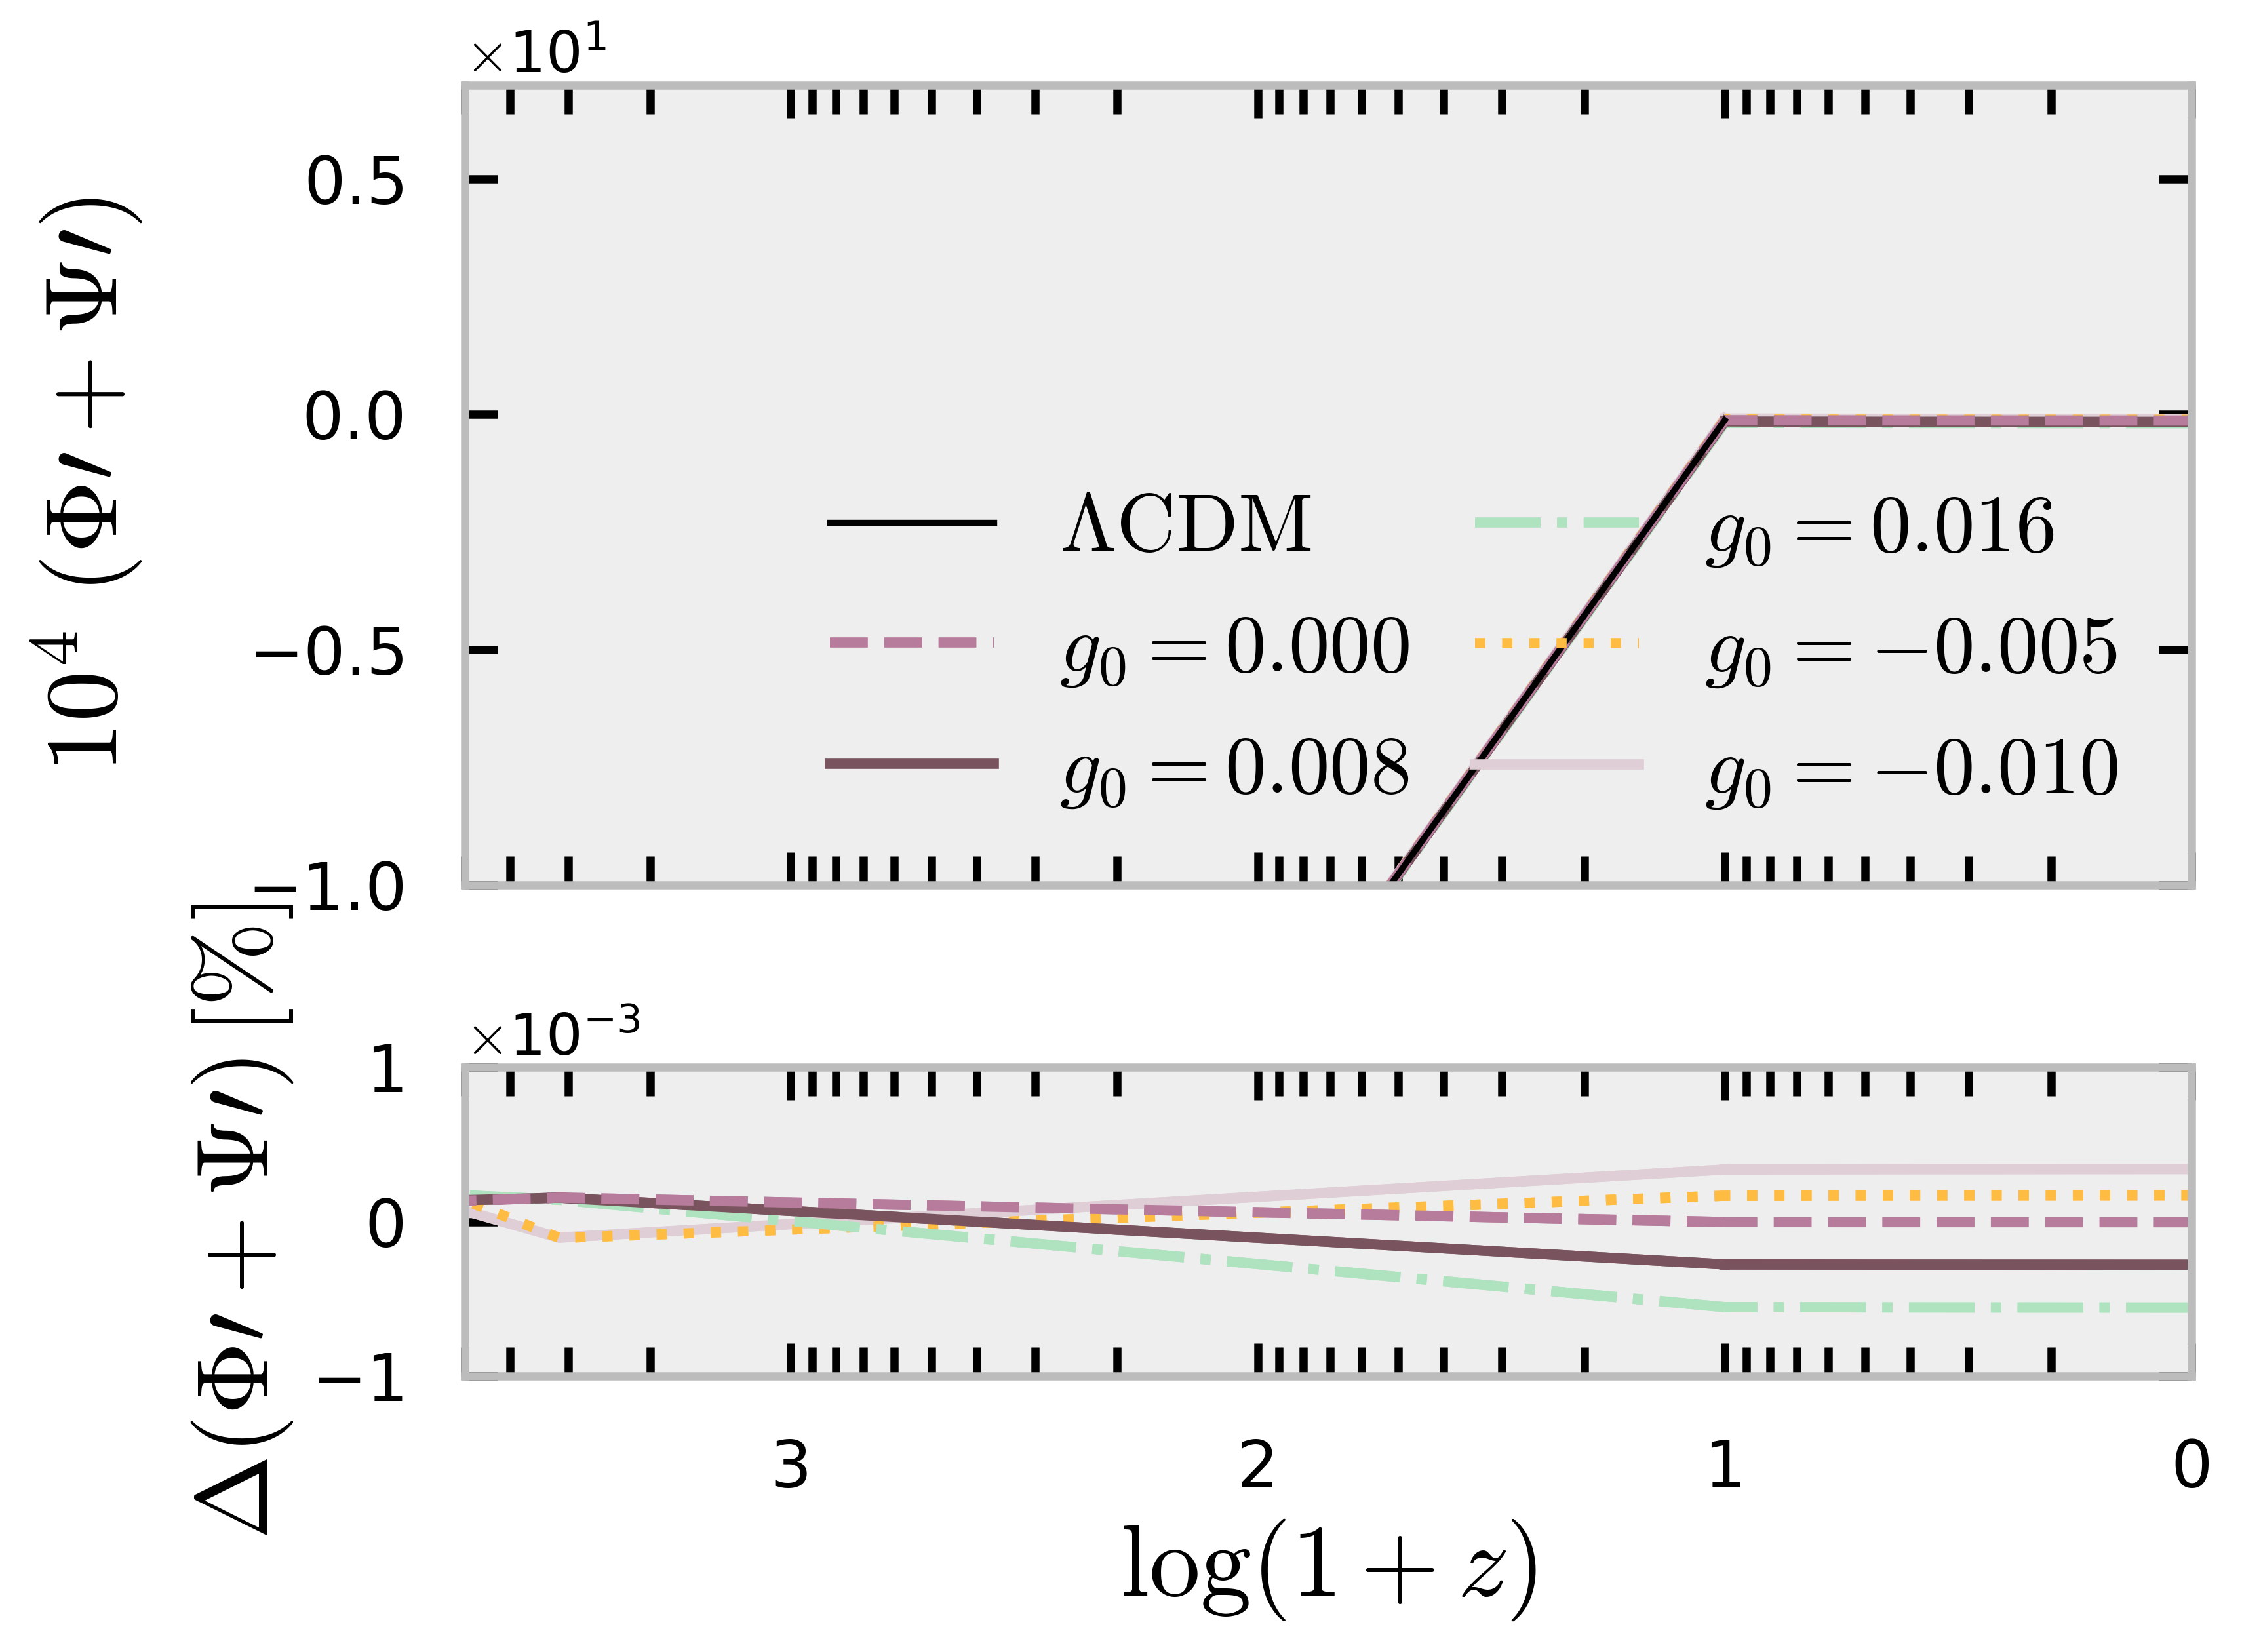

In [ ]:
plt.style.use(['ipynb', 'use_mathtext','colors5-light'])

lw = 2.5
ls = ['--','-','-.', ':', '-']


fig = plt.figure(figsize=(8,6))
ax0 = plt.subplot2grid((3,1),(0,0), rowspan=2)
ax1 = plt.subplot2grid((3,1),(2,0), rowspan=1,sharex = ax0)

plt.subplots_adjust(hspace=0,wspace=0.)

ax0.plot(z_array,uil(z_array)*1e4, label = r'$\Lambda{\rm CDM}$', c = 'k', ls='-', lw=1.5)
ax0.plot(z_array2,uil(z_array2)*1e4, c = 'k', ls='-', lw=1.5)
index_k = 2
style=0
for index in [0,1,2,3,4]: #--------------------------------------------> values of beta
    DELTA1 = (ui[index](z_array)*10e3- uil(z_array)*10e3)/(uil(z_array)*10e3)
    DELTA2 = (ui[index](z_array2)*10e3 - uil(z_array2)*10e3)/(uil(z_array2)*10e3)
    
    #DELTA.set_smoothing_factor(temp)
    ax0.plot(z_array,ui[index](z_array)*1e4,
         label = r'$g_0 = %.3f$'%(f0s[index]),lw=lw, ls=ls[style],c=color[style])
    ax0.plot(z_array2,ui[index](z_array2)*1e4 ,
         lw=lw, ls=ls[style],c=color[style])
    ax1.plot(z_array, ((ui[index](z_array)-uil(z_array))*100.), lw=lw, ls=ls[style],c=color[style])
    ax1.plot(z_array2, ((ui[index](z_array2)-uil(z_array2))*100.), lw=lw, ls=ls[style],c=color[style])
    #ax1.plot(z_array2,-100.*DELTA2, lw=lw, ls=ls[style],c=color[style])
    style+=1



ax0.set_yscale('linear')
ax0.set_xscale('log')
#ax0.set_xlim([coiso*z_array2[-1],z_array[0]])
ax0.set_ylim(-10,7.)
original_labels = ax0.get_xticks()
labels = []
for label in original_labels:
    labels.append(int(np.log10(label)))
ax0.set_xticklabels(labels)

ax1.set_yscale('linear')
ax1.set_xscale('log')
ax1.set_xlim(5e3,1)
ax1.set_ylim(-0.001,0.001)
#ax1.set_yticks([i for i in np.linspace(-45,45,3)])
original_labels = ax1.get_xticks()
labels = []
for label in original_labels:
    labels.append(int(np.log10(label)))
ax1.set_xticklabels(labels)

ax1.set_xlabel(r'$\log(1+z)$', size=25)
ax0.set_ylabel(r'$ 10^4\ (\Phi\prime + \Psi\prime) $', size=25,labelpad=25)
ax1.set_ylabel(r'$\Delta (\Phi\prime  + \Psi\prime )\, [\%]$', size=25)

#ax0.ticklabel_format(axis='y', style='sci', scilimits=(0,0), useMathText=True)

ax0.tick_params(axis='both', which='both', labelsize=16)
ax0.tick_params(axis='both', which='both', labelsize=16)

#---------------------------------------------------------------------------------> change ticklabels distance

for tick in ax1.xaxis.get_major_ticks():
    tick.set_pad(15)
for tick in ax0.yaxis.get_major_ticks():
    tick.set_pad(15)
for tick in ax1.yaxis.get_major_ticks():
    tick.set_pad(15)
    

ax0.tick_params(axis='both', which='both', labelsize=16)

    
ax0.xaxis.set_tick_params(which='major', size=8, width=2, direction='in', top='on')
ax0.xaxis.set_tick_params(which='minor', size=7, width=2, direction='in', top='on')
ax0.yaxis.set_tick_params(which='major', size=8, width=2, direction='in', right='on')
ax0.yaxis.set_tick_params(which='minor', size=7, width=2, direction='in', right='on')

ax1.tick_params(axis='both', which='both', labelsize=16)

    
ax1.xaxis.set_tick_params(which='major', size=8, width=2, direction='in', top='on')
ax1.xaxis.set_tick_params(which='minor', size=7, width=2, direction='in', top='on')
ax1.yaxis.set_tick_params(which='major', size=8, width=2, direction='in', right='on')
ax1.yaxis.set_tick_params(which='minor', size=7, width=2, direction='in', right='on')

for ax in (ax0, ax1):
    # copy the list so we don't iterate over lines we add
    lines = list(ax.get_lines())[1:]
    for ln in lines[::-1]:
        ax.plot(
            ln.get_xdata(), ln.get_ydata(),
            ls=ln.get_linestyle(),
            lw=ln.get_linewidth(),
            c=ln.get_color(),
            marker=ln.get_marker(),
            markersize=ln.get_markersize(),
            alpha=ln.get_alpha() if ln.get_alpha() is not None else 1.0,
            label="_nolegend_",  # labels starting with '_' are ignored by legend()
        )

plt.tight_layout()
#plt.savefig('cq_cmb_tt.pdf', transparent=True)
#ax0.text(0.95*10e4, -1.6,r'$(\times 10^{4})$', fontsize=15,rotation=90)
ax0.legend(loc='lower right', frameon=boolean, prop={'size': 20},ncol=2,columnspacing=0.8)
plt.setp(ax0.get_xticklabels(), visible=False)
plt.rcParams['font.size'] = 20
plt.rcParams['axes.linewidth'] = 2
fig.tight_layout()
plt.savefig('lensp.pdf')
#, transparent=True)
plt.show()